# Log Analysis Report

Analyzes per-node `node-*.log` files (WARN zap log lines) bundled in result tarballs.
Reconstructs the per-node stats schema from the structured logs
(see `committee-sampling/LOG_COLLECTION.md`).
Covers: run inventory, message correctness, late messages, arrival lag, byte volumes, committee consistency, peer drops.
Final cell prints a self-contained markdown report.


In [1]:
# Cell 0 — Imports & Config
import json
import re
import tarfile
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from tabulate import tabulate

RESULTS_DIR = Path("/Users/mamorski/repos/committee-analysis/results")

# Protocol display names (strip session suffix for readability)
PROTO_SHORT = {
    "exante": "exante",
    "expost": "expost",
    "exanteMDAG": "exanteMDAG",
    "expostMDAG": "expostMDAG",
}

def ns_to_ms(ns):
    return ns / 1_000_000

def bytes_to_mb(b):
    return b / (1024 * 1024)

def parse_sid(sid):
    """Extract n_nodes and rep from a sid.

    Sweep sids encode both: 'sweep-500n-rep-01-20260622-210000'.
    Other studies (e.g. 'drop-05pct-rep-01-<ts>') do not encode n_nodes,
    but still carry rep + timestamp -- pull those so rep isn't lost (n_nodes
    falls back to the tarball node count in load_all_logs).
    """
    m = re.match(r"sweep-(\d+)n-rep-(\d+)-(.+)", sid)
    if m:
        return int(m.group(1)), int(m.group(2)), m.group(3)
    m = re.search(r"-rep-(\d+)-(.+)", sid)
    if m:
        return None, int(m.group(1)), m.group(2)
    return None, None, sid

def short_proto_id(proto_id, sid):
    """Strip session suffix from protocol IDs like '/exante/1.0.0/<sid>'."""
    return proto_id.replace(f"/{sid}", "").replace("/1.0.0", "").replace("/mdag", "mdag")

print(f"Results directory: {RESULTS_DIR.resolve()}")
tarballs = sorted(RESULTS_DIR.glob("*.tar.gz"))
print(f"Found {len(tarballs)} tarballs")

Results directory: /Users/mamorski/repos/committee-analysis/results
Found 210 tarballs


In [2]:
# Cell 1 — Load All Logs
# Returns all_stats: list of dicts, one per node per run.
# Each dict mirrors the old stats-file schema, reconstructed from the WARN zap
# log lines in node-*.log (see committee-sampling/LOG_COLLECTION.md).
#
# Node-drop handling: the harness SIGTERMs a fraction of nodes mid-run (see
# run_simulations.py:drop_nodes). A dropped node still flushes partial metric
# lines (round stats, final bytes, Final neighbor list) but is killed before it
# logs "Committee elected". Those partial rows would skew every aggregate, so we
# detect them (committee_elected == False) and split them out: `all_stats` holds
# survivors only; dropped nodes live in `all_stats_dropped`. `run_alive_ids` /
# `run_dropped_ids` map sid -> the surviving / dropped node_ids for that run.

PROTOCOLS = ["exante", "expost", "exanteMDAG", "expostMDAG"]


def parse_node_log(text):
    """Parse one node-*.log into a stats-shaped dict.

    Node logs are mixed: a leading non-JSON stdout banner (committee ID/VK/Grade),
    then JSON zap lines. Skip non-JSON lines; fold the WARN metric lines into the
    schema the downstream cells expect. `committee_elected` records whether the
    node reached the "Committee elected" milestone -- False marks a dropped node.
    """
    protos = defaultdict(lambda: {
        "total_messages": [], "valid_messages": [],
        "late_messages": 0, "max_lateness": 0, "arrival_lag": [],
    })
    by_protocol = {}
    summary = {}
    committee = []
    committee_elected = False
    neighbors = []
    peer_drops = []
    graph_snapshots = {}
    msg_drops = {}
    caches = {}
    node_id = None

    for line in text.splitlines():
        line = line.strip()
        if not line.startswith("{"):
            continue
        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue
        if node_id is None and isinstance(rec.get("node_id"), str):
            node_id = rec["node_id"]
        msg = rec.get("msg")
        if msg == "round stats":
            p = protos[rec.get("proto", "?")]
            p["total_messages"].append(int(rec.get("total", 0)))
            p["valid_messages"].append(int(rec.get("valid", 0)))
            p["late_messages"] += int(rec.get("late", 0))
            p["max_lateness"] = max(p["max_lateness"], int(rec.get("max_lateness", 0)))
            p["arrival_lag"].append({
                "mean_ns": int(rec.get("lag_mean_ns", 0)),
                "max_ns": int(rec.get("lag_max_ns", 0)),
            })
        elif msg == "final bytes":
            summary = {
                "total_in": int(rec.get("total_in", 0)),
                "total_out": int(rec.get("total_out", 0)),
                "app_in": int(rec.get("app_in", 0)),
                "app_out": int(rec.get("app_out", 0)),
                "overhead_in": int(rec.get("overhead_in", 0)),
                "overhead_out": int(rec.get("overhead_out", 0)),
            }
        elif msg == "final bytes by protocol":
            proto_id = rec.get("protocol", "?")
            by_protocol[proto_id] = {
                "in": int(rec.get("wire_in", 0)),
                "out": int(rec.get("wire_out", 0)),
            }
        elif msg == "Committee elected":
            committee_elected = True
            for m in rec.get("committee") or []:
                committee.append({"id": m.get("ID"), "grade": m.get("Grade")})
        elif msg == "Final neighbor list":
            neighbors = [n for n in (rec.get("neighbors") or []) if isinstance(n, str)]
        elif msg == "Simulation: peer-drop":
            peer_drops.append({
                "peer_id": rec.get("peer_id"),
                "phase": rec.get("phase"),
                "round": rec.get("round"),
            })
        elif msg == "Simulation: dropped outgoing message":
            proto_id = rec.get("protocol", "?")
            d = msg_drops.setdefault(
                proto_id, {"count": 0, "probability": float(rec.get("probability", 0.0))}
            )
            d["count"] += 1
        elif msg == "Graph snapshot":
            graph_snapshots[rec.get("phase", "?")] = [
                n for n in (rec.get("neighbors") or []) if isinstance(n, str)
            ]
        elif msg == "cache stats":
            caches[rec.get("cache", "?")] = {
                "hits": int(rec.get("hits", 0)),
                "misses": int(rec.get("misses", 0)),
            }

    return {
        "node_id": node_id or "?",
        "protocols": {k: dict(v) for k, v in protos.items()},
        "bytes": {"summary": summary, "by_protocol": by_protocol},
        "committee": committee,
        "committee_elected": committee_elected,
        "neighbors": neighbors,
        "graph_snapshots": graph_snapshots,
        "peer_drops": peer_drops,
        "msg_drops": msg_drops,
        "caches": caches,
    }


def load_all_logs(results_dir):
    all_stats = []
    for tgz in sorted(results_dir.glob("*.tar.gz")):
        sid = tgz.stem.replace(".tar", "")
        n_nodes, rep, ts = parse_sid(sid)
        if rep is None:
            rep = 1  # single-rep campaigns don't encode -rep- in the sid
        if ts == sid:  # parse_sid fell all the way back; recover trailing timestamp
            _mts = re.search(r"(\d{8}-\d{6})$", sid)
            ts = _mts.group(1) if _mts else ts
        with tarfile.open(tgz, "r:gz") as tf:
            node_members = [
                m for m in tf.getmembers()
                if "/node-" in m.name and m.name.endswith(".log")
            ]
            # fall back to log count when sid doesn't encode n_nodes
            n_nodes_eff = n_nodes if n_nodes is not None else len(node_members)
            for nm in node_members:
                try:
                    text = tf.extractfile(nm).read().decode("utf-8", "replace")
                except Exception as e:
                    print(f"READ ERROR {nm.name}: {e}")
                    continue
                data = parse_node_log(text)
                if not (data["protocols"] or data["committee"]
                        or data["neighbors"] or data["bytes"]["summary"]):
                    # node log has no WARN metric lines (e.g. predates the
                    # log-based stats refactor) -- skip the empty shell.
                    continue
                # A node that logged metrics but never reached "Committee elected"
                # was SIGTERMed by the node-drop harness before finishing.
                data["_dropped"] = not data["committee_elected"]
                data["sid"] = sid
                data["_sid"] = sid
                data["_n_nodes"] = n_nodes_eff
                data["_rep"] = rep
                data["_ts"] = ts
                data["_tarball"] = tgz.name
                all_stats.append(data)
    return all_stats


all_stats_all = load_all_logs(RESULTS_DIR)
if not all_stats_all:
    raise RuntimeError(
        f"No WARN-level metric logs found in any node-*.log under {RESULTS_DIR}.\n"
        "The node logs carry only the stdout committee banner (ID/VK/Grade), not the "
        "zap JSON metric lines ('round stats', 'final bytes', 'Committee elected', ...).\n"
        "Re-run the simulations with zap logging at WARN captured to the node log "
        "(config: logger.level = warn). See committee-sampling/LOG_COLLECTION.md."
    )

# Split survivors from dropped (SIGTERMed) nodes. Downstream cells iterate
# `all_stats`, so excluding dropped rows here removes their partial metrics from
# every aggregate in one place.
run_alive_ids = defaultdict(set)
run_dropped_ids = defaultdict(set)
for s in all_stats_all:
    bucket = run_dropped_ids if s["_dropped"] else run_alive_ids
    bucket[s["_sid"]].add(s["node_id"])

all_stats = [s for s in all_stats_all if not s["_dropped"]]
all_stats_dropped = [s for s in all_stats_all if s["_dropped"]]

n_runs = len({s["_sid"] for s in all_stats_all})
n_dropped = len(all_stats_dropped)
print(f"Loaded {len(all_stats_all)} node stats across {n_runs} run(s) with log data "
      f"({len(tarballs)} tarballs scanned)")
print(f"  survivors: {len(all_stats)}   dropped (no 'Committee elected'): {n_dropped}")
if n_dropped:
    drop_by_run = sorted((sid, len(ids)) for sid, ids in run_dropped_ids.items())
    print("  dropped nodes per run:")
    for sid, k in drop_by_run:
        print(f"    {sid}: {k}")

# sid -> real node count. parse_sid returns None for every non-sweep sid, which
# poisoned n_nodes columns with nan; _n_nodes (set in load_all_logs, log-count
# fallback) is always a real integer. Downstream cells key on this map.
sid_nnodes = {s["_sid"]: s["_n_nodes"] for s in all_stats_all}

Loaded 174500 node stats across 210 run(s) with log data (210 tarballs scanned)
  survivors: 170681   dropped (no 'Committee elected'): 3819
  dropped nodes per run:
    msg-drop-80pct-deg20-20260712-043339: 1
    node-drop-05pct-v1m-rep-01-20260702-190000: 50
    node-drop-05pct-v1m-rep-01-20260704-190000: 50
    node-drop-05pct-v1m-rep-02-20260702-193648: 50
    node-drop-05pct-v1m-rep-02-20260704-193650: 50
    node-drop-05pct-v1m-rep-03-20260702-201335: 50
    node-drop-05pct-v1m-rep-03-20260704-201341: 50
    node-drop-10pct-v1m-rep-01-20260702-205023: 100
    node-drop-10pct-v1m-rep-01-20260704-205029: 100
    node-drop-10pct-v1m-rep-02-20260702-212711: 100
    node-drop-10pct-v1m-rep-02-20260704-212722: 100
    node-drop-10pct-v1m-rep-03-20260702-220358: 100
    node-drop-10pct-v1m-rep-03-20260704-220409: 100
    node-drop-15pct-v1m-rep-01-20260702-224046: 103
    node-drop-15pct-v1m-rep-01-20260704-224059: 103
    node-drop-15pct-v1m-rep-02-20260702-231734: 103
    node-drop-15

In [3]:
# Cell 2 — Run Inventory Table
# Built from all_stats (survivors only), so only runs whose node logs carry WARN
# metric lines appear (tarballs predating the log-based stats refactor are
# skipped by the loader). `dropped` counts nodes SIGTERMed by the node-drop
# harness (present in the logs but excluded from every aggregate).

runs = {}
for s in all_stats:
    sid = s["_sid"]
    r = runs.setdefault(sid, {
        "sid": sid,
        "n_nodes": s["_n_nodes"],
        "rep": s["_rep"],
        "timestamp": s["_ts"],
        "survivors": 0,
    })
    r["survivors"] += 1

for sid, r in runs.items():
    r["dropped"] = len(run_dropped_ids.get(sid, ()))
    r["total_logged"] = r["survivors"] + r["dropped"]

inventory_rows = [runs[k] for k in sorted(runs)]
inventory_df = pd.DataFrame(inventory_rows)
print(f"Runs with log data: {len(inventory_rows)}")
print(tabulate(inventory_df, headers="keys", tablefmt="pipe", showindex=False))


Runs with log data: 210
| sid                                          |   n_nodes |   rep | timestamp       |   survivors |   dropped |   total_logged |
|:---------------------------------------------|----------:|------:|:----------------|------------:|----------:|---------------:|
| csize-010-rep-01-20260719-190000             |      1000 |     1 | 20260719-190000 |        1000 |         0 |           1000 |
| csize-010-rep-02-20260719-192713             |      1000 |     2 | 20260719-192713 |        1000 |         0 |           1000 |
| csize-010-rep-03-20260719-195426             |      1000 |     3 | 20260719-195426 |        1000 |         0 |           1000 |
| csize-020-rep-01-20260719-202140             |      1000 |     1 | 20260719-202140 |        1000 |         0 |           1000 |
| csize-020-rep-02-20260719-204853             |      1000 |     2 | 20260719-204853 |        1000 |         0 |           1000 |
| csize-020-rep-03-20260719-211607             |      1000 |     3

In [4]:
# Cell 3 — Stats File Correctness
# Check total_messages == valid_messages for all nodes/protocols

correctness = defaultdict(lambda: {"nodes_with_invalid": 0, "total_invalid_msgs": 0})

for s in all_stats:
    sid = s["_sid"]
    for proto_name, proto in s.get("protocols", {}).items():
        total = proto.get("total_messages", [])
        valid = proto.get("valid_messages", [])
        invalid = sum(t - v for t, v in zip(total, valid) if t > v)
        if invalid > 0:
            key = (sid, proto_name)
            correctness[key]["nodes_with_invalid"] += 1
            correctness[key]["total_invalid_msgs"] += invalid

if correctness:
    rows = [
        {"sid": k[0], "protocol": k[1], **v}
        for k, v in sorted(correctness.items())
    ]
    correctness_df = pd.DataFrame(rows)
    print("INVALID MESSAGES DETECTED:")
    print(tabulate(correctness_df, headers="keys", tablefmt="pipe", showindex=False))
else:
    print("All nodes: total_messages == valid_messages across all protocols. No invalid messages.")

INVALID MESSAGES DETECTED:
| sid                                          | protocol   |   nodes_with_invalid |   total_invalid_msgs |
|:---------------------------------------------|:-----------|---------------------:|---------------------:|
| csize-010-rep-01-20260719-190000             | exante     |                   13 |                   60 |
| csize-010-rep-01-20260719-190000             | expost     |                   12 |                   51 |
| csize-010-rep-02-20260719-192713             | exante     |                   43 |                  849 |
| csize-010-rep-02-20260719-192713             | expost     |                   43 |                  842 |
| csize-010-rep-03-20260719-195426             | exante     |                    3 |                    8 |
| csize-010-rep-03-20260719-195426             | expost     |                    3 |                    6 |
| csize-020-rep-01-20260719-202140             | exante     |                   64 |                 1145 |
|

In [5]:
# Cell 4 — Late Messages

late_data = defaultdict(lambda: {"nodes_with_late": 0, "total_late_msgs": 0, "max_lateness_rounds": 0})

for s in all_stats:
    sid = s["_sid"]
    for proto_name, proto in s.get("protocols", {}).items():
        late = proto.get("late_messages", 0)
        max_late = proto.get("max_lateness", 0)
        if late > 0:
            key = (sid, proto_name)
            late_data[key]["nodes_with_late"] += 1
            late_data[key]["total_late_msgs"] += late
            late_data[key]["max_lateness_rounds"] = max(
                late_data[key]["max_lateness_rounds"], max_late
            )

if late_data:
    rows = [
        {"sid": k[0], "protocol": k[1], **v}
        for k, v in sorted(late_data.items())
    ]
    late_df = pd.DataFrame(rows)
    print("LATE MESSAGES DETECTED:")
    print(tabulate(late_df, headers="keys", tablefmt="pipe", showindex=False))
else:
    print("No late messages in any run.")

LATE MESSAGES DETECTED:
| sid                                          | protocol   |   nodes_with_late |   total_late_msgs |   max_lateness_rounds |
|:---------------------------------------------|:-----------|------------------:|------------------:|----------------------:|
| csize-040-rep-01-20260719-230504             | exante     |               977 |             86760 |                     1 |
| csize-040-rep-01-20260719-230504             | expost     |               978 |             86901 |                     1 |
| csize-050-rep-01-20260711-205854             | exante     |               982 |            288717 |                     1 |
| csize-050-rep-01-20260711-205854             | expost     |               982 |            290260 |                     1 |
| csize-050-rep-01-20260720-002649             | exante     |               980 |            172016 |                     1 |
| csize-050-rep-01-20260720-002649             | expost     |               984 |            1

In [6]:
# Cell 4b — Cache Hit/Miss Analysis

cache_agg = defaultdict(lambda: {"hits": 0, "misses": 0, "node_rates": [], "nodes": 0})
for s in all_stats:
    sid, n_nodes = s["_sid"], s["_n_nodes"]
    for ctype, c in s.get("caches", {}).items():
        key = (sid, n_nodes, ctype)
        cache_agg[key]["hits"] += c["hits"]
        cache_agg[key]["misses"] += c["misses"]
        cache_agg[key]["nodes"] += 1
        tot = c["hits"] + c["misses"]
        if tot > 0:
            cache_agg[key]["node_rates"].append(c["hits"] / tot)

cache_df = pd.DataFrame()
if cache_agg:
    rows = []
    for (sid, n_nodes, ctype), v in sorted(cache_agg.items()):
        tot = v["hits"] + v["misses"]
        rates = v["node_rates"]
        rows.append({
            "sid": sid, "n_nodes": n_nodes, "cache": ctype, "nodes": v["nodes"],
            "hits": v["hits"], "misses": v["misses"],
            "hit_rate": round(v["hits"] / tot, 4) if tot else float("nan"),
            "median_node_hit_rate": round(np.median(rates), 4) if rates else float("nan"),
            "p05_node_hit_rate": round(np.percentile(rates, 5), 4) if rates else float("nan"),
        })
    cache_df = pd.DataFrame(rows)
    print(tabulate(cache_df, headers="keys", tablefmt="pipe", showindex=False))
else:
    print("No cache stats in any run.")


| sid                                          |   n_nodes | cache   |   nodes |     hits |   misses |   hit_rate |   median_node_hit_rate |   p05_node_hit_rate |
|:---------------------------------------------|----------:|:--------|--------:|---------:|---------:|-----------:|-----------------------:|--------------------:|
| csize-010-rep-01-20260719-190000             |      1000 | ftag    |    1000 |   446619 |     7094 |     0.9844 |                 0.9845 |              0.979  |
| csize-010-rep-01-20260719-190000             |      1000 | grade   |    1000 |   902392 |     7010 |     0.9923 |                 0.9923 |              0.9906 |
| csize-010-rep-02-20260719-192713             |      1000 | ftag    |    1000 |  1062499 |    15990 |     0.9852 |                 0.9852 |              0.9814 |
| csize-010-rep-02-20260719-192713             |      1000 | grade   |    1000 |  2143899 |    15023 |     0.993  |                 0.993  |              0.9916 |
| csize-010-rep-03-202

In [7]:
# Cell 5 — Arrival Lag Analysis
# Aggregate arrival_lag per run per protocol.
# Per node: compute mean of mean_ns across rounds, max of max_ns across rounds.
# Per run/protocol: median of per-node means, p95 of per-node maxes, global max.
# Reported in both milliseconds and seconds.

def ns_to_s(ns):
    return ns / 1_000_000_000

# Collect per-node per-run per-protocol lag vectors
lag_vectors = defaultdict(lambda: {"node_means": [], "node_maxes": []})

for s in all_stats:
    sid = s["_sid"]
    n_nodes = s["_n_nodes"]
    for proto_name, proto in s.get("protocols", {}).items():
        lags = proto.get("arrival_lag", [])
        if not lags:
            continue
        node_mean = np.mean([e["mean_ns"] for e in lags])
        node_max = max(e["max_ns"] for e in lags)
        key = (sid, n_nodes, proto_name)
        lag_vectors[key]["node_means"].append(node_mean)
        lag_vectors[key]["node_maxes"].append(node_max)

lag_rows = []
for (sid, n_nodes, proto_name), v in sorted(lag_vectors.items()):
    means = v["node_means"]
    maxes = v["node_maxes"]
    lag_rows.append({
        "sid": sid,
        "n_nodes": n_nodes,
        "protocol": proto_name,
        "median_mean_ms": round(ns_to_ms(np.median(means)), 1),
        "p95_mean_ms": round(ns_to_ms(np.percentile(means, 95)), 1),
        "p95_max_ms": round(ns_to_ms(np.percentile(maxes, 95)), 1),
        "global_max_ms": round(ns_to_ms(max(maxes)), 1),
        "median_mean_s": round(ns_to_s(np.median(means)), 3),
        "p95_mean_s": round(ns_to_s(np.percentile(means, 95)), 3),
        "p95_max_s": round(ns_to_s(np.percentile(maxes, 95)), 3),
        "global_max_s": round(ns_to_s(max(maxes)), 3),
    })

lag_df = pd.DataFrame(lag_rows)

# Print exante/expost separately from MDAG (very different scales)
if lag_df.empty:
    print("No arrival-lag data in any run.")
for proto_group, label in [
    (["exante", "expost"], "exante / expost"),
    (["exanteMDAG", "expostMDAG"], "exanteMDAG / expostMDAG"),
]:
    if lag_df.empty:
        break
    sub = lag_df[lag_df["protocol"].isin(proto_group)].copy()
    if not sub.empty:
        print(f"\n### Lag — {label}")
        print(tabulate(sub, headers="keys", tablefmt="pipe", showindex=False))


### Lag — exante / expost
| sid                                          |   n_nodes | protocol   |   median_mean_ms |   p95_mean_ms |   p95_max_ms |   global_max_ms |   median_mean_s |   p95_mean_s |   p95_max_s |   global_max_s |
|:---------------------------------------------|----------:|:-----------|-----------------:|--------------:|-------------:|----------------:|----------------:|-------------:|------------:|---------------:|
| csize-010-rep-01-20260719-190000             |      1000 | exante     |           1473.3 |        1836.4 |       5543.1 |          5566   |           1.473 |        1.836 |       5.543 |          5.566 |
| csize-010-rep-01-20260719-190000             |      1000 | expost     |           1492.6 |        1847.3 |       5545.2 |          5571.9 |           1.493 |        1.847 |       5.545 |          5.572 |
| csize-010-rep-02-20260719-192713             |      1000 | exante     |           2755.2 |        3458.8 |      11645.2 |         13480.6 |        

In [8]:
# Cell 6 — Byte Volume Analysis

# Per-run summary (from bytes.summary per node)
byte_summary_data = defaultdict(lambda: {
    "total_in": [], "total_out": [],
    "app_in": [], "app_out": [],
    "overhead_in": [], "overhead_out": [],
    "n_nodes": 0,
})

for s in all_stats:
    sid = s["_sid"]
    n_nodes = s["_n_nodes"]
    bsummary = s.get("bytes", {}).get("summary", {})
    if not bsummary:
        continue
    d = byte_summary_data[sid]
    d["n_nodes"] = n_nodes
    d["total_in"].append(bsummary.get("total_in", 0))
    d["total_out"].append(bsummary.get("total_out", 0))
    d["app_in"].append(bsummary.get("app_in", 0))
    d["app_out"].append(bsummary.get("app_out", 0))
    d["overhead_in"].append(bsummary.get("overhead_in", 0))
    d["overhead_out"].append(bsummary.get("overhead_out", 0))

bytes_rows = []
for sid, d in sorted(byte_summary_data.items()):
    med_total_in = np.median(d["total_in"])
    med_total_out = np.median(d["total_out"])
    med_app_in = np.median(d["app_in"])
    med_overhead_in = np.median(d["overhead_in"])
    app_ratio = (med_app_in / med_total_in * 100) if med_total_in > 0 else 0
    overhead_ratio = (med_overhead_in / med_total_in * 100) if med_total_in > 0 else 0
    bytes_rows.append({
        "sid": sid,
        "n_nodes": d["n_nodes"],
        "median_total_in_MB": round(bytes_to_mb(med_total_in), 2),
        "median_total_out_MB": round(bytes_to_mb(med_total_out), 2),
        "app_pct": round(app_ratio, 1),
        "overhead_pct": round(overhead_ratio, 1),
    })

bytes_df = pd.DataFrame(bytes_rows)
print("### Byte Volume Summary (per-node medians)")
print(tabulate(bytes_df, headers="keys", tablefmt="pipe", showindex=False))

# Per-protocol byte breakdown (aggregate median in/out across nodes, per run)
proto_byte_data = defaultdict(lambda: defaultdict(lambda: {"in": [], "out": []}))

for s in all_stats:
    sid = s["_sid"]
    by_proto = s.get("bytes", {}).get("by_protocol", {})
    for proto_id, bdata in by_proto.items():
        short = short_proto_id(proto_id, sid)
        proto_byte_data[sid][short]["in"].append(bdata.get("in", 0))
        proto_byte_data[sid][short]["out"].append(bdata.get("out", 0))

proto_byte_rows = []
for sid, protos in sorted(proto_byte_data.items()):
    n_nodes, rep, ts = parse_sid(sid)
    for proto_short, vals in sorted(protos.items()):
        if not vals["in"]:
            continue
        proto_byte_rows.append({
            "sid": sid,
            "protocol": proto_short,
            "median_in_MB": round(bytes_to_mb(np.median(vals["in"])), 3),
            "median_out_MB": round(bytes_to_mb(np.median(vals["out"])), 3),
        })

proto_bytes_df = pd.DataFrame(proto_byte_rows)
# Split app-level protocols from libp2p / overhead internals (DHT, identify, handshakes)
APP_RE = "exante|expost|mdag|graph"
is_app = proto_bytes_df["protocol"].str.contains(APP_RE, case=False)
app_protos = proto_bytes_df[is_app].copy()
overhead_protos = proto_bytes_df[~is_app].copy()
overhead_protos["protocol"] = overhead_protos["protocol"].replace("", "(conn/handshake)")
overhead_protos = overhead_protos.sort_values("median_in_MB", ascending=False)
print("\n### Byte Volume by Protocol (per-node medians, app protocols)")
print(tabulate(app_protos, headers="keys", tablefmt="pipe", showindex=False))
print("\n### Byte Volume by Protocol (per-node medians, libp2p / overhead)")
print(tabulate(overhead_protos, headers="keys", tablefmt="pipe", showindex=False))

### Byte Volume Summary (per-node medians)
| sid                                          |   n_nodes |   median_total_in_MB |   median_total_out_MB |   app_pct |   overhead_pct |
|:---------------------------------------------|----------:|---------------------:|----------------------:|----------:|---------------:|
| csize-010-rep-01-20260719-190000             |      1000 |                 7.32 |                  2.66 |      35.4 |           64.6 |
| csize-010-rep-02-20260719-192713             |      1000 |                10.24 |                  5.59 |      53.8 |           46.2 |
| csize-010-rep-03-20260719-195426             |      1000 |                 6.61 |                  1.93 |      28.4 |           71.6 |
| csize-020-rep-01-20260719-202140             |      1000 |                10.96 |                  6.28 |      56.8 |           43.1 |
| csize-020-rep-02-20260719-204853             |      1000 |                12.42 |                  7.74 |      61.9 |           38.1 


### Byte Volume by Protocol (per-node medians, app protocols)
| sid                                          | protocol        |   median_in_MB |   median_out_MB |
|:---------------------------------------------|:----------------|---------------:|----------------:|
| csize-010-rep-01-20260719-190000             | /exante         |          1.076 |           1.071 |
| csize-010-rep-01-20260719-190000             | /expost         |          1.073 |           1.074 |
| csize-010-rep-01-20260719-190000             | /graph/drop     |          0     |           0     |
| csize-010-rep-01-20260719-190000             | /graph/proposal |          0.005 |           0.005 |
| csize-010-rep-01-20260719-190000             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-010-rep-01-20260719-190000             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-010-rep-02-20260719-192713             | /exante         |          2.532 |           2.541 |
| csize-010-rep-02-

In [9]:
# Cell 7 — Committee Analysis
# `all_stats` already excludes dropped (SIGTERMed) nodes, so every committee here
# comes from a node that reached "Committee elected". Consistency is checked across
# survivors against the *majority* committee (Counter.most_common), not an arbitrary
# first node, so one divergent survivor doesn't flip the whole run.
from collections import Counter

# Collect committee sets per node per run
run_committees = defaultdict(dict)  # sid -> {node_id: frozenset of member IDs}

for s in all_stats:
    sid = s["_sid"]
    node_id = s.get("node_id", "?")
    committee = s.get("committee", [])
    member_ids = frozenset(m["id"] for m in committee)
    run_committees[sid][node_id] = member_ids

# Grade distribution (should be all grade 5 = honest)
all_grades = defaultdict(int)
for s in all_stats:
    for m in s.get("committee", []):
        all_grades[m.get("grade", "?")] += 1


def designed_committee(sid):
    """Designed committee size for a csize-* study run, else None.

    'csize-050-rep-01-...' -> 50 ; 'csize-n500-100-rep-02-...' -> 100.
    """
    m = re.match(r"csize(?:-n\d+)?-(\d+)-rep", sid)
    return int(m.group(1)) if m else None


committee_rows = []
for sid, node_comms in sorted(run_committees.items()):
    _, rep, ts = parse_sid(sid)
    rep = rep if rep is not None else 1  # single-rep campaigns don't encode -rep- in the sid
    committees = list(node_comms.values())
    majority = Counter(committees).most_common(1)[0][0] if committees else frozenset()
    consistent = all(c == majority for c in committees)
    n_disagree = sum(1 for c in committees if c != majority)
    sizes = [len(c) for c in committees]
    committee_rows.append({
        "sid": sid,
        "n_nodes": sid_nnodes.get(sid),
        "rep": rep,
        "committee_size": sizes[0] if sizes else 0,
        "consistent": "YES" if consistent else f"NO ({n_disagree} disagree)",
        "dropped": len(run_dropped_ids.get(sid, ())),
    })

committee_df = pd.DataFrame(committee_rows)
print("### Committee Consistency")
print(tabulate(committee_df, headers="keys", tablefmt="pipe", showindex=False))

# Pivot: observed committee size by DESIGNED committee size across the csize-* study
# (all at n=1000). Keying on n_nodes collapses the whole study to a single n=1000 row,
# so pivot on the designed committee instead. Reruns of the same (committee, rep) keep
# the latest timestamp so a rerun supersedes the older date (e.g. csize-050 0711->0720).
pivot = pd.DataFrame()
csize_rows = []
for r in committee_rows:
    dc = designed_committee(r["sid"])
    if dc is None:
        continue
    _, rep, ts = parse_sid(r["sid"])
    csize_rows.append({"designed": dc, "rep": rep if rep is not None else 1,
                       "ts": ts or "", "committee_size": r["committee_size"]})

if csize_rows:
    csize_pivot_df = (pd.DataFrame(csize_rows)
                      .sort_values("ts")
                      .drop_duplicates(["designed", "rep"], keep="last"))
    pivot = csize_pivot_df.pivot_table(
        index="designed", columns="rep", values="committee_size", aggfunc="first")
    pivot.columns = [f"rep{int(c)}" for c in pivot.columns]
    pivot["mean"] = pivot.mean(axis=1).round(1)
    pivot = pivot.reset_index()

print("\n### Committee Size by Designed Committee Size (csize-* study, n=1000)")
if pivot.empty:
    print("No csize-* study runs present.")
else:
    print(tabulate(pivot, headers="keys", tablefmt="pipe", showindex=False))

# Grade distribution
print(f"\nGrade distribution across all committee memberships: {dict(all_grades)}")

### Committee Consistency
| sid                                          |   n_nodes |   rep |   committee_size | consistent        |   dropped |
|:---------------------------------------------|----------:|------:|-----------------:|:------------------|----------:|
| csize-010-rep-01-20260719-190000             |      1000 |     1 |                6 | YES               |         0 |
| csize-010-rep-02-20260719-192713             |      1000 |     2 |               14 | YES               |         0 |
| csize-010-rep-03-20260719-195426             |      1000 |     3 |                4 | YES               |         0 |
| csize-020-rep-01-20260719-202140             |      1000 |     1 |               16 | YES               |         0 |
| csize-020-rep-02-20260719-204853             |      1000 |     2 |               20 | YES               |         0 |
| csize-020-rep-03-20260719-211607             |      1000 |     3 |               14 | YES               |         0 |
| csize-030-re

In [10]:
# Cell 8 — Peer Drops (per-run summary)
# One row per run: how many nodes lost a neighbor edge, total drops, phases, round span.

peer_drop_agg = defaultdict(lambda: {
    "nodes_with_drops": 0, "total_drops": 0, "phases": set(), "rounds": [],
})
run_node_counts = defaultdict(int)

for s in all_stats:
    sid = s["_sid"]
    run_node_counts[sid] += 1
    drops = s.get("peer_drops", [])
    if not drops:
        continue
    a = peer_drop_agg[sid]
    a["nodes_with_drops"] += 1
    a["total_drops"] += len(drops)
    for d in drops:
        a["phases"].add(str(d.get("phase")))
        if d.get("round") is not None:
            a["rounds"].append(d["round"])

peer_drop_rows = []
for sid, a in sorted(peer_drop_agg.items()):
    rounds = a["rounds"]
    peer_drop_rows.append({
        "sid": sid,
        "nodes_with_drops": a["nodes_with_drops"],
        "pct_nodes": round(100 * a["nodes_with_drops"] / run_node_counts[sid], 1),
        "total_drops": a["total_drops"],
        "drops_per_affected_node": round(a["total_drops"] / a["nodes_with_drops"], 2),
        "phases": ",".join(sorted(a["phases"])),
        "round_min": min(rounds) if rounds else None,
        "round_max": max(rounds) if rounds else None,
    })

if peer_drop_rows:
    peer_drops_df = pd.DataFrame(peer_drop_rows)
    print("### Peer Drops (per-run summary)")
    print(tabulate(peer_drops_df, headers="keys", tablefmt="pipe", showindex=False))
else:
    print("No peer drops recorded in any run.")


### Peer Drops (per-run summary)
| sid                                    |   nodes_with_drops |   pct_nodes |   total_drops |   drops_per_affected_node | phases                                          |   round_min |   round_max |
|:---------------------------------------|-------------------:|------------:|--------------:|--------------------------:|:------------------------------------------------|------------:|------------:|
| peer-drop-05pct-rep-01-20260629-190000 |                 47 |         4.7 |            47 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |
| peer-drop-05pct-rep-02-20260629-192713 |                 45 |         4.5 |            45 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           1 |          19 |
| peer-drop-05pct-rep-03-20260629-195428 |                 49 |         4.9 |            49 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVeri

In [11]:
# Cell 8a — Dropped Outgoing Messages (drop_on_send)
# From "Simulation: dropped outgoing message" WARN lines (see LOG_COLLECTION.md).
# We log sender-side drop counts and receiver-side delivered totals. An "observed drop
# rate" = drops/(drops+delivered) is biased low: delivered is the receiver-side count
# (duplicate-inflated across the gossip mesh) while drops are sender-side -- not the same
# denominator (at a configured 50% it read ~43%). So we report raw counts plus the
# *configured* drop probability, which is the authoritative injected rate.

def drop_proto_name(proto_id, sid):
    """Map a wire protocol ID to the round-stats proto name.

    "/exante/1.0.0/<sid>" -> "exante"; "/mdag/1.0.0/exanteMDAG/<sid>" -> "exanteMDAG".
    """
    p = proto_id.removesuffix(f"/{sid}")
    if p.startswith("/mdag/"):
        return p.rsplit("/", 1)[-1]
    return p.strip("/").split("/")[0]

msg_drop_agg = defaultdict(lambda: {"drops": 0, "nodes_with_drops": 0, "prob": 0.0})
delivered_agg = defaultdict(int)

for s in all_stats:
    sid = s["_sid"]
    for proto_name, proto in s.get("protocols", {}).items():
        delivered_agg[(sid, proto_name)] += sum(proto.get("total_messages", []))
    for proto_id, d in s.get("msg_drops", {}).items():
        key = (sid, drop_proto_name(proto_id, sid))
        msg_drop_agg[key]["drops"] += d["count"]
        msg_drop_agg[key]["nodes_with_drops"] += 1
        msg_drop_agg[key]["prob"] = d["probability"]

msg_drop_rows = []
for (sid, proto_name), v in sorted(msg_drop_agg.items()):
    delivered = delivered_agg.get((sid, proto_name), 0)
    msg_drop_rows.append({
        "sid": sid,
        "protocol": proto_name,
        "nodes_with_drops": v["nodes_with_drops"],
        "dropped": v["drops"],
        "delivered": delivered,
        "configured_pct": round(100 * v["prob"], 1),
    })

if msg_drop_rows:
    msg_drops_df = pd.DataFrame(msg_drop_rows)
    print("### Dropped Outgoing Messages (drop_on_send)")
    print(tabulate(msg_drops_df, headers="keys", tablefmt="pipe", showindex=False))
else:
    msg_drops_df = pd.DataFrame()
    print("No drop_on_send message drops recorded in any run.")

### Dropped Outgoing Messages (drop_on_send)
| sid                                          | protocol   |   nodes_with_drops |   dropped |   delivered |   configured_pct |
|:---------------------------------------------|:-----------|-------------------:|----------:|------------:|-----------------:|
| msg-drop-05pct-rep-01-20260630-002653        | exante     |               1000 |     65763 |     1245728 |                5 |
| msg-drop-05pct-rep-01-20260630-002653        | exanteMDAG |               1000 |     31640 |      592960 |                5 |
| msg-drop-05pct-rep-01-20260630-002653        | expost     |               1000 |     65477 |     1246062 |                5 |
| msg-drop-05pct-rep-01-20260630-002653        | expostMDAG |               1000 |     31276 |      593324 |                5 |
| msg-drop-05pct-rep-02-20260630-005413        | exante     |               1000 |     88754 |     1683679 |                5 |
| msg-drop-05pct-rep-02-20260630-005413        | exanteMDAG

In [12]:
# Cell 8b — Network Graph Analysis (final graph, post-drop)
# Built from the `neighbors` field in each surviving node's stats. Because
# `all_stats` excludes dropped nodes, and we keep only edges whose *other*
# endpoint also survived, `per_run_graphs[sid]` is the subgraph induced on the
# survivors -- i.e. the network topology as it stands after the node-drop churn.
# Dangling edges that survivors still list toward killed peers are discarded.
import networkx as nx

per_run_graphs = defaultdict(nx.Graph)
for s in all_stats:
    sid = s["_sid"]
    node_id = s.get("node_id", "?")
    alive = run_alive_ids.get(sid, set())
    per_run_graphs[sid].add_node(node_id)
    for nb_peer in s.get("neighbors", []):
        if nb_peer in alive:  # drop edges to SIGTERMed nodes -> induced survivor graph
            per_run_graphs[sid].add_edge(node_id, nb_peer)

graph_rows = []
for sid, g in sorted(per_run_graphs.items()):
    degrees = [d for _, d in g.degree()]
    comp_sizes = sorted([len(c) for c in nx.connected_components(g)], reverse=True)
    graph_rows.append({
        "sid": sid,
        "n_nodes": sid_nnodes.get(sid),
        "graph_nodes": g.number_of_nodes(),
        "dropped": len(run_dropped_ids.get(sid, ())),
        "edges": g.number_of_edges(),
        "deg_min": int(np.min(degrees)),
        "deg_max": int(np.max(degrees)),
        "deg_mean": round(float(np.mean(degrees)), 1),
        "deg_p95": round(float(np.percentile(degrees, 95)), 1),
        "components": len(comp_sizes),
        "largest_comp": comp_sizes[0] if comp_sizes else 0,
    })

graph_df = pd.DataFrame(graph_rows)
print("### Network Graph (final, post-drop; from survivors' neighbor lists)")
print(tabulate(graph_df, headers="keys", tablefmt="pipe", showindex=False))

### Network Graph (final, post-drop; from survivors' neighbor lists)
| sid                                          |   n_nodes |   graph_nodes |   dropped |   edges |   deg_min |   deg_max |   deg_mean |   deg_p95 |   components |   largest_comp |
|:---------------------------------------------|----------:|--------------:|----------:|--------:|----------:|----------:|-----------:|----------:|-------------:|---------------:|
| csize-010-rep-01-20260719-190000             |      1000 |          1000 |         0 |   19530 |        25 |        55 |       39.1 |        46 |            1 |           1000 |
| csize-010-rep-02-20260719-192713             |      1000 |          1000 |         0 |   19559 |        26 |        52 |       39.1 |        46 |            1 |           1000 |
| csize-010-rep-03-20260719-195426             |      1000 |          1000 |         0 |   19582 |        28 |        54 |       39.2 |        46 |            1 |           1000 |
| csize-020-rep-01-20260719-202

In [13]:
# Cell 8b2 — Graph Snapshot Evolution (binary "Graph snapshot" log, phase start/end)
# The committee binary logs each node's neighbor list twice: phase="start" (right after
# graph building) and phase="end" (at shutdown). Unlike Cell 8b's survivor-induced graph,
# the START graph includes nodes that are later SIGTERMed by node-drop -- it is the true
# initial topology. The END graph is induced on nodes that lived to log the end snapshot.
snap_rows = []
per_run_snapshot_graphs = {}
run_sids = sorted({s["_sid"] for s in all_stats_all})
for sid in run_sids:
    node_snaps = {s["node_id"]: (s.get("graph_snapshots") or {})
                  for s in all_stats_all if s["_sid"] == sid}
    start_nodes = {nid for nid, sn in node_snaps.items() if "start" in sn}
    end_nodes = {nid for nid, sn in node_snaps.items() if "end" in sn}
    if not start_nodes and not end_nodes:
        continue  # archive predates the snapshot logging

    g_start, g_end = nx.Graph(), nx.Graph()
    g_start.add_nodes_from(start_nodes)
    g_end.add_nodes_from(end_nodes)
    for nid, sn in node_snaps.items():
        for peer in sn.get("start", []):
            if peer in start_nodes:
                g_start.add_edge(nid, peer)
        for peer in sn.get("end", []):
            if peer in end_nodes:  # induced on nodes alive at the end
                g_end.add_edge(nid, peer)
    per_run_snapshot_graphs[sid] = {"start": g_start, "end": g_end}

    def _gstats(g):
        if g.number_of_nodes() == 0:
            return 0, 0, 0.0, 0, 0
        degs = [d for _, d in g.degree()]
        comps = sorted((len(c) for c in nx.connected_components(g)), reverse=True)
        return (g.number_of_nodes(), g.number_of_edges(),
                round(float(np.mean(degs)), 1), len(comps), comps[0])

    sn_n, sn_e, sn_deg, sn_c, sn_lc = _gstats(g_start)
    en_n, en_e, en_deg, en_c, en_lc = _gstats(g_end)
    snap_rows.append({
        "sid": sid,
        "start_nodes": sn_n, "start_edges": sn_e, "start_deg": sn_deg,
        "start_comps": sn_c,
        "end_nodes": en_n, "end_edges": en_e, "end_deg": en_deg,
        "end_comps": en_c, "end_largest": en_lc,
        "nodes_lost": sn_n - en_n,
        "edges_lost_pct": round(100.0 * (sn_e - en_e) / sn_e, 1) if sn_e else 0.0,
    })

graph_snap_df = pd.DataFrame(snap_rows)
if graph_snap_df.empty:
    print("No 'Graph snapshot' log lines in any run (archives predate the snapshot logging).")
else:
    print("### Graph Snapshot Evolution (start vs end)")
    print(tabulate(graph_snap_df, headers="keys", tablefmt="pipe", showindex=False))


### Graph Snapshot Evolution (start vs end)
| sid                                          |   start_nodes |   start_edges |   start_deg |   start_comps |   end_nodes |   end_edges |   end_deg |   end_comps |   end_largest |   nodes_lost |   edges_lost_pct |
|:---------------------------------------------|--------------:|--------------:|------------:|--------------:|------------:|------------:|----------:|------------:|--------------:|-------------:|-----------------:|
| csize-010-rep-01-20260719-190000             |          1000 |         19530 |        39.1 |             1 |        1000 |       19530 |      39.1 |           1 |          1000 |            0 |              0   |
| csize-010-rep-02-20260719-192713             |          1000 |         19559 |        39.1 |             1 |        1000 |       19559 |      39.1 |           1 |          1000 |            0 |              0   |
| csize-010-rep-03-20260719-195426             |          1000 |         19582 |        39.2 |  

In [14]:
# Cell 8c — Consensus-Failure Detail
# Supervisor (email 1): "I would like to see a little more detail about what happens
# to prevent full consensus. Did the failed nodes have more dropped messages than the
# others? A round with all neighbors dropped?"
# For every run where committee sets disagree across survivors, compare the nodes whose
# committee differs from the majority against the agreeing nodes: outgoing msg-drop
# counts, peer-drop counts, and total messages received.
from collections import Counter

fail_rows = []
for sid, node_comms in sorted(run_committees.items()):
    if len(set(node_comms.values())) <= 1:
        continue  # full consensus in this run
    majority_comm, _ = Counter(node_comms.values()).most_common(1)[0]
    disagree_ids = {nid for nid, c in node_comms.items() if c != majority_comm}

    per_node = {}
    for s in all_stats:
        if s["_sid"] != sid:
            continue
        per_node[s["node_id"]] = {
            "drops_out": sum(d["count"] for d in s.get("msg_drops", {}).values()),
            "peer_drops": len(s.get("peer_drops", [])),
            "msgs_recv": sum(
                sum(p.get("total_messages", []))
                for p in s.get("protocols", {}).values()
            ),
        }

    for group, ids in [("disagree", disagree_ids),
                       ("agree", set(per_node) - disagree_ids)]:
        vals = [per_node[n] for n in ids if n in per_node]
        if not vals:
            continue
        fail_rows.append({
            "sid": sid,
            "group": group,
            "nodes": len(vals),
            "mean_drops_out": round(float(np.mean([v["drops_out"] for v in vals])), 1),
            "mean_peer_drops": round(float(np.mean([v["peer_drops"] for v in vals])), 1),
            "mean_msgs_recv": int(np.mean([v["msgs_recv"] for v in vals])),
        })

consensus_fail_df = pd.DataFrame(fail_rows)
if consensus_fail_df.empty:
    print("Full consensus in every run — no failure cases to dissect.")
else:
    print("### Consensus-Failure Detail (disagreeing vs agreeing survivors)")
    print(tabulate(consensus_fail_df, headers="keys", tablefmt="pipe", showindex=False))


### Consensus-Failure Detail (disagreeing vs agreeing survivors)
| sid                                  | group    |   nodes |   mean_drops_out |   mean_peer_drops |   mean_msgs_recv |
|:-------------------------------------|:---------|--------:|-----------------:|------------------:|-----------------:|
| msg-drop-50pct-deg20-20260712-034535 | disagree |       4 |           2337.2 |                 0 |             2796 |
| msg-drop-50pct-deg20-20260712-034535 | agree    |     996 |           2610.1 |                 0 |             3166 |
| msg-drop-65pct-deg20-20260712-040940 | disagree |     439 |           2342.4 |                 0 |             1756 |
| msg-drop-65pct-deg20-20260712-040940 | agree    |     561 |           2460.2 |                 0 |             1875 |
| msg-drop-80pct-deg20-20260712-043339 | disagree |     997 |           2157.2 |                 0 |              587 |
| msg-drop-80pct-deg20-20260712-043339 | agree    |       2 |           2049.5 |               

In [15]:
# Cell A — Matplotlib Setup + Extended Graph Analysis (Diameter, APL, Poisson fit)
import matplotlib.pyplot as plt
from scipy.stats import poisson, chisquare
import scipy.stats as scipy_stats

OUTPUT_DIR = Path("../figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
})


def test_poisson_fit(degrees, mean_degree):
    max_degree = max(degrees)
    n = len(degrees)
    observed_counts = np.bincount(degrees, minlength=max_degree + 1).astype(float)
    expected_probs = poisson.pmf(range(max_degree + 1), mean_degree)
    expected_counts = expected_probs * n
    observed_combined, expected_combined = [], []
    obs_temp, exp_temp = 0.0, 0.0
    for obs, exp in zip(observed_counts, expected_counts):
        obs_temp += obs
        exp_temp += exp
        if exp_temp >= 5:
            observed_combined.append(obs_temp)
            expected_combined.append(exp_temp)
            obs_temp = exp_temp = 0.0
    if obs_temp > 0 or exp_temp > 0:
        if observed_combined:
            observed_combined[-1] += obs_temp
            expected_combined[-1] += exp_temp
        else:
            observed_combined.append(obs_temp)
            expected_combined.append(exp_temp)
    result = {'mean': mean_degree, 'num_bins': len(observed_combined)}
    if len(observed_combined) > 1:
        obs_arr = np.array(observed_combined)
        exp_arr = np.array(expected_combined)
        exp_arr = exp_arr * (obs_arr.sum() / exp_arr.sum())
        chi2, p_value = chisquare(obs_arr, exp_arr)
        result.update({'chi2': float(chi2), 'p_value': float(p_value), 'fits_poisson': p_value > 0.05})
    else:
        result.update({'chi2': None, 'p_value': None, 'fits_poisson': None})
    return result


def compute_graph_properties(G, sample_size=100):
    if G.number_of_nodes() == 0:
        return None
    result = {
        'num_nodes': G.number_of_nodes(),
        'num_edges': G.number_of_edges(),
        'connected_components': nx.number_connected_components(G),
        'is_connected': nx.is_connected(G),
    }
    degrees = [d for _, d in G.degree()]
    result.update({
        'degree_mean': np.mean(degrees),
        'degree_std': np.std(degrees),
        'degree_min': min(degrees),
        'degree_max': max(degrees),
        'degrees': degrees,
    })
    if result['is_connected']:
        n_nodes = G.number_of_nodes()
        if n_nodes <= 200:
            result['diameter'] = nx.diameter(G)
            result['avg_path_length'] = nx.average_shortest_path_length(G)
            result['diameter_exact'] = True
        else:
            actual_sample = min(sample_size, n_nodes)
            sample_nodes = list(np.random.choice(list(G.nodes()), actual_sample, replace=False))
            max_ecc, all_lengths = 0, []
            for src in sample_nodes:
                lengths = nx.single_source_shortest_path_length(G, src)
                max_ecc = max(max_ecc, max(lengths.values()))
                all_lengths.extend([l for l in lengths.values() if l > 0])
            result['diameter'] = max_ecc
            result['avg_path_length'] = np.mean(all_lengths)
            result['diameter_exact'] = False
    else:
        result['diameter'] = None
        result['avg_path_length'] = None
    result['poisson_fit'] = test_poisson_fit(degrees, result['degree_mean'])
    return result


print("Computing diameter, APL, Poisson fit (sampled BFS, sample_size=100)...")
graph_ext_rows = []
for sid, g in sorted(per_run_graphs.items()):
    props = compute_graph_properties(g, sample_size=100)
    if props:
        pf = props['poisson_fit']
        graph_ext_rows.append({
            "sid": sid,
            "n_nodes": sid_nnodes.get(sid),
            "diameter": props.get("diameter"),
            "avg_path_length": round(props["avg_path_length"], 3) if props.get("avg_path_length") is not None else None,
            "poisson_chi2": round(pf["chi2"], 1) if pf.get("chi2") else None,
            "poisson_p": f"{pf['p_value']:.4f}" if pf.get("p_value") is not None else None,
            "fits_poisson": pf.get("fits_poisson"),
        })

graph_ext_df = pd.DataFrame(graph_ext_rows)
print("\n### Extended Graph Properties (Diameter, APL, Poisson fit)")
print(tabulate(graph_ext_df, headers="keys", tablefmt="pipe", showindex=False))

Computing diameter, APL, Poisson fit (sampled BFS, sample_size=100)...



### Extended Graph Properties (Diameter, APL, Poisson fit)
| sid                                          |   n_nodes |   diameter |   avg_path_length |   poisson_chi2 |   poisson_p | fits_poisson   |
|:---------------------------------------------|----------:|-----------:|------------------:|---------------:|------------:|:---------------|
| csize-010-rep-01-20260719-190000             |      1000 |          3 |             2.16  |          192.1 |      0      | False          |
| csize-010-rep-02-20260719-192713             |      1000 |          3 |             2.163 |          220.4 |      0      | False          |
| csize-010-rep-03-20260719-195426             |      1000 |          3 |             2.169 |          232.3 |      0      | False          |
| csize-020-rep-01-20260719-202140             |      1000 |          3 |             2.166 |          223.4 |      0      | False          |
| csize-020-rep-02-20260719-204853             |      1000 |          3 |             2.

In [16]:
# Cell B — Message Count Analysis

PROTOCOLS = ["exante", "expost", "exanteMDAG", "expostMDAG"]

# Per-node message totals per protocol per run
node_msg_data = defaultdict(lambda: {p: [] for p in PROTOCOLS})
node_degree_data = defaultdict(list)

for s in all_stats:
    sid = s["_sid"]
    node_id = s.get("node_id", "?")
    g = per_run_graphs[sid]
    deg = g.degree(node_id) if node_id in g else 0
    node_degree_data[sid].append(deg)
    for proto in PROTOCOLS:
        msgs = s.get("protocols", {}).get(proto, {}).get("total_messages", [])
        node_msg_data[sid][proto].append(sum(msgs))

# Summary stats per run per protocol
msg_stat_rows = []
for sid in sorted(node_msg_data.keys()):
    for proto in PROTOCOLS:
        totals = node_msg_data[sid][proto]
        if totals:
            msg_stat_rows.append({
                "sid": sid,
                "protocol": proto,
                "mean": round(float(np.mean(totals)), 1),
                "min": int(np.min(totals)),
                "max": int(np.max(totals)),
                "std": round(float(np.std(totals)), 1),
            })

msg_stat_df = pd.DataFrame(msg_stat_rows)
print("### Message Count Statistics (per-node totals by run and protocol)")
print(tabulate(msg_stat_df, headers="keys", tablefmt="pipe", showindex=False))

# Degree-message Pearson correlation (all protocols combined)
corr_rows = []
for sid in sorted(node_degree_data.keys()):
    degrees = node_degree_data[sid]
    combined = [sum(node_msg_data[sid][p][i] for p in PROTOCOLS)
                for i in range(len(degrees))]
    if len(degrees) > 2 and sum(combined) > 0:
        r, pval = scipy_stats.pearsonr(degrees, combined)
        corr_rows.append({
            "sid": sid,
            "n_nodes": sid_nnodes.get(sid),
            "pearson_r": round(r, 4),
            "p_value": f"{pval:.2e}",
        })

corr_df = pd.DataFrame(corr_rows)
print("\n### Degree-Message Correlation (all protocols combined)")
print(tabulate(corr_df, headers="keys", tablefmt="pipe", showindex=False))

### Message Count Statistics (per-node totals by run and protocol)
| sid                                          | protocol   |   mean |   min |   max |   std |
|:---------------------------------------------|:-----------|-------:|------:|------:|------:|
| csize-010-rep-01-20260719-190000             | exante     |  227.4 |   146 |   320 |  25.2 |
| csize-010-rep-01-20260719-190000             | expost     |  226.5 |   146 |   322 |  25.1 |
| csize-010-rep-01-20260719-190000             | exanteMDAG |  781.2 |   500 |  1100 |  85.6 |
| csize-010-rep-01-20260719-190000             | expostMDAG |  781.2 |   500 |  1100 |  85.6 |
| csize-010-rep-02-20260719-192713             | exante     |  540.4 |   362 |   720 |  56.6 |
| csize-010-rep-02-20260719-192713             | expost     |  539.8 |   360 |   719 |  56.5 |
| csize-010-rep-02-20260719-192713             | exanteMDAG |  782.4 |   520 |  1040 |  81.4 |
| csize-010-rep-02-20260719-192713             | expostMDAG |  782.4 |   520 |

In [17]:
# Cell C — Theoretical Complexity (Cohen, Das, Moran 2025)
# Bound: O(λ · k · |E| · d² · D · n)  where λ=256, d=5 (grading), D=diameter, n=committee_size

LAM = 256
D_GRADING = 5

# Lookup dicts built from earlier cells
graph_ext_lookup = {r["sid"]: r for r in graph_ext_rows}
graph_base_lookup = {r["sid"]: r for r in graph_rows}
committee_lookup_sz = {r["sid"]: r["committee_size"] for r in committee_rows}

# Observed: mean total msgs/node summed across all 4 protocols
observed_lookup = {
    sid: sum(float(np.mean(node_msg_data[sid][p])) for p in PROTOCOLS if node_msg_data[sid][p])
    for sid in node_msg_data
}

# Calibrate constant c from first run
baseline_sid = sorted(node_msg_data.keys())[0]
bl_ext = graph_ext_lookup.get(baseline_sid, {})
bl_base = graph_base_lookup.get(baseline_sid, {})
bl_k = bl_base.get("deg_max", 1)
bl_E = bl_base.get("edges", 1)
bl_D = bl_ext.get("diameter", 1) or 1
bl_n = committee_lookup_sz.get(baseline_sid, 1)
bl_obs = observed_lookup.get(baseline_sid, 1)
bl_factor = bl_k * bl_E * (D_GRADING ** 2) * bl_D * bl_n
c = bl_obs / bl_factor if bl_factor > 0 else 1

theo_rows = []
for sid in sorted(node_msg_data.keys()):
    ext = graph_ext_lookup.get(sid, {})
    base = graph_base_lookup.get(sid, {})
    k = base.get("deg_max", 0)
    E = base.get("edges", 0)
    D = ext.get("diameter", 1) or 1
    n = committee_lookup_sz.get(sid, 0)
    obs = observed_lookup.get(sid, 0)
    theo = c * k * E * (D_GRADING ** 2) * D * n
    theo_rows.append({
        "sid": sid,
        "k": k, "edges": E, "n": n, "D": D,
        "observed": int(obs),
        "theoretical": int(theo),
        "ratio": round(obs / theo, 3) if theo > 0 else None,
    })

theo_df = pd.DataFrame(theo_rows)
print("### Theoretical vs Observed Complexity")
print("Bound: O(λ·k·|E|·d²·D·n)  λ=256, d=5 (grading levels), D=diameter, n=committee size")
print(f"Calibration constant c={c:.6f} (from {baseline_sid})")
print()
print(tabulate(theo_df, headers="keys", tablefmt="pipe", showindex=False))


### Theoretical vs Observed Complexity
Bound: O(λ·k·|E|·d²·D·n)  λ=256, d=5 (grading levels), D=diameter, n=committee size
Calibration constant c=0.000004 (from csize-010-rep-01-20260719-190000)

| sid                                          |   k |   edges |   n |   D |   observed |   theoretical |   ratio |
|:---------------------------------------------|----:|--------:|----:|----:|-----------:|--------------:|--------:|
| csize-010-rep-01-20260719-190000             |  55 |   19530 |   6 |   3 |       2016 |          2016 |   1     |
| csize-010-rep-02-20260719-192713             |  52 |   19559 |  14 |   3 |       2644 |          4454 |   0.594 |
| csize-010-rep-03-20260719-195426             |  54 |   19582 |   4 |   3 |       1868 |          1323 |   1.412 |
| csize-020-rep-01-20260719-202140             |  54 |   19507 |  16 |   3 |       2793 |          5272 |   0.53  |
| csize-020-rep-02-20260719-204853             |  53 |   19499 |  20 |   3 |       3102 |          6466 |   

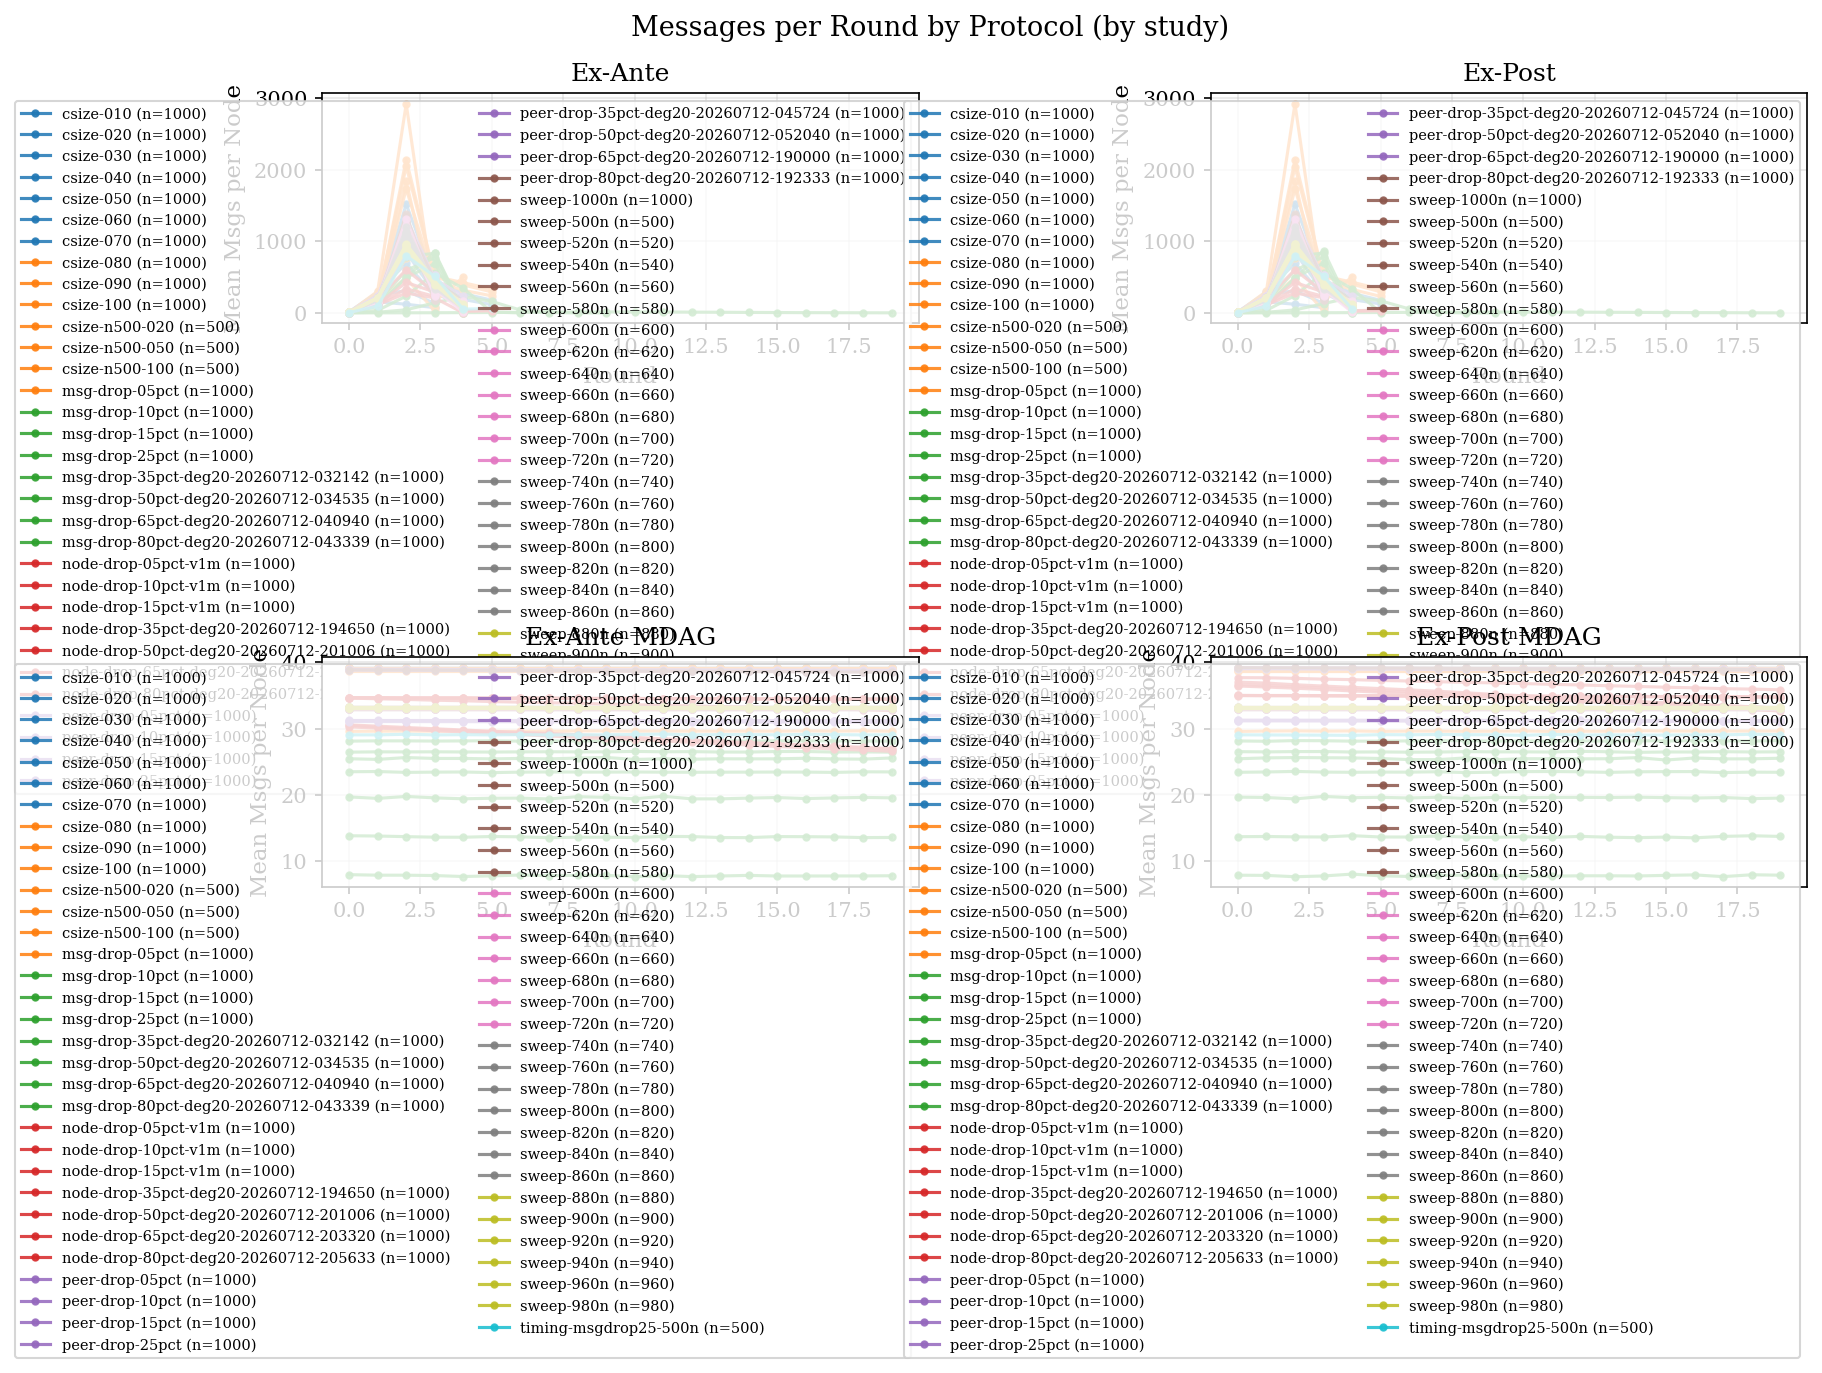

Saved: ../figures/fig_msgs_per_round.pdf


In [18]:
# Cell D — Per-Round Message Figure

# Per run × protocol: mean msgs/node per round
run_round_data = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for s in all_stats:
    sid = s["_sid"]
    for proto in PROTOCOLS:
        rounds = s.get("protocols", {}).get(proto, {}).get("total_messages", [])
        for r_idx, count in enumerate(rounds):
            run_round_data[sid][proto][r_idx].append(count)

# Group by study arm (sid prefix before '-rep-', e.g. 'sweep-1000n', 'drop-05pct'),
# not by parsed n_nodes -- keeps separate studies apart and includes non-sweep runs.
# Real node count comes from _n_nodes (falls back to log count when sid lacks it).
sid_nodes = {s["_sid"]: s["_n_nodes"] for s in all_stats}
arm_of = lambda sid: sid.split("-rep-")[0]
arms = sorted(set(arm_of(sid) for sid in run_round_data))
cmap = plt.cm.tab10(np.linspace(0, 0.9, len(arms)))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
proto_labels = {
    "exante": "Ex-Ante",
    "expost": "Ex-Post",
    "exanteMDAG": "Ex-Ante MDAG",
    "expostMDAG": "Ex-Post MDAG",
}

for ax, proto in zip(axes.flat, PROTOCOLS):
    for arm, color in zip(arms, cmap):
        sids_for_arm = [sid for sid in run_round_data if arm_of(sid) == arm]
        combined_rounds = defaultdict(list)
        for sid in sids_for_arm:
            for r_idx, vals in run_round_data[sid][proto].items():
                combined_rounds[r_idx].extend(vals)
        if combined_rounds:
            rounds = sorted(combined_rounds.keys())
            means = [np.mean(combined_rounds[r]) for r in rounds]
            n_nodes = sid_nodes[sids_for_arm[0]]
            ax.plot(rounds, means, marker='o', markersize=3, color=color,
                    label=f"{arm} (n={n_nodes})", linewidth=1.5, alpha=0.85)
    ax.set_xlabel("Round")
    ax.set_ylabel("Mean Msgs per Node")
    ax.set_title(proto_labels[proto])
    ax.legend(fontsize=7, ncol=2)

fig.suptitle("Messages per Round by Protocol (by study)", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_msgs_per_round.pdf")
plt.savefig(OUTPUT_DIR / "fig_msgs_per_round.png")
plt.show()
print(f"Saved: {OUTPUT_DIR / 'fig_msgs_per_round.pdf'}")

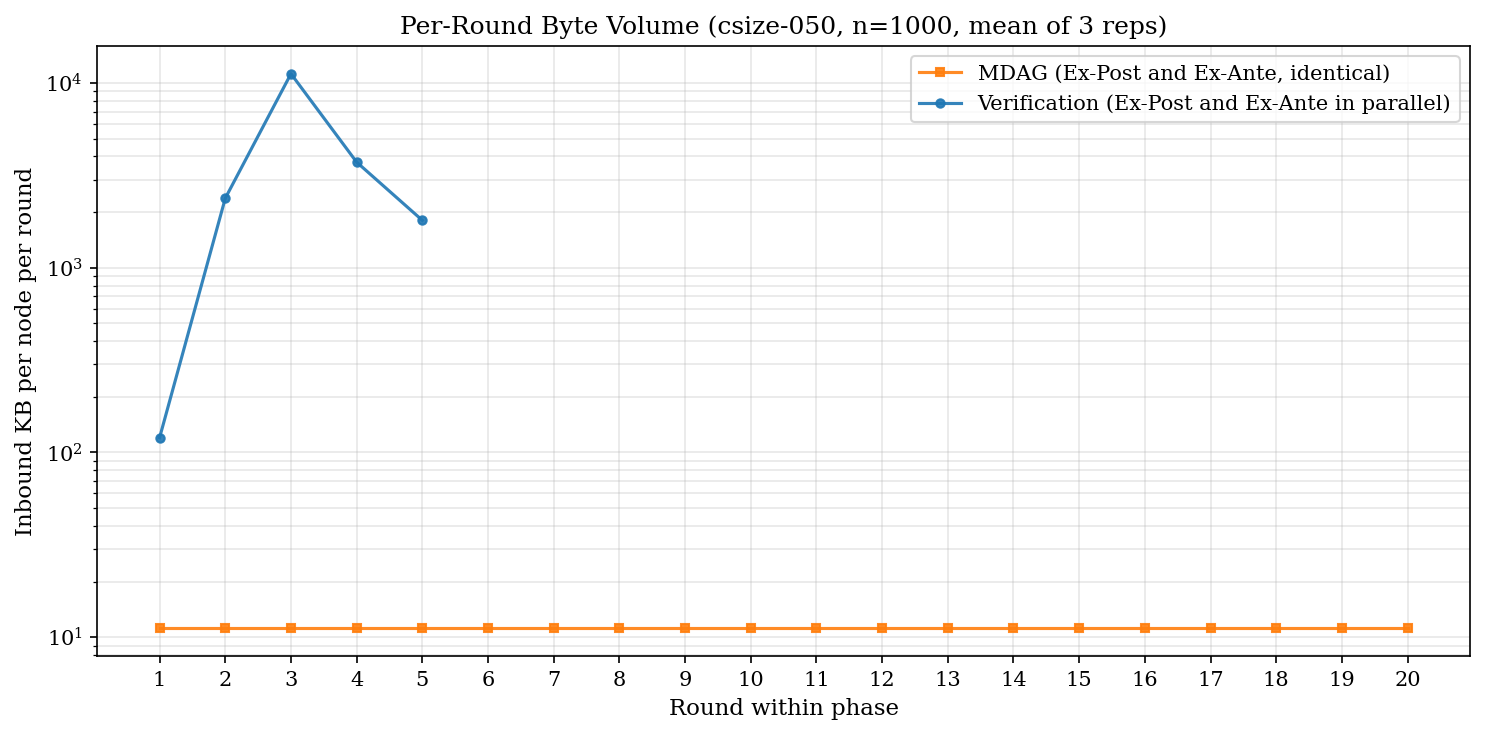

Saved: ../figures/fig_round_volume.pdf
Runs: ['csize-050-rep-01-20260720-002649', 'csize-050-rep-02-20260720-005406', 'csize-050-rep-03-20260720-012122']
Rounds: expostMDAG 20, exanteMDAG 20, verify 5
Verify-phase per-round KB/node: mean 3848, min 120, max 11212
MDAG-phase per-round KB/node: mean 11.2
Max per-round gap between the two MDAG phases: 0.000 KB/node
Sanity vs Cell I: verify_kb sum over rounds = 19238 KB (compare median_in(/exante)+median_in(/expost))


In [19]:
# Cell D2 — Per-Round Byte Volume Figure (baseline csize-050, latest reps)
# Per-round inbound bytes/node reconstructed as: mean msgs/node in round r ×
# mean bytes/msg of the protocol (bytes.by_protocol "in" summed over nodes /
# protocol total message count summed over nodes). Approximation: constant
# message size within a protocol.
# Phase schedule (synchronizer, same ordering as Cell I): ExPostMDAG ->
# ExAnteMDAG -> Verify, with /exante and /expost sharing verify round windows
# (their bytes add within a round).

BASE_ARM = "csize-050"

# Latest timestamp per rep (dedup of the 20260711/20260720 double batch)
_cand = {}
for sid in proto_byte_data:
    if not sid.startswith(BASE_ARM + "-rep-"):
        continue
    _n, _rep, _ts = parse_sid(sid)
    if _rep is None:
        continue
    if _rep not in _cand or (_ts or "") > (_cand[_rep][1] or ""):
        _cand[_rep] = (sid, _ts)
base_sids = sorted(sid for sid, _ in _cand.values())

PROTO_BYTES_KEY = {
    "exante": "/exante",
    "expost": "/expost",
    "exanteMDAG": "mdag/exanteMDAG",
    "expostMDAG": "mdag/expostMDAG",
}


def _avg_msg_bytes(sid, proto):
    """Mean inbound bytes per message for one protocol in one run."""
    b = sum(proto_byte_data[sid][PROTO_BYTES_KEY[proto]]["in"])
    m = sum(sum(vals) for vals in run_round_data[sid][proto].values())
    return b / m if m else 0.0


def _round_kb(sid, proto):
    """Per-round mean inbound KB/node for one protocol, ordered by round."""
    size = _avg_msg_bytes(sid, proto)
    rounds = sorted(run_round_data[sid][proto].keys())
    return [np.mean(run_round_data[sid][proto][r]) * size / 1024 for r in rounds]


phase_series = {"ExPost MDAG": [], "ExAnte MDAG": [], "Verify": []}
for sid in base_sids:
    phase_series["ExPost MDAG"].append(_round_kb(sid, "expostMDAG"))
    phase_series["ExAnte MDAG"].append(_round_kb(sid, "exanteMDAG"))
    ex_v, po_v = _round_kb(sid, "exante"), _round_kb(sid, "expost")
    L = max(len(ex_v), len(po_v))
    pad = lambda v: v + [0.0] * (L - len(v))
    phase_series["Verify"].append([a + b for a, b in zip(pad(ex_v), pad(po_v))])


def _mean_align(series):
    L = max(len(s) for s in series)
    return [np.mean([s[i] for s in series if i < len(s)]) for i in range(L)]


phase_means = {name: _mean_align(s) for name, s in phase_series.items()}

# Each phase is scheduled for the same R = d*D rounds, so the phases are plotted on a
# shared within-phase round axis rather than concatenated end to end. The two MDAG
# phases carry the same per-round volume, so they are drawn as a single series (their
# separation is reported in §16b and checked below).
mdag_series = [phase_means["ExPost MDAG"], phase_means["ExAnte MDAG"]]
_mdag_len = max(len(s) for s in mdag_series)
mdag_mean = [np.mean([s[i] for s in mdag_series if i < len(s)]) for i in range(_mdag_len)]
_mdag_gap = max(abs(a - b) for a, b in zip(*mdag_series)) if len(set(map(len, mdag_series))) == 1 else float("nan")

# CVD-validated palette (blue/orange); marker shape = secondary encoding
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(mdag_mean) + 1), mdag_mean, marker="s", markersize=4,
        linewidth=1.5, color="#ff7f0e", alpha=0.9,
        label="MDAG (Ex-Post and Ex-Ante, identical)")
ax.plot(range(1, len(phase_means["Verify"]) + 1), phase_means["Verify"], marker="o",
        markersize=4, linewidth=1.5, color="#1f77b4", alpha=0.9,
        label="Verification (Ex-Post and Ex-Ante in parallel)")
ax.set_yscale("log")
ax.set_xticks(range(1, len(mdag_mean) + 1))
ax.set_xlabel("Round within phase")
ax.set_ylabel("Inbound KB per node per round")
ax.set_title(f"Per-Round Byte Volume ({BASE_ARM}, n=1000, mean of {len(base_sids)} reps)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_round_volume.pdf")
plt.savefig(OUTPUT_DIR / "fig_round_volume.png")
plt.show()
print(f"Saved: {OUTPUT_DIR / 'fig_round_volume.pdf'}")

verify_kb = phase_means["Verify"]
mdag_kb = phase_means["ExPost MDAG"] + phase_means["ExAnte MDAG"]
print(f"Runs: {base_sids}")
print(f"Rounds: expostMDAG {len(phase_means['ExPost MDAG'])}, "
      f"exanteMDAG {len(phase_means['ExAnte MDAG'])}, verify {len(verify_kb)}")
print(f"Verify-phase per-round KB/node: mean {np.mean(verify_kb):.0f}, "
      f"min {min(verify_kb):.0f}, max {max(verify_kb):.0f}")
print(f"MDAG-phase per-round KB/node: mean {np.mean(mdag_kb):.1f}")
print(f"Max per-round gap between the two MDAG phases: {_mdag_gap:.3f} KB/node")
print(f"Sanity vs Cell I: verify_kb sum over rounds = {sum(verify_kb):.0f} KB "
      f"(compare median_in(/exante)+median_in(/expost))")


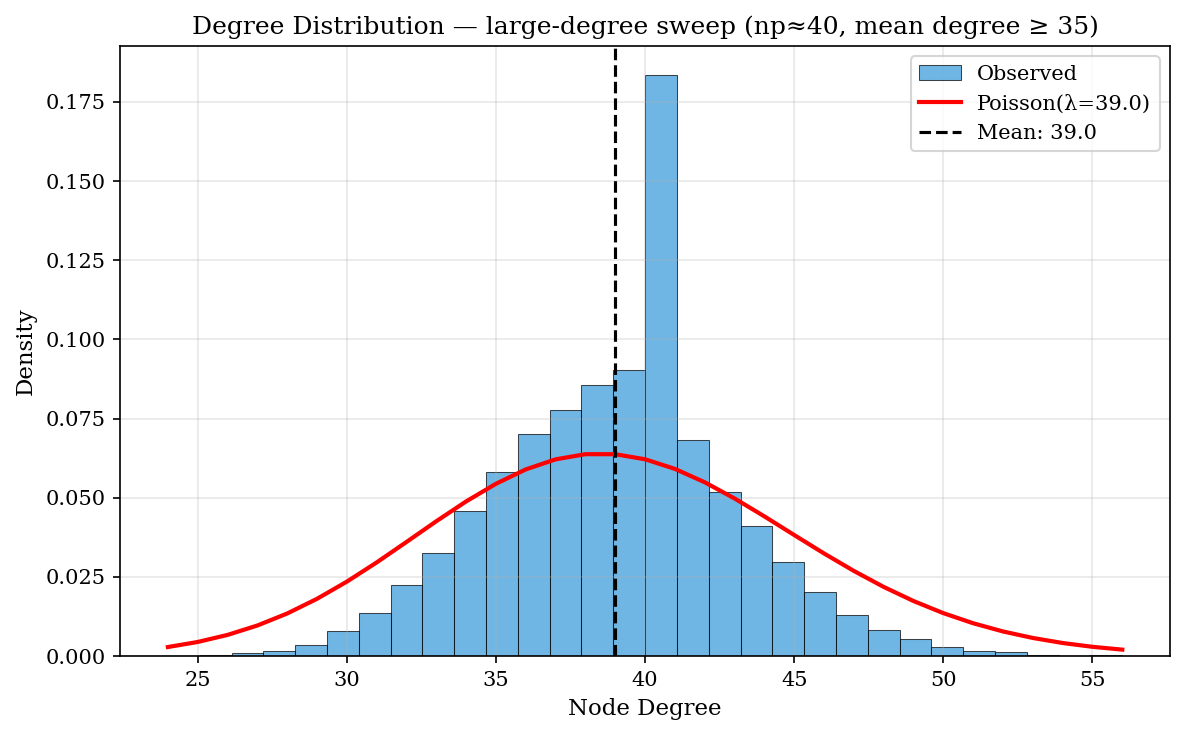

Saved: ../figures/fig_degree_hist.pdf  (26 sweep runs, mean degree 39.0)


In [20]:
# Cell E — Degree Distribution Figure
# Restricted to the clean large-degree (np=40) sweep runs. Pooling all studies mixed
# two degree regimes (deg~31 old sweep + deg~39 new sweep) with degraded node-drop
# graphs under one Poisson fit, which is meaningless. DEG_MIN isolates the np=40 regime.
DEG_MIN = 35
clean_sweep_sids = set(
    graph_df[(graph_df["sid"].str.startswith("sweep-"))
             & (graph_df["deg_mean"] >= DEG_MIN)]["sid"]
)

all_degrees_all = []
for sid in clean_sweep_sids:
    g = per_run_graphs[sid]
    all_degrees_all.extend([d for _, d in g.degree()])

if not all_degrees_all:
    print(f"No sweep runs with mean degree >= {DEG_MIN} — skipping degree histogram.")
else:
    mean_deg_all = float(np.mean(all_degrees_all))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(all_degrees_all, bins=30, color='#3498db', alpha=0.7,
            edgecolor='black', linewidth=0.5, density=True, label='Observed')
    x_range = np.arange(min(all_degrees_all), max(all_degrees_all) + 1)
    ax.plot(x_range, poisson.pmf(x_range, mean_deg_all), 'r-', linewidth=2,
            label=f'Poisson(λ={mean_deg_all:.1f})')
    ax.axvline(mean_deg_all, color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {mean_deg_all:.1f}')
    ax.set_xlabel('Node Degree')
    ax.set_ylabel('Density')
    ax.set_title('Degree Distribution — large-degree sweep (np≈40, mean degree ≥ '
                 f'{DEG_MIN})')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig_degree_hist.pdf")
    plt.savefig(OUTPUT_DIR / "fig_degree_hist.png")
    plt.show()
    print(f"Saved: {OUTPUT_DIR / 'fig_degree_hist.pdf'}  "
          f"({len(clean_sweep_sids)} sweep runs, mean degree {mean_deg_all:.1f})")

Average degree across large-degree sweep runs (deg>=35): 39.0  (26 runs, np=40 setting)
### Communication vs Network Size
|   n_nodes |   median_MB |   median_msgs |   fitted_MB |   fitted_msgs |
|----------:|------------:|--------------:|------------:|--------------:|
|    500.00 |       20.69 |       5584.82 |       19.33 |       5310.00 |
|    520.00 |       18.58 |       5099.03 |       19.53 |       5315.00 |
|    540.00 |       21.64 |       5735.44 |       19.72 |       5319.00 |
|    560.00 |       22.29 |       5831.17 |       19.91 |       5323.00 |
|    580.00 |       18.11 |       4879.00 |       20.09 |       5327.00 |
|    600.00 |       20.57 |       5414.41 |       20.27 |       5331.00 |
|    620.00 |       18.43 |       4909.21 |       20.44 |       5334.00 |
|    640.00 |       22.11 |       5679.77 |       20.61 |       5338.00 |
|    660.00 |       21.50 |       5520.74 |       20.78 |       5341.00 |
|    680.00 |       20.64 |       5294.31 |       20.94 |       

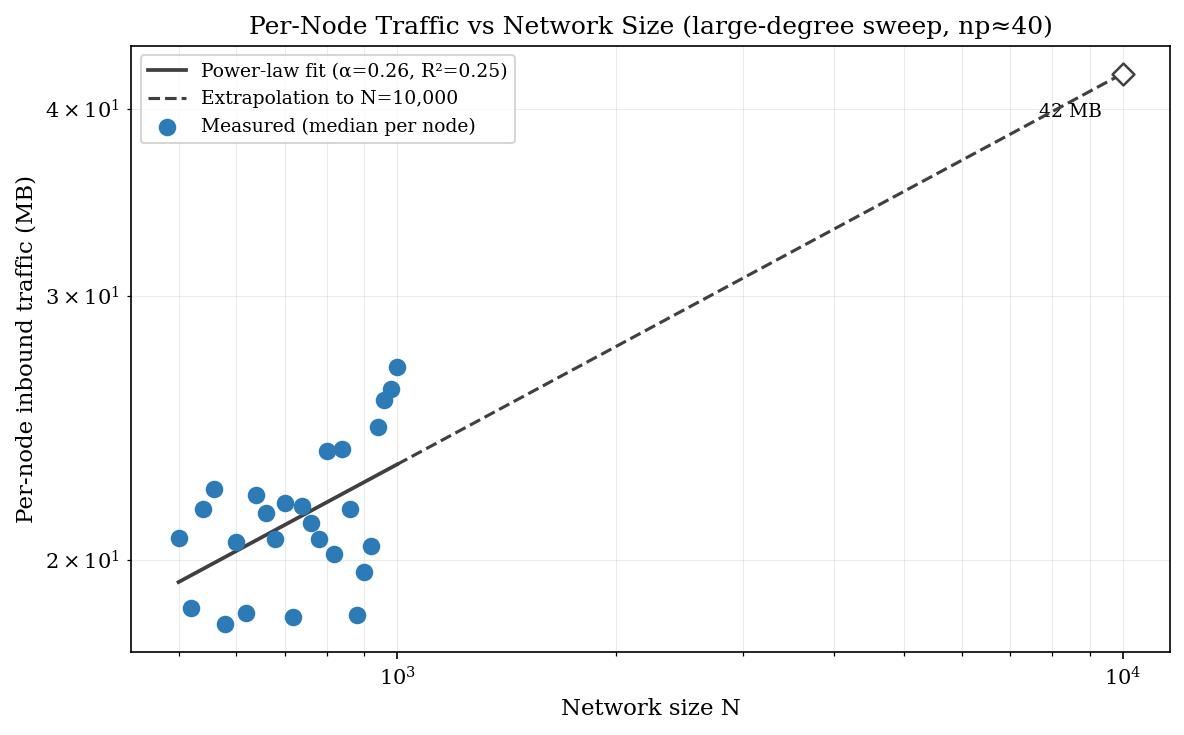

Saved: ../figures/fig_scaling.pdf


In [21]:
# Cell G — Communication Scaling with N
from scipy.stats import linregress

# The scaling fit must use ONE degree regime. The sweep archives contain two batches:
# the old deg~31 runs and the new deg~39 (np=40 'large degree') runs the reviewer wants
# (disconnection prob < 2^-40, diameter <= 4 whp). Pooling them blends the average degree
# (~33) and duplicates each N (two rep-01 runs per size), corrupting the power-law fit.
# Isolate the large-degree regime by measured mean degree; this also de-dups, since only
# the new batch clears the threshold. This is de-contamination, not data exclusion.
DEG_MIN = 35
clean_sweep_sids = set(
    graph_df[(graph_df["sid"].str.startswith("sweep-"))
             & (graph_df["deg_mean"] >= DEG_MIN)]["sid"]
)

sweep_bytes_df = bytes_df[bytes_df["sid"].isin(clean_sweep_sids)]
bytes_by_n = sweep_bytes_df.groupby("n_nodes")["median_total_in_MB"].median().reset_index()
bytes_by_n.columns = ["n_nodes", "median_MB"]

# Total per-node msgs across all 4 protocols, grouped by n_nodes (large-degree sweep only)
msg_by_sid_rows = []
for sid in node_msg_data:
    if sid not in clean_sweep_sids:
        continue
    n_nodes_cfg, rep, ts = parse_sid(sid)
    total = sum(float(np.mean(node_msg_data[sid][p])) for p in PROTOCOLS if node_msg_data[sid][p])
    msg_by_sid_rows.append({"n_nodes": n_nodes_cfg, "total_msgs": total})
msg_by_n = pd.DataFrame(msg_by_sid_rows).groupby("n_nodes")["total_msgs"].median().reset_index()
msg_by_n.columns = ["n_nodes", "median_msgs"]

scaling_df = bytes_by_n.merge(msg_by_n, on="n_nodes")

# Application-only per-node inbound MB (median over nodes, then median over runs per n).
# The total above includes the Kademlia discovery traffic, which is linear in n, so a
# separate fit on application bytes isolates the protocol's own growth.
app_rows = []
for sid in clean_sweep_sids:
    d = byte_summary_data.get(sid)
    if d and d["app_in"]:
        app_rows.append({"n_nodes": d["n_nodes"],
                         "median_app_MB": bytes_to_mb(np.median(d["app_in"]))})
app_by_n = pd.DataFrame(app_rows).groupby("n_nodes")["median_app_MB"].median().reset_index()

# Record the actual average degree of the large-degree sweep runs so the report can
# confirm the np=40 setting (should land ~39, not the ~33 blend of the two batches).
sweep_deg = graph_df[graph_df["sid"].isin(clean_sweep_sids)]["deg_mean"]
sweep_mean_degree = float(sweep_deg.mean()) if not sweep_deg.empty else None
if sweep_mean_degree is not None:
    print(f"Average degree across large-degree sweep runs (deg>={DEG_MIN}): "
          f"{sweep_mean_degree:.1f}  ({len(clean_sweep_sids)} runs, np=40 setting)")

if len(scaling_df) < 2:
    print("### Communication vs Network Size")
    print(f"Only {len(scaling_df)} network size(s) with byte data — need ≥2 distinct N for a scaling fit. Skipping cross-N analysis.")
else:
    ns = scaling_df["n_nodes"].values.astype(float)
    mbs = scaling_df["median_MB"].values
    msgs = scaling_df["median_msgs"].values

    alpha_bytes, beta_bytes, r_bytes, _, _ = linregress(np.log(ns), np.log(mbs))
    alpha_msgs,  beta_msgs,  r_msgs,  _, _ = linregress(np.log(ns), np.log(msgs))

    alpha_app = r_app = None
    if len(app_by_n) >= 2:
        alpha_app, beta_app, r_app, _, _ = linregress(
            np.log(app_by_n["n_nodes"].values.astype(float)),
            np.log(app_by_n["median_app_MB"].values))

    scaling_df["fitted_MB"]   = (np.exp(beta_bytes) * ns ** alpha_bytes).round(4)
    scaling_df["fitted_msgs"] = (np.exp(beta_msgs)  * ns ** alpha_msgs).round(0)

    print("### Communication vs Network Size")
    print(tabulate(scaling_df, headers="keys", tablefmt="pipe", showindex=False, floatfmt=".2f"))
    print()
    print(f"Power-law fit: bytes α={alpha_bytes:.3f} (R²={r_bytes**2:.3f}),  msgs α={alpha_msgs:.3f} (R²={r_msgs**2:.3f})")
    if alpha_app is not None:
        print(f"App-only fit:  bytes α_app={alpha_app:.3f} (R²={r_app**2:.3f})")

    # Extrapolation to 10,000 parties is a supervisor deliverable (email 2), so print it
    # even when the fit is weak, flagged as low-confidence, instead of suppressing it.
    fit_reliable = (np.isfinite(r_bytes) and np.isfinite(alpha_bytes)
                    and alpha_bytes > 0 and r_bytes**2 >= 0.5)
    if not fit_reliable:
        print()
        print(f"NOTE: low-confidence fit (R²={r_bytes**2:.2f} < 0.5; N range {int(ns.min())}-{int(ns.max())}, one run per size).")
        print("  Noise dominates the per-node signal at this scale — treat the extrapolation below")
        print("  as an order-of-magnitude estimate, not a measurement.")

    extrap_ns = [1000, 2000, 5000, 10000]
    extrap_rows = []
    for n in extrap_ns:
        extrap_rows.append({
            "N": n,
            "extrap_MB_per_node": round(np.exp(beta_bytes) * n ** alpha_bytes, 2),
            "extrap_msgs_per_node": int(round(np.exp(beta_msgs) * n ** alpha_msgs)),
        })
    extrap_df = pd.DataFrame(extrap_rows)
    print("\n### Extrapolation (power-law fit)")
    print(tabulate(extrap_df, headers="keys", tablefmt="pipe", showindex=False))

    # Plot: single bytes panel (message counts are not a report deliverable).
    # Solid fit over the measured range, dashed extension to N=10,000.
    fig, ax = plt.subplots(figsize=(8, 5))
    ns_meas = np.logspace(np.log10(ns.min()), np.log10(ns.max()), 100)
    ns_ext  = np.logspace(np.log10(ns.max()), np.log10(10000), 100)
    ax.plot(ns_meas, np.exp(beta_bytes) * ns_meas ** alpha_bytes, color="#404040",
            linewidth=1.8, zorder=4,
            label=f"Power-law fit (α={alpha_bytes:.2f}, R²={r_bytes**2:.2f})")
    ax.plot(ns_ext, np.exp(beta_bytes) * ns_ext ** alpha_bytes, color="#404040",
            linewidth=1.5, linestyle="--", zorder=4, label="Extrapolation to N=10,000")
    ax.scatter(ns, mbs, color="#2c7bb6", s=55, zorder=5, label="Measured (median per node)")
    extrap_1e4_MB = float(np.exp(beta_bytes) * 10000 ** alpha_bytes)
    ax.scatter([10000], [extrap_1e4_MB], marker="D", s=55, facecolor="white",
               edgecolor="#404040", linewidth=1.2, zorder=5)
    ax.annotate(f"{extrap_1e4_MB:.0f} MB", xy=(10000, extrap_1e4_MB),
                xytext=(-10, -14), textcoords="offset points", ha="right", va="top", fontsize=9)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)
    ax.set_xlabel("Network size N")
    ax.set_ylabel("Per-node inbound traffic (MB)")
    ax.set_title("Per-Node Traffic vs Network Size (large-degree sweep, np≈40)")
    ax.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig_scaling.pdf")
    plt.savefig(OUTPUT_DIR / "fig_scaling.png")
    plt.show()
    print(f"Saved: {OUTPUT_DIR / 'fig_scaling.pdf'}")


### Verification-Phase Traffic vs Committee Size
| sid                                          |   committee_size |   median_total_in_MB |   verif_in_MB |   nonverif_MB | is_sweep   | is_csize   |
|:---------------------------------------------|-----------------:|---------------------:|--------------:|--------------:|:-----------|:-----------|
| csize-010-rep-03-20260719-195426             |                4 |                 6.61 |          1.43 |          5.18 | False      | True       |
| csize-010-rep-01-20260719-190000             |                6 |                 7.32 |          2.15 |          5.17 | False      | True       |
| msg-drop-80pct-deg20-20260712-043339         |                8 |                 6.06 |          1.23 |          4.83 | False      | False      |
| csize-010-rep-02-20260719-192713             |               14 |                10.24 |          5.06 |          5.18 | False      | True       |
| csize-020-rep-03-20260719-211607             |         

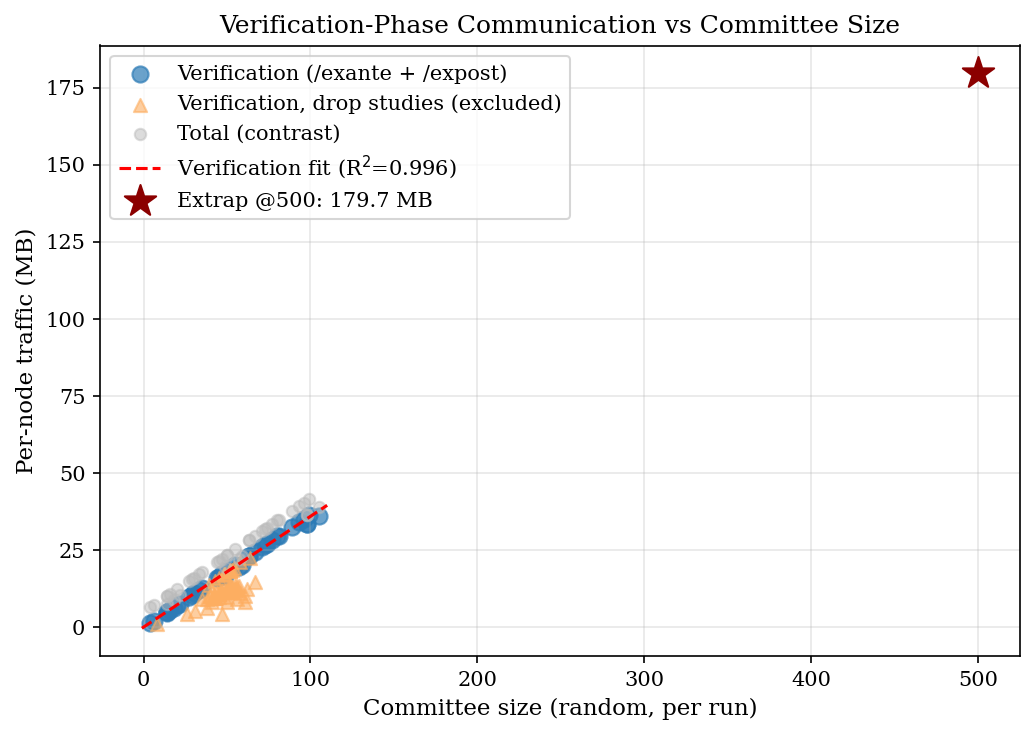

Saved: ../figures/fig_committee_scaling.pdf


In [22]:
# Cell H — Committee Size vs Verification-Phase Communication
# Supervisor (email 2): communication in the *verification phase* should be linear in
# the committee size; the goal is extrapolation to committee_size=500 (2^{-40} honest
# majority when 2/3 of the population is honest).
# Committee sizes here are randomly drawn (~4-105) by the stochastic committee selection.
# Regressing *total* traffic on committee size buries the committee signal under
# graph-building + MDAG + libp2p/DHT overhead that is committee-independent (and varies
# with N across sweep runs), so the primary fit uses verification-phase wire bytes only
# (/exante + /expost). Per-node verification traffic is ~N-independent at constant
# average degree, so pooling runs with different N is safe for this fit.

# Per-sid verification-phase traffic: median per-node in-MB of /exante + /expost
verif_rows = []
for sid, protos in sorted(proto_byte_data.items()):
    ex_in = protos.get("/exante", {}).get("in", [])
    ep_in = protos.get("/expost", {}).get("in", [])
    if not ex_in and not ep_in:
        continue
    verif_mb = bytes_to_mb(
        (np.median(ex_in) if ex_in else 0) + (np.median(ep_in) if ep_in else 0))
    verif_rows.append({"sid": sid, "verif_in_MB": round(verif_mb, 3)})
verif_df = pd.DataFrame(verif_rows)

comm_size_df = (
    committee_df[["sid", "committee_size"]]
    .merge(bytes_df[["sid", "median_total_in_MB"]], on="sid")
    .merge(verif_df, on="sid", how="left")
)
comm_size_df["nonverif_MB"] = (
    comm_size_df["median_total_in_MB"] - comm_size_df["verif_in_MB"])

# Primary fit: the dedicated csize-* study runs (designed committee 10..100 at n=1000
# plus csize-n500-{20,50,100} at n=500,
# observed ~4-105). Fallback when they haven't run yet: sweep runs only, whose committee
# sizes are the stochastic ~40-63 draw (fit over noise; flagged in fit_label). Drop-study
# runs (msg/node/peer-drop) are never used: injected faults add retransmission noise.
comm_size_df["is_sweep"] = comm_size_df["sid"].str.startswith("sweep-")
comm_size_df["is_csize"] = comm_size_df["sid"].str.startswith("csize-")

unique_csizes = sorted(comm_size_df["committee_size"].unique())
if len(unique_csizes) <= 1 or comm_size_df["verif_in_MB"].isna().all():
    print(f"Committee size constant ({unique_csizes[0]}) across all runs, "
          "or no per-protocol byte data.")
    slope_v = intercept_v = r2_v = r2_total = None
    extrap_500_verif_MB = extrap_500_total_MB = None
    nonverif_MB_med = mean_committee_obs = None
else:
    sub = comm_size_df.dropna(subset=["verif_in_MB"])
    csize_sub = sub[sub["is_csize"]]
    # De-dup reruns of the same study run (sid prefix incl. network size, rep) -- keep the
    # latest timestamp so a rerun supersedes the older date (e.g. csize-050 20260711 ->
    # 20260720), otherwise the doubled size-50 rows over-weight the fit. The prefix keeps
    # csize-050 (n=1000) and csize-n500-050 (n=500) distinct, so pooling both n is preserved.
    if not csize_sub.empty:
        keyed = csize_sub.copy()
        keyed["_dc"] = keyed["sid"].str.replace(r"-rep-\d+-.+$", "", regex=True)
        keyed["_rep"] = keyed["sid"].map(lambda x: parse_sid(x)[1])
        keyed["_ts"] = keyed["sid"].map(lambda x: parse_sid(x)[2] or "")
        csize_sub = (keyed.sort_values("_ts")
                     .drop_duplicates(["_dc", "_rep"], keep="last")
                     .drop(columns=["_dc", "_rep", "_ts"]))
    sweep_sub = sub[sub["is_sweep"]]
    if len(csize_sub) >= 3 and csize_sub["committee_size"].nunique() > 1:
        fit_label = (f"csize-* study runs (n={len(csize_sub)}, observed committee sizes "
                     f"{int(csize_sub['committee_size'].min())}-{int(csize_sub['committee_size'].max())})")
        fit_sub = csize_sub
    elif len(sweep_sub) >= 3 and sweep_sub["committee_size"].nunique() > 1:
        fit_label = (f"sweep runs only (n={len(sweep_sub)}) — csize-* study not in results yet; "
                     "fit spans only the stochastic ~40-63 committee spread, treat as provisional")
        fit_sub = sweep_sub
    else:
        fit_label = f"all runs (n={len(sub)}) — too few sweep/csize runs for a clean fit"
        fit_sub = sub
    csizes = fit_sub["committee_size"].values.astype(float)
    verif_mbs = fit_sub["verif_in_MB"].values
    total_mbs = fit_sub["median_total_in_MB"].values

    slope_v, intercept_v, r_v, _, _ = linregress(csizes, verif_mbs)
    r2_v = r_v ** 2
    # Contrast fit on the total: kept to show why verification-only is the right target
    slope_t, intercept_t, r_t, _, _ = linregress(csizes, total_mbs)
    r2_total = r_t ** 2

    mean_committee_obs = float(fit_sub["committee_size"].mean())
    nonverif_MB_med = float(fit_sub["nonverif_MB"].median())
    extrap_500_verif_MB = slope_v * 500 + intercept_v
    extrap_500_total_MB = extrap_500_verif_MB + nonverif_MB_med

    print("### Verification-Phase Traffic vs Committee Size")
    print(tabulate(sub.sort_values("committee_size"),
                   headers="keys", tablefmt="pipe", showindex=False, floatfmt=".2f"))
    print()
    print(f"Fit population: {fit_label}")
    print(f"Verification fit: verif_MB = {slope_v:.4f} x committee_size + "
          f"{intercept_v:.4f}   R^2 = {r2_v:.4f}")
    print(f"(contrast) total-traffic fit R^2 = {r2_total:.4f} "
          "-- committee-independent overhead dilutes the signal")
    print()
    extrap_mult = 500 / max(csizes)
    print(f"Extrapolation to committee_size=500 stretches ~{extrap_mult:.0f}x beyond the observed "
          f"range {int(min(csizes))}-{int(max(csizes))};")
    print("verification communication is linear in committee size by protocol design, "
          "so linearity is the")
    print("theoretically expected shape (supervisor email 2).")
    print()
    print(f"Extrapolated verification traffic @500:     {extrap_500_verif_MB:.2f} MB/node")
    print(f"+ committee-independent traffic (median):   {nonverif_MB_med:.2f} MB/node")
    print(f"= estimated total per-node traffic @500:    {extrap_500_total_MB:.2f} MB")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(csizes, verif_mbs, color="#2c7bb6", s=60, alpha=0.7,
               label="Verification (/exante + /expost)")
    drop_sub = sub[~sub["is_sweep"] & ~sub["is_csize"]]
    if not drop_sub.empty:
        ax.scatter(drop_sub["committee_size"], drop_sub["verif_in_MB"], color="#fdae61",
                   s=40, alpha=0.6, marker="^", label="Verification, drop studies (excluded)")
    ax.scatter(csizes, total_mbs, color="#bbbbbb", s=30, alpha=0.5, label="Total (contrast)")
    cs_range = np.linspace(min(csizes) - 5, max(csizes) + 5, 100)
    ax.plot(cs_range, slope_v * cs_range + intercept_v, 'r--', linewidth=1.5,
            label=f"Verification fit (R$^2$={r2_v:.3f})")
    ax.scatter([500], [extrap_500_verif_MB], marker='*', s=250, color='darkred', zorder=6,
               label=f"Extrap @500: {extrap_500_verif_MB:.1f} MB")
    ax.set_xlabel("Committee size (random, per run)")
    ax.set_ylabel("Per-node traffic (MB)")
    ax.set_title("Verification-Phase Communication vs Committee Size")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig_committee_scaling.pdf")
    plt.savefig(OUTPUT_DIR / "fig_committee_scaling.png")
    plt.show()
    print(f"Saved: {OUTPUT_DIR / 'fig_committee_scaling.pdf'}")

In [23]:
# Cell I — WAN Round Time Estimate (per-phase model)
# Ref: arxiv:2303.02514 — 75% of WAN messages arrive within ~160 ms. The msg-drop runs
# show consensus survives >=25% message loss, so a 160 ms (p75) round budget gives the
# 1-eps success probability the supervisor's estimate calls for (email 2).
#
# Phase schedule (committee-sampling internal/synchronizer/synchronizer.go,
# CalculateStartTimes): GraphBuilding -> ExPostMDAG (R rounds) -> ExAnteMDAG (R rounds)
# -> ExPostVerify || ExAnteVerify (R rounds, same round window — both verify phases
# start at exPostVerifyTime). Wall-clock protocol rounds are therefore the SUM of the
# three sequential phase windows, NOT the max across protocols (the earlier version of
# this cell took the max and undercounted latency ~3x). Graph discovery/building is
# excluded: one-off DHT bootstrap, /graph bytes ~ 0.004 MB.
#
# Per phase: round_ms = WAN_LATENCY_MS + phase_round_bytes / bandwidth, where
# phase_round_bytes = (median per-node wire-in bytes of the phase's protocols) / rounds.
# The two verify protocols share round windows, so their bytes add within a round.
#
# Two totals per bandwidth: total_s counts only the rounds that carried traffic
# (verification converges in ~5 of its R_SCHED=20 scheduled windows), i.e. assumes
# early phase termination; total_s_sched additionally costs the empty verify windows
# at one latency each (they carry no bytes), matching the fixed synchronizer schedule
# and the Cell J / tab:joint_wan model (R windows with the phase bytes spread over
# them cost R*latency + bytes/bandwidth regardless of how many windows carry traffic).

WAN_LATENCY_MS = 160
BW_SCENARIOS = [("10 Mbps", 10), ("100 Mbps", 100), ("1 Gbps", 1000)]
R_SCHED = 20  # scheduled round windows per phase (R = d*D, synchronizer)


def _phase_rounds(sid, proto):
    d = run_round_data.get(sid, {}).get(proto, {})
    return (max(d.keys()) + 1) if d else 0


def _med_in_bytes(sid, proto_key):
    vals = proto_byte_data.get(sid, {}).get(proto_key, {}).get("in", [])
    return float(np.median(vals)) if vals else 0.0


wan_rows = []
for sid in sorted(proto_byte_data.keys()):
    n_nodes_cfg, rep, ts = parse_sid(sid)
    phases = [
        ("expostMDAG", _med_in_bytes(sid, "mdag/expostMDAG"), _phase_rounds(sid, "expostMDAG")),
        ("exanteMDAG", _med_in_bytes(sid, "mdag/exanteMDAG"), _phase_rounds(sid, "exanteMDAG")),
        ("verify",
         _med_in_bytes(sid, "/exante") + _med_in_bytes(sid, "/expost"),
         max(_phase_rounds(sid, "exante"), _phase_rounds(sid, "expost"))),
    ]
    phases = [(name, b, r) for name, b, r in phases if r > 0]
    if not phases:
        continue

    rounds_total = sum(r for _, _, r in phases)
    verify_bytes, verify_rounds = next(
        ((b, r) for name, b, r in phases if name == "verify"), (0.0, 0))
    row = {
        "sid": sid,
        "n_nodes": n_nodes_cfg if n_nodes_cfg is not None else sid_nodes.get(sid),
        "rounds_total": rounds_total,
        "verify_round_KB": round(verify_bytes / verify_rounds / 1024, 1) if verify_rounds else 0.0,
    }
    empty_verify_windows = max(0, R_SCHED - verify_rounds) if verify_rounds else 0
    for bw_label, bw_mbps in BW_SCENARIOS:
        bw_Bps = bw_mbps * 1e6 / 8
        total_ms = 0.0
        verify_round_ms = None
        for name, phase_bytes, r in phases:
            per_round_bytes = phase_bytes / r
            round_ms = WAN_LATENCY_MS + per_round_bytes / bw_Bps * 1000
            total_ms += r * round_ms
            if name == "verify":
                verify_round_ms = round_ms
        row[f"round_ms@{bw_label}"] = round(verify_round_ms, 1) if verify_round_ms else None
        row[f"total_s@{bw_label}"] = round(total_ms / 1000, 2)
        row[f"total_s_sched@{bw_label}"] = round(
            (total_ms + empty_verify_windows * WAN_LATENCY_MS) / 1000, 2)
    wan_rows.append(row)

wan_df = pd.DataFrame(wan_rows)
print("### WAN Round Time Estimate (per-phase; round_ms = verify phase, the heaviest)")
print(f"Latency: {WAN_LATENCY_MS} ms (p75 WAN, ref: arxiv:2303.02514; consistent with the")
print("msg-drop runs still reaching consensus at 25% message loss)")
print()
show_cols = ["sid", "n_nodes", "rounds_total", "verify_round_KB",
             "round_ms@10 Mbps",  "total_s@10 Mbps",  "total_s_sched@10 Mbps",
             "round_ms@100 Mbps", "total_s@100 Mbps", "total_s_sched@100 Mbps",
             "round_ms@1 Gbps",   "total_s@1 Gbps",   "total_s_sched@1 Gbps"]
print(tabulate(wan_df[show_cols], headers="keys", tablefmt="pipe", showindex=False, floatfmt=".1f"))

for _bw in ["10 Mbps", "100 Mbps", "1 Gbps"]:
    print(f"Median total protocol time @ {_bw} WAN: "
          f"{wan_df[f'total_s@{_bw}'].median():.1f}s "
          f"(full schedule: {wan_df[f'total_s_sched@{_bw}'].median():.1f}s)")


### WAN Round Time Estimate (per-phase; round_ms = verify phase, the heaviest)
Latency: 160 ms (p75 WAN, ref: arxiv:2303.02514; consistent with the
msg-drop runs still reaching consensus at 25% message loss)

| sid                                          |   n_nodes |   rounds_total |   verify_round_KB |   round_ms@10 Mbps |   total_s@10 Mbps |   total_s_sched@10 Mbps |   round_ms@100 Mbps |   total_s@100 Mbps |   total_s_sched@100 Mbps |   round_ms@1 Gbps |   total_s@1 Gbps |   total_s_sched@1 Gbps |
|:---------------------------------------------|----------:|---------------:|------------------:|-------------------:|------------------:|------------------------:|--------------------:|-------------------:|-------------------------:|------------------:|-----------------:|-----------------------:|
| csize-010-rep-01-20260719-190000             |      1000 |             44 |             550.0 |              610.6 |               9.2 |                    11.8 |               205.1 |       

In [24]:
# Cell J — Joint Extrapolation: N=10,000 parties, committee_size=500
# Supervisor target (email 2): "The goal is to extrapolate to 10000 parties and
# committees of 500 (this size committee guarantees that if 2/3 of the population is
# honest, the committee has an honest majority except with probability 2^{-40})".
# Combines the two orthogonal fits:
#   - Cell G: power-law fit of total per-node traffic vs N (constant average degree)
#   - Cell H: linear fit of verification-phase traffic vs committee size
# total(N=10^4, k=500) ~ total(N=10^4, k~observed mean) + slope_v * (500 - k_obs_mean):
# the N fit already carries the observed (small) committees, so only the committee
# delta is added on top.

joint_ok = (
    "alpha_bytes" in dir() and np.isfinite(alpha_bytes) and alpha_bytes > 0
    and "slope_v" in dir() and slope_v is not None
)
if not joint_ok:
    print("Joint extrapolation skipped — needs the N power-law fit (Cell G) and")
    print("a committee-size fit (Cell H).")
    joint_total_MB = None
else:
    total_1e4_MB = float(np.exp(beta_bytes) * 10000 ** alpha_bytes)
    delta_verif_MB = slope_v * (500 - mean_committee_obs)
    joint_total_MB = total_1e4_MB + delta_verif_MB

    # Same policy as Cell G: a weak N fit downgrades confidence, it does not suppress
    # the supervisor-requested estimate.
    if "fit_reliable" in dir() and not fit_reliable:
        print(f"NOTE: low-confidence estimate — the N power-law fit is weak (R²={r_bytes**2:.2f} < 0.5),")
        print("  so the joint figure inherits that uncertainty. Treat it as an order-of-magnitude")
        print("  estimate, not a measurement.")
        print()

    print("### Estimated per-node traffic at N=10,000, committee_size=500")
    print(f"  total(N=10^4) from power law (k~{mean_committee_obs:.0f}): {total_1e4_MB:.2f} MB")
    print(f"  + verification delta slope_v*(500-{mean_committee_obs:.0f}):   {delta_verif_MB:.2f} MB")
    print(f"  = {joint_total_MB:.2f} MB per node")

    # WAN wall time at that scale: verification round bytes grow with committee size,
    # MDAG phases are committee-independent (medians across runs). Rounds per phase R
    # from the observed round data.
    per_sid_R = []
    for sid in run_round_data:
        rs = [max(d.keys()) + 1 for d in run_round_data[sid].values() if d]
        if rs:
            per_sid_R.append(max(rs))
    R_med = int(np.median(per_sid_R)) if per_sid_R else 20

    mdag_bytes_med = float(np.median([
        _med_in_bytes(sid, "mdag/expostMDAG") + _med_in_bytes(sid, "mdag/exanteMDAG")
        for sid in proto_byte_data
    ]))
    verif_500_bytes = (slope_v * 500 + intercept_v) * 1024 * 1024

    joint_time_rows = []
    for bw_label, bw_mbps in BW_SCENARIOS:
        bw_Bps = bw_mbps * 1e6 / 8
        # two sequential MDAG phases: 2R latency ticks + all MDAG bytes through the pipe
        mdag_ms = 2 * R_med * WAN_LATENCY_MS + mdag_bytes_med / bw_Bps * 1000
        verify_round_ms = WAN_LATENCY_MS + verif_500_bytes / R_med / bw_Bps * 1000
        total_s = (mdag_ms + R_med * verify_round_ms) / 1000
        joint_time_rows.append({
            "bandwidth": bw_label,
            "verify_round_ms": round(verify_round_ms, 1),
            "total_s": round(total_s, 1),
        })
    joint_time_df = pd.DataFrame(joint_time_rows)
    print()
    print(f"### Estimated protocol wall time at N=10,000, committee=500 "
          f"(R={R_med} rounds/phase)")
    print(tabulate(joint_time_df, headers="keys", tablefmt="pipe", showindex=False))


NOTE: low-confidence estimate — the N power-law fit is weak (R²=0.25 < 0.5),
  so the joint figure inherits that uncertainty. Treat it as an order-of-magnitude
  estimate, not a measurement.

### Estimated per-node traffic at N=10,000, committee_size=500
  total(N=10^4) from power law (k~53): 42.26 MB
  + verification delta slope_v*(500-53):   160.61 MB
  = 202.88 MB per node

### Estimated protocol wall time at N=10,000, committee=500 (R=20 rounds/phase)
| bandwidth   |   verify_round_ms |   total_s |
|:------------|------------------:|----------:|
| 10 Mbps     |            7697.9 |     160.7 |
| 100 Mbps    |             913.8 |      24.7 |
| 1 Gbps      |             235.4 |      11.1 |


In [25]:
# Cell 9 — Markdown Report → written to file

from IPython.display import Markdown, display

sections = []

# Header
sections.append("# Log Analysis Report\n")
sections.append(
    f"Runs analysed: **{len(tarballs)}** | "
    f"Total node stats: **{len(all_stats)}**\n"
)

# 1. Run Inventory
sections.append("## 1. Run Inventory\n")
sections.append(tabulate(inventory_df, headers="keys", tablefmt="pipe", showindex=False))
sections.append("")

# 2. Stats Correctness
sections.append("## 2. Stats File Correctness\n")
if correctness:
    rows = [{"sid": k[0], "protocol": k[1], **v} for k, v in sorted(correctness.items())]
    sections.append("**INVALID MESSAGES DETECTED:**\n")
    sections.append(tabulate(pd.DataFrame(rows), headers="keys", tablefmt="pipe", showindex=False))
else:
    sections.append("`total_messages == valid_messages` across all protocols. **No invalid messages.**")
sections.append("")

# 3. Late Messages
sections.append("## 3. Late Messages\n")
if late_data:
    rows = [{"sid": k[0], "protocol": k[1], **v} for k, v in sorted(late_data.items())]
    sections.append(tabulate(pd.DataFrame(rows), headers="keys", tablefmt="pipe", showindex=False))
else:
    sections.append("No late messages in any run.")
sections.append("")

# 4. Arrival Lag
sections.append("## 4. Arrival Lag\n")
for proto_group, label in [
    (["exante", "expost"], "exante / expost"),
    (["exanteMDAG", "expostMDAG"], "exanteMDAG / expostMDAG"),
]:
    if lag_df.empty:
        break
    sub = lag_df[lag_df["protocol"].isin(proto_group)].copy()
    if not sub.empty:
        sections.append(f"### {label}\n")
        sections.append(tabulate(sub, headers="keys", tablefmt="pipe", showindex=False))
        sections.append("")

# 5. Byte Volumes
sections.append("## 5. Byte Volumes\n")
sections.append("### Per-Node Medians (Summary)\n")
sections.append(tabulate(bytes_df, headers="keys", tablefmt="pipe", showindex=False))
sections.append("")
sections.append("### Per-Protocol Medians (App Protocols)\n")
sections.append(tabulate(app_protos, headers="keys", tablefmt="pipe", showindex=False))
sections.append("")
sections.append("### Per-Protocol Medians (libp2p / overhead)\n")
sections.append(tabulate(overhead_protos, headers="keys", tablefmt="pipe", showindex=False))
sections.append("")

# 6. Network Graph
sections.append("## 6. Network Graph\n")
sections.append(tabulate(graph_df, headers="keys", tablefmt="pipe", showindex=False))
sections.append("")

# 6b. Graph snapshot evolution (start vs end)
sections.append("## 6b. Graph Snapshot Evolution (start vs end)\n")
if graph_snap_df.empty:
    sections.append("No 'Graph snapshot' log lines found (archives predate the snapshot logging).")
else:
    sections.append("Start graph includes later-dropped nodes (true initial topology); "
                    "end graph is induced on nodes alive at shutdown.\n")
    sections.append(tabulate(graph_snap_df, headers="keys", tablefmt="pipe", showindex=False))
sections.append("")

# 7. Committee
sections.append("## 7. Committee Analysis\n")
sections.append("### Consistency per Run\n")
sections.append(tabulate(committee_df, headers="keys", tablefmt="pipe", showindex=False))
sections.append("")
sections.append("### Committee Size by Designed Committee Size (csize study, n=1000)\n")
sections.append(tabulate(pivot, headers="keys", tablefmt="pipe", showindex=False))
sections.append("")
sections.append(f"**Grade distribution:** {dict(all_grades)}")
sections.append("")

# 8. Peer Drops (per-run summary)
sections.append("## 8. Peer Drops (per-run summary)\n")
if peer_drop_rows:
    sections.append(tabulate(pd.DataFrame(peer_drop_rows), headers="keys", tablefmt="pipe", showindex=False))
else:
    sections.append("No peer drops recorded in any run.")
sections.append("")

# 8b. Dropped Outgoing Messages
sections.append("## 8b. Dropped Outgoing Messages (drop_on_send)\n")
if msg_drop_rows:
    sections.append(tabulate(pd.DataFrame(msg_drop_rows), headers="keys", tablefmt="pipe", showindex=False))
else:
    sections.append("No drop_on_send message drops recorded in any run.")
sections.append("")

report_md = "\n".join(sections)

# Write to file
report_path = RESULTS_DIR / "logs_report.md"
report_path.write_text(report_md)
print(f"Report written to: {report_path.resolve()}")
print(f"({len(report_md)} chars, {report_md.count(chr(10))} lines)")

# Also display inline
display(Markdown(report_md))

Report written to: /Users/mamorski/repos/committee-analysis/results/logs_report.md
(600833 chars, 4539 lines)


# Log Analysis Report

Runs analysed: **210** | Total node stats: **170681**

## 1. Run Inventory

| sid                                          |   n_nodes |   rep | timestamp       |   survivors |   dropped |   total_logged |
|:---------------------------------------------|----------:|------:|:----------------|------------:|----------:|---------------:|
| csize-010-rep-01-20260719-190000             |      1000 |     1 | 20260719-190000 |        1000 |         0 |           1000 |
| csize-010-rep-02-20260719-192713             |      1000 |     2 | 20260719-192713 |        1000 |         0 |           1000 |
| csize-010-rep-03-20260719-195426             |      1000 |     3 | 20260719-195426 |        1000 |         0 |           1000 |
| csize-020-rep-01-20260719-202140             |      1000 |     1 | 20260719-202140 |        1000 |         0 |           1000 |
| csize-020-rep-02-20260719-204853             |      1000 |     2 | 20260719-204853 |        1000 |         0 |           1000 |
| csize-020-rep-03-20260719-211607             |      1000 |     3 | 20260719-211607 |        1000 |         0 |           1000 |
| csize-030-rep-01-20260719-214320             |      1000 |     1 | 20260719-214320 |        1000 |         0 |           1000 |
| csize-030-rep-02-20260719-221035             |      1000 |     2 | 20260719-221035 |        1000 |         0 |           1000 |
| csize-030-rep-03-20260719-223750             |      1000 |     3 | 20260719-223750 |        1000 |         0 |           1000 |
| csize-040-rep-01-20260719-230504             |      1000 |     1 | 20260719-230504 |        1000 |         0 |           1000 |
| csize-040-rep-02-20260719-233219             |      1000 |     2 | 20260719-233219 |        1000 |         0 |           1000 |
| csize-040-rep-03-20260719-235934             |      1000 |     3 | 20260719-235934 |        1000 |         0 |           1000 |
| csize-050-rep-01-20260711-205854             |      1000 |     1 | 20260711-205854 |        1000 |         0 |           1000 |
| csize-050-rep-01-20260720-002649             |      1000 |     1 | 20260720-002649 |        1000 |         0 |           1000 |
| csize-050-rep-02-20260711-212211             |      1000 |     2 | 20260711-212211 |        1000 |         0 |           1000 |
| csize-050-rep-02-20260720-005406             |      1000 |     2 | 20260720-005406 |        1000 |         0 |           1000 |
| csize-050-rep-03-20260711-214527             |      1000 |     3 | 20260711-214527 |        1000 |         0 |           1000 |
| csize-050-rep-03-20260720-012122             |      1000 |     3 | 20260720-012122 |        1000 |         0 |           1000 |
| csize-060-rep-01-20260720-014841             |      1000 |     1 | 20260720-014841 |        1000 |         0 |           1000 |
| csize-060-rep-02-20260720-021556             |      1000 |     2 | 20260720-021556 |        1000 |         0 |           1000 |
| csize-060-rep-03-20260720-024313             |      1000 |     3 | 20260720-024313 |        1000 |         0 |           1000 |
| csize-070-rep-01-20260720-031031             |      1000 |     1 | 20260720-031031 |        1000 |         0 |           1000 |
| csize-070-rep-02-20260720-033750             |      1000 |     2 | 20260720-033750 |        1000 |         0 |           1000 |
| csize-070-rep-03-20260720-040510             |      1000 |     3 | 20260720-040510 |        1000 |         0 |           1000 |
| csize-080-rep-01-20260720-043227             |      1000 |     1 | 20260720-043227 |        1000 |         0 |           1000 |
| csize-080-rep-02-20260720-045947             |      1000 |     2 | 20260720-045947 |        1000 |         0 |           1000 |
| csize-080-rep-03-20260720-052707             |      1000 |     3 | 20260720-052707 |        1000 |         0 |           1000 |
| csize-090-rep-01-20260720-190000             |      1000 |     1 | 20260720-190000 |        1000 |         0 |           1000 |
| csize-090-rep-02-20260720-192721             |      1000 |     2 | 20260720-192721 |        1000 |         0 |           1000 |
| csize-090-rep-03-20260720-195443             |      1000 |     3 | 20260720-195443 |        1000 |         0 |           1000 |
| csize-100-rep-01-20260720-202205             |      1000 |     1 | 20260720-202205 |        1000 |         0 |           1000 |
| csize-100-rep-02-20260720-204927             |      1000 |     2 | 20260720-204927 |        1000 |         0 |           1000 |
| csize-100-rep-03-20260720-211648             |      1000 |     3 | 20260720-211648 |        1000 |         0 |           1000 |
| csize-n500-020-rep-01-20260720-214409        |       500 |     1 | 20260720-214409 |         500 |         0 |            500 |
| csize-n500-020-rep-02-20260720-221116        |       500 |     2 | 20260720-221116 |         500 |         0 |            500 |
| csize-n500-020-rep-03-20260720-223823        |       500 |     3 | 20260720-223823 |         500 |         0 |            500 |
| csize-n500-050-rep-01-20260720-230531        |       500 |     1 | 20260720-230531 |         500 |         0 |            500 |
| csize-n500-050-rep-02-20260720-233239        |       500 |     2 | 20260720-233239 |         500 |         0 |            500 |
| csize-n500-050-rep-03-20260720-235947        |       500 |     3 | 20260720-235947 |         500 |         0 |            500 |
| csize-n500-100-rep-01-20260721-002656        |       500 |     1 | 20260721-002656 |         500 |         0 |            500 |
| csize-n500-100-rep-02-20260721-005408        |       500 |     2 | 20260721-005408 |         500 |         0 |            500 |
| csize-n500-100-rep-03-20260721-012118        |       500 |     3 | 20260721-012118 |         500 |         0 |            500 |
| msg-drop-05pct-rep-01-20260630-002653        |      1000 |     1 | 20260630-002653 |        1000 |         0 |           1000 |
| msg-drop-05pct-rep-02-20260630-005413        |      1000 |     2 | 20260630-005413 |        1000 |         0 |           1000 |
| msg-drop-05pct-rep-03-20260630-012135        |      1000 |     3 | 20260630-012135 |        1000 |         0 |           1000 |
| msg-drop-10pct-rep-01-20260630-014856        |      1000 |     1 | 20260630-014856 |        1000 |         0 |           1000 |
| msg-drop-10pct-rep-02-20260630-021621        |      1000 |     2 | 20260630-021621 |        1000 |         0 |           1000 |
| msg-drop-10pct-rep-03-20260630-024349        |      1000 |     3 | 20260630-024349 |        1000 |         0 |           1000 |
| msg-drop-15pct-rep-01-20260630-031118        |      1000 |     1 | 20260630-031118 |        1000 |         0 |           1000 |
| msg-drop-15pct-rep-02-20260630-033853        |      1000 |     2 | 20260630-033853 |        1000 |         0 |           1000 |
| msg-drop-15pct-rep-03-20260630-040623        |      1000 |     3 | 20260630-040623 |        1000 |         0 |           1000 |
| msg-drop-25pct-rep-01-20260630-190000        |      1000 |     1 | 20260630-190000 |        1000 |         0 |           1000 |
| msg-drop-25pct-rep-02-20260630-192737        |      1000 |     2 | 20260630-192737 |        1000 |         0 |           1000 |
| msg-drop-25pct-rep-03-20260630-195515        |      1000 |     3 | 20260630-195515 |        1000 |         0 |           1000 |
| msg-drop-35pct-deg20-20260712-032142         |      1000 |     1 | 20260712-032142 |        1000 |         0 |           1000 |
| msg-drop-50pct-deg20-20260712-034535         |      1000 |     1 | 20260712-034535 |        1000 |         0 |           1000 |
| msg-drop-65pct-deg20-20260712-040940         |      1000 |     1 | 20260712-040940 |        1000 |         0 |           1000 |
| msg-drop-80pct-deg20-20260712-043339         |      1000 |     1 | 20260712-043339 |         999 |         1 |           1000 |
| node-drop-05pct-v1m-rep-01-20260702-190000   |      1000 |     1 | 20260702-190000 |         950 |        50 |           1000 |
| node-drop-05pct-v1m-rep-01-20260704-190000   |      1000 |     1 | 20260704-190000 |         950 |        50 |           1000 |
| node-drop-05pct-v1m-rep-02-20260702-193648   |      1000 |     2 | 20260702-193648 |         950 |        50 |           1000 |
| node-drop-05pct-v1m-rep-02-20260704-193650   |      1000 |     2 | 20260704-193650 |         950 |        50 |           1000 |
| node-drop-05pct-v1m-rep-03-20260702-201335   |      1000 |     3 | 20260702-201335 |         950 |        50 |           1000 |
| node-drop-05pct-v1m-rep-03-20260704-201341   |      1000 |     3 | 20260704-201341 |         950 |        50 |           1000 |
| node-drop-10pct-v1m-rep-01-20260702-205023   |      1000 |     1 | 20260702-205023 |         900 |       100 |           1000 |
| node-drop-10pct-v1m-rep-01-20260704-205029   |      1000 |     1 | 20260704-205029 |         900 |       100 |           1000 |
| node-drop-10pct-v1m-rep-02-20260702-212711   |      1000 |     2 | 20260702-212711 |         900 |       100 |           1000 |
| node-drop-10pct-v1m-rep-02-20260704-212722   |      1000 |     2 | 20260704-212722 |         900 |       100 |           1000 |
| node-drop-10pct-v1m-rep-03-20260702-220358   |      1000 |     3 | 20260702-220358 |         900 |       100 |           1000 |
| node-drop-10pct-v1m-rep-03-20260704-220409   |      1000 |     3 | 20260704-220409 |         900 |       100 |           1000 |
| node-drop-15pct-v1m-rep-01-20260702-224046   |      1000 |     1 | 20260702-224046 |         897 |       103 |           1000 |
| node-drop-15pct-v1m-rep-01-20260704-224059   |      1000 |     1 | 20260704-224059 |         897 |       103 |           1000 |
| node-drop-15pct-v1m-rep-02-20260702-231734   |      1000 |     2 | 20260702-231734 |         897 |       103 |           1000 |
| node-drop-15pct-v1m-rep-02-20260704-231749   |      1000 |     2 | 20260704-231749 |         897 |       103 |           1000 |
| node-drop-15pct-v1m-rep-03-20260702-235421   |      1000 |     3 | 20260702-235421 |         897 |       103 |           1000 |
| node-drop-15pct-v1m-rep-03-20260704-235440   |      1000 |     3 | 20260704-235440 |         897 |       103 |           1000 |
| node-drop-35pct-deg20-20260712-194650        |      1000 |     1 | 20260712-194650 |         650 |       350 |           1000 |
| node-drop-50pct-deg20-20260712-201006        |      1000 |     1 | 20260712-201006 |         500 |       500 |           1000 |
| node-drop-65pct-deg20-20260712-203320        |      1000 |     1 | 20260712-203320 |         350 |       650 |           1000 |
| node-drop-80pct-deg20-20260712-205633        |      1000 |     1 | 20260712-205633 |         200 |       800 |           1000 |
| peer-drop-05pct-rep-01-20260629-190000       |      1000 |     1 | 20260629-190000 |        1000 |         0 |           1000 |
| peer-drop-05pct-rep-02-20260629-192713       |      1000 |     2 | 20260629-192713 |        1000 |         0 |           1000 |
| peer-drop-05pct-rep-03-20260629-195428       |      1000 |     3 | 20260629-195428 |        1000 |         0 |           1000 |
| peer-drop-10pct-rep-01-20260629-202142       |      1000 |     1 | 20260629-202142 |        1000 |         0 |           1000 |
| peer-drop-10pct-rep-02-20260629-204858       |      1000 |     2 | 20260629-204858 |        1000 |         0 |           1000 |
| peer-drop-10pct-rep-03-20260629-211612       |      1000 |     3 | 20260629-211612 |        1000 |         0 |           1000 |
| peer-drop-15pct-rep-01-20260629-214327       |      1000 |     1 | 20260629-214327 |        1000 |         0 |           1000 |
| peer-drop-15pct-rep-02-20260629-221041       |      1000 |     2 | 20260629-221041 |        1000 |         0 |           1000 |
| peer-drop-15pct-rep-03-20260629-223755       |      1000 |     3 | 20260629-223755 |        1000 |         0 |           1000 |
| peer-drop-25pct-rep-01-20260629-230510       |      1000 |     1 | 20260629-230510 |        1000 |         0 |           1000 |
| peer-drop-25pct-rep-02-20260629-233225       |      1000 |     2 | 20260629-233225 |        1000 |         0 |           1000 |
| peer-drop-25pct-rep-03-20260629-235939       |      1000 |     3 | 20260629-235939 |        1000 |         0 |           1000 |
| peer-drop-35pct-deg20-20260712-045724        |      1000 |     1 | 20260712-045724 |        1000 |         0 |           1000 |
| peer-drop-50pct-deg20-20260712-052040        |      1000 |     1 | 20260712-052040 |        1000 |         0 |           1000 |
| peer-drop-65pct-deg20-20260712-190000        |      1000 |     1 | 20260712-190000 |        1000 |         0 |           1000 |
| peer-drop-80pct-deg20-20260712-192333        |      1000 |     1 | 20260712-192333 |        1000 |         0 |           1000 |
| sweep-1000n-rep-01-20260629-011555           |      1000 |     1 | 20260629-011555 |        1000 |         0 |           1000 |
| sweep-1000n-rep-01-20260711-044005           |      1000 |     1 | 20260711-044005 |        1000 |         0 |           1000 |
| sweep-1000n-rep-02-20260629-013544           |      1000 |     2 | 20260629-013544 |        1000 |         0 |           1000 |
| sweep-1000n-rep-03-20260629-015532           |      1000 |     3 | 20260629-015532 |        1000 |         0 |           1000 |
| sweep-500n-rep-01-20260626-194410            |       500 |     1 | 20260626-194410 |         500 |         0 |            500 |
| sweep-500n-rep-01-20260710-190000            |       500 |     1 | 20260710-190000 |         500 |         0 |            500 |
| sweep-500n-rep-02-20260626-200354            |       500 |     2 | 20260626-200354 |         500 |         0 |            500 |
| sweep-500n-rep-03-20260626-202338            |       500 |     3 | 20260626-202338 |         500 |         0 |            500 |
| sweep-520n-rep-01-20260626-204327            |       520 |     1 | 20260626-204327 |         520 |         0 |            520 |
| sweep-520n-rep-01-20260710-192312            |       520 |     1 | 20260710-192312 |         520 |         0 |            520 |
| sweep-520n-rep-02-20260626-210311            |       520 |     2 | 20260626-210311 |         520 |         0 |            520 |
| sweep-520n-rep-03-20260626-212255            |       520 |     3 | 20260626-212255 |         520 |         0 |            520 |
| sweep-540n-rep-01-20260626-214239            |       540 |     1 | 20260626-214239 |         540 |         0 |            540 |
| sweep-540n-rep-01-20260710-194620            |       540 |     1 | 20260710-194620 |         540 |         0 |            540 |
| sweep-540n-rep-02-20260626-220223            |       540 |     2 | 20260626-220223 |         540 |         0 |            540 |
| sweep-540n-rep-03-20260626-222209            |       540 |     3 | 20260626-222209 |         540 |         0 |            540 |
| sweep-560n-rep-01-20260626-224153            |       560 |     1 | 20260626-224153 |         560 |         0 |            560 |
| sweep-560n-rep-01-20260710-200929            |       560 |     1 | 20260710-200929 |         560 |         0 |            560 |
| sweep-560n-rep-02-20260626-230138            |       560 |     2 | 20260626-230138 |         560 |         0 |            560 |
| sweep-560n-rep-03-20260626-232123            |       560 |     3 | 20260626-232123 |         560 |         0 |            560 |
| sweep-580n-rep-01-20260626-234107            |       580 |     1 | 20260626-234107 |         580 |         0 |            580 |
| sweep-580n-rep-01-20260710-203243            |       580 |     1 | 20260710-203243 |         580 |         0 |            580 |
| sweep-580n-rep-02-20260627-000051            |       580 |     2 | 20260627-000051 |         580 |         0 |            580 |
| sweep-580n-rep-03-20260627-002036            |       580 |     3 | 20260627-002036 |         580 |         0 |            580 |
| sweep-600n-rep-01-20260627-004020            |       600 |     1 | 20260627-004020 |         600 |         0 |            600 |
| sweep-600n-rep-01-20260710-205557            |       600 |     1 | 20260710-205557 |         600 |         0 |            600 |
| sweep-600n-rep-02-20260627-010006            |       600 |     2 | 20260627-010006 |         600 |         0 |            600 |
| sweep-600n-rep-03-20260627-011951            |       600 |     3 | 20260627-011951 |         600 |         0 |            600 |
| sweep-620n-rep-01-20260627-013936            |       620 |     1 | 20260627-013936 |         620 |         0 |            620 |
| sweep-620n-rep-01-20260710-211906            |       620 |     1 | 20260710-211906 |         620 |         0 |            620 |
| sweep-620n-rep-02-20260627-015926            |       620 |     2 | 20260627-015926 |         620 |         0 |            620 |
| sweep-620n-rep-03-20260627-021915            |       620 |     3 | 20260627-021915 |         620 |         0 |            620 |
| sweep-640n-rep-01-20260627-023900            |       640 |     1 | 20260627-023900 |         640 |         0 |            640 |
| sweep-640n-rep-01-20260710-214215            |       640 |     1 | 20260710-214215 |         640 |         0 |            640 |
| sweep-640n-rep-02-20260627-025845            |       640 |     2 | 20260627-025845 |         640 |         0 |            640 |
| sweep-640n-rep-03-20260627-031830            |       640 |     3 | 20260627-031830 |         640 |         0 |            640 |
| sweep-660n-rep-01-20260627-033816            |       660 |     1 | 20260627-033816 |         660 |         0 |            660 |
| sweep-660n-rep-01-20260710-220525            |       660 |     1 | 20260710-220525 |         660 |         0 |            660 |
| sweep-660n-rep-02-20260627-035801            |       660 |     2 | 20260627-035801 |         660 |         0 |            660 |
| sweep-660n-rep-03-20260627-041746            |       660 |     3 | 20260627-041746 |         660 |         0 |            660 |
| sweep-680n-rep-01-20260627-190000            |       680 |     1 | 20260627-190000 |         680 |         0 |            680 |
| sweep-680n-rep-01-20260710-222835            |       680 |     1 | 20260710-222835 |         680 |         0 |            680 |
| sweep-680n-rep-02-20260627-191944            |       680 |     2 | 20260627-191944 |         680 |         0 |            680 |
| sweep-680n-rep-03-20260627-193930            |       680 |     3 | 20260627-193930 |         680 |         0 |            680 |
| sweep-700n-rep-01-20260627-195915            |       700 |     1 | 20260627-195915 |         700 |         0 |            700 |
| sweep-700n-rep-01-20260710-225145            |       700 |     1 | 20260710-225145 |         700 |         0 |            700 |
| sweep-700n-rep-02-20260627-201900            |       700 |     2 | 20260627-201900 |         700 |         0 |            700 |
| sweep-700n-rep-03-20260627-203845            |       700 |     3 | 20260627-203845 |         700 |         0 |            700 |
| sweep-720n-rep-01-20260627-205831            |       720 |     1 | 20260627-205831 |         720 |         0 |            720 |
| sweep-720n-rep-01-20260710-231457            |       720 |     1 | 20260710-231457 |         720 |         0 |            720 |
| sweep-720n-rep-02-20260627-211816            |       720 |     2 | 20260627-211816 |         720 |         0 |            720 |
| sweep-720n-rep-03-20260627-213801            |       720 |     3 | 20260627-213801 |         720 |         0 |            720 |
| sweep-740n-rep-01-20260627-215747            |       740 |     1 | 20260627-215747 |         740 |         0 |            740 |
| sweep-740n-rep-01-20260710-233809            |       740 |     1 | 20260710-233809 |         740 |         0 |            740 |
| sweep-740n-rep-02-20260627-221733            |       740 |     2 | 20260627-221733 |         740 |         0 |            740 |
| sweep-740n-rep-03-20260627-223719            |       740 |     3 | 20260627-223719 |         740 |         0 |            740 |
| sweep-760n-rep-01-20260627-225705            |       760 |     1 | 20260627-225705 |         760 |         0 |            760 |
| sweep-760n-rep-01-20260711-000121            |       760 |     1 | 20260711-000121 |         760 |         0 |            760 |
| sweep-760n-rep-02-20260627-231650            |       760 |     2 | 20260627-231650 |         760 |         0 |            760 |
| sweep-760n-rep-03-20260627-233636            |       760 |     3 | 20260627-233636 |         760 |         0 |            760 |
| sweep-780n-rep-01-20260627-235621            |       780 |     1 | 20260627-235621 |         780 |         0 |            780 |
| sweep-780n-rep-01-20260711-002433            |       780 |     1 | 20260711-002433 |         780 |         0 |            780 |
| sweep-780n-rep-02-20260628-001607            |       780 |     2 | 20260628-001607 |         780 |         0 |            780 |
| sweep-780n-rep-03-20260628-003553            |       780 |     3 | 20260628-003553 |         780 |         0 |            780 |
| sweep-800n-rep-01-20260628-005539            |       800 |     1 | 20260628-005539 |         800 |         0 |            800 |
| sweep-800n-rep-01-20260711-004745            |       800 |     1 | 20260711-004745 |         800 |         0 |            800 |
| sweep-800n-rep-02-20260628-011526            |       800 |     2 | 20260628-011526 |         800 |         0 |            800 |
| sweep-800n-rep-03-20260628-013511            |       800 |     3 | 20260628-013511 |         800 |         0 |            800 |
| sweep-820n-rep-01-20260628-015457            |       820 |     1 | 20260628-015457 |         820 |         0 |            820 |
| sweep-820n-rep-01-20260711-011057            |       820 |     1 | 20260711-011057 |         820 |         0 |            820 |
| sweep-820n-rep-02-20260628-021443            |       820 |     2 | 20260628-021443 |         820 |         0 |            820 |
| sweep-820n-rep-03-20260628-023430            |       820 |     3 | 20260628-023430 |         820 |         0 |            820 |
| sweep-840n-rep-01-20260628-025416            |       840 |     1 | 20260628-025416 |         840 |         0 |            840 |
| sweep-840n-rep-01-20260711-013410            |       840 |     1 | 20260711-013410 |         840 |         0 |            840 |
| sweep-840n-rep-02-20260628-031402            |       840 |     2 | 20260628-031402 |         840 |         0 |            840 |
| sweep-840n-rep-03-20260628-033348            |       840 |     3 | 20260628-033348 |         840 |         0 |            840 |
| sweep-860n-rep-01-20260628-035334            |       860 |     1 | 20260628-035334 |         860 |         0 |            860 |
| sweep-860n-rep-01-20260711-015724            |       860 |     1 | 20260711-015724 |         860 |         0 |            860 |
| sweep-860n-rep-02-20260628-041321            |       860 |     2 | 20260628-041321 |         860 |         0 |            860 |
| sweep-860n-rep-03-20260628-190000            |       860 |     3 | 20260628-190000 |         860 |         0 |            860 |
| sweep-880n-rep-01-20260628-191946            |       880 |     1 | 20260628-191946 |         880 |         0 |            880 |
| sweep-880n-rep-01-20260711-022037            |       880 |     1 | 20260711-022037 |         880 |         0 |            880 |
| sweep-880n-rep-02-20260628-193933            |       880 |     2 | 20260628-193933 |         880 |         0 |            880 |
| sweep-880n-rep-03-20260628-195920            |       880 |     3 | 20260628-195920 |         880 |         0 |            880 |
| sweep-900n-rep-01-20260628-201906            |       900 |     1 | 20260628-201906 |         900 |         0 |            900 |
| sweep-900n-rep-01-20260711-024350            |       900 |     1 | 20260711-024350 |         900 |         0 |            900 |
| sweep-900n-rep-02-20260628-203853            |       900 |     2 | 20260628-203853 |         900 |         0 |            900 |
| sweep-900n-rep-03-20260628-205841            |       900 |     3 | 20260628-205841 |         900 |         0 |            900 |
| sweep-920n-rep-01-20260628-211828            |       920 |     1 | 20260628-211828 |         920 |         0 |            920 |
| sweep-920n-rep-01-20260711-030703            |       920 |     1 | 20260711-030703 |         920 |         0 |            920 |
| sweep-920n-rep-02-20260628-213815            |       920 |     2 | 20260628-213815 |         920 |         0 |            920 |
| sweep-920n-rep-03-20260628-215802            |       920 |     3 | 20260628-215802 |         920 |         0 |            920 |
| sweep-940n-rep-01-20260628-221749            |       940 |     1 | 20260628-221749 |         940 |         0 |            940 |
| sweep-940n-rep-01-20260711-033017            |       940 |     1 | 20260711-033017 |         940 |         0 |            940 |
| sweep-940n-rep-02-20260628-223737            |       940 |     2 | 20260628-223737 |         940 |         0 |            940 |
| sweep-940n-rep-03-20260628-225724            |       940 |     3 | 20260628-225724 |         940 |         0 |            940 |
| sweep-960n-rep-01-20260628-231711            |       960 |     1 | 20260628-231711 |         960 |         0 |            960 |
| sweep-960n-rep-01-20260711-035333            |       960 |     1 | 20260711-035333 |         960 |         0 |            960 |
| sweep-960n-rep-02-20260628-233658            |       960 |     2 | 20260628-233658 |         960 |         0 |            960 |
| sweep-960n-rep-03-20260628-235645            |       960 |     3 | 20260628-235645 |         960 |         0 |            960 |
| sweep-980n-rep-01-20260629-001633            |       980 |     1 | 20260629-001633 |         980 |         0 |            980 |
| sweep-980n-rep-01-20260711-041649            |       980 |     1 | 20260711-041649 |         980 |         0 |            980 |
| sweep-980n-rep-02-20260629-003620            |       980 |     2 | 20260629-003620 |         980 |         0 |            980 |
| sweep-980n-rep-03-20260629-005608            |       980 |     3 | 20260629-005608 |         980 |         0 |            980 |
| timing-msgdrop25-500n-rep-01-20260711-050321 |       500 |     1 | 20260711-050321 |         500 |         0 |            500 |
| timing-msgdrop25-500n-rep-02-20260711-052022 |       500 |     2 | 20260711-052022 |         500 |         0 |            500 |
| timing-msgdrop25-500n-rep-03-20260711-053722 |       500 |     3 | 20260711-053722 |         500 |         0 |            500 |
| timing-msgdrop25-500n-rep-04-20260711-190000 |       500 |     4 | 20260711-190000 |         500 |         0 |            500 |
| timing-msgdrop25-500n-rep-05-20260711-191658 |       500 |     5 | 20260711-191658 |         500 |         0 |            500 |
| timing-msgdrop25-500n-rep-06-20260711-193356 |       500 |     6 | 20260711-193356 |         500 |         0 |            500 |
| timing-msgdrop25-500n-rep-07-20260711-195056 |       500 |     7 | 20260711-195056 |         500 |         0 |            500 |
| timing-msgdrop25-500n-rep-08-20260711-200754 |       500 |     8 | 20260711-200754 |         500 |         0 |            500 |
| timing-msgdrop25-500n-rep-09-20260711-202455 |       500 |     9 | 20260711-202455 |         500 |         0 |            500 |
| timing-msgdrop25-500n-rep-10-20260711-204154 |       500 |    10 | 20260711-204154 |         500 |         0 |            500 |

## 2. Stats File Correctness

**INVALID MESSAGES DETECTED:**

| sid                                          | protocol   |   nodes_with_invalid |   total_invalid_msgs |
|:---------------------------------------------|:-----------|---------------------:|---------------------:|
| csize-010-rep-01-20260719-190000             | exante     |                   13 |                   60 |
| csize-010-rep-01-20260719-190000             | expost     |                   12 |                   51 |
| csize-010-rep-02-20260719-192713             | exante     |                   43 |                  849 |
| csize-010-rep-02-20260719-192713             | expost     |                   43 |                  842 |
| csize-010-rep-03-20260719-195426             | exante     |                    3 |                    8 |
| csize-010-rep-03-20260719-195426             | expost     |                    3 |                    6 |
| csize-020-rep-01-20260719-202140             | exante     |                   64 |                 1145 |
| csize-020-rep-01-20260719-202140             | expost     |                   64 |                 1175 |
| csize-020-rep-02-20260719-204853             | exante     |                   61 |                 2162 |
| csize-020-rep-02-20260719-204853             | expost     |                   62 |                 2177 |
| csize-020-rep-03-20260719-211607             | exante     |                   57 |                 1025 |
| csize-020-rep-03-20260719-211607             | expost     |                   57 |                 1028 |
| csize-030-rep-01-20260719-214320             | exante     |                   46 |                 2132 |
| csize-030-rep-01-20260719-214320             | expost     |                   43 |                 2237 |
| csize-030-rep-02-20260719-221035             | exante     |                   68 |                 3042 |
| csize-030-rep-02-20260719-221035             | expost     |                   67 |                 2989 |
| csize-030-rep-03-20260719-223750             | exante     |                   43 |                 1648 |
| csize-030-rep-03-20260719-223750             | expost     |                   42 |                 1647 |
| csize-040-rep-01-20260719-230504             | exante     |                   30 |                 1502 |
| csize-040-rep-01-20260719-230504             | expost     |                   29 |                 1519 |
| csize-040-rep-02-20260719-233219             | exante     |                   40 |                 2470 |
| csize-040-rep-02-20260719-233219             | expost     |                   39 |                 2541 |
| csize-040-rep-03-20260719-235934             | exante     |                   70 |                 1883 |
| csize-040-rep-03-20260719-235934             | expost     |                   65 |                 1970 |
| csize-050-rep-01-20260711-205854             | exante     |                   22 |                 2352 |
| csize-050-rep-01-20260711-205854             | expost     |                   21 |                 2376 |
| csize-050-rep-01-20260720-002649             | exante     |                   41 |                 4444 |
| csize-050-rep-01-20260720-002649             | expost     |                   43 |                 4450 |
| csize-050-rep-02-20260711-212211             | exante     |                   31 |                 4137 |
| csize-050-rep-02-20260711-212211             | expost     |                   31 |                 4176 |
| csize-050-rep-02-20260720-005406             | exante     |                   31 |                 2006 |
| csize-050-rep-02-20260720-005406             | expost     |                   30 |                 1974 |
| csize-050-rep-03-20260711-214527             | exante     |                   36 |                 3159 |
| csize-050-rep-03-20260711-214527             | expost     |                   33 |                 3165 |
| csize-050-rep-03-20260720-012122             | exante     |                   42 |                 1832 |
| csize-050-rep-03-20260720-012122             | expost     |                   31 |                 1791 |
| csize-060-rep-01-20260720-014841             | exante     |                   31 |                 1695 |
| csize-060-rep-01-20260720-014841             | expost     |                   25 |                 1656 |
| csize-060-rep-02-20260720-021556             | exante     |                   32 |                 1328 |
| csize-060-rep-02-20260720-021556             | expost     |                   27 |                 1299 |
| csize-060-rep-03-20260720-024313             | exante     |                   31 |                 1643 |
| csize-060-rep-03-20260720-024313             | expost     |                   20 |                 1605 |
| csize-070-rep-01-20260720-031031             | exante     |                   36 |                 1712 |
| csize-070-rep-01-20260720-031031             | exanteMDAG |                    1 |                   20 |
| csize-070-rep-01-20260720-031031             | expost     |                   38 |                 1708 |
| csize-070-rep-01-20260720-031031             | expostMDAG |                    1 |                   20 |
| csize-070-rep-02-20260720-033750             | exante     |                   27 |                 1143 |
| csize-070-rep-02-20260720-033750             | expost     |                   30 |                 1154 |
| csize-070-rep-03-20260720-040510             | exante     |                   26 |                  274 |
| csize-070-rep-03-20260720-040510             | expost     |                   25 |                  277 |
| csize-080-rep-01-20260720-043227             | exante     |                   24 |                  436 |
| csize-080-rep-01-20260720-043227             | expost     |                   23 |                  431 |
| csize-080-rep-02-20260720-045947             | exante     |                   29 |                  882 |
| csize-080-rep-02-20260720-045947             | expost     |                   18 |                  813 |
| csize-080-rep-03-20260720-052707             | exante     |                   18 |                  371 |
| csize-080-rep-03-20260720-052707             | expost     |                   16 |                  345 |
| csize-090-rep-01-20260720-190000             | exante     |                   20 |                  897 |
| csize-090-rep-01-20260720-190000             | expost     |                   24 |                  914 |
| csize-090-rep-02-20260720-192721             | exante     |                   33 |                 3986 |
| csize-090-rep-02-20260720-192721             | expost     |                   42 |                 3972 |
| csize-090-rep-03-20260720-195443             | exante     |                   32 |                 1638 |
| csize-090-rep-03-20260720-195443             | expost     |                   28 |                 1649 |
| csize-100-rep-01-20260720-202205             | exante     |                   25 |                 1214 |
| csize-100-rep-01-20260720-202205             | expost     |                   23 |                 1195 |
| csize-100-rep-02-20260720-204927             | exante     |                   34 |                  528 |
| csize-100-rep-02-20260720-204927             | expost     |                   23 |                  520 |
| csize-100-rep-03-20260720-211648             | exante     |                   25 |                 1284 |
| csize-100-rep-03-20260720-211648             | expost     |                   19 |                 1288 |
| csize-n500-020-rep-01-20260720-214409        | exante     |                    1 |                   32 |
| csize-n500-020-rep-01-20260720-214409        | expost     |                    1 |                   42 |
| csize-n500-020-rep-02-20260720-221116        | exante     |                    3 |                   42 |
| csize-n500-020-rep-02-20260720-221116        | expost     |                    3 |                   47 |
| csize-n500-020-rep-03-20260720-223823        | exante     |                    4 |                   22 |
| csize-n500-020-rep-03-20260720-223823        | expost     |                    4 |                   48 |
| csize-n500-050-rep-03-20260720-235947        | expost     |                    1 |                    1 |
| csize-n500-100-rep-01-20260721-002656        | exante     |                    2 |                 1282 |
| csize-n500-100-rep-01-20260721-002656        | expost     |                    2 |                 1284 |
| csize-n500-100-rep-02-20260721-005408        | expost     |                    1 |                    1 |
| csize-n500-100-rep-03-20260721-012118        | exante     |                    4 |                  101 |
| csize-n500-100-rep-03-20260721-012118        | expost     |                    1 |                   91 |
| msg-drop-35pct-deg20-20260712-032142         | exante     |                   25 |                 1638 |
| msg-drop-35pct-deg20-20260712-032142         | expost     |                   25 |                 1669 |
| msg-drop-50pct-deg20-20260712-034535         | exante     |                    5 |                  207 |
| msg-drop-50pct-deg20-20260712-034535         | expost     |                    5 |                  195 |
| msg-drop-80pct-deg20-20260712-043339         | exante     |                    1 |                    1 |
| node-drop-35pct-deg20-20260712-194650        | exante     |                   12 |                  660 |
| node-drop-35pct-deg20-20260712-194650        | expost     |                   10 |                  676 |
| node-drop-50pct-deg20-20260712-201006        | exante     |                    1 |                    1 |
| node-drop-50pct-deg20-20260712-201006        | expost     |                    1 |                    1 |
| node-drop-65pct-deg20-20260712-203320        | exante     |                    1 |                    1 |
| peer-drop-05pct-rep-01-20260629-190000       | exante     |                    3 |                   25 |
| peer-drop-05pct-rep-01-20260629-190000       | expost     |                    3 |                   13 |
| peer-drop-05pct-rep-03-20260629-195428       | exante     |                    2 |                   14 |
| peer-drop-05pct-rep-03-20260629-195428       | expost     |                    2 |                   10 |
| peer-drop-05pct-rep-03-20260629-195428       | expostMDAG |                    1 |                    1 |
| peer-drop-10pct-rep-01-20260629-202142       | exante     |                    3 |                   32 |
| peer-drop-10pct-rep-01-20260629-202142       | exanteMDAG |                    1 |                    1 |
| peer-drop-10pct-rep-01-20260629-202142       | expost     |                    3 |                   25 |
| peer-drop-10pct-rep-01-20260629-202142       | expostMDAG |                    2 |                    2 |
| peer-drop-10pct-rep-02-20260629-204858       | exanteMDAG |                    2 |                    2 |
| peer-drop-10pct-rep-03-20260629-211612       | exante     |                    3 |                   17 |
| peer-drop-10pct-rep-03-20260629-211612       | expost     |                    2 |                   19 |
| peer-drop-15pct-rep-01-20260629-214327       | exante     |                    7 |                   64 |
| peer-drop-15pct-rep-01-20260629-214327       | exanteMDAG |                    2 |                    2 |
| peer-drop-15pct-rep-01-20260629-214327       | expost     |                    8 |                   81 |
| peer-drop-15pct-rep-01-20260629-214327       | expostMDAG |                    3 |                    3 |
| peer-drop-15pct-rep-02-20260629-221041       | exante     |                    6 |                   50 |
| peer-drop-15pct-rep-02-20260629-221041       | exanteMDAG |                    3 |                    3 |
| peer-drop-15pct-rep-02-20260629-221041       | expost     |                    5 |                   51 |
| peer-drop-15pct-rep-03-20260629-223755       | exante     |                    3 |                   22 |
| peer-drop-15pct-rep-03-20260629-223755       | exanteMDAG |                    1 |                    1 |
| peer-drop-15pct-rep-03-20260629-223755       | expost     |                    4 |                   31 |
| peer-drop-15pct-rep-03-20260629-223755       | expostMDAG |                    1 |                    1 |
| peer-drop-25pct-rep-01-20260629-230510       | exante     |                    5 |                   86 |
| peer-drop-25pct-rep-01-20260629-230510       | expost     |                    5 |                   85 |
| peer-drop-25pct-rep-01-20260629-230510       | expostMDAG |                    4 |                    4 |
| peer-drop-25pct-rep-02-20260629-233225       | exante     |                    6 |                   51 |
| peer-drop-25pct-rep-02-20260629-233225       | exanteMDAG |                    1 |                    1 |
| peer-drop-25pct-rep-02-20260629-233225       | expost     |                    6 |                   59 |
| peer-drop-25pct-rep-02-20260629-233225       | expostMDAG |                    2 |                    2 |
| peer-drop-25pct-rep-03-20260629-235939       | exante     |                    9 |                   73 |
| peer-drop-25pct-rep-03-20260629-235939       | exanteMDAG |                    2 |                    2 |
| peer-drop-25pct-rep-03-20260629-235939       | expost     |                    9 |                   69 |
| peer-drop-25pct-rep-03-20260629-235939       | expostMDAG |                    1 |                    1 |
| peer-drop-35pct-deg20-20260712-045724        | exante     |                   37 |                 2080 |
| peer-drop-35pct-deg20-20260712-045724        | exanteMDAG |                    2 |                    2 |
| peer-drop-35pct-deg20-20260712-045724        | expost     |                   40 |                 2042 |
| peer-drop-35pct-deg20-20260712-045724        | expostMDAG |                    2 |                    2 |
| peer-drop-50pct-deg20-20260712-052040        | exante     |                   56 |                 4110 |
| peer-drop-50pct-deg20-20260712-052040        | exanteMDAG |                    5 |                    5 |
| peer-drop-50pct-deg20-20260712-052040        | expost     |                   52 |                 4122 |
| peer-drop-50pct-deg20-20260712-052040        | expostMDAG |                    5 |                    5 |
| peer-drop-65pct-deg20-20260712-190000        | exante     |                   45 |                 2904 |
| peer-drop-65pct-deg20-20260712-190000        | exanteMDAG |                   13 |                   13 |
| peer-drop-65pct-deg20-20260712-190000        | expost     |                   44 |                 2838 |
| peer-drop-65pct-deg20-20260712-190000        | expostMDAG |                   12 |                   12 |
| peer-drop-80pct-deg20-20260712-192333        | exante     |                   64 |                 2623 |
| peer-drop-80pct-deg20-20260712-192333        | exanteMDAG |                   14 |                   14 |
| peer-drop-80pct-deg20-20260712-192333        | expost     |                   57 |                 2591 |
| peer-drop-80pct-deg20-20260712-192333        | expostMDAG |                   17 |                   17 |
| sweep-1000n-rep-01-20260629-011555           | exante     |                    2 |                    2 |
| sweep-1000n-rep-01-20260629-011555           | expost     |                    4 |                    4 |
| sweep-1000n-rep-01-20260711-044005           | exante     |                   27 |                 1267 |
| sweep-1000n-rep-01-20260711-044005           | expost     |                   29 |                 1264 |
| sweep-1000n-rep-02-20260629-013544           | expost     |                    2 |                    2 |
| sweep-1000n-rep-03-20260629-015532           | expost     |                    1 |                    1 |
| sweep-540n-rep-01-20260710-194620            | exante     |                    2 |                   54 |
| sweep-540n-rep-01-20260710-194620            | expost     |                    1 |                   52 |
| sweep-580n-rep-01-20260710-203243            | exante     |                    3 |                  197 |
| sweep-580n-rep-01-20260710-203243            | expost     |                    3 |                  237 |
| sweep-600n-rep-01-20260710-205557            | exante     |                    1 |                    1 |
| sweep-600n-rep-01-20260710-205557            | expost     |                    1 |                    1 |
| sweep-620n-rep-01-20260710-211906            | exante     |                    4 |                   47 |
| sweep-620n-rep-01-20260710-211906            | expost     |                    4 |                   63 |
| sweep-640n-rep-01-20260710-214215            | exante     |                    4 |                   59 |
| sweep-640n-rep-01-20260710-214215            | expost     |                    5 |                   60 |
| sweep-660n-rep-01-20260710-220525            | exante     |                    4 |                  317 |
| sweep-660n-rep-01-20260710-220525            | expost     |                    4 |                  321 |
| sweep-660n-rep-02-20260627-035801            | exante     |                    2 |                    2 |
| sweep-660n-rep-02-20260627-035801            | expost     |                    4 |                   15 |
| sweep-680n-rep-01-20260710-222835            | exante     |                    7 |                  570 |
| sweep-680n-rep-01-20260710-222835            | expost     |                    7 |                  589 |
| sweep-700n-rep-01-20260710-225145            | exante     |                    5 |                  455 |
| sweep-700n-rep-01-20260710-225145            | expost     |                    5 |                  445 |
| sweep-720n-rep-01-20260710-231457            | exante     |                   13 |                 1111 |
| sweep-720n-rep-01-20260710-231457            | expost     |                   12 |                 1130 |
| sweep-740n-rep-01-20260710-233809            | exante     |                   11 |                  785 |
| sweep-740n-rep-01-20260710-233809            | expost     |                   12 |                  801 |
| sweep-740n-rep-03-20260627-223719            | exante     |                    1 |                    1 |
| sweep-740n-rep-03-20260627-223719            | expost     |                    2 |                    2 |
| sweep-760n-rep-01-20260711-000121            | exante     |                   11 |                 1715 |
| sweep-760n-rep-01-20260711-000121            | expost     |                   11 |                 1714 |
| sweep-760n-rep-02-20260627-231650            | exante     |                    2 |                    2 |
| sweep-780n-rep-01-20260711-002433            | exante     |                    7 |                  789 |
| sweep-780n-rep-01-20260711-002433            | expost     |                    7 |                  763 |
| sweep-780n-rep-02-20260628-001607            | exante     |                    2 |                    2 |
| sweep-780n-rep-02-20260628-001607            | expost     |                    2 |                    2 |
| sweep-780n-rep-03-20260628-003553            | expost     |                    2 |                    2 |
| sweep-800n-rep-01-20260628-005539            | exante     |                    2 |                    2 |
| sweep-800n-rep-01-20260628-005539            | expost     |                    1 |                    1 |
| sweep-800n-rep-01-20260711-004745            | exante     |                    7 |                 1590 |
| sweep-800n-rep-01-20260711-004745            | expost     |                    6 |                 1543 |
| sweep-800n-rep-03-20260628-013511            | exante     |                    1 |                    1 |
| sweep-820n-rep-01-20260628-015457            | exante     |                    1 |                    3 |
| sweep-820n-rep-01-20260711-011057            | exante     |                   24 |                 1698 |
| sweep-820n-rep-01-20260711-011057            | expost     |                   24 |                 1652 |
| sweep-820n-rep-02-20260628-021443            | exante     |                    1 |                    1 |
| sweep-820n-rep-02-20260628-021443            | expost     |                    4 |                    4 |
| sweep-840n-rep-01-20260628-025416            | expost     |                    2 |                    2 |
| sweep-840n-rep-01-20260711-013410            | exante     |                   16 |                 1974 |
| sweep-840n-rep-01-20260711-013410            | expost     |                   14 |                 1953 |
| sweep-840n-rep-02-20260628-031402            | exante     |                    5 |                    6 |
| sweep-840n-rep-02-20260628-031402            | expost     |                    5 |                    6 |
| sweep-840n-rep-03-20260628-033348            | exante     |                    1 |                    1 |
| sweep-840n-rep-03-20260628-033348            | expost     |                    1 |                    3 |
| sweep-860n-rep-01-20260711-015724            | exante     |                   24 |                 2497 |
| sweep-860n-rep-01-20260711-015724            | expost     |                   21 |                 2549 |
| sweep-860n-rep-02-20260628-041321            | expost     |                    1 |                    1 |
| sweep-860n-rep-03-20260628-190000            | exante     |                    1 |                    1 |
| sweep-860n-rep-03-20260628-190000            | expost     |                    7 |                    7 |
| sweep-880n-rep-01-20260628-191946            | expost     |                    2 |                    2 |
| sweep-880n-rep-01-20260711-022037            | exante     |                   24 |                 2368 |
| sweep-880n-rep-01-20260711-022037            | expost     |                   25 |                 2407 |
| sweep-880n-rep-02-20260628-193933            | exante     |                    7 |                    7 |
| sweep-880n-rep-02-20260628-193933            | expost     |                    5 |                    5 |
| sweep-900n-rep-01-20260711-024350            | exante     |                   26 |                 2463 |
| sweep-900n-rep-01-20260711-024350            | expost     |                   29 |                 2429 |
| sweep-900n-rep-02-20260628-203853            | exante     |                    2 |                    2 |
| sweep-920n-rep-01-20260628-211828            | exante     |                    2 |                    2 |
| sweep-920n-rep-01-20260628-211828            | expost     |                    4 |                    4 |
| sweep-920n-rep-01-20260711-030703            | exante     |                   20 |                 1861 |
| sweep-920n-rep-01-20260711-030703            | expost     |                   20 |                 1913 |
| sweep-920n-rep-02-20260628-213815            | exante     |                    5 |                    5 |
| sweep-920n-rep-02-20260628-213815            | expost     |                    2 |                    2 |
| sweep-920n-rep-03-20260628-215802            | exante     |                    5 |                    8 |
| sweep-920n-rep-03-20260628-215802            | expost     |                    4 |                    4 |
| sweep-940n-rep-01-20260628-221749            | exante     |                    6 |                    6 |
| sweep-940n-rep-01-20260628-221749            | expost     |                    5 |                   13 |
| sweep-940n-rep-01-20260711-033017            | exante     |                   29 |                 7059 |
| sweep-940n-rep-01-20260711-033017            | expost     |                   31 |                 6978 |
| sweep-940n-rep-02-20260628-223737            | exante     |                   10 |                   10 |
| sweep-940n-rep-02-20260628-223737            | expost     |                    5 |                   12 |
| sweep-960n-rep-01-20260628-231711            | exante     |                    3 |                    3 |
| sweep-960n-rep-01-20260711-035333            | exante     |                   25 |                 2194 |
| sweep-960n-rep-01-20260711-035333            | expost     |                   27 |                 2203 |
| sweep-960n-rep-03-20260628-235645            | exante     |                    4 |                    4 |
| sweep-960n-rep-03-20260628-235645            | expost     |                    5 |                    5 |
| sweep-980n-rep-01-20260629-001633            | exante     |                    1 |                    1 |
| sweep-980n-rep-01-20260629-001633            | expost     |                    2 |                    2 |
| sweep-980n-rep-01-20260711-041649            | exante     |                   36 |                 3738 |
| sweep-980n-rep-01-20260711-041649            | expost     |                   34 |                 3822 |
| sweep-980n-rep-02-20260629-003620            | exante     |                    2 |                    2 |
| sweep-980n-rep-02-20260629-003620            | expost     |                    8 |                   16 |
| sweep-980n-rep-03-20260629-005608            | exante     |                    4 |                    4 |
| sweep-980n-rep-03-20260629-005608            | expost     |                    3 |                    3 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | expost     |                    1 |                    1 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | exante     |                    2 |                  301 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | expost     |                    1 |                  333 |
| timing-msgdrop25-500n-rep-03-20260711-053722 | exante     |                    2 |                   31 |
| timing-msgdrop25-500n-rep-03-20260711-053722 | expost     |                    3 |                   40 |
| timing-msgdrop25-500n-rep-06-20260711-193356 | exante     |                    2 |                    2 |
| timing-msgdrop25-500n-rep-07-20260711-195056 | exante     |                    1 |                   17 |
| timing-msgdrop25-500n-rep-07-20260711-195056 | expost     |                    1 |                   31 |
| timing-msgdrop25-500n-rep-08-20260711-200754 | exante     |                    2 |                   35 |
| timing-msgdrop25-500n-rep-08-20260711-200754 | expost     |                    1 |                   27 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | expost     |                    1 |                    1 |

## 3. Late Messages

| sid                                          | protocol   |   nodes_with_late |   total_late_msgs |   max_lateness_rounds |
|:---------------------------------------------|:-----------|------------------:|------------------:|----------------------:|
| csize-040-rep-01-20260719-230504             | exante     |               977 |             86760 |                     1 |
| csize-040-rep-01-20260719-230504             | expost     |               978 |             86901 |                     1 |
| csize-050-rep-01-20260711-205854             | exante     |               982 |            288717 |                     1 |
| csize-050-rep-01-20260711-205854             | expost     |               982 |            290260 |                     1 |
| csize-050-rep-01-20260720-002649             | exante     |               980 |            172016 |                     1 |
| csize-050-rep-01-20260720-002649             | expost     |               984 |            172271 |                     1 |
| csize-050-rep-02-20260711-212211             | exante     |               982 |            128292 |                     1 |
| csize-050-rep-02-20260711-212211             | expost     |               985 |            129644 |                     1 |
| csize-050-rep-02-20260720-005406             | exante     |               988 |            136956 |                     1 |
| csize-050-rep-02-20260720-005406             | expost     |               990 |            134292 |                     1 |
| csize-050-rep-03-20260711-214527             | exante     |               980 |            234425 |                     1 |
| csize-050-rep-03-20260711-214527             | expost     |               984 |            231682 |                     1 |
| csize-050-rep-03-20260720-012122             | exante     |               980 |            238993 |                     1 |
| csize-050-rep-03-20260720-012122             | expost     |               985 |            238404 |                     1 |
| csize-060-rep-01-20260720-014841             | exante     |               985 |            184981 |                     1 |
| csize-060-rep-01-20260720-014841             | expost     |               982 |            186502 |                     1 |
| csize-060-rep-02-20260720-021556             | exante     |               984 |            116693 |                     1 |
| csize-060-rep-02-20260720-021556             | expost     |               981 |            118721 |                     1 |
| csize-060-rep-03-20260720-024313             | exante     |               988 |            367712 |                     2 |
| csize-060-rep-03-20260720-024313             | expost     |               987 |            363107 |                     2 |
| csize-070-rep-01-20260720-031031             | exante     |               989 |            445901 |                     2 |
| csize-070-rep-01-20260720-031031             | expost     |               988 |            440766 |                     2 |
| csize-070-rep-02-20260720-033750             | exante     |               988 |            385057 |                     2 |
| csize-070-rep-02-20260720-033750             | expost     |               988 |            384786 |                     2 |
| csize-070-rep-03-20260720-040510             | exante     |               981 |            515965 |                     2 |
| csize-070-rep-03-20260720-040510             | expost     |               980 |            522645 |                     2 |
| csize-080-rep-01-20260720-043227             | exante     |               987 |            528038 |                     2 |
| csize-080-rep-01-20260720-043227             | expost     |               990 |            528943 |                     2 |
| csize-080-rep-02-20260720-045947             | exante     |               988 |            540668 |                     2 |
| csize-080-rep-02-20260720-045947             | expost     |               985 |            546896 |                     2 |
| csize-080-rep-03-20260720-052707             | exante     |               982 |            568696 |                     2 |
| csize-080-rep-03-20260720-052707             | expost     |               981 |            575417 |                     2 |
| csize-090-rep-01-20260720-190000             | exante     |               984 |            797258 |                     3 |
| csize-090-rep-01-20260720-190000             | expost     |               981 |            807678 |                     3 |
| csize-090-rep-02-20260720-192721             | exante     |               983 |            853295 |                     3 |
| csize-090-rep-02-20260720-192721             | expost     |               984 |            852864 |                     3 |
| csize-090-rep-03-20260720-195443             | exante     |               991 |            572692 |                     2 |
| csize-090-rep-03-20260720-195443             | expost     |               985 |            581879 |                     2 |
| csize-100-rep-01-20260720-202205             | exante     |               990 |            765108 |                     3 |
| csize-100-rep-01-20260720-202205             | expost     |               991 |            779326 |                     3 |
| csize-100-rep-02-20260720-204927             | exante     |               982 |            588029 |                     2 |
| csize-100-rep-02-20260720-204927             | expost     |               980 |            600411 |                     2 |
| csize-100-rep-03-20260720-211648             | exante     |               983 |            668329 |                     3 |
| csize-100-rep-03-20260720-211648             | expost     |               983 |            672271 |                     3 |
| csize-n500-100-rep-01-20260721-002656        | exante     |               489 |            280986 |                     1 |
| csize-n500-100-rep-01-20260721-002656        | expost     |               487 |            277032 |                     1 |
| csize-n500-100-rep-02-20260721-005408        | exante     |               490 |            230495 |                     1 |
| csize-n500-100-rep-02-20260721-005408        | expost     |               491 |            235833 |                     1 |
| csize-n500-100-rep-03-20260721-012118        | exante     |               489 |            225917 |                     1 |
| csize-n500-100-rep-03-20260721-012118        | expost     |               490 |            230925 |                     1 |
| node-drop-05pct-v1m-rep-01-20260702-190000   | exante     |               812 |             39033 |                     3 |
| node-drop-05pct-v1m-rep-01-20260702-190000   | expost     |               804 |             38878 |                     3 |
| node-drop-05pct-v1m-rep-01-20260704-190000   | exante     |               889 |             68866 |                     3 |
| node-drop-05pct-v1m-rep-01-20260704-190000   | expost     |               893 |             67771 |                     3 |
| node-drop-05pct-v1m-rep-02-20260702-193648   | exante     |               779 |             30293 |                     3 |
| node-drop-05pct-v1m-rep-02-20260702-193648   | expost     |               783 |             31099 |                     3 |
| node-drop-05pct-v1m-rep-02-20260704-193650   | exante     |               905 |             75031 |                     3 |
| node-drop-05pct-v1m-rep-02-20260704-193650   | expost     |               906 |             73203 |                     3 |
| node-drop-05pct-v1m-rep-03-20260702-201335   | exante     |               516 |              8922 |                     2 |
| node-drop-05pct-v1m-rep-03-20260702-201335   | expost     |               500 |              8910 |                     2 |
| node-drop-05pct-v1m-rep-03-20260704-201341   | exante     |               861 |             28206 |                     2 |
| node-drop-05pct-v1m-rep-03-20260704-201341   | expost     |               858 |             29557 |                     2 |
| node-drop-10pct-v1m-rep-01-20260702-205023   | exante     |               616 |             16912 |                     2 |
| node-drop-10pct-v1m-rep-01-20260702-205023   | expost     |               596 |             17100 |                     2 |
| node-drop-10pct-v1m-rep-01-20260704-205029   | exante     |               866 |            123444 |                     4 |
| node-drop-10pct-v1m-rep-01-20260704-205029   | expost     |               867 |            124992 |                     4 |
| node-drop-10pct-v1m-rep-02-20260702-212711   | exante     |               638 |             13292 |                     2 |
| node-drop-10pct-v1m-rep-02-20260702-212711   | expost     |               636 |             12747 |                     2 |
| node-drop-10pct-v1m-rep-02-20260704-212722   | exante     |               854 |             52150 |                     2 |
| node-drop-10pct-v1m-rep-02-20260704-212722   | expost     |               857 |             54483 |                     2 |
| node-drop-10pct-v1m-rep-03-20260702-220358   | exante     |               691 |             23570 |                     3 |
| node-drop-10pct-v1m-rep-03-20260702-220358   | expost     |               678 |             23391 |                     3 |
| node-drop-10pct-v1m-rep-03-20260704-220409   | exante     |               852 |             60302 |                     2 |
| node-drop-10pct-v1m-rep-03-20260704-220409   | expost     |               859 |             61411 |                     2 |
| node-drop-15pct-v1m-rep-01-20260702-224046   | exante     |               691 |             22752 |                     3 |
| node-drop-15pct-v1m-rep-01-20260702-224046   | expost     |               711 |             22867 |                     3 |
| node-drop-15pct-v1m-rep-01-20260704-224059   | exante     |               856 |             80105 |                     3 |
| node-drop-15pct-v1m-rep-01-20260704-224059   | expost     |               860 |             81264 |                     3 |
| node-drop-15pct-v1m-rep-02-20260702-231734   | exante     |               660 |             19363 |                     2 |
| node-drop-15pct-v1m-rep-02-20260702-231734   | expost     |               663 |             18466 |                     2 |
| node-drop-15pct-v1m-rep-02-20260704-231749   | exante     |               854 |             65003 |                     3 |
| node-drop-15pct-v1m-rep-02-20260704-231749   | expost     |               851 |             65404 |                     3 |
| node-drop-15pct-v1m-rep-03-20260702-235421   | exante     |               486 |              5702 |                     2 |
| node-drop-15pct-v1m-rep-03-20260702-235421   | expost     |               458 |              4713 |                     2 |
| node-drop-15pct-v1m-rep-03-20260704-235440   | exante     |               849 |             74679 |                     3 |
| node-drop-15pct-v1m-rep-03-20260704-235440   | expost     |               849 |             76945 |                     3 |
| peer-drop-35pct-deg20-20260712-045724        | exante     |               978 |            224640 |                     1 |
| peer-drop-35pct-deg20-20260712-045724        | expost     |               983 |            226802 |                     1 |
| peer-drop-50pct-deg20-20260712-052040        | exante     |               981 |            155424 |                     1 |
| peer-drop-50pct-deg20-20260712-052040        | expost     |               983 |            153194 |                     1 |
| peer-drop-65pct-deg20-20260712-190000        | exante     |               985 |             97439 |                     1 |
| peer-drop-65pct-deg20-20260712-190000        | expost     |               980 |             96711 |                     1 |
| peer-drop-80pct-deg20-20260712-192333        | exante     |               982 |            154904 |                     1 |
| peer-drop-80pct-deg20-20260712-192333        | expost     |               983 |            153467 |                     1 |
| sweep-1000n-rep-01-20260629-011555           | exante     |               953 |             19291 |                     1 |
| sweep-1000n-rep-01-20260629-011555           | expost     |               945 |             19377 |                     1 |
| sweep-1000n-rep-01-20260711-044005           | exante     |               985 |            246074 |                     1 |
| sweep-1000n-rep-01-20260711-044005           | expost     |               982 |            248165 |                     1 |
| sweep-1000n-rep-02-20260629-013544           | exante     |               979 |             30503 |                     1 |
| sweep-1000n-rep-02-20260629-013544           | expost     |               980 |             31343 |                     1 |
| sweep-1000n-rep-03-20260629-015532           | exante     |               462 |              2492 |                     1 |
| sweep-1000n-rep-03-20260629-015532           | expost     |               471 |              3779 |                     1 |
| sweep-660n-rep-02-20260627-035801            | exante     |               644 |            107612 |                     1 |
| sweep-660n-rep-02-20260627-035801            | expost     |               645 |            109707 |                     1 |
| sweep-720n-rep-03-20260627-213801            | exante     |               453 |              5686 |                     1 |
| sweep-720n-rep-03-20260627-213801            | expost     |               428 |              5685 |                     1 |
| sweep-740n-rep-01-20260627-215747            | exante     |                86 |               572 |                     1 |
| sweep-740n-rep-01-20260627-215747            | expost     |               132 |               631 |                     1 |
| sweep-740n-rep-03-20260627-223719            | exante     |               724 |             66441 |                     1 |
| sweep-740n-rep-03-20260627-223719            | expost     |               727 |             65426 |                     1 |
| sweep-760n-rep-02-20260627-231650            | exante     |               745 |             49770 |                     1 |
| sweep-760n-rep-02-20260627-231650            | expost     |               740 |             49467 |                     1 |
| sweep-780n-rep-01-20260627-235621            | exante     |               750 |             22333 |                     1 |
| sweep-780n-rep-01-20260627-235621            | expost     |               734 |             21224 |                     1 |
| sweep-780n-rep-02-20260628-001607            | exante     |               764 |             88375 |                     1 |
| sweep-780n-rep-02-20260628-001607            | expost     |               762 |             89492 |                     1 |
| sweep-780n-rep-03-20260628-003553            | exante     |               757 |             19780 |                     1 |
| sweep-780n-rep-03-20260628-003553            | expost     |               748 |             17531 |                     1 |
| sweep-800n-rep-01-20260628-005539            | exante     |               784 |             73763 |                     1 |
| sweep-800n-rep-01-20260628-005539            | expost     |               786 |             74675 |                     1 |
| sweep-800n-rep-01-20260711-004745            | exante     |               789 |             95374 |                     1 |
| sweep-800n-rep-01-20260711-004745            | expost     |               788 |             92287 |                     1 |
| sweep-800n-rep-03-20260628-013511            | exante     |               764 |             14117 |                     1 |
| sweep-800n-rep-03-20260628-013511            | expost     |               769 |             16099 |                     1 |
| sweep-820n-rep-01-20260628-015457            | exante     |               803 |             36416 |                     1 |
| sweep-820n-rep-01-20260628-015457            | expost     |               806 |             34876 |                     1 |
| sweep-820n-rep-02-20260628-021443            | exante     |               801 |             58709 |                     1 |
| sweep-820n-rep-02-20260628-021443            | expost     |               803 |             61321 |                     1 |
| sweep-820n-rep-03-20260628-023430            | exante     |                83 |               288 |                     1 |
| sweep-820n-rep-03-20260628-023430            | expost     |                93 |               634 |                     1 |
| sweep-840n-rep-01-20260628-025416            | exante     |               823 |             28789 |                     1 |
| sweep-840n-rep-01-20260628-025416            | expost     |               820 |             29276 |                     1 |
| sweep-840n-rep-01-20260711-013410            | exante     |               832 |            108328 |                     1 |
| sweep-840n-rep-01-20260711-013410            | expost     |               826 |            116362 |                     1 |
| sweep-840n-rep-02-20260628-031402            | exante     |               823 |             93935 |                     1 |
| sweep-840n-rep-02-20260628-031402            | expost     |               826 |             91993 |                     1 |
| sweep-840n-rep-03-20260628-033348            | exante     |               824 |             39851 |                     1 |
| sweep-840n-rep-03-20260628-033348            | expost     |               822 |             40829 |                     1 |
| sweep-860n-rep-01-20260628-035334            | exante     |               841 |             40507 |                     1 |
| sweep-860n-rep-01-20260628-035334            | expost     |               840 |             40916 |                     1 |
| sweep-860n-rep-01-20260711-015724            | exante     |               840 |             41362 |                     1 |
| sweep-860n-rep-01-20260711-015724            | expost     |               840 |             43573 |                     1 |
| sweep-860n-rep-02-20260628-041321            | exante     |               836 |             29848 |                     1 |
| sweep-860n-rep-02-20260628-041321            | expost     |               845 |             30839 |                     1 |
| sweep-860n-rep-03-20260628-190000            | exante     |               849 |            123839 |                     1 |
| sweep-860n-rep-03-20260628-190000            | expost     |               848 |            123420 |                     1 |
| sweep-880n-rep-01-20260628-191946            | exante     |               848 |             21129 |                     1 |
| sweep-880n-rep-01-20260628-191946            | expost     |               851 |             21738 |                     1 |
| sweep-880n-rep-02-20260628-193933            | exante     |               866 |            111818 |                     1 |
| sweep-880n-rep-02-20260628-193933            | expost     |               860 |            113672 |                     1 |
| sweep-900n-rep-02-20260628-203853            | exante     |               888 |             47130 |                     1 |
| sweep-900n-rep-02-20260628-203853            | expost     |               888 |             47563 |                     1 |
| sweep-920n-rep-01-20260628-211828            | exante     |               902 |            137670 |                     1 |
| sweep-920n-rep-01-20260628-211828            | expost     |               897 |            137752 |                     1 |
| sweep-920n-rep-01-20260711-030703            | exante     |               805 |             13522 |                     1 |
| sweep-920n-rep-01-20260711-030703            | expost     |               821 |             14675 |                     1 |
| sweep-920n-rep-02-20260628-213815            | exante     |               902 |             68809 |                     1 |
| sweep-920n-rep-02-20260628-213815            | expost     |               906 |             70125 |                     1 |
| sweep-920n-rep-03-20260628-215802            | exante     |               904 |             59894 |                     1 |
| sweep-920n-rep-03-20260628-215802            | expost     |               904 |             59945 |                     1 |
| sweep-940n-rep-01-20260628-221749            | exante     |               922 |             48617 |                     1 |
| sweep-940n-rep-01-20260628-221749            | expost     |               923 |             49748 |                     1 |
| sweep-940n-rep-01-20260711-033017            | exante     |               927 |            170987 |                     1 |
| sweep-940n-rep-01-20260711-033017            | expost     |               926 |            163151 |                     1 |
| sweep-940n-rep-02-20260628-223737            | exante     |               925 |            130899 |                     1 |
| sweep-940n-rep-02-20260628-223737            | expost     |               926 |            133455 |                     1 |
| sweep-960n-rep-01-20260628-231711            | exante     |               928 |             23264 |                     1 |
| sweep-960n-rep-01-20260628-231711            | expost     |               935 |             27231 |                     1 |
| sweep-960n-rep-01-20260711-035333            | exante     |               949 |            201807 |                     1 |
| sweep-960n-rep-01-20260711-035333            | expost     |               941 |            204087 |                     1 |
| sweep-960n-rep-03-20260628-235645            | exante     |               950 |             69407 |                     1 |
| sweep-960n-rep-03-20260628-235645            | expost     |               945 |             71512 |                     1 |
| sweep-980n-rep-01-20260629-001633            | exante     |               964 |             42632 |                     1 |
| sweep-980n-rep-01-20260629-001633            | expost     |               969 |             40199 |                     1 |
| sweep-980n-rep-01-20260711-041649            | exante     |               959 |            221048 |                     1 |
| sweep-980n-rep-01-20260711-041649            | expost     |               964 |            217349 |                     1 |
| sweep-980n-rep-02-20260629-003620            | exante     |               964 |             98329 |                     1 |
| sweep-980n-rep-02-20260629-003620            | expost     |               963 |             98398 |                     1 |
| sweep-980n-rep-03-20260629-005608            | exante     |               963 |             53218 |                     1 |
| sweep-980n-rep-03-20260629-005608            | expost     |               961 |             52133 |                     1 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | exante     |               494 |             23561 |                     1 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | expost     |               492 |             25283 |                     1 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | exante     |               491 |             38139 |                     1 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | expost     |               491 |             37869 |                     1 |
| timing-msgdrop25-500n-rep-03-20260711-053722 | exante     |               491 |             33483 |                     1 |
| timing-msgdrop25-500n-rep-03-20260711-053722 | expost     |               488 |             29385 |                     1 |
| timing-msgdrop25-500n-rep-06-20260711-193356 | exante     |               490 |             22717 |                     1 |
| timing-msgdrop25-500n-rep-06-20260711-193356 | expost     |               490 |             21661 |                     1 |
| timing-msgdrop25-500n-rep-08-20260711-200754 | exante     |               481 |             10774 |                     1 |
| timing-msgdrop25-500n-rep-08-20260711-200754 | expost     |               485 |             11552 |                     1 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | exante     |               497 |             32151 |                     1 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | expost     |               497 |             32216 |                     1 |

## 4. Arrival Lag

### exante / expost

| sid                                          |   n_nodes | protocol   |   median_mean_ms |   p95_mean_ms |   p95_max_ms |   global_max_ms |   median_mean_s |   p95_mean_s |   p95_max_s |   global_max_s |
|:---------------------------------------------|----------:|:-----------|-----------------:|--------------:|-------------:|----------------:|----------------:|-------------:|------------:|---------------:|
| csize-010-rep-01-20260719-190000             |      1000 | exante     |           1473.3 |        1836.4 |       5543.1 |          5566   |           1.473 |        1.836 |       5.543 |          5.566 |
| csize-010-rep-01-20260719-190000             |      1000 | expost     |           1492.6 |        1847.3 |       5545.2 |          5571.9 |           1.493 |        1.847 |       5.545 |          5.572 |
| csize-010-rep-02-20260719-192713             |      1000 | exante     |           2755.2 |        3458.8 |      11645.2 |         13480.6 |           2.755 |        3.459 |      11.645 |         13.481 |
| csize-010-rep-02-20260719-192713             |      1000 | expost     |           2789.4 |        3512.2 |      11647.1 |         11672.7 |           2.789 |        3.512 |      11.647 |         11.673 |
| csize-010-rep-03-20260719-195426             |      1000 | exante     |           1078.4 |        1389.1 |       3851.9 |          3885.5 |           1.078 |        1.389 |       3.852 |          3.885 |
| csize-010-rep-03-20260719-195426             |      1000 | expost     |           1099   |        1392   |       3849.6 |          3887.5 |           1.099 |        1.392 |       3.85  |          3.887 |
| csize-020-rep-01-20260719-202140             |      1000 | exante     |           3122.5 |        4025.5 |      13575.8 |         13598.7 |           3.122 |        4.025 |      13.576 |         13.599 |
| csize-020-rep-01-20260719-202140             |      1000 | expost     |           3170.6 |        4102.8 |      13565.4 |         14054.8 |           3.171 |        4.103 |      13.565 |         14.055 |
| csize-020-rep-02-20260719-204853             |      1000 | exante     |           3616.1 |        4664.2 |      15984.7 |         16018.1 |           3.616 |        4.664 |      15.985 |         16.018 |
| csize-020-rep-02-20260719-204853             |      1000 | expost     |           3662.9 |        4745   |      15964.3 |         16012.6 |           3.663 |        4.745 |      15.964 |         16.013 |
| csize-020-rep-03-20260719-211607             |      1000 | exante     |           2758.8 |        3499.7 |      11618.7 |         11647   |           2.759 |        3.5   |      11.619 |         11.647 |
| csize-020-rep-03-20260719-211607             |      1000 | expost     |           2813.7 |        3541.3 |      11626.5 |         11649.1 |           2.814 |        3.541 |      11.626 |         11.649 |
| csize-030-rep-01-20260719-214320             |      1000 | exante     |           5155.2 |        6907.8 |      26133.6 |         26177.9 |           5.155 |        6.908 |      26.134 |         26.178 |
| csize-030-rep-01-20260719-214320             |      1000 | expost     |           5186   |        6958.5 |      26139.8 |         26185.8 |           5.186 |        6.959 |      26.14  |         26.186 |
| csize-030-rep-02-20260719-221035             |      1000 | exante     |           4467.2 |        5943.6 |      21944.1 |         22009.5 |           4.467 |        5.944 |      21.944 |         22.01  |
| csize-030-rep-02-20260719-221035             |      1000 | expost     |           4473.4 |        5990.5 |      21932.3 |         22632.5 |           4.473 |        5.99  |      21.932 |         22.633 |
| csize-030-rep-03-20260719-223750             |      1000 | exante     |           4855.2 |        6378.5 |      23988.4 |         24047.1 |           4.855 |        6.379 |      23.988 |         24.047 |
| csize-030-rep-03-20260719-223750             |      1000 | expost     |           4860.1 |        6387.9 |      23984.7 |         24046.9 |           4.86  |        6.388 |      23.985 |         24.047 |
| csize-040-rep-01-20260719-230504             |      1000 | exante     |          12739.6 |       15879.6 |      44065.9 |         44129.7 |          12.74  |       15.88  |      44.066 |         44.13  |
| csize-040-rep-01-20260719-230504             |      1000 | expost     |          12708.4 |       15839.3 |      44066   |         44112.9 |          12.708 |       15.839 |      44.066 |         44.113 |
| csize-040-rep-02-20260719-233219             |      1000 | exante     |           5362.6 |        7103.2 |      27405.7 |         27454.9 |           5.363 |        7.103 |      27.406 |         27.455 |
| csize-040-rep-02-20260719-233219             |      1000 | expost     |           5426.1 |        7221.5 |      27405.2 |         27452.7 |           5.426 |        7.222 |      27.405 |         27.453 |
| csize-040-rep-03-20260719-235934             |      1000 | exante     |           4773.2 |        6428.6 |      23588.7 |         23619.8 |           4.773 |        6.429 |      23.589 |         23.62  |
| csize-040-rep-03-20260719-235934             |      1000 | expost     |           4807   |        6450.9 |      23589.4 |         23617.7 |           4.807 |        6.451 |      23.589 |         23.618 |
| csize-050-rep-01-20260711-205854             |      1000 | exante     |          16334.5 |       20064   |      59748   |         59848.5 |          16.334 |       20.064 |      59.748 |         59.848 |
| csize-050-rep-01-20260711-205854             |      1000 | expost     |          16413   |       20178.7 |      59634.8 |         59880.2 |          16.413 |       20.179 |      59.635 |         59.88  |
| csize-050-rep-01-20260720-002649             |      1000 | exante     |          13790.2 |       17252.5 |      49765.2 |         49879.4 |          13.79  |       17.253 |      49.765 |         49.879 |
| csize-050-rep-01-20260720-002649             |      1000 | expost     |          13863.7 |       17351.9 |      49798.9 |         49856.1 |          13.864 |       17.352 |      49.799 |         49.856 |
| csize-050-rep-02-20260711-212211             |      1000 | exante     |          13069.6 |       16301.6 |      46074.7 |         46144.2 |          13.07  |       16.302 |      46.075 |         46.144 |
| csize-050-rep-02-20260711-212211             |      1000 | expost     |          13087.2 |       16262   |      45958.3 |         47373   |          13.087 |       16.262 |      45.958 |         47.373 |
| csize-050-rep-02-20260720-005406             |      1000 | exante     |          13258.5 |       16580.7 |      47131.9 |         47225.8 |          13.258 |       16.581 |      47.132 |         47.226 |
| csize-050-rep-02-20260720-005406             |      1000 | expost     |          13235.8 |       16593   |      47164.3 |         47234.8 |          13.236 |       16.593 |      47.164 |         47.235 |
| csize-050-rep-03-20260711-214527             |      1000 | exante     |          14830.5 |       18093.5 |      54154.3 |         54282.8 |          14.83  |       18.093 |      54.154 |         54.283 |
| csize-050-rep-03-20260711-214527             |      1000 | expost     |          14799.8 |       18318.7 |      54209.3 |         54313.5 |          14.8   |       18.319 |      54.209 |         54.314 |
| csize-050-rep-03-20260720-012122             |      1000 | exante     |          15061.2 |       18780.4 |      55086.8 |         55176.9 |          15.061 |       18.78  |      55.087 |         55.177 |
| csize-050-rep-03-20260720-012122             |      1000 | expost     |          15138.8 |       18987.4 |      55104.4 |         55167.2 |          15.139 |       18.987 |      55.104 |         55.167 |
| csize-060-rep-01-20260720-014841             |      1000 | exante     |          13954.8 |       17223.5 |      50478.2 |         50590.8 |          13.955 |       17.224 |      50.478 |         50.591 |
| csize-060-rep-01-20260720-014841             |      1000 | expost     |          13978.1 |       17268.9 |      50521.8 |         50649.9 |          13.978 |       17.269 |      50.522 |         50.65  |
| csize-060-rep-02-20260720-021556             |      1000 | exante     |          13069.9 |       16386.8 |      46360.3 |         46440.8 |          13.07  |       16.387 |      46.36  |         46.441 |
| csize-060-rep-02-20260720-021556             |      1000 | expost     |          13084.4 |       16435.2 |      46357.3 |         46457   |          13.084 |       16.435 |      46.357 |         46.457 |
| csize-060-rep-03-20260720-024313             |      1000 | exante     |          17315.7 |       20005.6 |      63496.7 |         63561.7 |          17.316 |       20.006 |      63.497 |         63.562 |
| csize-060-rep-03-20260720-024313             |      1000 | expost     |          17355   |       20145.4 |      63469.3 |         63539.9 |          17.355 |       20.145 |      63.469 |         63.54  |
| csize-070-rep-01-20260720-031031             |      1000 | exante     |          17886.5 |       20717.2 |      67377.9 |         67423.7 |          17.887 |       20.717 |      67.378 |         67.424 |
| csize-070-rep-01-20260720-031031             |      1000 | expost     |          17807.7 |       20751.9 |      67368.8 |         67428   |          17.808 |       20.752 |      67.369 |         67.428 |
| csize-070-rep-02-20260720-033750             |      1000 | exante     |          17403.3 |       20314.8 |      64001.8 |         64157.6 |          17.403 |       20.315 |      64.002 |         64.158 |
| csize-070-rep-02-20260720-033750             |      1000 | expost     |          17399.9 |       20301.9 |      63935.9 |         64127.4 |          17.4   |       20.302 |      63.936 |         64.127 |
| csize-070-rep-03-20260720-040510             |      1000 | exante     |          18613   |       21504.4 |      72516.5 |         72620.3 |          18.613 |       21.504 |      72.517 |         72.62  |
| csize-070-rep-03-20260720-040510             |      1000 | expost     |          18650.5 |       21509.9 |      72711   |         72845.1 |          18.651 |       21.51  |      72.711 |         72.845 |
| csize-080-rep-01-20260720-043227             |      1000 | exante     |          19056.1 |       21346.3 |      74713.5 |         74966.3 |          19.056 |       21.346 |      74.713 |         74.966 |
| csize-080-rep-01-20260720-043227             |      1000 | expost     |          19006.4 |       21794.6 |      74689.3 |         75009.4 |          19.006 |       21.795 |      74.689 |         75.009 |
| csize-080-rep-02-20260720-045947             |      1000 | exante     |          18924.3 |       21394.2 |      74392.7 |         74610.9 |          18.924 |       21.394 |      74.393 |         74.611 |
| csize-080-rep-02-20260720-045947             |      1000 | expost     |          18919.4 |       21254.2 |      74386.8 |         74523.6 |          18.919 |       21.254 |      74.387 |         74.524 |
| csize-080-rep-03-20260720-052707             |      1000 | exante     |          19725.7 |       22207.5 |      79056.7 |         79190.6 |          19.726 |       22.207 |      79.057 |         79.191 |
| csize-080-rep-03-20260720-052707             |      1000 | expost     |          19685.7 |       22110.4 |      79159.3 |         79218.1 |          19.686 |       22.11  |      79.159 |         79.218 |
| csize-090-rep-01-20260720-190000             |      1000 | exante     |          23849.5 |       26300.3 |      95987   |         96090.3 |          23.85  |       26.3   |      95.987 |         96.09  |
| csize-090-rep-01-20260720-190000             |      1000 | expost     |          23858.4 |       26347.1 |      95903.4 |         95987.8 |          23.858 |       26.347 |      95.903 |         95.988 |
| csize-090-rep-02-20260720-192721             |      1000 | exante     |          24881.6 |       27318.4 |     100262   |        100442   |          24.882 |       27.318 |     100.262 |        100.442 |
| csize-090-rep-02-20260720-192721             |      1000 | expost     |          24842.4 |       27164.1 |     100412   |        100463   |          24.842 |       27.164 |     100.412 |        100.463 |
| csize-090-rep-03-20260720-195443             |      1000 | exante     |          20201   |       22698.7 |      79952.9 |         80102.5 |          20.201 |       22.699 |      79.953 |         80.102 |
| csize-090-rep-03-20260720-195443             |      1000 | expost     |          20135.1 |       22361.6 |      79998.2 |         80103.8 |          20.135 |       22.362 |      79.998 |         80.104 |
| csize-100-rep-01-20260720-202205             |      1000 | exante     |          23935.6 |       26138   |      95203.4 |         95451.3 |          23.936 |       26.138 |      95.203 |         95.451 |
| csize-100-rep-01-20260720-202205             |      1000 | expost     |          23856.3 |       26279.7 |      95250.1 |         95444   |          23.856 |       26.28  |      95.25  |         95.444 |
| csize-100-rep-02-20260720-204927             |      1000 | exante     |          21802.1 |       24086.6 |      87275.5 |         87331.6 |          21.802 |       24.087 |      87.276 |         87.332 |
| csize-100-rep-02-20260720-204927             |      1000 | expost     |          21825.4 |       24154.9 |      87314.3 |         87387.5 |          21.825 |       24.155 |      87.314 |         87.388 |
| csize-100-rep-03-20260720-211648             |      1000 | exante     |          22721.1 |       25134.2 |      90171.4 |         90371   |          22.721 |       25.134 |      90.171 |         90.371 |
| csize-100-rep-03-20260720-211648             |      1000 | expost     |          22734.7 |       25492.3 |      90172.8 |         90407.7 |          22.735 |       25.492 |      90.173 |         90.408 |
| csize-n500-020-rep-01-20260720-214409        |       500 | exante     |           1184.9 |        1593.9 |       6365.1 |          6384.2 |           1.185 |        1.594 |       6.365 |          6.384 |
| csize-n500-020-rep-01-20260720-214409        |       500 | expost     |           1209.8 |        1623.9 |       6358.6 |          6379.1 |           1.21  |        1.624 |       6.359 |          6.379 |
| csize-n500-020-rep-02-20260720-221116        |       500 | exante     |           1700.1 |        2220.7 |       9670   |          9688.7 |           1.7   |        2.221 |       9.67  |          9.689 |
| csize-n500-020-rep-02-20260720-221116        |       500 | expost     |           1712   |        2236.3 |       9656.7 |          9678.5 |           1.712 |        2.236 |       9.657 |          9.678 |
| csize-n500-020-rep-03-20260720-223823        |       500 | exante     |           1474.3 |        1953.9 |       8145.3 |          8156.3 |           1.474 |        1.954 |       8.145 |          8.156 |
| csize-n500-020-rep-03-20260720-223823        |       500 | expost     |           1503.4 |        1958.2 |       8142.7 |          8159.6 |           1.503 |        1.958 |       8.143 |          8.16  |
| csize-n500-050-rep-01-20260720-230531        |       500 | exante     |           3889.2 |        4537.2 |      25232.7 |         25256.8 |           3.889 |        4.537 |      25.233 |         25.257 |
| csize-n500-050-rep-01-20260720-230531        |       500 | expost     |           3913.6 |        4528.1 |      25232.3 |         25257.2 |           3.914 |        4.528 |      25.232 |         25.257 |
| csize-n500-050-rep-02-20260720-233239        |       500 | exante     |           3396.8 |        3972.1 |      21433.5 |         21464.9 |           3.397 |        3.972 |      21.434 |         21.465 |
| csize-n500-050-rep-02-20260720-233239        |       500 | expost     |           3427.1 |        4013.8 |      21455.4 |         21476.7 |           3.427 |        4.014 |      21.455 |         21.477 |
| csize-n500-050-rep-03-20260720-235947        |       500 | exante     |           4113.6 |        4824.2 |      27275.2 |         27291.6 |           4.114 |        4.824 |      27.275 |         27.292 |
| csize-n500-050-rep-03-20260720-235947        |       500 | expost     |           4113.3 |        4747.3 |      27233.7 |         27267.2 |           4.113 |        4.747 |      27.234 |         27.267 |
| csize-n500-100-rep-01-20260721-002656        |       500 | exante     |          14681.1 |       16265.2 |      52146.3 |         52167.7 |          14.681 |       16.265 |      52.146 |         52.168 |
| csize-n500-100-rep-01-20260721-002656        |       500 | expost     |          14746.8 |       16333.3 |      52198   |         52218.9 |          14.747 |       16.333 |      52.198 |         52.219 |
| csize-n500-100-rep-02-20260721-005408        |       500 | exante     |          14008.8 |       15398   |      48783.7 |         48796.2 |          14.009 |       15.398 |      48.784 |         48.796 |
| csize-n500-100-rep-02-20260721-005408        |       500 | expost     |          13908.9 |       15347.8 |      48841.6 |         48867.4 |          13.909 |       15.348 |      48.842 |         48.867 |
| csize-n500-100-rep-03-20260721-012118        |       500 | exante     |          13776.4 |       15150.8 |      48289.5 |         48315.1 |          13.776 |       15.151 |      48.289 |         48.315 |
| csize-n500-100-rep-03-20260721-012118        |       500 | expost     |          13792.2 |       15199.5 |      48276.2 |         48314.8 |          13.792 |       15.2   |      48.276 |         48.315 |
| msg-drop-05pct-rep-01-20260630-002653        |      1000 | exante     |           4881.8 |        6513.5 |      16781.5 |         16811.4 |           4.882 |        6.513 |      16.782 |         16.811 |
| msg-drop-05pct-rep-01-20260630-002653        |      1000 | expost     |           4874.6 |        6546.6 |      16778.4 |         16808   |           4.875 |        6.547 |      16.778 |         16.808 |
| msg-drop-05pct-rep-02-20260630-005413        |      1000 | exante     |           6072.6 |        7999.5 |      22335.5 |         22375.5 |           6.073 |        7.999 |      22.336 |         22.376 |
| msg-drop-05pct-rep-02-20260630-005413        |      1000 | expost     |           6083.1 |        8041.8 |      22343.8 |         22386.6 |           6.083 |        8.042 |      22.344 |         22.387 |
| msg-drop-05pct-rep-03-20260630-012135        |      1000 | exante     |           5580.4 |        7440.1 |      20120.6 |         20187.6 |           5.58  |        7.44  |      20.121 |         20.188 |
| msg-drop-05pct-rep-03-20260630-012135        |      1000 | expost     |           5597.4 |        7485.6 |      20115.2 |         20179.5 |           5.597 |        7.486 |      20.115 |         20.18  |
| msg-drop-10pct-rep-01-20260630-014856        |      1000 | exante     |           5606.7 |        7434.7 |      19532.1 |         19574.1 |           5.607 |        7.435 |      19.532 |         19.574 |
| msg-drop-10pct-rep-01-20260630-014856        |      1000 | expost     |           5617.8 |        7483.1 |      19537.9 |         19576.8 |           5.618 |        7.483 |      19.538 |         19.577 |
| msg-drop-10pct-rep-02-20260630-021621        |      1000 | exante     |           5694.7 |        7562.3 |      20309.1 |         20361   |           5.695 |        7.562 |      20.309 |         20.361 |
| msg-drop-10pct-rep-02-20260630-021621        |      1000 | expost     |           5738.1 |        7670.9 |      20312   |         20362.5 |           5.738 |        7.671 |      20.312 |         20.362 |
| msg-drop-10pct-rep-03-20260630-024349        |      1000 | exante     |           6544   |        8671.8 |      23530.7 |         23563.3 |           6.544 |        8.672 |      23.531 |         23.563 |
| msg-drop-10pct-rep-03-20260630-024349        |      1000 | expost     |           6581   |        8705.6 |      23530.5 |         23556.2 |           6.581 |        8.706 |      23.531 |         23.556 |
| msg-drop-15pct-rep-01-20260630-031118        |      1000 | exante     |           5769.5 |        7649.1 |      23969.9 |         24013.6 |           5.77  |        7.649 |      23.97  |         24.014 |
| msg-drop-15pct-rep-01-20260630-031118        |      1000 | expost     |           5775.7 |        7755.3 |      23963.9 |         23997.4 |           5.776 |        7.755 |      23.964 |         23.997 |
| msg-drop-15pct-rep-02-20260630-033853        |      1000 | exante     |           4974.9 |        6616.6 |      19614.9 |         19662.4 |           4.975 |        6.617 |      19.615 |         19.662 |
| msg-drop-15pct-rep-02-20260630-033853        |      1000 | expost     |           4972   |        6627.6 |      19617.4 |         19669.1 |           4.972 |        6.628 |      19.617 |         19.669 |
| msg-drop-15pct-rep-03-20260630-040623        |      1000 | exante     |           4346.9 |        5813.2 |      16807.2 |         16834.1 |           4.347 |        5.813 |      16.807 |         16.834 |
| msg-drop-15pct-rep-03-20260630-040623        |      1000 | expost     |           4421.2 |        5891.3 |      16800.6 |         16836.4 |           4.421 |        5.891 |      16.801 |         16.836 |
| msg-drop-25pct-rep-01-20260630-190000        |      1000 | exante     |           3718.2 |        4652.1 |      22991.4 |         23027   |           3.718 |        4.652 |      22.991 |         23.027 |
| msg-drop-25pct-rep-01-20260630-190000        |      1000 | expost     |           3687.3 |        4653.1 |      22996.9 |         23031.7 |           3.687 |        4.653 |      22.997 |         23.032 |
| msg-drop-25pct-rep-02-20260630-192737        |      1000 | exante     |           3886.5 |        4960.4 |      24799.8 |         24834   |           3.886 |        4.96  |      24.8   |         24.834 |
| msg-drop-25pct-rep-02-20260630-192737        |      1000 | expost     |           3927.5 |        4973.7 |      24788.1 |         24829.3 |           3.928 |        4.974 |      24.788 |         24.829 |
| msg-drop-25pct-rep-03-20260630-195515        |      1000 | exante     |           3326.3 |        4165.2 |      20517.3 |         20560.7 |           3.326 |        4.165 |      20.517 |         20.561 |
| msg-drop-25pct-rep-03-20260630-195515        |      1000 | expost     |           3339.6 |        4204   |      20521   |         20560   |           3.34  |        4.204 |      20.521 |         20.56  |
| msg-drop-35pct-deg20-20260712-032142         |      1000 | exante     |           4327.9 |        5461.8 |      27547.1 |         27599.5 |           4.328 |        5.462 |      27.547 |         27.599 |
| msg-drop-35pct-deg20-20260712-032142         |      1000 | expost     |           4363.1 |        5473.7 |      27534.2 |         27584.5 |           4.363 |        5.474 |      27.534 |         27.585 |
| msg-drop-50pct-deg20-20260712-034535         |      1000 | exante     |           3061.6 |        3706.3 |      15403.3 |         15465.6 |           3.062 |        3.706 |      15.403 |         15.466 |
| msg-drop-50pct-deg20-20260712-034535         |      1000 | expost     |           3108.5 |        3763.5 |      15403.4 |         15473.8 |           3.108 |        3.764 |      15.403 |         15.474 |
| msg-drop-65pct-deg20-20260712-040940         |      1000 | exante     |           1498   |        1769.2 |       7252.7 |          7279.8 |           1.498 |        1.769 |       7.253 |          7.28  |
| msg-drop-65pct-deg20-20260712-040940         |      1000 | expost     |           1494.8 |        1776.1 |       7256.2 |          7281.6 |           1.495 |        1.776 |       7.256 |          7.282 |
| msg-drop-80pct-deg20-20260712-043339         |      1000 | exante     |            220.6 |         265   |        757.4 |           907.4 |           0.221 |        0.265 |       0.757 |          0.907 |
| msg-drop-80pct-deg20-20260712-043339         |      1000 | expost     |            224.5 |         267.6 |        761.2 |          1001.9 |           0.225 |        0.268 |       0.761 |          1.002 |
| node-drop-05pct-v1m-rep-01-20260702-190000   |      1000 | exante     |          34982.1 |       47119.9 |     200270   |        200965   |          34.982 |       47.12  |     200.27  |        200.965 |
| node-drop-05pct-v1m-rep-01-20260702-190000   |      1000 | expost     |          34972   |       46325.6 |     201373   |        201559   |          34.972 |       46.326 |     201.373 |        201.559 |
| node-drop-05pct-v1m-rep-01-20260704-190000   |      1000 | exante     |          38271.9 |       46929.8 |     181602   |        188163   |          38.272 |       46.93  |     181.601 |        188.163 |
| node-drop-05pct-v1m-rep-01-20260704-190000   |      1000 | expost     |          37769.1 |       46806.3 |     183533   |        187068   |          37.769 |       46.806 |     183.533 |        187.068 |
| node-drop-05pct-v1m-rep-02-20260702-193648   |      1000 | exante     |          32981.9 |       43646.9 |     171648   |        185477   |          32.982 |       43.647 |     171.648 |        185.477 |
| node-drop-05pct-v1m-rep-02-20260702-193648   |      1000 | expost     |          33104.7 |       43769   |     180374   |        183444   |          33.105 |       43.769 |     180.374 |        183.444 |
| node-drop-05pct-v1m-rep-02-20260704-193650   |      1000 | exante     |          40457.9 |       50985.7 |     210716   |        229938   |          40.458 |       50.986 |     210.716 |        229.938 |
| node-drop-05pct-v1m-rep-02-20260704-193650   |      1000 | expost     |          40562.7 |       50436.2 |     215228   |        228656   |          40.563 |       50.436 |     215.227 |        228.656 |
| node-drop-05pct-v1m-rep-03-20260702-201335   |      1000 | exante     |          18301.5 |       38320   |     137897   |        141883   |          18.301 |       38.32  |     137.897 |        141.883 |
| node-drop-05pct-v1m-rep-03-20260702-201335   |      1000 | expost     |          17143.1 |       38235.9 |     141256   |        145180   |          17.143 |       38.236 |     141.256 |        145.18  |
| node-drop-05pct-v1m-rep-03-20260704-201341   |      1000 | exante     |          31040.5 |       40515.5 |     148331   |        162560   |          31.04  |       40.516 |     148.331 |        162.56  |
| node-drop-05pct-v1m-rep-03-20260704-201341   |      1000 | expost     |          31344.4 |       40518.7 |     146776   |        161929   |          31.344 |       40.519 |     146.776 |        161.929 |
| node-drop-10pct-v1m-rep-01-20260702-205023   |      1000 | exante     |          28592.5 |       44846.6 |     166057   |        173572   |          28.592 |       44.847 |     166.057 |        173.572 |
| node-drop-10pct-v1m-rep-01-20260702-205023   |      1000 | expost     |          28840.5 |       44644.2 |     167020   |        167248   |          28.841 |       44.644 |     167.02  |        167.248 |
| node-drop-10pct-v1m-rep-01-20260704-205029   |      1000 | exante     |          51812.9 |       61650.8 |     245048   |        246152   |          51.813 |       61.651 |     245.048 |        246.152 |
| node-drop-10pct-v1m-rep-01-20260704-205029   |      1000 | expost     |          52122.2 |       61958.5 |     246526   |        249738   |          52.122 |       61.958 |     246.526 |        249.738 |
| node-drop-10pct-v1m-rep-02-20260702-212711   |      1000 | exante     |          25701.1 |       37800.7 |     143543   |        146116   |          25.701 |       37.801 |     143.543 |        146.116 |
| node-drop-10pct-v1m-rep-02-20260702-212711   |      1000 | expost     |          25313.9 |       38370.7 |     146552   |        147771   |          25.314 |       38.371 |     146.552 |        147.771 |
| node-drop-10pct-v1m-rep-02-20260704-212722   |      1000 | exante     |          34969.6 |       42717.9 |     163148   |        172333   |          34.97  |       42.718 |     163.148 |        172.333 |
| node-drop-10pct-v1m-rep-02-20260704-212722   |      1000 | expost     |          35400.4 |       43448.4 |     163842   |        173955   |          35.4   |       43.448 |     163.842 |        173.955 |
| node-drop-10pct-v1m-rep-03-20260702-220358   |      1000 | exante     |          31827.7 |       44182.8 |     166990   |        181470   |          31.828 |       44.183 |     166.99  |        181.47  |
| node-drop-10pct-v1m-rep-03-20260702-220358   |      1000 | expost     |          31623.8 |       43977   |     167176   |        182086   |          31.624 |       43.977 |     167.176 |        182.086 |
| node-drop-10pct-v1m-rep-03-20260704-220409   |      1000 | exante     |          35538.8 |       43320.9 |     166384   |        168320   |          35.539 |       43.321 |     166.384 |        168.321 |
| node-drop-10pct-v1m-rep-03-20260704-220409   |      1000 | expost     |          35623.7 |       43638.2 |     166751   |        168815   |          35.624 |       43.638 |     166.751 |        168.815 |
| node-drop-15pct-v1m-rep-01-20260702-224046   |      1000 | exante     |          30666.9 |       44993.4 |     181161   |        185704   |          30.667 |       44.993 |     181.161 |        185.704 |
| node-drop-15pct-v1m-rep-01-20260702-224046   |      1000 | expost     |          31163.3 |       43754.5 |     181225   |        186267   |          31.163 |       43.754 |     181.225 |        186.267 |
| node-drop-15pct-v1m-rep-01-20260704-224059   |      1000 | exante     |          41373.7 |       50211.6 |     209805   |        209900   |          41.374 |       50.212 |     209.805 |        209.9   |
| node-drop-15pct-v1m-rep-01-20260704-224059   |      1000 | expost     |          41772.2 |       50911.8 |     211897   |        212035   |          41.772 |       50.912 |     211.897 |        212.035 |
| node-drop-15pct-v1m-rep-02-20260702-231734   |      1000 | exante     |          30326   |       39450.3 |     155423   |        155889   |          30.326 |       39.45  |     155.423 |        155.889 |
| node-drop-15pct-v1m-rep-02-20260702-231734   |      1000 | expost     |          30258.4 |       39544.1 |     155959   |        157416   |          30.258 |       39.544 |     155.959 |        157.416 |
| node-drop-15pct-v1m-rep-02-20260704-231749   |      1000 | exante     |          39508.9 |       48208.5 |     186711   |        186840   |          39.509 |       48.208 |     186.711 |        186.84  |
| node-drop-15pct-v1m-rep-02-20260704-231749   |      1000 | expost     |          38797.9 |       47696.3 |     187975   |        188086   |          38.798 |       47.696 |     187.975 |        188.086 |
| node-drop-15pct-v1m-rep-03-20260702-235421   |      1000 | exante     |          16673.5 |       34120.3 |     116571   |        125840   |          16.674 |       34.12  |     116.571 |        125.84  |
| node-drop-15pct-v1m-rep-03-20260702-235421   |      1000 | expost     |          16283.3 |       33914.2 |     115615   |        125740   |          16.283 |       33.914 |     115.615 |        125.74  |
| node-drop-15pct-v1m-rep-03-20260704-235440   |      1000 | exante     |          41692.9 |       51462   |     204396   |        226737   |          41.693 |       51.462 |     204.396 |        226.737 |
| node-drop-15pct-v1m-rep-03-20260704-235440   |      1000 | expost     |          41895.5 |       50968.1 |     202572   |        226683   |          41.896 |       50.968 |     202.572 |        226.683 |
| node-drop-35pct-deg20-20260712-194650        |      1000 | exante     |           3401.3 |        4420.2 |      14019.4 |         14348.4 |           3.401 |        4.42  |      14.019 |         14.348 |
| node-drop-35pct-deg20-20260712-194650        |      1000 | expost     |           3412   |        4446   |      14020.9 |         14938   |           3.412 |        4.446 |      14.021 |         14.938 |
| node-drop-50pct-deg20-20260712-201006        |      1000 | exante     |           1753.2 |        2313.6 |       5985   |          6001.6 |           1.753 |        2.314 |       5.985 |          6.002 |
| node-drop-50pct-deg20-20260712-201006        |      1000 | expost     |           1762.7 |        2343.7 |       5983.8 |          6013.1 |           1.763 |        2.344 |       5.984 |          6.013 |
| node-drop-65pct-deg20-20260712-203320        |      1000 | exante     |           1640.7 |        2099.2 |       5238.9 |          5265.7 |           1.641 |        2.099 |       5.239 |          5.266 |
| node-drop-65pct-deg20-20260712-203320        |      1000 | expost     |           1644.1 |        2121.6 |       5232.2 |          5248.9 |           1.644 |        2.122 |       5.232 |          5.249 |
| node-drop-80pct-deg20-20260712-205633        |      1000 | exante     |           2007.4 |        2622.1 |       7063.2 |          7086.1 |           2.007 |        2.622 |       7.063 |          7.086 |
| node-drop-80pct-deg20-20260712-205633        |      1000 | expost     |           2033.2 |        2621.8 |       7046.7 |          7071.7 |           2.033 |        2.622 |       7.047 |          7.072 |
| peer-drop-05pct-rep-01-20260629-190000       |      1000 | exante     |           4873.9 |        6507.4 |      19171.1 |         19205.6 |           4.874 |        6.507 |      19.171 |         19.206 |
| peer-drop-05pct-rep-01-20260629-190000       |      1000 | expost     |           4917   |        6576.2 |      19164.2 |         19212.2 |           4.917 |        6.576 |      19.164 |         19.212 |
| peer-drop-05pct-rep-02-20260629-192713       |      1000 | exante     |           5814.8 |        7648.1 |      23984.5 |         24018.4 |           5.815 |        7.648 |      23.984 |         24.018 |
| peer-drop-05pct-rep-02-20260629-192713       |      1000 | expost     |           5830.6 |        7737.8 |      23980.8 |         24013   |           5.831 |        7.738 |      23.981 |         24.013 |
| peer-drop-05pct-rep-03-20260629-195428       |      1000 | exante     |           5078.5 |        6704   |      20445.3 |         20517   |           5.078 |        6.704 |      20.445 |         20.517 |
| peer-drop-05pct-rep-03-20260629-195428       |      1000 | expost     |           5095.1 |        6768.4 |      20451.9 |         20527.9 |           5.095 |        6.768 |      20.452 |         20.528 |
| peer-drop-10pct-rep-01-20260629-202142       |      1000 | exante     |           5591.2 |        7439.2 |      22626.7 |         22670.4 |           5.591 |        7.439 |      22.627 |         22.67  |
| peer-drop-10pct-rep-01-20260629-202142       |      1000 | expost     |           5615.1 |        7466.7 |      22610.5 |         22646.7 |           5.615 |        7.467 |      22.611 |         22.647 |
| peer-drop-10pct-rep-02-20260629-204858       |      1000 | exante     |           4912.8 |        6487.3 |      18644.1 |         18681.2 |           4.913 |        6.487 |      18.644 |         18.681 |
| peer-drop-10pct-rep-02-20260629-204858       |      1000 | expost     |           4934.8 |        6560   |      18649.1 |         18678.3 |           4.935 |        6.56  |      18.649 |         18.678 |
| peer-drop-10pct-rep-03-20260629-211612       |      1000 | exante     |           5733.3 |        7593.7 |      23426.5 |         23486.9 |           5.733 |        7.594 |      23.426 |         23.487 |
| peer-drop-10pct-rep-03-20260629-211612       |      1000 | expost     |           5740.5 |        7614   |      23430.9 |         23513.1 |           5.74  |        7.614 |      23.431 |         23.513 |
| peer-drop-15pct-rep-01-20260629-214327       |      1000 | exante     |           5081.8 |        6832.9 |      20246.6 |         20291.3 |           5.082 |        6.833 |      20.247 |         20.291 |
| peer-drop-15pct-rep-01-20260629-214327       |      1000 | expost     |           5104.5 |        6791.3 |      20249.6 |         20290.8 |           5.104 |        6.791 |      20.25  |         20.291 |
| peer-drop-15pct-rep-02-20260629-221041       |      1000 | exante     |           5798.4 |        7618.9 |      23599.3 |         23651.3 |           5.798 |        7.619 |      23.599 |         23.651 |
| peer-drop-15pct-rep-02-20260629-221041       |      1000 | expost     |           5816.4 |        7670.8 |      23601.2 |         23640.8 |           5.816 |        7.671 |      23.601 |         23.641 |
| peer-drop-15pct-rep-03-20260629-223755       |      1000 | exante     |           5417.1 |        7200.8 |      21922.5 |         21976.1 |           5.417 |        7.201 |      21.923 |         21.976 |
| peer-drop-15pct-rep-03-20260629-223755       |      1000 | expost     |           5438.2 |        7276.1 |      21933   |         21980.3 |           5.438 |        7.276 |      21.933 |         21.98  |
| peer-drop-25pct-rep-01-20260629-230510       |      1000 | exante     |           6159.5 |        8135   |      25314.5 |         25366   |           6.16  |        8.135 |      25.314 |         25.366 |
| peer-drop-25pct-rep-01-20260629-230510       |      1000 | expost     |           6182.1 |        8199.4 |      25316.2 |         25368.9 |           6.182 |        8.199 |      25.316 |         25.369 |
| peer-drop-25pct-rep-02-20260629-233225       |      1000 | exante     |           4924.7 |        6505.8 |      18827.6 |         18866.9 |           4.925 |        6.506 |      18.828 |         18.867 |
| peer-drop-25pct-rep-02-20260629-233225       |      1000 | expost     |           4919.3 |        6499.9 |      18831.4 |         18862   |           4.919 |        6.5   |      18.831 |         18.862 |
| peer-drop-25pct-rep-03-20260629-235939       |      1000 | exante     |           5328.5 |        7087.8 |      20838   |         20869.9 |           5.328 |        7.088 |      20.838 |         20.87  |
| peer-drop-25pct-rep-03-20260629-235939       |      1000 | expost     |           5339.2 |        7118.3 |      20833   |         20874.7 |           5.339 |        7.118 |      20.833 |         20.875 |
| peer-drop-35pct-deg20-20260712-045724        |      1000 | exante     |          15189.9 |       18404.7 |      55278   |         55332.6 |          15.19  |       18.405 |      55.278 |         55.333 |
| peer-drop-35pct-deg20-20260712-045724        |      1000 | expost     |          15235.2 |       18683.1 |      55209.5 |         55298.2 |          15.235 |       18.683 |      55.21  |         55.298 |
| peer-drop-50pct-deg20-20260712-052040        |      1000 | exante     |          13660.2 |       17150.2 |      49215.4 |         49327.2 |          13.66  |       17.15  |      49.215 |         49.327 |
| peer-drop-50pct-deg20-20260712-052040        |      1000 | expost     |          13670.2 |       17132.4 |      49191.9 |         49258.1 |          13.67  |       17.132 |      49.192 |         49.258 |
| peer-drop-65pct-deg20-20260712-190000        |      1000 | exante     |          12946.7 |       16092   |      45225.4 |         45313.4 |          12.947 |       16.092 |      45.225 |         45.313 |
| peer-drop-65pct-deg20-20260712-190000        |      1000 | expost     |          12946   |       16049   |      45247.8 |         45336.5 |          12.946 |       16.049 |      45.248 |         45.336 |
| peer-drop-80pct-deg20-20260712-192333        |      1000 | exante     |          13743.9 |       16801.9 |      49298   |         49394.2 |          13.744 |       16.802 |      49.298 |         49.394 |
| peer-drop-80pct-deg20-20260712-192333        |      1000 | expost     |          13745.3 |       16858.9 |      49242   |         49450.8 |          13.745 |       16.859 |      49.242 |         49.451 |
| sweep-1000n-rep-01-20260629-011555           |      1000 | exante     |           9115.9 |       11536.8 |      34182.7 |         34229.6 |           9.116 |       11.537 |      34.183 |         34.23  |
| sweep-1000n-rep-01-20260629-011555           |      1000 | expost     |           9136.2 |       11548.9 |      34193.5 |         34242.3 |           9.136 |       11.549 |      34.194 |         34.242 |
| sweep-1000n-rep-01-20260711-044005           |      1000 | exante     |          15463.2 |       18913.2 |      56330.1 |         56385.5 |          15.463 |       18.913 |      56.33  |         56.386 |
| sweep-1000n-rep-01-20260711-044005           |      1000 | expost     |          15550.6 |       19043   |      56316.4 |         56400.4 |          15.551 |       19.043 |      56.316 |         56.4   |
| sweep-1000n-rep-02-20260629-013544           |      1000 | exante     |           9186.2 |       11525.8 |      34162   |         34725.9 |           9.186 |       11.526 |      34.162 |         34.726 |
| sweep-1000n-rep-02-20260629-013544           |      1000 | expost     |           9204.9 |       11576.4 |      34203.4 |         34606.5 |           9.205 |       11.576 |      34.203 |         34.606 |
| sweep-1000n-rep-03-20260629-015532           |      1000 | exante     |           6155.4 |       10542.5 |      29924.8 |         32283.1 |           6.155 |       10.542 |      29.925 |         32.283 |
| sweep-1000n-rep-03-20260629-015532           |      1000 | expost     |           6225.2 |       10664.8 |      30684.6 |         32270.5 |           6.225 |       10.665 |      30.685 |         32.271 |
| sweep-500n-rep-01-20260626-194410            |       500 | exante     |           2928.3 |        3319.2 |      15288.1 |         15319   |           2.928 |        3.319 |      15.288 |         15.319 |
| sweep-500n-rep-01-20260626-194410            |       500 | expost     |           2943.6 |        3335.7 |      15290.5 |         15316.3 |           2.944 |        3.336 |      15.291 |         15.316 |
| sweep-500n-rep-01-20260710-190000            |       500 | exante     |           3779.2 |        4217.8 |      21940.3 |         21962.8 |           3.779 |        4.218 |      21.94  |         21.963 |
| sweep-500n-rep-01-20260710-190000            |       500 | expost     |           3753.1 |        4203   |      21958   |         21982.2 |           3.753 |        4.203 |      21.958 |         21.982 |
| sweep-500n-rep-02-20260626-200354            |       500 | exante     |           2582.9 |        3161.1 |      13091.7 |         13125.7 |           2.583 |        3.161 |      13.092 |         13.126 |
| sweep-500n-rep-02-20260626-200354            |       500 | expost     |           2605.7 |        3140.3 |      13092.3 |         13121   |           2.606 |        3.14  |      13.092 |         13.121 |
| sweep-500n-rep-03-20260626-202338            |       500 | exante     |           3046.7 |        3403.7 |      15996.6 |         16024.3 |           3.047 |        3.404 |      15.997 |         16.024 |
| sweep-500n-rep-03-20260626-202338            |       500 | expost     |           3047.8 |        3389.9 |      16000.2 |         16023   |           3.048 |        3.39  |      16     |         16.023 |
| sweep-520n-rep-01-20260626-204327            |       520 | exante     |           3001   |        3376.1 |      15625.3 |         15652.4 |           3.001 |        3.376 |      15.625 |         15.652 |
| sweep-520n-rep-01-20260626-204327            |       520 | expost     |           3007.8 |        3361.8 |      15629.8 |         15656.3 |           3.008 |        3.362 |      15.63  |         15.656 |
| sweep-520n-rep-01-20260710-192312            |       520 | exante     |           3530.4 |        4069.8 |      20280.7 |         20314.8 |           3.53  |        4.07  |      20.281 |         20.315 |
| sweep-520n-rep-01-20260710-192312            |       520 | expost     |           3530   |        4081.4 |      20296.8 |         20321.9 |           3.53  |        4.081 |      20.297 |         20.322 |
| sweep-520n-rep-02-20260626-210311            |       520 | exante     |           2837.7 |        3411.6 |      14403.3 |         14421   |           2.838 |        3.412 |      14.403 |         14.421 |
| sweep-520n-rep-02-20260626-210311            |       520 | expost     |           2856.3 |        3456.8 |      14403   |         14411.3 |           2.856 |        3.457 |      14.403 |         14.411 |
| sweep-520n-rep-03-20260626-212255            |       520 | exante     |           3010   |        3459   |      15544.5 |         15559.3 |           3.01  |        3.459 |      15.545 |         15.559 |
| sweep-520n-rep-03-20260626-212255            |       520 | expost     |           3034.7 |        3526.8 |      15545.6 |         15559.6 |           3.035 |        3.527 |      15.546 |         15.56  |
| sweep-540n-rep-01-20260626-214239            |       540 | exante     |           3518.6 |        3978.8 |      18051.1 |         18098   |           3.519 |        3.979 |      18.051 |         18.098 |
| sweep-540n-rep-01-20260626-214239            |       540 | expost     |           3520.2 |        3960.2 |      18048.7 |         18090.8 |           3.52  |        3.96  |      18.049 |         18.091 |
| sweep-540n-rep-01-20260710-194620            |       540 | exante     |           4193.4 |        4713.9 |      24724.8 |         24750.3 |           4.193 |        4.714 |      24.725 |         24.75  |
| sweep-540n-rep-01-20260710-194620            |       540 | expost     |           4197   |        4747.9 |      24715.9 |         24740.3 |           4.197 |        4.748 |      24.716 |         24.74  |
| sweep-540n-rep-02-20260626-220223            |       540 | exante     |           2755.9 |        3424.2 |      13688.8 |         13708.8 |           2.756 |        3.424 |      13.689 |         13.709 |
| sweep-540n-rep-02-20260626-220223            |       540 | expost     |           2784.1 |        3469.8 |      13693   |         13706.6 |           2.784 |        3.47  |      13.693 |         13.707 |
| sweep-540n-rep-03-20260626-222209            |       540 | exante     |           3365   |        3938.8 |      17246.6 |         17270.3 |           3.365 |        3.939 |      17.247 |         17.27  |
| sweep-540n-rep-03-20260626-222209            |       540 | expost     |           3380   |        3932.1 |      17240.6 |         17267.6 |           3.38  |        3.932 |      17.241 |         17.268 |
| sweep-560n-rep-01-20260626-224153            |       560 | exante     |           3736.8 |        4207.7 |      19290.8 |         19325.2 |           3.737 |        4.208 |      19.291 |         19.325 |
| sweep-560n-rep-01-20260626-224153            |       560 | expost     |           3768.7 |        4222.7 |      19289.7 |         19309.6 |           3.769 |        4.223 |      19.29  |         19.31  |
| sweep-560n-rep-01-20260710-200929            |       560 | exante     |           4407.2 |        4993.3 |      25880.6 |         25904.6 |           4.407 |        4.993 |      25.881 |         25.905 |
| sweep-560n-rep-01-20260710-200929            |       560 | expost     |           4445.1 |        4976   |      25890.2 |         25912.5 |           4.445 |        4.976 |      25.89  |         25.913 |
| sweep-560n-rep-02-20260626-230138            |       560 | exante     |           2508.2 |        3252.8 |      11829.6 |         11861   |           2.508 |        3.253 |      11.83  |         11.861 |
| sweep-560n-rep-02-20260626-230138            |       560 | expost     |           2538.5 |        3303.1 |      11824.5 |         11846.1 |           2.539 |        3.303 |      11.824 |         11.846 |
| sweep-560n-rep-03-20260626-232123            |       560 | exante     |           3038.3 |        3772.1 |      15065   |         15084.3 |           3.038 |        3.772 |      15.065 |         15.084 |
| sweep-560n-rep-03-20260626-232123            |       560 | expost     |           3067   |        3824.7 |      15064.6 |         15087.6 |           3.067 |        3.825 |      15.065 |         15.088 |
| sweep-580n-rep-01-20260626-234107            |       580 | exante     |           3119.3 |        3868.5 |      15297.2 |         15314.8 |           3.119 |        3.868 |      15.297 |         15.315 |
| sweep-580n-rep-01-20260626-234107            |       580 | expost     |           3117.3 |        3900.6 |      15297.1 |         15318.8 |           3.117 |        3.901 |      15.297 |         15.319 |
| sweep-580n-rep-01-20260710-203243            |       580 | exante     |           3724.6 |        4457.8 |      21138   |         21167.3 |           3.725 |        4.458 |      21.138 |         21.167 |
| sweep-580n-rep-01-20260710-203243            |       580 | expost     |           3776.3 |        4515.3 |      21178.9 |         21202.9 |           3.776 |        4.515 |      21.179 |         21.203 |
| sweep-580n-rep-02-20260627-000051            |       580 | exante     |           2991.4 |        3712   |      14519.4 |         14532.9 |           2.991 |        3.712 |      14.519 |         14.533 |
| sweep-580n-rep-02-20260627-000051            |       580 | expost     |           3016.6 |        3731   |      14519.6 |         14536.8 |           3.017 |        3.731 |      14.52  |         14.537 |
| sweep-580n-rep-03-20260627-002036            |       580 | exante     |           3060.2 |        3851.5 |      14894   |         14916.9 |           3.06  |        3.851 |      14.894 |         14.917 |
| sweep-580n-rep-03-20260627-002036            |       580 | expost     |           3065.3 |        3854.6 |      14907.4 |         14931.4 |           3.065 |        3.855 |      14.907 |         14.931 |
| sweep-600n-rep-01-20260627-004020            |       600 | exante     |           3527.7 |        4395.7 |      17265.9 |         17288.7 |           3.528 |        4.396 |      17.266 |         17.289 |
| sweep-600n-rep-01-20260627-004020            |       600 | expost     |           3527.9 |        4396.5 |      17244   |         17268.6 |           3.528 |        4.397 |      17.244 |         17.269 |
| sweep-600n-rep-01-20260710-205557            |       600 | exante     |           4392.5 |        4932.2 |      24875.1 |         24908.2 |           4.393 |        4.932 |      24.875 |         24.908 |
| sweep-600n-rep-01-20260710-205557            |       600 | expost     |           4402.8 |        4970.8 |      24878.9 |         24910.5 |           4.403 |        4.971 |      24.879 |         24.91  |
| sweep-600n-rep-02-20260627-010006            |       600 | exante     |           3584.8 |        4483.8 |      17659.2 |         17686.5 |           3.585 |        4.484 |      17.659 |         17.686 |
| sweep-600n-rep-02-20260627-010006            |       600 | expost     |           3596.7 |        4495.3 |      17670.4 |         17702.8 |           3.597 |        4.495 |      17.67  |         17.703 |
| sweep-600n-rep-03-20260627-011951            |       600 | exante     |           3747.1 |        4389.6 |      18769.4 |         18807.7 |           3.747 |        4.39  |      18.769 |         18.808 |
| sweep-600n-rep-03-20260627-011951            |       600 | expost     |           3774.5 |        4413.5 |      18780.4 |         18804.3 |           3.774 |        4.413 |      18.78  |         18.804 |
| sweep-620n-rep-01-20260627-013936            |       620 | exante     |           3453.8 |        4296.5 |      16446.9 |         16467.1 |           3.454 |        4.296 |      16.447 |         16.467 |
| sweep-620n-rep-01-20260627-013936            |       620 | expost     |           3441.1 |        4264.4 |      16446.9 |         16470.3 |           3.441 |        4.264 |      16.447 |         16.47  |
| sweep-620n-rep-01-20260710-211906            |       620 | exante     |           4046.3 |        4798   |      22697.4 |         22715.1 |           4.046 |        4.798 |      22.697 |         22.715 |
| sweep-620n-rep-01-20260710-211906            |       620 | expost     |           4085.3 |        4889.4 |      22697.9 |         22720.1 |           4.085 |        4.889 |      22.698 |         22.72  |
| sweep-620n-rep-02-20260627-015926            |       620 | exante     |           3409.4 |        4136.3 |      16687.8 |         16715.3 |           3.409 |        4.136 |      16.688 |         16.715 |
| sweep-620n-rep-02-20260627-015926            |       620 | expost     |           3431.5 |        4218.6 |      16653.1 |         16713.4 |           3.432 |        4.219 |      16.653 |         16.713 |
| sweep-620n-rep-03-20260627-021915            |       620 | exante     |           3272.2 |        4157.6 |      16099.5 |         16127.8 |           3.272 |        4.158 |      16.1   |         16.128 |
| sweep-620n-rep-03-20260627-021915            |       620 | expost     |           3301.7 |        4223.6 |      16107   |         16129.2 |           3.302 |        4.224 |      16.107 |         16.129 |
| sweep-640n-rep-01-20260627-023900            |       640 | exante     |           3953.3 |        4842.5 |      19502.1 |         19544.3 |           3.953 |        4.842 |      19.502 |         19.544 |
| sweep-640n-rep-01-20260627-023900            |       640 | expost     |           3966.2 |        4937.7 |      19511.4 |         19542.1 |           3.966 |        4.938 |      19.511 |         19.542 |
| sweep-640n-rep-01-20260710-214215            |       640 | exante     |           4958.3 |        5884.8 |      28259.4 |         28277.8 |           4.958 |        5.885 |      28.259 |         28.278 |
| sweep-640n-rep-01-20260710-214215            |       640 | expost     |           4993.5 |        5915.7 |      28245.3 |         28287.2 |           4.994 |        5.916 |      28.245 |         28.287 |
| sweep-640n-rep-02-20260627-025845            |       640 | exante     |           2941.1 |        3840.5 |      13399   |         13418.5 |           2.941 |        3.84  |      13.399 |         13.419 |
| sweep-640n-rep-02-20260627-025845            |       640 | expost     |           2969.4 |        3856.1 |      13391.3 |         13411.7 |           2.969 |        3.856 |      13.391 |         13.412 |
| sweep-640n-rep-03-20260627-031830            |       640 | exante     |           3406.9 |        4390   |      16019.9 |         16037.4 |           3.407 |        4.39  |      16.02  |         16.037 |
| sweep-640n-rep-03-20260627-031830            |       640 | expost     |           3414.8 |        4371.9 |      16019.9 |         16038.8 |           3.415 |        4.372 |      16.02  |         16.039 |
| sweep-660n-rep-01-20260627-033816            |       660 | exante     |           3798.3 |        4769.1 |      18220.6 |         18267   |           3.798 |        4.769 |      18.221 |         18.267 |
| sweep-660n-rep-01-20260627-033816            |       660 | expost     |           3804.4 |        4803.9 |      18220.2 |         18263.3 |           3.804 |        4.804 |      18.22  |         18.263 |
| sweep-660n-rep-01-20260710-220525            |       660 | exante     |           4946.8 |        5699.3 |      27925.3 |         27947.6 |           4.947 |        5.699 |      27.925 |         27.948 |
| sweep-660n-rep-01-20260710-220525            |       660 | expost     |           4985.8 |        5737.3 |      27913.2 |         27936.5 |           4.986 |        5.737 |      27.913 |         27.937 |
| sweep-660n-rep-02-20260627-035801            |       660 | exante     |           8888.1 |        9701.8 |      31297   |         31336.8 |           8.888 |        9.702 |      31.297 |         31.337 |
| sweep-660n-rep-02-20260627-035801            |       660 | expost     |           8887.9 |        9743.3 |      31289.3 |         31327.1 |           8.888 |        9.743 |      31.289 |         31.327 |
| sweep-660n-rep-03-20260627-041746            |       660 | exante     |           2972.4 |        3931   |      13481.8 |         13513.1 |           2.972 |        3.931 |      13.482 |         13.513 |
| sweep-660n-rep-03-20260627-041746            |       660 | expost     |           2978.4 |        3922.1 |      13486.3 |         13515   |           2.978 |        3.922 |      13.486 |         13.515 |
| sweep-680n-rep-01-20260627-190000            |       680 | exante     |           3660.6 |        4668   |      19023.8 |         19044.3 |           3.661 |        4.668 |      19.024 |         19.044 |
| sweep-680n-rep-01-20260627-190000            |       680 | expost     |           3703.3 |        4702.9 |      19020.2 |         19047.9 |           3.703 |        4.703 |      19.02  |         19.048 |
| sweep-680n-rep-01-20260710-222835            |       680 | exante     |           4902   |        5840.6 |      27380.4 |         27402.9 |           4.902 |        5.841 |      27.38  |         27.403 |
| sweep-680n-rep-01-20260710-222835            |       680 | expost     |           4913.7 |        5839.8 |      27363.7 |         27392.4 |           4.914 |        5.84  |      27.364 |         27.392 |
| sweep-680n-rep-02-20260627-191944            |       680 | exante     |           3208.9 |        4189.6 |      16352.6 |         16375.1 |           3.209 |        4.19  |      16.353 |         16.375 |
| sweep-680n-rep-02-20260627-191944            |       680 | expost     |           3202.8 |        4187.5 |      16356.8 |         16374.4 |           3.203 |        4.187 |      16.357 |         16.374 |
| sweep-680n-rep-03-20260627-193930            |       680 | exante     |           3438.5 |        4419.7 |      17580   |         17619.9 |           3.439 |        4.42  |      17.58  |         17.62  |
| sweep-680n-rep-03-20260627-193930            |       680 | expost     |           3463.2 |        4454.1 |      17585.8 |         17626.3 |           3.463 |        4.454 |      17.586 |         17.626 |
| sweep-700n-rep-01-20260627-195915            |       700 | exante     |           3211.7 |        4163.3 |      15860.9 |         15891   |           3.212 |        4.163 |      15.861 |         15.891 |
| sweep-700n-rep-01-20260627-195915            |       700 | expost     |           3208.6 |        4160.7 |      15857.3 |         15885.6 |           3.209 |        4.161 |      15.857 |         15.886 |
| sweep-700n-rep-01-20260710-225145            |       700 | exante     |           5257.2 |        6097.5 |      29013.9 |         29048.4 |           5.257 |        6.098 |      29.014 |         29.048 |
| sweep-700n-rep-01-20260710-225145            |       700 | expost     |           5275   |        6154.8 |      29010.5 |         29059.9 |           5.275 |        6.155 |      29.011 |         29.06  |
| sweep-700n-rep-02-20260627-201900            |       700 | exante     |           3284.6 |        4151.9 |      16402.9 |         16441.2 |           3.285 |        4.152 |      16.403 |         16.441 |
| sweep-700n-rep-02-20260627-201900            |       700 | expost     |           3298.6 |        4190.5 |      16385.2 |         16433.6 |           3.299 |        4.191 |      16.385 |         16.434 |
| sweep-700n-rep-03-20260627-203845            |       700 | exante     |           3124.6 |        4112.4 |      15523.8 |         15565.8 |           3.125 |        4.112 |      15.524 |         15.566 |
| sweep-700n-rep-03-20260627-203845            |       700 | expost     |           3141.9 |        4120.5 |      15527.3 |         15562.9 |           3.142 |        4.12  |      15.527 |         15.563 |
| sweep-720n-rep-01-20260627-205831            |       720 | exante     |           3293.9 |        4307.6 |      16329.8 |         16363.6 |           3.294 |        4.308 |      16.33  |         16.364 |
| sweep-720n-rep-01-20260627-205831            |       720 | expost     |           3310.2 |        4364.7 |      16328.9 |         16359.2 |           3.31  |        4.365 |      16.329 |         16.359 |
| sweep-720n-rep-01-20260710-231457            |       720 | exante     |           4455   |        5720.9 |      23712.7 |         23741.4 |           4.455 |        5.721 |      23.713 |         23.741 |
| sweep-720n-rep-01-20260710-231457            |       720 | expost     |           4482.5 |        5708.2 |      23699.4 |         23732.3 |           4.482 |        5.708 |      23.699 |         23.732 |
| sweep-720n-rep-02-20260627-211816            |       720 | exante     |           3800   |        4871.9 |      18588.7 |         18618.9 |           3.8   |        4.872 |      18.589 |         18.619 |
| sweep-720n-rep-02-20260627-211816            |       720 | expost     |           3798.3 |        4879.4 |      18578.9 |         18614.9 |           3.798 |        4.879 |      18.579 |         18.615 |
| sweep-720n-rep-03-20260627-213801            |       720 | exante     |           7495.5 |        8751.8 |      28018.2 |         28078.5 |           7.495 |        8.752 |      28.018 |         28.078 |
| sweep-720n-rep-03-20260627-213801            |       720 | expost     |           7512.8 |        8702.7 |      28002.5 |         28052.9 |           7.513 |        8.703 |      28.003 |         28.053 |
| sweep-740n-rep-01-20260627-215747            |       740 | exante     |           4062.2 |        7957.1 |      25870.9 |         27967.6 |           4.062 |        7.957 |      25.871 |         27.968 |
| sweep-740n-rep-01-20260627-215747            |       740 | expost     |           4130   |        7933.3 |      24182   |         27530.4 |           4.13  |        7.933 |      24.182 |         27.53  |
| sweep-740n-rep-01-20260710-233809            |       740 | exante     |           5398.2 |        6562.3 |      29782.4 |         29826.9 |           5.398 |        6.562 |      29.782 |         29.827 |
| sweep-740n-rep-01-20260710-233809            |       740 | expost     |           5393.4 |        6529.1 |      29791.6 |         29827.3 |           5.393 |        6.529 |      29.792 |         29.827 |
| sweep-740n-rep-02-20260627-221733            |       740 | exante     |           3955.9 |        5104.4 |      19181.7 |         19205.4 |           3.956 |        5.104 |      19.182 |         19.205 |
| sweep-740n-rep-02-20260627-221733            |       740 | expost     |           3972.2 |        5149.2 |      19180.2 |         19202.8 |           3.972 |        5.149 |      19.18  |         19.203 |
| sweep-740n-rep-03-20260627-223719            |       740 | exante     |           8608   |       10443.5 |      30908.4 |         30952.3 |           8.608 |       10.443 |      30.908 |         30.952 |
| sweep-740n-rep-03-20260627-223719            |       740 | expost     |           8612.2 |       10395.8 |      30926.7 |         31010.6 |           8.612 |       10.396 |      30.927 |         31.011 |
| sweep-760n-rep-01-20260627-225705            |       760 | exante     |           3245.6 |        4250.8 |      14659.1 |         14690.3 |           3.246 |        4.251 |      14.659 |         14.69  |
| sweep-760n-rep-01-20260627-225705            |       760 | expost     |           3252.6 |        4297.9 |      14676.3 |         14714.1 |           3.253 |        4.298 |      14.676 |         14.714 |
| sweep-760n-rep-01-20260711-000121            |       760 | exante     |           5441.2 |        6812.9 |      29562.5 |         29600.2 |           5.441 |        6.813 |      29.562 |         29.6   |
| sweep-760n-rep-01-20260711-000121            |       760 | expost     |           5469.1 |        6928.3 |      29577.1 |         29599.7 |           5.469 |        6.928 |      29.577 |         29.6   |
| sweep-760n-rep-02-20260627-231650            |       760 | exante     |           8480.6 |       10314.1 |      30466.5 |         30526.5 |           8.481 |       10.314 |      30.467 |         30.526 |
| sweep-760n-rep-02-20260627-231650            |       760 | expost     |           8489.6 |       10420.5 |      30474.7 |         30571.1 |           8.49  |       10.421 |      30.475 |         30.571 |
| sweep-760n-rep-03-20260627-233636            |       760 | exante     |           3700.2 |        4810.7 |      17234.5 |         17260   |           3.7   |        4.811 |      17.235 |         17.26  |
| sweep-760n-rep-03-20260627-233636            |       760 | expost     |           3722.4 |        4853.2 |      17232.2 |         17268.1 |           3.722 |        4.853 |      17.232 |         17.268 |
| sweep-780n-rep-01-20260627-235621            |       780 | exante     |           8272.3 |       10238.7 |      29501.2 |         29597.5 |           8.272 |       10.239 |      29.501 |         29.598 |
| sweep-780n-rep-01-20260627-235621            |       780 | expost     |           8248.1 |       10252.6 |      29563.4 |         29613.6 |           8.248 |       10.253 |      29.563 |         29.614 |
| sweep-780n-rep-01-20260711-002433            |       780 | exante     |           5321.6 |        6803.8 |      28174.3 |         28214.8 |           5.322 |        6.804 |      28.174 |         28.215 |
| sweep-780n-rep-01-20260711-002433            |       780 | expost     |           5300   |        6782.2 |      28163.2 |         28217.6 |           5.3   |        6.782 |      28.163 |         28.218 |
| sweep-780n-rep-02-20260628-001607            |       780 | exante     |           9018.8 |       10901.3 |      32993.5 |         33138   |           9.019 |       10.901 |      32.994 |         33.138 |
| sweep-780n-rep-02-20260628-001607            |       780 | expost     |           9043.2 |       10877.9 |      32985.8 |         33083.4 |           9.043 |       10.878 |      32.986 |         33.083 |
| sweep-780n-rep-03-20260628-003553            |       780 | exante     |           8192.1 |       10222.4 |      29001.7 |         29104.8 |           8.192 |       10.222 |      29.002 |         29.105 |
| sweep-780n-rep-03-20260628-003553            |       780 | expost     |           8108.8 |       10120.3 |      29051.3 |         29098.4 |           8.109 |       10.12  |      29.051 |         29.098 |
| sweep-800n-rep-01-20260628-005539            |       800 | exante     |           8936.4 |       10963.2 |      32677.8 |         32726.8 |           8.936 |       10.963 |      32.678 |         32.727 |
| sweep-800n-rep-01-20260628-005539            |       800 | expost     |           8983   |       11010.1 |      32670.5 |         32712.2 |           8.983 |       11.01  |      32.67  |         32.712 |
| sweep-800n-rep-01-20260711-004745            |       800 | exante     |          12006.1 |       14400   |      40578.9 |         40645.2 |          12.006 |       14.4   |      40.579 |         40.645 |
| sweep-800n-rep-01-20260711-004745            |       800 | expost     |          12022   |       14463.3 |      40631.9 |         40711.9 |          12.022 |       14.463 |      40.632 |         40.712 |
| sweep-800n-rep-02-20260628-011526            |       800 | exante     |           4098.1 |        5391   |      18821   |         18863.3 |           4.098 |        5.391 |      18.821 |         18.863 |
| sweep-800n-rep-02-20260628-011526            |       800 | expost     |           4125.9 |        5434.5 |      18815.9 |         18852.2 |           4.126 |        5.435 |      18.816 |         18.852 |
| sweep-800n-rep-03-20260628-013511            |       800 | exante     |           8186.1 |       10076.7 |      29456.9 |         29569.7 |           8.186 |       10.077 |      29.457 |         29.57  |
| sweep-800n-rep-03-20260628-013511            |       800 | expost     |           8205.2 |       10151.7 |      29464.7 |         29590.4 |           8.205 |       10.152 |      29.465 |         29.59  |
| sweep-820n-rep-01-20260628-015457            |       820 | exante     |           8612   |       10728.6 |      31310.9 |         31399.2 |           8.612 |       10.729 |      31.311 |         31.399 |
| sweep-820n-rep-01-20260628-015457            |       820 | expost     |           8645.9 |       10739.6 |      31293.1 |         31401.3 |           8.646 |       10.74  |      31.293 |         31.401 |
| sweep-820n-rep-01-20260711-011057            |       820 | exante     |           5565.5 |        7107.8 |      29138.9 |         29160.7 |           5.566 |        7.108 |      29.139 |         29.161 |
| sweep-820n-rep-01-20260711-011057            |       820 | expost     |           5545.2 |        7150.3 |      29131.6 |         29152.6 |           5.545 |        7.15  |      29.132 |         29.153 |
| sweep-820n-rep-02-20260628-021443            |       820 | exante     |           8733.6 |       10746.2 |      31740.5 |         31829.4 |           8.734 |       10.746 |      31.74  |         31.829 |
| sweep-820n-rep-02-20260628-021443            |       820 | expost     |           8813.2 |       10794.3 |      31756.8 |         31828.6 |           8.813 |       10.794 |      31.757 |         31.829 |
| sweep-820n-rep-03-20260628-023430            |       820 | exante     |           4327.3 |        7945.7 |      22763.1 |         28368.1 |           4.327 |        7.946 |      22.763 |         28.368 |
| sweep-820n-rep-03-20260628-023430            |       820 | expost     |           4350.6 |        8303.9 |      27216.4 |         28845.1 |           4.351 |        8.304 |      27.216 |         28.845 |
| sweep-840n-rep-01-20260628-025416            |       840 | exante     |           8615.6 |       10701.3 |      31008.4 |         31072.9 |           8.616 |       10.701 |      31.008 |         31.073 |
| sweep-840n-rep-01-20260628-025416            |       840 | expost     |           8614.7 |       10774.2 |      30968.7 |         31061   |           8.615 |       10.774 |      30.969 |         31.061 |
| sweep-840n-rep-01-20260711-013410            |       840 | exante     |          12351.5 |       14952.3 |      42392.9 |         42462.1 |          12.352 |       14.952 |      42.393 |         42.462 |
| sweep-840n-rep-01-20260711-013410            |       840 | expost     |          12406.2 |       14942.4 |      42427.5 |         42469.5 |          12.406 |       14.942 |      42.427 |         42.469 |
| sweep-840n-rep-02-20260628-031402            |       840 | exante     |           9290.2 |       11495.2 |      34202.1 |         34340.2 |           9.29  |       11.495 |      34.202 |         34.34  |
| sweep-840n-rep-02-20260628-031402            |       840 | expost     |           9322.8 |       11413.5 |      34247.8 |         34334.8 |           9.323 |       11.413 |      34.248 |         34.335 |
| sweep-840n-rep-03-20260628-033348            |       840 | exante     |           8692.2 |       10825   |      31711.6 |         31869.7 |           8.692 |       10.825 |      31.712 |         31.87  |
| sweep-840n-rep-03-20260628-033348            |       840 | expost     |           8719.4 |       10883.6 |      31732.6 |         31877.9 |           8.719 |       10.884 |      31.733 |         31.878 |
| sweep-860n-rep-01-20260628-035334            |       860 | exante     |           8856.5 |       11038.8 |      31903.8 |         31968.7 |           8.856 |       11.039 |      31.904 |         31.969 |
| sweep-860n-rep-01-20260628-035334            |       860 | expost     |           8870.4 |       11086.2 |      31902.9 |         31951.7 |           8.87  |       11.086 |      31.903 |         31.952 |
| sweep-860n-rep-01-20260711-015724            |       860 | exante     |          11751.3 |       14373.3 |      39136.6 |         39301.9 |          11.751 |       14.373 |      39.137 |         39.302 |
| sweep-860n-rep-01-20260711-015724            |       860 | expost     |          11755.5 |       14431   |      39182   |         39301.2 |          11.755 |       14.431 |      39.182 |         39.301 |
| sweep-860n-rep-02-20260628-041321            |       860 | exante     |           8632.3 |       10725.2 |      31203.4 |         31320   |           8.632 |       10.725 |      31.203 |         31.32  |
| sweep-860n-rep-02-20260628-041321            |       860 | expost     |           8624.3 |       10757.8 |      31272.7 |         31400.9 |           8.624 |       10.758 |      31.273 |         31.401 |
| sweep-860n-rep-03-20260628-190000            |       860 | exante     |           9984.8 |       12264.2 |      36841.6 |         37015.3 |           9.985 |       12.264 |      36.842 |         37.015 |
| sweep-860n-rep-03-20260628-190000            |       860 | expost     |           9949.2 |       12250.5 |      36829.1 |         36958.5 |           9.949 |       12.251 |      36.829 |         36.958 |
| sweep-880n-rep-01-20260628-191946            |       880 | exante     |           8659.5 |       10830.7 |      30518.6 |         30620.2 |           8.66  |       10.831 |      30.519 |         30.62  |
| sweep-880n-rep-01-20260628-191946            |       880 | expost     |           8636.5 |       10812.1 |      30523.9 |         30624.8 |           8.637 |       10.812 |      30.524 |         30.625 |
| sweep-880n-rep-01-20260711-022037            |       880 | exante     |           5230.1 |        6777.2 |      25777   |         25817.8 |           5.23  |        6.777 |      25.777 |         25.818 |
| sweep-880n-rep-01-20260711-022037            |       880 | expost     |           5230.1 |        6788.5 |      25785.6 |         25815   |           5.23  |        6.788 |      25.786 |         25.815 |
| sweep-880n-rep-02-20260628-193933            |       880 | exante     |           9882.4 |       12165.4 |      36440.8 |         36606.5 |           9.882 |       12.165 |      36.441 |         36.607 |
| sweep-880n-rep-02-20260628-193933            |       880 | expost     |           9876.6 |       12209.7 |      36456   |         36606.1 |           9.877 |       12.21  |      36.456 |         36.606 |
| sweep-880n-rep-03-20260628-195920            |       880 | exante     |           4175.9 |        5537.2 |      16926.1 |         16957.2 |           4.176 |        5.537 |      16.926 |         16.957 |
| sweep-880n-rep-03-20260628-195920            |       880 | expost     |           4167.3 |        5495.1 |      16929.4 |         16981.3 |           4.167 |        5.495 |      16.929 |         16.981 |
| sweep-900n-rep-01-20260628-201906            |       900 | exante     |           4735   |        6252.1 |      19437.6 |         19470.4 |           4.735 |        6.252 |      19.438 |         19.47  |
| sweep-900n-rep-01-20260628-201906            |       900 | expost     |           4760.4 |        6288.8 |      19435.5 |         19474.6 |           4.76  |        6.289 |      19.435 |         19.475 |
| sweep-900n-rep-01-20260711-024350            |       900 | exante     |           5658.3 |        7314.7 |      28213.8 |         28260.8 |           5.658 |        7.315 |      28.214 |         28.261 |
| sweep-900n-rep-01-20260711-024350            |       900 | expost     |           5648.1 |        7327   |      28195.5 |         28247.7 |           5.648 |        7.327 |      28.196 |         28.248 |
| sweep-900n-rep-02-20260628-203853            |       900 | exante     |           9113.6 |       11409.1 |      32832.7 |         32960.4 |           9.114 |       11.409 |      32.833 |         32.96  |
| sweep-900n-rep-02-20260628-203853            |       900 | expost     |           9077.6 |       11397.1 |      32875   |         32939.2 |           9.078 |       11.397 |      32.875 |         32.939 |
| sweep-900n-rep-03-20260628-205841            |       900 | exante     |           4576.5 |        6043.6 |      19643.6 |         19680.9 |           4.577 |        6.044 |      19.644 |         19.681 |
| sweep-900n-rep-03-20260628-205841            |       900 | expost     |           4579.1 |        6126.4 |      19633.6 |         19664.4 |           4.579 |        6.126 |      19.634 |         19.664 |
| sweep-920n-rep-01-20260628-211828            |       920 | exante     |          10599.9 |       13234.7 |      39650.3 |         39768.2 |          10.6   |       13.235 |      39.65  |         39.768 |
| sweep-920n-rep-01-20260628-211828            |       920 | expost     |          10580.9 |       13198.3 |      39645.3 |         39782.2 |          10.581 |       13.198 |      39.645 |         39.782 |
| sweep-920n-rep-01-20260711-030703            |       920 | exante     |          11747.3 |       14512.7 |      39341.8 |         39442.3 |          11.747 |       14.513 |      39.342 |         39.442 |
| sweep-920n-rep-01-20260711-030703            |       920 | expost     |          11803.6 |       14584.4 |      39354   |         39458.6 |          11.804 |       14.584 |      39.354 |         39.459 |
| sweep-920n-rep-02-20260628-213815            |       920 | exante     |           9403.8 |       11745.3 |      34669.4 |         34878.5 |           9.404 |       11.745 |      34.669 |         34.879 |
| sweep-920n-rep-02-20260628-213815            |       920 | expost     |           9417.6 |       11785.9 |      34763.7 |         34895.2 |           9.418 |       11.786 |      34.764 |         34.895 |
| sweep-920n-rep-03-20260628-215802            |       920 | exante     |           9168   |       11595.1 |      34161.4 |         34274.8 |           9.168 |       11.595 |      34.161 |         34.275 |
| sweep-920n-rep-03-20260628-215802            |       920 | expost     |           9230.6 |       11618.9 |      34156.5 |         34255.6 |           9.231 |       11.619 |      34.157 |         34.256 |
| sweep-940n-rep-01-20260628-221749            |       940 | exante     |           9195.9 |       11581   |      33537.9 |         33822.7 |           9.196 |       11.581 |      33.538 |         33.823 |
| sweep-940n-rep-01-20260628-221749            |       940 | expost     |           9233   |       11535.6 |      33619.7 |         33911.1 |           9.233 |       11.536 |      33.62  |         33.911 |
| sweep-940n-rep-01-20260711-033017            |       940 | exante     |          13613.1 |       16654.8 |      47867.6 |         47945.1 |          13.613 |       16.655 |      47.868 |         47.945 |
| sweep-940n-rep-01-20260711-033017            |       940 | expost     |          13620.9 |       16593.6 |      47825.9 |         47969   |          13.621 |       16.594 |      47.826 |         47.969 |
| sweep-940n-rep-02-20260628-223737            |       940 | exante     |          10385.3 |       12890.7 |      39266.9 |         39347.2 |          10.385 |       12.891 |      39.267 |         39.347 |
| sweep-940n-rep-02-20260628-223737            |       940 | expost     |          10408.2 |       12998.7 |      39252.3 |         39343.5 |          10.408 |       12.999 |      39.252 |         39.344 |
| sweep-940n-rep-03-20260628-225724            |       940 | exante     |           4135.5 |        5599.8 |      17224.9 |         17251   |           4.135 |        5.6   |      17.225 |         17.251 |
| sweep-940n-rep-03-20260628-225724            |       940 | expost     |           4172.2 |        5593.5 |      17218.1 |         17252.9 |           4.172 |        5.594 |      17.218 |         17.253 |
| sweep-960n-rep-01-20260628-231711            |       960 | exante     |           8903.8 |       11343.1 |      33603.1 |         33720   |           8.904 |       11.343 |      33.603 |         33.72  |
| sweep-960n-rep-01-20260628-231711            |       960 | expost     |           9052.9 |       11302.6 |      33640.9 |         33736.5 |           9.053 |       11.303 |      33.641 |         33.736 |
| sweep-960n-rep-01-20260711-035333            |       960 | exante     |          14342.2 |       17689.6 |      51087.4 |         51230.2 |          14.342 |       17.69  |      51.087 |         51.23  |
| sweep-960n-rep-01-20260711-035333            |       960 | expost     |          14326.1 |       17530.5 |      51043.9 |         51192.9 |          14.326 |       17.53  |      51.044 |         51.193 |
| sweep-960n-rep-02-20260628-233658            |       960 | exante     |           4624.6 |        6222.6 |      19509.7 |         19565.7 |           4.625 |        6.223 |      19.51  |         19.566 |
| sweep-960n-rep-02-20260628-233658            |       960 | expost     |           4660.6 |        6299.1 |      19498.9 |         19558.8 |           4.661 |        6.299 |      19.499 |         19.559 |
| sweep-960n-rep-03-20260628-235645            |       960 | exante     |           9495.6 |       12027.6 |      35617   |         35777.4 |           9.496 |       12.028 |      35.617 |         35.777 |
| sweep-960n-rep-03-20260628-235645            |       960 | expost     |           9490.2 |       12026.1 |      35502.4 |         35701.6 |           9.49  |       12.026 |      35.502 |         35.702 |
| sweep-980n-rep-01-20260629-001633            |       980 | exante     |           9331.4 |       11638.2 |      34804.9 |         34930.8 |           9.331 |       11.638 |      34.805 |         34.931 |
| sweep-980n-rep-01-20260629-001633            |       980 | expost     |           9248.7 |       11740.3 |      34337.4 |         34716.9 |           9.249 |       11.74  |      34.337 |         34.717 |
| sweep-980n-rep-01-20260711-041649            |       980 | exante     |          14748.9 |       18104.9 |      53163.6 |         53286.5 |          14.749 |       18.105 |      53.164 |         53.286 |
| sweep-980n-rep-01-20260711-041649            |       980 | expost     |          14784.2 |       18160.1 |      53155.7 |         53269.7 |          14.784 |       18.16  |      53.156 |         53.27  |
| sweep-980n-rep-02-20260629-003620            |       980 | exante     |           9949.7 |       12634.2 |      37770.8 |         37890.7 |           9.95  |       12.634 |      37.771 |         37.891 |
| sweep-980n-rep-02-20260629-003620            |       980 | expost     |           9941.5 |       12545.3 |      37805.5 |         37880.1 |           9.941 |       12.545 |      37.806 |         37.88  |
| sweep-980n-rep-03-20260629-005608            |       980 | exante     |           9452.5 |       11750.2 |      35417.6 |         35471.4 |           9.452 |       11.75  |      35.418 |         35.471 |
| sweep-980n-rep-03-20260629-005608            |       980 | expost     |           9427.5 |       11817   |      35323   |         35542.8 |           9.427 |       11.817 |      35.323 |         35.543 |
| timing-msgdrop25-500n-rep-01-20260711-050321 |       500 | exante     |           4940.7 |        5388.7 |      18103.5 |         18133.9 |           4.941 |        5.389 |      18.104 |         18.134 |
| timing-msgdrop25-500n-rep-01-20260711-050321 |       500 | expost     |           4954.7 |        5407.1 |      17879.2 |         18152.4 |           4.955 |        5.407 |      17.879 |         18.152 |
| timing-msgdrop25-500n-rep-02-20260711-052022 |       500 | exante     |           5056.6 |        5686.6 |      18718.3 |         18752.8 |           5.057 |        5.687 |      18.718 |         18.753 |
| timing-msgdrop25-500n-rep-02-20260711-052022 |       500 | expost     |           5052.4 |        5568.2 |      18589.8 |         18723.3 |           5.052 |        5.568 |      18.59  |         18.723 |
| timing-msgdrop25-500n-rep-03-20260711-053722 |       500 | exante     |           5005.6 |        5527.9 |      18742.1 |         18761.9 |           5.006 |        5.528 |      18.742 |         18.762 |
| timing-msgdrop25-500n-rep-03-20260711-053722 |       500 | expost     |           5055.1 |        5577.7 |      18618.4 |         18641.5 |           5.055 |        5.578 |      18.618 |         18.642 |
| timing-msgdrop25-500n-rep-04-20260711-190000 |       500 | exante     |           2073.7 |        2578.3 |       8703   |          8749.6 |           2.074 |        2.578 |       8.703 |          8.75  |
| timing-msgdrop25-500n-rep-04-20260711-190000 |       500 | expost     |           2111.2 |        2632   |       8725.8 |          8753.6 |           2.111 |        2.632 |       8.726 |          8.754 |
| timing-msgdrop25-500n-rep-05-20260711-191658 |       500 | exante     |           2098.1 |        2639.5 |       8526.3 |          8554.6 |           2.098 |        2.64  |       8.526 |          8.555 |
| timing-msgdrop25-500n-rep-05-20260711-191658 |       500 | expost     |           2134.8 |        2606.6 |       8524.9 |          8552.3 |           2.135 |        2.607 |       8.525 |          8.552 |
| timing-msgdrop25-500n-rep-06-20260711-193356 |       500 | exante     |           4761   |        5279.3 |      18353.6 |         18418.4 |           4.761 |        5.279 |      18.354 |         18.418 |
| timing-msgdrop25-500n-rep-06-20260711-193356 |       500 | expost     |           4772.6 |        5285.1 |      18356.6 |         18444.5 |           4.773 |        5.285 |      18.357 |         18.445 |
| timing-msgdrop25-500n-rep-07-20260711-195056 |       500 | exante     |           2125.3 |        2657.1 |       9033   |          9057.1 |           2.125 |        2.657 |       9.033 |          9.057 |
| timing-msgdrop25-500n-rep-07-20260711-195056 |       500 | expost     |           2142.2 |        2574.2 |       9033.3 |          9060.1 |           2.142 |        2.574 |       9.033 |          9.06  |
| timing-msgdrop25-500n-rep-08-20260711-200754 |       500 | exante     |           4526.7 |        5011   |      17337.1 |         17439.9 |           4.527 |        5.011 |      17.337 |         17.44  |
| timing-msgdrop25-500n-rep-08-20260711-200754 |       500 | expost     |           4618.6 |        5137.4 |      17053.6 |         17376.3 |           4.619 |        5.137 |      17.054 |         17.376 |
| timing-msgdrop25-500n-rep-09-20260711-202455 |       500 | exante     |           2147.2 |        2611.6 |       8836   |          8853.7 |           2.147 |        2.612 |       8.836 |          8.854 |
| timing-msgdrop25-500n-rep-09-20260711-202455 |       500 | expost     |           2197.7 |        2714.4 |       8829.1 |          8849.5 |           2.198 |        2.714 |       8.829 |          8.85  |
| timing-msgdrop25-500n-rep-10-20260711-204154 |       500 | exante     |           4902   |        5369.1 |      18554.7 |         18596.6 |           4.902 |        5.369 |      18.555 |         18.597 |
| timing-msgdrop25-500n-rep-10-20260711-204154 |       500 | expost     |           4932.9 |        5375.4 |      18530.2 |         18569.7 |           4.933 |        5.375 |      18.53  |         18.57  |

### exanteMDAG / expostMDAG

| sid                                          |   n_nodes | protocol   |   median_mean_ms |   p95_mean_ms |   p95_max_ms |   global_max_ms |   median_mean_s |   p95_mean_s |   p95_max_s |   global_max_s |
|:---------------------------------------------|----------:|:-----------|-----------------:|--------------:|-------------:|----------------:|----------------:|-------------:|------------:|---------------:|
| csize-010-rep-01-20260719-190000             |      1000 | exanteMDAG |            211.8 |         233.5 |        901.8 |          1510.4 |           0.212 |        0.234 |       0.902 |          1.51  |
| csize-010-rep-01-20260719-190000             |      1000 | expostMDAG |            187.1 |         213.4 |        576.8 |           591.7 |           0.187 |        0.213 |       0.577 |          0.592 |
| csize-010-rep-02-20260719-192713             |      1000 | exanteMDAG |            225.6 |         243.9 |        608.6 |           616.9 |           0.226 |        0.244 |       0.609 |          0.617 |
| csize-010-rep-02-20260719-192713             |      1000 | expostMDAG |            201.6 |         220   |        432.2 |           437.3 |           0.202 |        0.22  |       0.432 |          0.437 |
| csize-010-rep-03-20260719-195426             |      1000 | exanteMDAG |            170.3 |         201.5 |        433   |           445.8 |           0.17  |        0.202 |       0.433 |          0.446 |
| csize-010-rep-03-20260719-195426             |      1000 | expostMDAG |            174.9 |         203.8 |        427   |           451.5 |           0.175 |        0.204 |       0.427 |          0.452 |
| csize-020-rep-01-20260719-202140             |      1000 | exanteMDAG |            170.3 |         199.7 |        430.1 |           440.4 |           0.17  |        0.2   |       0.43  |          0.44  |
| csize-020-rep-01-20260719-202140             |      1000 | expostMDAG |            172   |         198.8 |        431.3 |           451.3 |           0.172 |        0.199 |       0.431 |          0.451 |
| csize-020-rep-02-20260719-204853             |      1000 | exanteMDAG |            171   |         200.3 |        437.6 |           448.9 |           0.171 |        0.2   |       0.438 |          0.449 |
| csize-020-rep-02-20260719-204853             |      1000 | expostMDAG |            173.9 |         201.8 |        452.4 |           464.2 |           0.174 |        0.202 |       0.452 |          0.464 |
| csize-020-rep-03-20260719-211607             |      1000 | exanteMDAG |            203.6 |         224.4 |        659.5 |           664.9 |           0.204 |        0.224 |       0.66  |          0.665 |
| csize-020-rep-03-20260719-211607             |      1000 | expostMDAG |            192.5 |         213.9 |        432.2 |           840.1 |           0.193 |        0.214 |       0.432 |          0.84  |
| csize-030-rep-01-20260719-214320             |      1000 | exanteMDAG |            193.8 |         219.4 |        579.6 |           586.6 |           0.194 |        0.219 |       0.58  |          0.587 |
| csize-030-rep-01-20260719-214320             |      1000 | expostMDAG |            186.7 |         211.1 |        434.3 |           450   |           0.187 |        0.211 |       0.434 |          0.45  |
| csize-030-rep-02-20260719-221035             |      1000 | exanteMDAG |            184.6 |         211.6 |        506.2 |           513.8 |           0.185 |        0.212 |       0.506 |          0.514 |
| csize-030-rep-02-20260719-221035             |      1000 | expostMDAG |            222.4 |         239.7 |        621   |          1402.9 |           0.222 |        0.24  |       0.621 |          1.403 |
| csize-030-rep-03-20260719-223750             |      1000 | exanteMDAG |            197.6 |         218.7 |        478.6 |           638.7 |           0.198 |        0.219 |       0.479 |          0.639 |
| csize-030-rep-03-20260719-223750             |      1000 | expostMDAG |            172.9 |         199.9 |        431.7 |           456.8 |           0.173 |        0.2   |       0.432 |          0.457 |
| csize-040-rep-01-20260719-230504             |      1000 | exanteMDAG |            190.4 |         213.2 |        515.3 |           536.1 |           0.19  |        0.213 |       0.515 |          0.536 |
| csize-040-rep-01-20260719-230504             |      1000 | expostMDAG |            182.8 |         208.3 |        430.6 |           452.6 |           0.183 |        0.208 |       0.431 |          0.453 |
| csize-040-rep-02-20260719-233219             |      1000 | exanteMDAG |            213.9 |         234.9 |        534.1 |           542.6 |           0.214 |        0.235 |       0.534 |          0.543 |
| csize-040-rep-02-20260719-233219             |      1000 | expostMDAG |            219   |         235.9 |        509.1 |           517.5 |           0.219 |        0.236 |       0.509 |          0.518 |
| csize-040-rep-03-20260719-235934             |      1000 | exanteMDAG |            210.6 |         230.4 |        501.2 |           506.8 |           0.211 |        0.23  |       0.501 |          0.507 |
| csize-040-rep-03-20260719-235934             |      1000 | expostMDAG |            205.1 |         224.7 |        435.4 |           445.6 |           0.205 |        0.225 |       0.435 |          0.446 |
| csize-050-rep-01-20260711-205854             |      1000 | exanteMDAG |            218.5 |         244   |        745.1 |           753.6 |           0.218 |        0.244 |       0.745 |          0.754 |
| csize-050-rep-01-20260711-205854             |      1000 | expostMDAG |            189.2 |         213.5 |        419.8 |           439.7 |           0.189 |        0.214 |       0.42  |          0.44  |
| csize-050-rep-01-20260720-002649             |      1000 | exanteMDAG |            181.9 |         203.8 |        432.4 |           437.6 |           0.182 |        0.204 |       0.432 |          0.438 |
| csize-050-rep-01-20260720-002649             |      1000 | expostMDAG |            202.6 |         224.4 |        469.1 |           474.4 |           0.203 |        0.224 |       0.469 |          0.474 |
| csize-050-rep-02-20260711-212211             |      1000 | exanteMDAG |            204.7 |         231.3 |        586.3 |           595.2 |           0.205 |        0.231 |       0.586 |          0.595 |
| csize-050-rep-02-20260711-212211             |      1000 | expostMDAG |            192.8 |         215.8 |        430.1 |           447.9 |           0.193 |        0.216 |       0.43  |          0.448 |
| csize-050-rep-02-20260720-005406             |      1000 | exanteMDAG |            212.6 |         235.3 |        521.3 |           525.2 |           0.213 |        0.235 |       0.521 |          0.525 |
| csize-050-rep-02-20260720-005406             |      1000 | expostMDAG |            191.3 |         213.8 |        421.2 |           447.6 |           0.191 |        0.214 |       0.421 |          0.448 |
| csize-050-rep-03-20260711-214527             |      1000 | exanteMDAG |            177.7 |         206.2 |        422.4 |           442.1 |           0.178 |        0.206 |       0.422 |          0.442 |
| csize-050-rep-03-20260711-214527             |      1000 | expostMDAG |            188.8 |         212   |        485.7 |           493.8 |           0.189 |        0.212 |       0.486 |          0.494 |
| csize-050-rep-03-20260720-012122             |      1000 | exanteMDAG |            218.9 |         239.1 |        532.9 |           654.4 |           0.219 |        0.239 |       0.533 |          0.654 |
| csize-050-rep-03-20260720-012122             |      1000 | expostMDAG |            199.7 |         221.1 |        557.3 |           565.5 |           0.2   |        0.221 |       0.557 |          0.566 |
| csize-060-rep-01-20260720-014841             |      1000 | exanteMDAG |            187.7 |         212.1 |        543.8 |          1321.3 |           0.188 |        0.212 |       0.544 |          1.321 |
| csize-060-rep-01-20260720-014841             |      1000 | expostMDAG |            167.9 |         197.3 |        416.7 |           434.1 |           0.168 |        0.197 |       0.417 |          0.434 |
| csize-060-rep-02-20260720-021556             |      1000 | exanteMDAG |            190.9 |         216.5 |        563.5 |           870.1 |           0.191 |        0.216 |       0.563 |          0.87  |
| csize-060-rep-02-20260720-021556             |      1000 | expostMDAG |            187.3 |         211.7 |        437.8 |           443.8 |           0.187 |        0.212 |       0.438 |          0.444 |
| csize-060-rep-03-20260720-024313             |      1000 | exanteMDAG |            200.6 |         220   |        451.9 |          1068.2 |           0.201 |        0.22  |       0.452 |          1.068 |
| csize-060-rep-03-20260720-024313             |      1000 | expostMDAG |            223.3 |         240.5 |        484.3 |           951.1 |           0.223 |        0.241 |       0.484 |          0.951 |
| csize-070-rep-01-20260720-031031             |      1000 | exanteMDAG |            207.5 |         228.4 |        560.2 |           566.9 |           0.208 |        0.228 |       0.56  |          0.567 |
| csize-070-rep-01-20260720-031031             |      1000 | expostMDAG |            201.4 |         220.7 |        734.1 |           743.2 |           0.201 |        0.221 |       0.734 |          0.743 |
| csize-070-rep-02-20260720-033750             |      1000 | exanteMDAG |            190.3 |         216.1 |        617.2 |           624.2 |           0.19  |        0.216 |       0.617 |          0.624 |
| csize-070-rep-02-20260720-033750             |      1000 | expostMDAG |            198.2 |         219.6 |        474.8 |           482.1 |           0.198 |        0.22  |       0.475 |          0.482 |
| csize-070-rep-03-20260720-040510             |      1000 | exanteMDAG |            199.1 |         224.5 |        629.4 |           637.6 |           0.199 |        0.224 |       0.629 |          0.638 |
| csize-070-rep-03-20260720-040510             |      1000 | expostMDAG |            183.9 |         208.7 |        432.9 |           450.9 |           0.184 |        0.209 |       0.433 |          0.451 |
| csize-080-rep-01-20260720-043227             |      1000 | exanteMDAG |            234.4 |         256.6 |        774.8 |           793.9 |           0.234 |        0.257 |       0.775 |          0.794 |
| csize-080-rep-01-20260720-043227             |      1000 | expostMDAG |            184.8 |         213.2 |        650.7 |           661.4 |           0.185 |        0.213 |       0.651 |          0.661 |
| csize-080-rep-02-20260720-045947             |      1000 | exanteMDAG |            213.1 |         233.2 |        672.4 |           696   |           0.213 |        0.233 |       0.672 |          0.696 |
| csize-080-rep-02-20260720-045947             |      1000 | expostMDAG |            194.6 |         218.1 |        438.2 |           442.2 |           0.195 |        0.218 |       0.438 |          0.442 |
| csize-080-rep-03-20260720-052707             |      1000 | exanteMDAG |            187.6 |         212.9 |        561.8 |           630.7 |           0.188 |        0.213 |       0.562 |          0.631 |
| csize-080-rep-03-20260720-052707             |      1000 | expostMDAG |            168.3 |         198.1 |        405.1 |           423.1 |           0.168 |        0.198 |       0.405 |          0.423 |
| csize-090-rep-01-20260720-190000             |      1000 | exanteMDAG |            172.9 |         203.1 |        422   |           438.3 |           0.173 |        0.203 |       0.422 |          0.438 |
| csize-090-rep-01-20260720-190000             |      1000 | expostMDAG |            200   |         228   |        955.2 |           978.5 |           0.2   |        0.228 |       0.955 |          0.979 |
| csize-090-rep-02-20260720-192721             |      1000 | exanteMDAG |            193.9 |         217   |        498.2 |           506.5 |           0.194 |        0.217 |       0.498 |          0.506 |
| csize-090-rep-02-20260720-192721             |      1000 | expostMDAG |            191.6 |         213.3 |        558.6 |           564.9 |           0.192 |        0.213 |       0.559 |          0.565 |
| csize-090-rep-03-20260720-195443             |      1000 | exanteMDAG |            187.5 |         215.3 |        509.3 |           521.9 |           0.188 |        0.215 |       0.509 |          0.522 |
| csize-090-rep-03-20260720-195443             |      1000 | expostMDAG |            225.5 |         246.2 |        750.3 |           758.1 |           0.225 |        0.246 |       0.75  |          0.758 |
| csize-100-rep-01-20260720-202205             |      1000 | exanteMDAG |            211.3 |         237.5 |        754.1 |          1342.3 |           0.211 |        0.237 |       0.754 |          1.342 |
| csize-100-rep-01-20260720-202205             |      1000 | expostMDAG |            186.3 |         211.8 |        470.1 |           487.7 |           0.186 |        0.212 |       0.47  |          0.488 |
| csize-100-rep-02-20260720-204927             |      1000 | exanteMDAG |            223.3 |         245.8 |        719.5 |           725.7 |           0.223 |        0.246 |       0.719 |          0.726 |
| csize-100-rep-02-20260720-204927             |      1000 | expostMDAG |            190.1 |         213.9 |        530.1 |           542   |           0.19  |        0.214 |       0.53  |          0.542 |
| csize-100-rep-03-20260720-211648             |      1000 | exanteMDAG |            204.5 |         227.5 |        754.7 |           762.9 |           0.205 |        0.228 |       0.755 |          0.763 |
| csize-100-rep-03-20260720-211648             |      1000 | expostMDAG |            204.7 |         226.7 |        451.4 |           461.8 |           0.205 |        0.227 |       0.451 |          0.462 |
| csize-n500-020-rep-01-20260720-214409        |       500 | exanteMDAG |             82.4 |          97.9 |        198   |           205.2 |           0.082 |        0.098 |       0.198 |          0.205 |
| csize-n500-020-rep-01-20260720-214409        |       500 | expostMDAG |            111.3 |         121.1 |        210.1 |           213.5 |           0.111 |        0.121 |       0.21  |          0.213 |
| csize-n500-020-rep-02-20260720-221116        |       500 | exanteMDAG |             99.5 |         111.3 |        240.1 |           242.9 |           0.1   |        0.111 |       0.24  |          0.243 |
| csize-n500-020-rep-02-20260720-221116        |       500 | expostMDAG |            102.8 |         114   |        273.5 |           276.9 |           0.103 |        0.114 |       0.274 |          0.277 |
| csize-n500-020-rep-03-20260720-223823        |       500 | exanteMDAG |             83.5 |          98.3 |        205   |           215.9 |           0.084 |        0.098 |       0.205 |          0.216 |
| csize-n500-020-rep-03-20260720-223823        |       500 | expostMDAG |            111.9 |         122.1 |        216.3 |           225.8 |           0.112 |        0.122 |       0.216 |          0.226 |
| csize-n500-050-rep-01-20260720-230531        |       500 | exanteMDAG |            106.6 |         116.6 |        224.9 |           232.3 |           0.107 |        0.117 |       0.225 |          0.232 |
| csize-n500-050-rep-01-20260720-230531        |       500 | expostMDAG |            108.2 |         119.5 |        221.9 |           226   |           0.108 |        0.119 |       0.222 |          0.226 |
| csize-n500-050-rep-02-20260720-233239        |       500 | exanteMDAG |            111   |         121.4 |        227.8 |           230.9 |           0.111 |        0.121 |       0.228 |          0.231 |
| csize-n500-050-rep-02-20260720-233239        |       500 | expostMDAG |            103.3 |         114.8 |        223.8 |           230   |           0.103 |        0.115 |       0.224 |          0.23  |
| csize-n500-050-rep-03-20260720-235947        |       500 | exanteMDAG |             98.6 |         111   |        270   |           290.1 |           0.099 |        0.111 |       0.27  |          0.29  |
| csize-n500-050-rep-03-20260720-235947        |       500 | expostMDAG |            119.7 |         132.7 |        447.1 |           452.7 |           0.12  |        0.133 |       0.447 |          0.453 |
| csize-n500-100-rep-01-20260721-002656        |       500 | exanteMDAG |            108.3 |         118.6 |        211.4 |           216.2 |           0.108 |        0.119 |       0.211 |          0.216 |
| csize-n500-100-rep-01-20260721-002656        |       500 | expostMDAG |            110.1 |         120.4 |        230.5 |           236.3 |           0.11  |        0.12  |       0.23  |          0.236 |
| csize-n500-100-rep-02-20260721-005408        |       500 | exanteMDAG |             90.3 |         105.9 |        214.1 |           217.2 |           0.09  |        0.106 |       0.214 |          0.217 |
| csize-n500-100-rep-02-20260721-005408        |       500 | expostMDAG |             88   |         103.1 |        197   |           200.4 |           0.088 |        0.103 |       0.197 |          0.2   |
| csize-n500-100-rep-03-20260721-012118        |       500 | exanteMDAG |             99.1 |         110.7 |        213.3 |           217.9 |           0.099 |        0.111 |       0.213 |          0.218 |
| csize-n500-100-rep-03-20260721-012118        |       500 | expostMDAG |             91.1 |         105.4 |        208.5 |           217.1 |           0.091 |        0.105 |       0.209 |          0.217 |
| msg-drop-05pct-rep-01-20260630-002653        |      1000 | exanteMDAG |            226.9 |         254.4 |        756   |           780.4 |           0.227 |        0.254 |       0.756 |          0.78  |
| msg-drop-05pct-rep-01-20260630-002653        |      1000 | expostMDAG |            161.2 |         195.4 |        481.9 |           531.4 |           0.161 |        0.195 |       0.482 |          0.531 |
| msg-drop-05pct-rep-02-20260630-005413        |      1000 | exanteMDAG |            181.7 |         211.2 |        449.9 |           476.4 |           0.182 |        0.211 |       0.45  |          0.476 |
| msg-drop-05pct-rep-02-20260630-005413        |      1000 | expostMDAG |            187.4 |         216.8 |        567.4 |           594.2 |           0.187 |        0.217 |       0.567 |          0.594 |
| msg-drop-05pct-rep-03-20260630-012135        |      1000 | exanteMDAG |            212.9 |         245.4 |        700.3 |           706.8 |           0.213 |        0.245 |       0.7   |          0.707 |
| msg-drop-05pct-rep-03-20260630-012135        |      1000 | expostMDAG |            173.9 |         212.1 |        537   |           589.1 |           0.174 |        0.212 |       0.537 |          0.589 |
| msg-drop-10pct-rep-01-20260630-014856        |      1000 | exanteMDAG |            193.8 |         220.8 |        543.1 |           657.9 |           0.194 |        0.221 |       0.543 |          0.658 |
| msg-drop-10pct-rep-01-20260630-014856        |      1000 | expostMDAG |            186.6 |         212.6 |        508.1 |           522.5 |           0.187 |        0.213 |       0.508 |          0.523 |
| msg-drop-10pct-rep-02-20260630-021621        |      1000 | exanteMDAG |            198.1 |         229.9 |        650.6 |           986   |           0.198 |        0.23  |       0.651 |          0.986 |
| msg-drop-10pct-rep-02-20260630-021621        |      1000 | expostMDAG |            217   |         247.7 |        663.6 |           669.1 |           0.217 |        0.248 |       0.664 |          0.669 |
| msg-drop-10pct-rep-03-20260630-024349        |      1000 | exanteMDAG |            264.1 |         296.5 |       1062.8 |          1120.2 |           0.264 |        0.297 |       1.063 |          1.12  |
| msg-drop-10pct-rep-03-20260630-024349        |      1000 | expostMDAG |            220.7 |         252.7 |        644.9 |           659.6 |           0.221 |        0.253 |       0.645 |          0.66  |
| msg-drop-15pct-rep-01-20260630-031118        |      1000 | exanteMDAG |            184.8 |         214.1 |        660   |           668.1 |           0.185 |        0.214 |       0.66  |          0.668 |
| msg-drop-15pct-rep-01-20260630-031118        |      1000 | expostMDAG |            190.9 |         220.3 |        498.3 |           532.4 |           0.191 |        0.22  |       0.498 |          0.532 |
| msg-drop-15pct-rep-02-20260630-033853        |      1000 | exanteMDAG |            186.4 |         220.8 |        661.9 |           668   |           0.186 |        0.221 |       0.662 |          0.668 |
| msg-drop-15pct-rep-02-20260630-033853        |      1000 | expostMDAG |            227.6 |         255.3 |        507.3 |           520.4 |           0.228 |        0.255 |       0.507 |          0.52  |
| msg-drop-15pct-rep-03-20260630-040623        |      1000 | exanteMDAG |            176.4 |         206.9 |        477.3 |           485.1 |           0.176 |        0.207 |       0.477 |          0.485 |
| msg-drop-15pct-rep-03-20260630-040623        |      1000 | expostMDAG |            214.8 |         244   |        671.9 |           676.1 |           0.215 |        0.244 |       0.672 |          0.676 |
| msg-drop-25pct-rep-01-20260630-190000        |      1000 | exanteMDAG |            135.9 |         155.7 |        358.5 |           363.7 |           0.136 |        0.156 |       0.358 |          0.364 |
| msg-drop-25pct-rep-01-20260630-190000        |      1000 | expostMDAG |            142   |         157.4 |        335.8 |           369.3 |           0.142 |        0.157 |       0.336 |          0.369 |
| msg-drop-25pct-rep-02-20260630-192737        |      1000 | exanteMDAG |            140.9 |         161.3 |        436.8 |           549.9 |           0.141 |        0.161 |       0.437 |          0.55  |
| msg-drop-25pct-rep-02-20260630-192737        |      1000 | expostMDAG |            160.3 |         180.9 |        729.4 |           969.1 |           0.16  |        0.181 |       0.729 |          0.969 |
| msg-drop-25pct-rep-03-20260630-195515        |      1000 | exanteMDAG |            128.1 |         148.3 |        284.6 |           295.9 |           0.128 |        0.148 |       0.285 |          0.296 |
| msg-drop-25pct-rep-03-20260630-195515        |      1000 | expostMDAG |            144.4 |         159.8 |        393.1 |           401.3 |           0.144 |        0.16  |       0.393 |          0.401 |
| msg-drop-35pct-deg20-20260712-032142         |      1000 | exanteMDAG |            139.1 |         166.1 |        609.8 |           630   |           0.139 |        0.166 |       0.61  |          0.63  |
| msg-drop-35pct-deg20-20260712-032142         |      1000 | expostMDAG |            122.1 |         151.4 |        366.9 |           395.6 |           0.122 |        0.151 |       0.367 |          0.396 |
| msg-drop-50pct-deg20-20260712-034535         |      1000 | exanteMDAG |            132.6 |         148.9 |        469.2 |          1229.4 |           0.133 |        0.149 |       0.469 |          1.229 |
| msg-drop-50pct-deg20-20260712-034535         |      1000 | expostMDAG |            116.9 |         133.2 |        339.1 |           452.5 |           0.117 |        0.133 |       0.339 |          0.452 |
| msg-drop-65pct-deg20-20260712-040940         |      1000 | exanteMDAG |             86.3 |         104.8 |        206.9 |           218.9 |           0.086 |        0.105 |       0.207 |          0.219 |
| msg-drop-65pct-deg20-20260712-040940         |      1000 | expostMDAG |            103.3 |         119.9 |        270.6 |           465.4 |           0.103 |        0.12  |       0.271 |          0.465 |
| msg-drop-80pct-deg20-20260712-043339         |      1000 | exanteMDAG |             81   |          95.1 |        287.1 |           292.1 |           0.081 |        0.095 |       0.287 |          0.292 |
| msg-drop-80pct-deg20-20260712-043339         |      1000 | expostMDAG |             87.4 |         101   |        327.7 |           560.3 |           0.087 |        0.101 |       0.328 |          0.56  |
| node-drop-05pct-v1m-rep-01-20260702-190000   |      1000 | exanteMDAG |            181.6 |         200.3 |        434.7 |           445.7 |           0.182 |        0.2   |       0.435 |          0.446 |
| node-drop-05pct-v1m-rep-01-20260702-190000   |      1000 | expostMDAG |            162.4 |         183   |        448.5 |           469.2 |           0.162 |        0.183 |       0.449 |          0.469 |
| node-drop-05pct-v1m-rep-01-20260704-190000   |      1000 | exanteMDAG |            430.3 |         474.6 |        757.2 |           782   |           0.43  |        0.475 |       0.757 |          0.782 |
| node-drop-05pct-v1m-rep-01-20260704-190000   |      1000 | expostMDAG |            424.8 |         465.1 |        760.8 |           797.9 |           0.425 |        0.465 |       0.761 |          0.798 |
| node-drop-05pct-v1m-rep-02-20260702-193648   |      1000 | exanteMDAG |            199.4 |         225.6 |        918.7 |           933.5 |           0.199 |        0.226 |       0.919 |          0.934 |
| node-drop-05pct-v1m-rep-02-20260702-193648   |      1000 | expostMDAG |            171.9 |         193.3 |        444.2 |           694.4 |           0.172 |        0.193 |       0.444 |          0.694 |
| node-drop-05pct-v1m-rep-02-20260704-193650   |      1000 | exanteMDAG |            429   |         473.4 |        754.6 |           771.1 |           0.429 |        0.473 |       0.755 |          0.771 |
| node-drop-05pct-v1m-rep-02-20260704-193650   |      1000 | expostMDAG |            428.3 |         468.3 |        767.3 |           792.9 |           0.428 |        0.468 |       0.767 |          0.793 |
| node-drop-05pct-v1m-rep-03-20260702-201335   |      1000 | exanteMDAG |            220.9 |         241.6 |        829.1 |           836.8 |           0.221 |        0.242 |       0.829 |          0.837 |
| node-drop-05pct-v1m-rep-03-20260702-201335   |      1000 | expostMDAG |            189.7 |         212.1 |        676.1 |           703   |           0.19  |        0.212 |       0.676 |          0.703 |
| node-drop-05pct-v1m-rep-03-20260704-201341   |      1000 | exanteMDAG |            433   |         477   |        751.1 |           769.9 |           0.433 |        0.477 |       0.751 |          0.77  |
| node-drop-05pct-v1m-rep-03-20260704-201341   |      1000 | expostMDAG |            432.2 |         471.8 |        789.8 |           825.1 |           0.432 |        0.472 |       0.79  |          0.825 |
| node-drop-10pct-v1m-rep-01-20260702-205023   |      1000 | exanteMDAG |            179.8 |         201.4 |        418.5 |           435.6 |           0.18  |        0.201 |       0.418 |          0.436 |
| node-drop-10pct-v1m-rep-01-20260702-205023   |      1000 | expostMDAG |            168   |         191.1 |        466.9 |           491.8 |           0.168 |        0.191 |       0.467 |          0.492 |
| node-drop-10pct-v1m-rep-01-20260704-205029   |      1000 | exanteMDAG |            277.9 |         317.4 |        663.6 |           684.9 |           0.278 |        0.317 |       0.664 |          0.685 |
| node-drop-10pct-v1m-rep-01-20260704-205029   |      1000 | expostMDAG |            425.5 |         474.1 |        780.1 |           814.5 |           0.425 |        0.474 |       0.78  |          0.815 |
| node-drop-10pct-v1m-rep-02-20260702-212711   |      1000 | exanteMDAG |            200.4 |         228.3 |        754.4 |           764.2 |           0.2   |        0.228 |       0.754 |          0.764 |
| node-drop-10pct-v1m-rep-02-20260702-212711   |      1000 | expostMDAG |            188.6 |         217.5 |        520.7 |           528.5 |           0.189 |        0.218 |       0.521 |          0.528 |
| node-drop-10pct-v1m-rep-02-20260704-212722   |      1000 | exanteMDAG |            188.8 |         219.4 |        436.8 |           443.7 |           0.189 |        0.219 |       0.437 |          0.444 |
| node-drop-10pct-v1m-rep-02-20260704-212722   |      1000 | expostMDAG |            182.3 |         212.2 |        443.7 |           470.1 |           0.182 |        0.212 |       0.444 |          0.47  |
| node-drop-10pct-v1m-rep-03-20260702-220358   |      1000 | exanteMDAG |            195.9 |         224.1 |        749.4 |           850.5 |           0.196 |        0.224 |       0.749 |          0.851 |
| node-drop-10pct-v1m-rep-03-20260702-220358   |      1000 | expostMDAG |            180   |         207.4 |        591.6 |           623.3 |           0.18  |        0.207 |       0.592 |          0.623 |
| node-drop-10pct-v1m-rep-03-20260704-220409   |      1000 | exanteMDAG |            206.3 |         228.4 |        533   |           539.4 |           0.206 |        0.228 |       0.533 |          0.539 |
| node-drop-10pct-v1m-rep-03-20260704-220409   |      1000 | expostMDAG |            211.5 |         232.4 |        472.5 |           477.9 |           0.212 |        0.232 |       0.473 |          0.478 |
| node-drop-15pct-v1m-rep-01-20260702-224046   |      1000 | exanteMDAG |            237.1 |         269.4 |        835.1 |           898.2 |           0.237 |        0.269 |       0.835 |          0.898 |
| node-drop-15pct-v1m-rep-01-20260702-224046   |      1000 | expostMDAG |            192.7 |         223.9 |        565.3 |           615.4 |           0.193 |        0.224 |       0.565 |          0.615 |
| node-drop-15pct-v1m-rep-01-20260704-224059   |      1000 | exanteMDAG |            223.8 |         246.1 |        583.3 |           623.6 |           0.224 |        0.246 |       0.583 |          0.624 |
| node-drop-15pct-v1m-rep-01-20260704-224059   |      1000 | expostMDAG |            188   |         218.1 |        457.6 |           476.1 |           0.188 |        0.218 |       0.458 |          0.476 |
| node-drop-15pct-v1m-rep-02-20260702-231734   |      1000 | exanteMDAG |            212.4 |         240   |        695.4 |           702.9 |           0.212 |        0.24  |       0.695 |          0.703 |
| node-drop-15pct-v1m-rep-02-20260702-231734   |      1000 | expostMDAG |            207.3 |         238.5 |        674.2 |           681.5 |           0.207 |        0.239 |       0.674 |          0.681 |
| node-drop-15pct-v1m-rep-02-20260704-231749   |      1000 | exanteMDAG |            172.1 |         206.3 |        398.6 |           413.6 |           0.172 |        0.206 |       0.399 |          0.414 |
| node-drop-15pct-v1m-rep-02-20260704-231749   |      1000 | expostMDAG |            202.5 |         228.8 |        458.9 |           463.9 |           0.203 |        0.229 |       0.459 |          0.464 |
| node-drop-15pct-v1m-rep-03-20260702-235421   |      1000 | exanteMDAG |            238.9 |         272.4 |        643.7 |           648   |           0.239 |        0.272 |       0.644 |          0.648 |
| node-drop-15pct-v1m-rep-03-20260702-235421   |      1000 | expostMDAG |            202.2 |         235.5 |        531.6 |           563.8 |           0.202 |        0.236 |       0.532 |          0.564 |
| node-drop-15pct-v1m-rep-03-20260704-235440   |      1000 | exanteMDAG |            228   |         248.7 |        551.8 |           567.5 |           0.228 |        0.249 |       0.552 |          0.568 |
| node-drop-15pct-v1m-rep-03-20260704-235440   |      1000 | expostMDAG |            227.6 |         251.4 |        968.3 |           976.8 |           0.228 |        0.251 |       0.968 |          0.977 |
| node-drop-35pct-deg20-20260712-194650        |      1000 | exanteMDAG |            304.2 |         344.4 |        697.2 |           720   |           0.304 |        0.344 |       0.697 |          0.72  |
| node-drop-35pct-deg20-20260712-194650        |      1000 | expostMDAG |            361.7 |         400.2 |        780.7 |           799.4 |           0.362 |        0.4   |       0.781 |          0.799 |
| node-drop-50pct-deg20-20260712-201006        |      1000 | exanteMDAG |            225   |         257.3 |        708.7 |           732.7 |           0.225 |        0.257 |       0.709 |          0.733 |
| node-drop-50pct-deg20-20260712-201006        |      1000 | expostMDAG |            351.5 |         394.8 |        892.7 |           912   |           0.352 |        0.395 |       0.893 |          0.912 |
| node-drop-65pct-deg20-20260712-203320        |      1000 | exanteMDAG |            261.5 |         295.4 |        710.4 |           731.8 |           0.262 |        0.295 |       0.71  |          0.732 |
| node-drop-65pct-deg20-20260712-203320        |      1000 | expostMDAG |            369.6 |         408.4 |        853.5 |           878.6 |           0.37  |        0.408 |       0.854 |          0.879 |
| node-drop-80pct-deg20-20260712-205633        |      1000 | exanteMDAG |            237.2 |         276.3 |        706.8 |           726.9 |           0.237 |        0.276 |       0.707 |          0.727 |
| node-drop-80pct-deg20-20260712-205633        |      1000 | expostMDAG |            364.8 |         402.8 |        871.4 |           892   |           0.365 |        0.403 |       0.871 |          0.892 |
| peer-drop-05pct-rep-01-20260629-190000       |      1000 | exanteMDAG |            215.1 |         241.2 |        799.8 |           804.8 |           0.215 |        0.241 |       0.8   |          0.805 |
| peer-drop-05pct-rep-01-20260629-190000       |      1000 | expostMDAG |            164.5 |         185   |        465.8 |           477.6 |           0.164 |        0.185 |       0.466 |          0.478 |
| peer-drop-05pct-rep-02-20260629-192713       |      1000 | exanteMDAG |            187.2 |         210.2 |        750.4 |           764.4 |           0.187 |        0.21  |       0.75  |          0.764 |
| peer-drop-05pct-rep-02-20260629-192713       |      1000 | expostMDAG |            165.1 |         190.6 |        452.6 |           465.9 |           0.165 |        0.191 |       0.453 |          0.466 |
| peer-drop-05pct-rep-03-20260629-195428       |      1000 | exanteMDAG |            154.4 |         184.1 |        631.4 |           685.9 |           0.154 |        0.184 |       0.631 |          0.686 |
| peer-drop-05pct-rep-03-20260629-195428       |      1000 | expostMDAG |            180.7 |         200.9 |        455.2 |           481.6 |           0.181 |        0.201 |       0.455 |          0.482 |
| peer-drop-10pct-rep-01-20260629-202142       |      1000 | exanteMDAG |            167.4 |         194.3 |        501.7 |           508.9 |           0.167 |        0.194 |       0.502 |          0.509 |
| peer-drop-10pct-rep-01-20260629-202142       |      1000 | expostMDAG |            170.2 |         194.6 |        418   |           459.5 |           0.17  |        0.195 |       0.418 |          0.46  |
| peer-drop-10pct-rep-02-20260629-204858       |      1000 | exanteMDAG |            161.7 |         188.2 |        507.2 |           513.3 |           0.162 |        0.188 |       0.507 |          0.513 |
| peer-drop-10pct-rep-02-20260629-204858       |      1000 | expostMDAG |            166.7 |         192.7 |        446   |           472.9 |           0.167 |        0.193 |       0.446 |          0.473 |
| peer-drop-10pct-rep-03-20260629-211612       |      1000 | exanteMDAG |            198.5 |         225   |        688.7 |           700.6 |           0.198 |        0.225 |       0.689 |          0.701 |
| peer-drop-10pct-rep-03-20260629-211612       |      1000 | expostMDAG |            175.4 |         202.2 |        475.6 |           484.6 |           0.175 |        0.202 |       0.476 |          0.485 |
| peer-drop-15pct-rep-01-20260629-214327       |      1000 | exanteMDAG |            186.6 |         212.8 |        538.7 |           546   |           0.187 |        0.213 |       0.539 |          0.546 |
| peer-drop-15pct-rep-01-20260629-214327       |      1000 | expostMDAG |            172.4 |         200.8 |        477.7 |           500.3 |           0.172 |        0.201 |       0.478 |          0.5   |
| peer-drop-15pct-rep-02-20260629-221041       |      1000 | exanteMDAG |            190.1 |         222.2 |        619.9 |           628.6 |           0.19  |        0.222 |       0.62  |          0.629 |
| peer-drop-15pct-rep-02-20260629-221041       |      1000 | expostMDAG |            166.9 |         200.5 |        506.2 |           547.2 |           0.167 |        0.201 |       0.506 |          0.547 |
| peer-drop-15pct-rep-03-20260629-223755       |      1000 | exanteMDAG |            161.9 |         196.2 |        453.1 |           630.3 |           0.162 |        0.196 |       0.453 |          0.63  |
| peer-drop-15pct-rep-03-20260629-223755       |      1000 | expostMDAG |            174   |         206.8 |        516.5 |           604.9 |           0.174 |        0.207 |       0.517 |          0.605 |
| peer-drop-25pct-rep-01-20260629-230510       |      1000 | exanteMDAG |            201.5 |         231.3 |        704.8 |           712.5 |           0.202 |        0.231 |       0.705 |          0.713 |
| peer-drop-25pct-rep-01-20260629-230510       |      1000 | expostMDAG |            192.3 |         218.1 |        504.7 |           513.1 |           0.192 |        0.218 |       0.505 |          0.513 |
| peer-drop-25pct-rep-02-20260629-233225       |      1000 | exanteMDAG |            195.6 |         222   |        714.5 |           718.6 |           0.196 |        0.222 |       0.714 |          0.719 |
| peer-drop-25pct-rep-02-20260629-233225       |      1000 | expostMDAG |            179.8 |         204.6 |        521.9 |           533.7 |           0.18  |        0.205 |       0.522 |          0.534 |
| peer-drop-25pct-rep-03-20260629-235939       |      1000 | exanteMDAG |            190.3 |         219.7 |        554.6 |           561.2 |           0.19  |        0.22  |       0.555 |          0.561 |
| peer-drop-25pct-rep-03-20260629-235939       |      1000 | expostMDAG |            171.6 |         201.3 |        503.7 |           542.3 |           0.172 |        0.201 |       0.504 |          0.542 |
| peer-drop-35pct-deg20-20260712-045724        |      1000 | exanteMDAG |            176.2 |         200.8 |        427   |           444.8 |           0.176 |        0.201 |       0.427 |          0.445 |
| peer-drop-35pct-deg20-20260712-045724        |      1000 | expostMDAG |            171.6 |         198.7 |        442.4 |           474.9 |           0.172 |        0.199 |       0.442 |          0.475 |
| peer-drop-50pct-deg20-20260712-052040        |      1000 | exanteMDAG |            225.2 |         251.2 |        770.6 |           776.6 |           0.225 |        0.251 |       0.771 |          0.777 |
| peer-drop-50pct-deg20-20260712-052040        |      1000 | expostMDAG |            213.9 |         238.1 |        635.4 |          1208.2 |           0.214 |        0.238 |       0.635 |          1.208 |
| peer-drop-65pct-deg20-20260712-190000        |      1000 | exanteMDAG |            403.8 |         448.4 |        839.6 |           863.6 |           0.404 |        0.448 |       0.84  |          0.864 |
| peer-drop-65pct-deg20-20260712-190000        |      1000 | expostMDAG |            397.6 |         438.9 |        701.5 |           728.5 |           0.398 |        0.439 |       0.701 |          0.729 |
| peer-drop-80pct-deg20-20260712-192333        |      1000 | exanteMDAG |            386.8 |         428.4 |        732.4 |           752.7 |           0.387 |        0.428 |       0.732 |          0.753 |
| peer-drop-80pct-deg20-20260712-192333        |      1000 | expostMDAG |            383.4 |         425.9 |        710.3 |           742.6 |           0.383 |        0.426 |       0.71  |          0.743 |
| sweep-1000n-rep-01-20260629-011555           |      1000 | exanteMDAG |            147.4 |         167.7 |        378.9 |           426.8 |           0.147 |        0.168 |       0.379 |          0.427 |
| sweep-1000n-rep-01-20260629-011555           |      1000 | expostMDAG |            155.7 |         174.7 |        339.1 |           360.9 |           0.156 |        0.175 |       0.339 |          0.361 |
| sweep-1000n-rep-01-20260711-044005           |      1000 | exanteMDAG |            423.4 |         465.8 |        776.6 |           783.2 |           0.423 |        0.466 |       0.777 |          0.783 |
| sweep-1000n-rep-01-20260711-044005           |      1000 | expostMDAG |            382.6 |         421.7 |        725.2 |           750.6 |           0.383 |        0.422 |       0.725 |          0.751 |
| sweep-1000n-rep-02-20260629-013544           |      1000 | exanteMDAG |            185   |         203.1 |        979.9 |           987.6 |           0.185 |        0.203 |       0.98  |          0.988 |
| sweep-1000n-rep-02-20260629-013544           |      1000 | expostMDAG |            197.2 |         216.5 |       1251.2 |          1261   |           0.197 |        0.216 |       1.251 |          1.261 |
| sweep-1000n-rep-03-20260629-015532           |      1000 | exanteMDAG |            153.2 |         171.3 |        340.1 |           358.7 |           0.153 |        0.171 |       0.34  |          0.359 |
| sweep-1000n-rep-03-20260629-015532           |      1000 | expostMDAG |            157.7 |         173.8 |        358.8 |           380.7 |           0.158 |        0.174 |       0.359 |          0.381 |
| sweep-500n-rep-01-20260626-194410            |       500 | exanteMDAG |             71.7 |          86.5 |        369.1 |           376.8 |           0.072 |        0.086 |       0.369 |          0.377 |
| sweep-500n-rep-01-20260626-194410            |       500 | expostMDAG |             77.1 |          88.7 |        299.1 |           308   |           0.077 |        0.089 |       0.299 |          0.308 |
| sweep-500n-rep-01-20260710-190000            |       500 | exanteMDAG |            115.9 |         128.2 |        481.3 |           484.9 |           0.116 |        0.128 |       0.481 |          0.485 |
| sweep-500n-rep-01-20260710-190000            |       500 | expostMDAG |             96.2 |         110.6 |        250.9 |           261.2 |           0.096 |        0.111 |       0.251 |          0.261 |
| sweep-500n-rep-02-20260626-200354            |       500 | exanteMDAG |             65.1 |          79.3 |        199.3 |           208.3 |           0.065 |        0.079 |       0.199 |          0.208 |
| sweep-500n-rep-02-20260626-200354            |       500 | expostMDAG |             63.3 |          77.5 |        154.8 |           165.4 |           0.063 |        0.077 |       0.155 |          0.165 |
| sweep-500n-rep-03-20260626-202338            |       500 | exanteMDAG |             76   |          86.8 |        228.3 |           231.3 |           0.076 |        0.087 |       0.228 |          0.231 |
| sweep-500n-rep-03-20260626-202338            |       500 | expostMDAG |             67.3 |          78.7 |        162.4 |           171.1 |           0.067 |        0.079 |       0.162 |          0.171 |
| sweep-520n-rep-01-20260626-204327            |       520 | exanteMDAG |             76.3 |          88.2 |        242.9 |           245.2 |           0.076 |        0.088 |       0.243 |          0.245 |
| sweep-520n-rep-01-20260626-204327            |       520 | expostMDAG |             72   |          85   |        193.2 |           203.8 |           0.072 |        0.085 |       0.193 |          0.204 |
| sweep-520n-rep-01-20260710-192312            |       520 | exanteMDAG |            107.1 |         122.3 |        278.2 |           288.4 |           0.107 |        0.122 |       0.278 |          0.288 |
| sweep-520n-rep-01-20260710-192312            |       520 | expostMDAG |            109.4 |         124.5 |        273.1 |           277.7 |           0.109 |        0.125 |       0.273 |          0.278 |
| sweep-520n-rep-02-20260626-210311            |       520 | exanteMDAG |             70.7 |          83.2 |        222.4 |           224.5 |           0.071 |        0.083 |       0.222 |          0.225 |
| sweep-520n-rep-02-20260626-210311            |       520 | expostMDAG |             76.5 |          86.4 |        194.3 |           206.9 |           0.077 |        0.086 |       0.194 |          0.207 |
| sweep-520n-rep-03-20260626-212255            |       520 | exanteMDAG |             79.7 |          90.2 |        197.3 |           209.7 |           0.08  |        0.09  |       0.197 |          0.21  |
| sweep-520n-rep-03-20260626-212255            |       520 | expostMDAG |             85.8 |          96.3 |        258.4 |           261.7 |           0.086 |        0.096 |       0.258 |          0.262 |
| sweep-540n-rep-01-20260626-214239            |       540 | exanteMDAG |             79.9 |          95.8 |        231.6 |           242.6 |           0.08  |        0.096 |       0.232 |          0.243 |
| sweep-540n-rep-01-20260626-214239            |       540 | expostMDAG |             84.9 |          98.7 |        242.9 |           251.7 |           0.085 |        0.099 |       0.243 |          0.252 |
| sweep-540n-rep-01-20260710-194620            |       540 | exanteMDAG |            121.9 |         137   |        332.4 |           336.1 |           0.122 |        0.137 |       0.332 |          0.336 |
| sweep-540n-rep-01-20260710-194620            |       540 | expostMDAG |            126.9 |         140   |        299.4 |           302.8 |           0.127 |        0.14  |       0.299 |          0.303 |
| sweep-540n-rep-02-20260626-220223            |       540 | exanteMDAG |             84.8 |         100.3 |        252   |           269.3 |           0.085 |        0.1   |       0.252 |          0.269 |
| sweep-540n-rep-02-20260626-220223            |       540 | expostMDAG |             83.5 |          98.7 |        249.1 |           259.8 |           0.084 |        0.099 |       0.249 |          0.26  |
| sweep-540n-rep-03-20260626-222209            |       540 | exanteMDAG |             86.4 |         102.7 |        251.9 |           263.9 |           0.086 |        0.103 |       0.252 |          0.264 |
| sweep-540n-rep-03-20260626-222209            |       540 | expostMDAG |             87.4 |         104.6 |        250.4 |           262.4 |           0.087 |        0.105 |       0.25  |          0.262 |
| sweep-560n-rep-01-20260626-224153            |       560 | exanteMDAG |             93   |         109.2 |        269.6 |           281.7 |           0.093 |        0.109 |       0.27  |          0.282 |
| sweep-560n-rep-01-20260626-224153            |       560 | expostMDAG |             93.5 |         110.1 |        265.5 |           276.7 |           0.093 |        0.11  |       0.265 |          0.277 |
| sweep-560n-rep-01-20260710-200929            |       560 | exanteMDAG |            140.4 |         158.6 |        424.3 |           429.1 |           0.14  |        0.159 |       0.424 |          0.429 |
| sweep-560n-rep-01-20260710-200929            |       560 | expostMDAG |            139.5 |         155.2 |        420.1 |           425.9 |           0.14  |        0.155 |       0.42  |          0.426 |
| sweep-560n-rep-02-20260626-230138            |       560 | exanteMDAG |             96.6 |         113.5 |        272.6 |           288.4 |           0.097 |        0.113 |       0.273 |          0.288 |
| sweep-560n-rep-02-20260626-230138            |       560 | expostMDAG |            103.4 |         118.8 |        255.9 |           263.1 |           0.103 |        0.119 |       0.256 |          0.263 |
| sweep-560n-rep-03-20260626-232123            |       560 | exanteMDAG |             93.5 |         110.3 |        272.1 |           288   |           0.094 |        0.11  |       0.272 |          0.288 |
| sweep-560n-rep-03-20260626-232123            |       560 | expostMDAG |            108.2 |         122.2 |        284   |           289.2 |           0.108 |        0.122 |       0.284 |          0.289 |
| sweep-580n-rep-01-20260626-234107            |       580 | exanteMDAG |            113.3 |         129.2 |        290.7 |           303.7 |           0.113 |        0.129 |       0.291 |          0.304 |
| sweep-580n-rep-01-20260626-234107            |       580 | expostMDAG |            128.6 |         143.2 |        378.4 |           381.8 |           0.129 |        0.143 |       0.378 |          0.382 |
| sweep-580n-rep-01-20260710-203243            |       580 | exanteMDAG |            156.8 |         174.7 |        481.7 |           486.9 |           0.157 |        0.175 |       0.482 |          0.487 |
| sweep-580n-rep-01-20260710-203243            |       580 | expostMDAG |            124.9 |         143.6 |        348.4 |           358.9 |           0.125 |        0.144 |       0.348 |          0.359 |
| sweep-580n-rep-02-20260627-000051            |       580 | exanteMDAG |            104.5 |         124   |        292.9 |           304.9 |           0.105 |        0.124 |       0.293 |          0.305 |
| sweep-580n-rep-02-20260627-000051            |       580 | expostMDAG |            113.6 |         130.1 |        453.5 |           489.1 |           0.114 |        0.13  |       0.454 |          0.489 |
| sweep-580n-rep-03-20260627-002036            |       580 | exanteMDAG |            110.3 |         131.5 |        294   |           309.1 |           0.11  |        0.131 |       0.294 |          0.309 |
| sweep-580n-rep-03-20260627-002036            |       580 | expostMDAG |            134.7 |         152   |        307.5 |           314.4 |           0.135 |        0.152 |       0.308 |          0.314 |
| sweep-600n-rep-01-20260627-004020            |       600 | exanteMDAG |            127.7 |         148.2 |        323.3 |           334.5 |           0.128 |        0.148 |       0.323 |          0.335 |
| sweep-600n-rep-01-20260627-004020            |       600 | expostMDAG |            132.9 |         152.9 |        311.9 |           321.9 |           0.133 |        0.153 |       0.312 |          0.322 |
| sweep-600n-rep-01-20260710-205557            |       600 | exanteMDAG |            151.5 |         170.5 |        391.8 |           394.8 |           0.151 |        0.17  |       0.392 |          0.395 |
| sweep-600n-rep-01-20260710-205557            |       600 | expostMDAG |            151.7 |         170.4 |        398.8 |           406.9 |           0.152 |        0.17  |       0.399 |          0.407 |
| sweep-600n-rep-02-20260627-010006            |       600 | exanteMDAG |            139.8 |         161   |        400.2 |           405.9 |           0.14  |        0.161 |       0.4   |          0.406 |
| sweep-600n-rep-02-20260627-010006            |       600 | expostMDAG |            144.5 |         164.5 |        489.6 |           492.3 |           0.145 |        0.164 |       0.49  |          0.492 |
| sweep-600n-rep-03-20260627-011951            |       600 | exanteMDAG |            137.2 |         157.9 |        335   |           347.2 |           0.137 |        0.158 |       0.335 |          0.347 |
| sweep-600n-rep-03-20260627-011951            |       600 | expostMDAG |            155.9 |         176.1 |        338.2 |           354.4 |           0.156 |        0.176 |       0.338 |          0.354 |
| sweep-620n-rep-01-20260627-013936            |       620 | exanteMDAG |            152.7 |         171.6 |        345.6 |           363.2 |           0.153 |        0.172 |       0.346 |          0.363 |
| sweep-620n-rep-01-20260627-013936            |       620 | expostMDAG |            163   |         184.7 |        366.3 |           371.5 |           0.163 |        0.185 |       0.366 |          0.372 |
| sweep-620n-rep-01-20260710-211906            |       620 | exanteMDAG |            154.2 |         175.3 |        548.2 |           554.5 |           0.154 |        0.175 |       0.548 |          0.554 |
| sweep-620n-rep-01-20260710-211906            |       620 | expostMDAG |            148.7 |         169.9 |        429.2 |           443.6 |           0.149 |        0.17  |       0.429 |          0.444 |
| sweep-620n-rep-02-20260627-015926            |       620 | exanteMDAG |            151.6 |         172.8 |        349.5 |           362.6 |           0.152 |        0.173 |       0.349 |          0.363 |
| sweep-620n-rep-02-20260627-015926            |       620 | expostMDAG |            153.8 |         174.7 |        351.1 |           359.2 |           0.154 |        0.175 |       0.351 |          0.359 |
| sweep-620n-rep-03-20260627-021915            |       620 | exanteMDAG |            152.8 |         174.5 |        381.6 |           385.3 |           0.153 |        0.175 |       0.382 |          0.385 |
| sweep-620n-rep-03-20260627-021915            |       620 | expostMDAG |            151.5 |         174.2 |        343.6 |           352.7 |           0.151 |        0.174 |       0.344 |          0.353 |
| sweep-640n-rep-01-20260627-023900            |       640 | exanteMDAG |            157.1 |         180.1 |        437.4 |           443.1 |           0.157 |        0.18  |       0.437 |          0.443 |
| sweep-640n-rep-01-20260627-023900            |       640 | expostMDAG |            171.2 |         191.2 |        378.3 |           391.3 |           0.171 |        0.191 |       0.378 |          0.391 |
| sweep-640n-rep-01-20260710-214215            |       640 | exanteMDAG |            176.9 |         197.1 |        444.7 |           450   |           0.177 |        0.197 |       0.445 |          0.45  |
| sweep-640n-rep-01-20260710-214215            |       640 | expostMDAG |            151.1 |         173.1 |        491.7 |           512   |           0.151 |        0.173 |       0.492 |          0.512 |
| sweep-640n-rep-02-20260627-025845            |       640 | exanteMDAG |            169   |         189.1 |        399.9 |           404.5 |           0.169 |        0.189 |       0.4   |          0.404 |
| sweep-640n-rep-02-20260627-025845            |       640 | expostMDAG |            167.7 |         188.4 |        403.6 |           407.2 |           0.168 |        0.188 |       0.404 |          0.407 |
| sweep-640n-rep-03-20260627-031830            |       640 | exanteMDAG |            182.2 |         202.6 |        401.5 |           416.3 |           0.182 |        0.203 |       0.401 |          0.416 |
| sweep-640n-rep-03-20260627-031830            |       640 | expostMDAG |            175.1 |         199.2 |        387.4 |           400.4 |           0.175 |        0.199 |       0.387 |          0.4   |
| sweep-660n-rep-01-20260627-033816            |       660 | exanteMDAG |            178.9 |         202.1 |        405.1 |           416.3 |           0.179 |        0.202 |       0.405 |          0.416 |
| sweep-660n-rep-01-20260627-033816            |       660 | expostMDAG |            185.2 |         208.5 |        400   |           413.3 |           0.185 |        0.208 |       0.4   |          0.413 |
| sweep-660n-rep-01-20260710-220525            |       660 | exanteMDAG |            209   |         233.6 |        602.9 |           608.3 |           0.209 |        0.234 |       0.603 |          0.608 |
| sweep-660n-rep-01-20260710-220525            |       660 | expostMDAG |            197.2 |         221.4 |        542.4 |           580.1 |           0.197 |        0.221 |       0.542 |          0.58  |
| sweep-660n-rep-02-20260627-035801            |       660 | exanteMDAG |            182.9 |         207.4 |        406.7 |           429.8 |           0.183 |        0.207 |       0.407 |          0.43  |
| sweep-660n-rep-02-20260627-035801            |       660 | expostMDAG |            183.6 |         206.2 |        394.8 |           404.9 |           0.184 |        0.206 |       0.395 |          0.405 |
| sweep-660n-rep-03-20260627-041746            |       660 | exanteMDAG |            184.1 |         208   |        405.7 |           423.6 |           0.184 |        0.208 |       0.406 |          0.424 |
| sweep-660n-rep-03-20260627-041746            |       660 | expostMDAG |            192.4 |         216.7 |        404   |           410   |           0.192 |        0.217 |       0.404 |          0.41  |
| sweep-680n-rep-01-20260627-190000            |       680 | exanteMDAG |             96.2 |         115   |        217.2 |           222.2 |           0.096 |        0.115 |       0.217 |          0.222 |
| sweep-680n-rep-01-20260627-190000            |       680 | expostMDAG |             99.3 |         116.7 |        229.7 |           237.1 |           0.099 |        0.117 |       0.23  |          0.237 |
| sweep-680n-rep-01-20260710-222835            |       680 | exanteMDAG |            180.6 |         204.2 |        730.5 |           759.8 |           0.181 |        0.204 |       0.73  |          0.76  |
| sweep-680n-rep-01-20260710-222835            |       680 | expostMDAG |            213.6 |         240.1 |        575.6 |           625.2 |           0.214 |        0.24  |       0.576 |          0.625 |
| sweep-680n-rep-02-20260627-191944            |       680 | exanteMDAG |            104.4 |         118.6 |        239.2 |           248.4 |           0.104 |        0.119 |       0.239 |          0.248 |
| sweep-680n-rep-02-20260627-191944            |       680 | expostMDAG |            117.6 |         129.4 |        287.4 |           292.4 |           0.118 |        0.129 |       0.287 |          0.292 |
| sweep-680n-rep-03-20260627-193930            |       680 | exanteMDAG |            104.8 |         117.3 |        217.3 |           227.3 |           0.105 |        0.117 |       0.217 |          0.227 |
| sweep-680n-rep-03-20260627-193930            |       680 | expostMDAG |            100.4 |         115.9 |        218.1 |           226.6 |           0.1   |        0.116 |       0.218 |          0.227 |
| sweep-700n-rep-01-20260627-195915            |       700 | exanteMDAG |            101   |         120.1 |        231.8 |           241.2 |           0.101 |        0.12  |       0.232 |          0.241 |
| sweep-700n-rep-01-20260627-195915            |       700 | expostMDAG |            112.6 |         124.9 |        222.3 |           231.9 |           0.113 |        0.125 |       0.222 |          0.232 |
| sweep-700n-rep-01-20260710-225145            |       700 | exanteMDAG |            203.8 |         227.7 |        516.4 |           549.1 |           0.204 |        0.228 |       0.516 |          0.549 |
| sweep-700n-rep-01-20260710-225145            |       700 | expostMDAG |            180.3 |         207.3 |        568.4 |           615   |           0.18  |        0.207 |       0.568 |          0.615 |
| sweep-700n-rep-02-20260627-201900            |       700 | exanteMDAG |            110.7 |         123.8 |        238.9 |           246.1 |           0.111 |        0.124 |       0.239 |          0.246 |
| sweep-700n-rep-02-20260627-201900            |       700 | expostMDAG |            105.4 |         121.9 |        228.4 |           238.8 |           0.105 |        0.122 |       0.228 |          0.239 |
| sweep-700n-rep-03-20260627-203845            |       700 | exanteMDAG |            110.4 |         122.5 |        240.8 |           245.2 |           0.11  |        0.123 |       0.241 |          0.245 |
| sweep-700n-rep-03-20260627-203845            |       700 | expostMDAG |            105.5 |         120.9 |        225.4 |           239.4 |           0.106 |        0.121 |       0.225 |          0.239 |
| sweep-720n-rep-01-20260627-205831            |       720 | exanteMDAG |            118   |         130   |        243   |           257.1 |           0.118 |        0.13  |       0.243 |          0.257 |
| sweep-720n-rep-01-20260627-205831            |       720 | expostMDAG |            118.6 |         129.1 |        228.4 |           237.5 |           0.119 |        0.129 |       0.228 |          0.238 |
| sweep-720n-rep-01-20260710-231457            |       720 | exanteMDAG |            216.8 |         249.7 |        574.5 |           599.6 |           0.217 |        0.25  |       0.575 |          0.6   |
| sweep-720n-rep-01-20260710-231457            |       720 | expostMDAG |            229.2 |         261.9 |        635.5 |           664.9 |           0.229 |        0.262 |       0.635 |          0.665 |
| sweep-720n-rep-02-20260627-211816            |       720 | exanteMDAG |            112.1 |         124.9 |        241.2 |           248.8 |           0.112 |        0.125 |       0.241 |          0.249 |
| sweep-720n-rep-02-20260627-211816            |       720 | expostMDAG |            109.9 |         123.5 |        233.7 |           242.7 |           0.11  |        0.124 |       0.234 |          0.243 |
| sweep-720n-rep-03-20260627-213801            |       720 | exanteMDAG |            110.6 |         125.1 |        255.6 |           259.9 |           0.111 |        0.125 |       0.256 |          0.26  |
| sweep-720n-rep-03-20260627-213801            |       720 | expostMDAG |            109.8 |         123.2 |        238.8 |           248.8 |           0.11  |        0.123 |       0.239 |          0.249 |
| sweep-740n-rep-01-20260627-215747            |       740 | exanteMDAG |            112.5 |         126.6 |        245.4 |           256.5 |           0.113 |        0.127 |       0.245 |          0.257 |
| sweep-740n-rep-01-20260627-215747            |       740 | expostMDAG |            106.5 |         125.4 |        244.5 |           260   |           0.107 |        0.125 |       0.245 |          0.26  |
| sweep-740n-rep-01-20260710-233809            |       740 | exanteMDAG |            257.8 |         287.5 |        594.8 |           608.2 |           0.258 |        0.288 |       0.595 |          0.608 |
| sweep-740n-rep-01-20260710-233809            |       740 | expostMDAG |            232   |         260   |        639.5 |           663.5 |           0.232 |        0.26  |       0.639 |          0.664 |
| sweep-740n-rep-02-20260627-221733            |       740 | exanteMDAG |            115.3 |         130.1 |        251.3 |           258.8 |           0.115 |        0.13  |       0.251 |          0.259 |
| sweep-740n-rep-02-20260627-221733            |       740 | expostMDAG |            112.8 |         128.1 |        249.8 |           262.1 |           0.113 |        0.128 |       0.25  |          0.262 |
| sweep-740n-rep-03-20260627-223719            |       740 | exanteMDAG |            116.1 |         129.1 |        242.4 |           250.8 |           0.116 |        0.129 |       0.242 |          0.251 |
| sweep-740n-rep-03-20260627-223719            |       740 | expostMDAG |            131.5 |         146.9 |        609.8 |           616.8 |           0.131 |        0.147 |       0.61  |          0.617 |
| sweep-760n-rep-01-20260627-225705            |       760 | exanteMDAG |            107.5 |         127.2 |        253.7 |           268.5 |           0.108 |        0.127 |       0.254 |          0.268 |
| sweep-760n-rep-01-20260627-225705            |       760 | expostMDAG |            122.8 |         136   |        285.6 |           302.3 |           0.123 |        0.136 |       0.286 |          0.302 |
| sweep-760n-rep-01-20260711-000121            |       760 | exanteMDAG |            257.6 |         288.5 |        592.6 |           598.5 |           0.258 |        0.288 |       0.593 |          0.598 |
| sweep-760n-rep-01-20260711-000121            |       760 | expostMDAG |            265.8 |         296.5 |        620.9 |           655.9 |           0.266 |        0.296 |       0.621 |          0.656 |
| sweep-760n-rep-02-20260627-231650            |       760 | exanteMDAG |            126.5 |         138.6 |        302.1 |           306.7 |           0.126 |        0.139 |       0.302 |          0.307 |
| sweep-760n-rep-02-20260627-231650            |       760 | expostMDAG |            124   |         135.1 |        277.9 |           292.7 |           0.124 |        0.135 |       0.278 |          0.293 |
| sweep-760n-rep-03-20260627-233636            |       760 | exanteMDAG |            117.9 |         131.9 |        257.1 |           262.4 |           0.118 |        0.132 |       0.257 |          0.262 |
| sweep-760n-rep-03-20260627-233636            |       760 | expostMDAG |            109.7 |         127.1 |        270.2 |           281.8 |           0.11  |        0.127 |       0.27  |          0.282 |
| sweep-780n-rep-01-20260627-235621            |       780 | exanteMDAG |            119.6 |         134.3 |        270.3 |           280.3 |           0.12  |        0.134 |       0.27  |          0.28  |
| sweep-780n-rep-01-20260627-235621            |       780 | expostMDAG |            126.7 |         138.1 |        283.1 |           298.2 |           0.127 |        0.138 |       0.283 |          0.298 |
| sweep-780n-rep-01-20260711-002433            |       780 | exanteMDAG |            258.2 |         292.1 |        603   |           608.3 |           0.258 |        0.292 |       0.603 |          0.608 |
| sweep-780n-rep-01-20260711-002433            |       780 | expostMDAG |            266.1 |         300.9 |        675.9 |           693.9 |           0.266 |        0.301 |       0.676 |          0.694 |
| sweep-780n-rep-02-20260628-001607            |       780 | exanteMDAG |            107.8 |         127.7 |        261.5 |           277.1 |           0.108 |        0.128 |       0.262 |          0.277 |
| sweep-780n-rep-02-20260628-001607            |       780 | expostMDAG |            114.3 |         130.8 |        288.9 |           304.5 |           0.114 |        0.131 |       0.289 |          0.305 |
| sweep-780n-rep-03-20260628-003553            |       780 | exanteMDAG |            116.7 |         131.9 |        271.8 |           276.9 |           0.117 |        0.132 |       0.272 |          0.277 |
| sweep-780n-rep-03-20260628-003553            |       780 | expostMDAG |            111.9 |         130.6 |        274.1 |           292.2 |           0.112 |        0.131 |       0.274 |          0.292 |
| sweep-800n-rep-01-20260628-005539            |       800 | exanteMDAG |            116.4 |         134.1 |        275.2 |           283.8 |           0.116 |        0.134 |       0.275 |          0.284 |
| sweep-800n-rep-01-20260628-005539            |       800 | expostMDAG |            120.8 |         137.6 |        278.8 |           297.7 |           0.121 |        0.138 |       0.279 |          0.298 |
| sweep-800n-rep-01-20260711-004745            |       800 | exanteMDAG |            272.4 |         306.8 |        671.8 |           678.6 |           0.272 |        0.307 |       0.672 |          0.679 |
| sweep-800n-rep-01-20260711-004745            |       800 | expostMDAG |            288.2 |         325.1 |        686.3 |           694.2 |           0.288 |        0.325 |       0.686 |          0.694 |
| sweep-800n-rep-02-20260628-011526            |       800 | exanteMDAG |            122.7 |         137   |        274.1 |           286.3 |           0.123 |        0.137 |       0.274 |          0.286 |
| sweep-800n-rep-02-20260628-011526            |       800 | expostMDAG |            122.8 |         138   |        287.1 |           306.1 |           0.123 |        0.138 |       0.287 |          0.306 |
| sweep-800n-rep-03-20260628-013511            |       800 | exanteMDAG |            113.6 |         134.7 |        263.4 |           277.2 |           0.114 |        0.135 |       0.263 |          0.277 |
| sweep-800n-rep-03-20260628-013511            |       800 | expostMDAG |            118   |         134.4 |        281   |           295.5 |           0.118 |        0.134 |       0.281 |          0.295 |
| sweep-820n-rep-01-20260628-015457            |       820 | exanteMDAG |            131.6 |         144.5 |        295.6 |           304.1 |           0.132 |        0.145 |       0.296 |          0.304 |
| sweep-820n-rep-01-20260628-015457            |       820 | expostMDAG |            119.7 |         139.6 |        285.6 |           304.3 |           0.12  |        0.14  |       0.286 |          0.304 |
| sweep-820n-rep-01-20260711-011057            |       820 | exanteMDAG |            293.8 |         329.1 |        610.8 |           631.2 |           0.294 |        0.329 |       0.611 |          0.631 |
| sweep-820n-rep-01-20260711-011057            |       820 | expostMDAG |            318.5 |         353.7 |        650.9 |           677   |           0.319 |        0.354 |       0.651 |          0.677 |
| sweep-820n-rep-02-20260628-021443            |       820 | exanteMDAG |            125.9 |         142.4 |        284.4 |           308.2 |           0.126 |        0.142 |       0.284 |          0.308 |
| sweep-820n-rep-02-20260628-021443            |       820 | expostMDAG |            120.2 |         139.7 |        280.1 |           290.9 |           0.12  |        0.14  |       0.28  |          0.291 |
| sweep-820n-rep-03-20260628-023430            |       820 | exanteMDAG |            114.4 |         136   |        272.3 |           293   |           0.114 |        0.136 |       0.272 |          0.293 |
| sweep-820n-rep-03-20260628-023430            |       820 | expostMDAG |            143.1 |         157.7 |        559.1 |           564.7 |           0.143 |        0.158 |       0.559 |          0.565 |
| sweep-840n-rep-01-20260628-025416            |       840 | exanteMDAG |            127.1 |         146.4 |        364.4 |           369.6 |           0.127 |        0.146 |       0.364 |          0.37  |
| sweep-840n-rep-01-20260628-025416            |       840 | expostMDAG |            120.5 |         139.9 |        293   |           317.3 |           0.12  |        0.14  |       0.293 |          0.317 |
| sweep-840n-rep-01-20260711-013410            |       840 | exanteMDAG |            301.9 |         333.5 |        672.5 |           678.3 |           0.302 |        0.334 |       0.673 |          0.678 |
| sweep-840n-rep-01-20260711-013410            |       840 | expostMDAG |            342.1 |         381.9 |        674.5 |           688.9 |           0.342 |        0.382 |       0.674 |          0.689 |
| sweep-840n-rep-02-20260628-031402            |       840 | exanteMDAG |            127.2 |         144.4 |        275.6 |           293.4 |           0.127 |        0.144 |       0.276 |          0.293 |
| sweep-840n-rep-02-20260628-031402            |       840 | expostMDAG |            126.3 |         140   |        299.6 |           311.9 |           0.126 |        0.14  |       0.3   |          0.312 |
| sweep-840n-rep-03-20260628-033348            |       840 | exanteMDAG |            134   |         149.3 |        301.3 |           309.5 |           0.134 |        0.149 |       0.301 |          0.31  |
| sweep-840n-rep-03-20260628-033348            |       840 | expostMDAG |            131.4 |         149   |        290.2 |           311   |           0.131 |        0.149 |       0.29  |          0.311 |
| sweep-860n-rep-01-20260628-035334            |       860 | exanteMDAG |            126.2 |         147.7 |        302.7 |           322.5 |           0.126 |        0.148 |       0.303 |          0.323 |
| sweep-860n-rep-01-20260628-035334            |       860 | expostMDAG |            115.1 |         143.7 |        319   |           333.4 |           0.115 |        0.144 |       0.319 |          0.333 |
| sweep-860n-rep-01-20260711-015724            |       860 | exanteMDAG |            338.2 |         377.1 |        684.3 |           691.3 |           0.338 |        0.377 |       0.684 |          0.691 |
| sweep-860n-rep-01-20260711-015724            |       860 | expostMDAG |            349.5 |         383.8 |        712.5 |           718.3 |           0.349 |        0.384 |       0.712 |          0.718 |
| sweep-860n-rep-02-20260628-041321            |       860 | exanteMDAG |            135.6 |         152   |        360.7 |           364.7 |           0.136 |        0.152 |       0.361 |          0.365 |
| sweep-860n-rep-02-20260628-041321            |       860 | expostMDAG |            119.2 |         144.6 |        327.8 |           332.3 |           0.119 |        0.145 |       0.328 |          0.332 |
| sweep-860n-rep-03-20260628-190000            |       860 | exanteMDAG |            313.1 |         347.1 |        613.6 |           626.3 |           0.313 |        0.347 |       0.614 |          0.626 |
| sweep-860n-rep-03-20260628-190000            |       860 | expostMDAG |            299.8 |         332.6 |        616.2 |           641.2 |           0.3   |        0.333 |       0.616 |          0.641 |
| sweep-880n-rep-01-20260628-191946            |       880 | exanteMDAG |            314.1 |         354.2 |        604.6 |           624.7 |           0.314 |        0.354 |       0.605 |          0.625 |
| sweep-880n-rep-01-20260628-191946            |       880 | expostMDAG |            313.6 |         352.4 |        625   |           648.9 |           0.314 |        0.352 |       0.625 |          0.649 |
| sweep-880n-rep-01-20260711-022037            |       880 | exanteMDAG |            357.2 |         394.8 |        689   |           696.9 |           0.357 |        0.395 |       0.689 |          0.697 |
| sweep-880n-rep-01-20260711-022037            |       880 | expostMDAG |            342.9 |         383.6 |        698.1 |           731.2 |           0.343 |        0.384 |       0.698 |          0.731 |
| sweep-880n-rep-02-20260628-193933            |       880 | exanteMDAG |            301.7 |         337.7 |        597.8 |           620.3 |           0.302 |        0.338 |       0.598 |          0.62  |
| sweep-880n-rep-02-20260628-193933            |       880 | expostMDAG |            299.3 |         336.9 |        636.3 |           667.7 |           0.299 |        0.337 |       0.636 |          0.668 |
| sweep-880n-rep-03-20260628-195920            |       880 | exanteMDAG |            285.4 |         322.7 |        599   |           623.9 |           0.285 |        0.323 |       0.599 |          0.624 |
| sweep-880n-rep-03-20260628-195920            |       880 | expostMDAG |            294.9 |         332.9 |        622.9 |           655.2 |           0.295 |        0.333 |       0.623 |          0.655 |
| sweep-900n-rep-01-20260628-201906            |       900 | exanteMDAG |            304.2 |         342.7 |        606.8 |           634.6 |           0.304 |        0.343 |       0.607 |          0.635 |
| sweep-900n-rep-01-20260628-201906            |       900 | expostMDAG |            306.3 |         339.8 |        639   |           674.9 |           0.306 |        0.34  |       0.639 |          0.675 |
| sweep-900n-rep-01-20260711-024350            |       900 | exanteMDAG |            363.2 |         405.2 |        715.7 |           727.4 |           0.363 |        0.405 |       0.716 |          0.727 |
| sweep-900n-rep-01-20260711-024350            |       900 | expostMDAG |            347.3 |         386.5 |        685.6 |           711.3 |           0.347 |        0.386 |       0.686 |          0.711 |
| sweep-900n-rep-02-20260628-203853            |       900 | exanteMDAG |            317.8 |         354.4 |        617.5 |           644.1 |           0.318 |        0.354 |       0.617 |          0.644 |
| sweep-900n-rep-02-20260628-203853            |       900 | expostMDAG |            315.6 |         350.1 |        636.2 |           674.8 |           0.316 |        0.35  |       0.636 |          0.675 |
| sweep-900n-rep-03-20260628-205841            |       900 | exanteMDAG |            319.6 |         357.4 |        593   |           606.7 |           0.32  |        0.357 |       0.593 |          0.607 |
| sweep-900n-rep-03-20260628-205841            |       900 | expostMDAG |            318.9 |         353   |        635.1 |           660.2 |           0.319 |        0.353 |       0.635 |          0.66  |
| sweep-920n-rep-01-20260628-211828            |       920 | exanteMDAG |            331.3 |         366.3 |        622.6 |           637.9 |           0.331 |        0.366 |       0.623 |          0.638 |
| sweep-920n-rep-01-20260628-211828            |       920 | expostMDAG |            329.1 |         365.2 |        642.1 |           670   |           0.329 |        0.365 |       0.642 |          0.67  |
| sweep-920n-rep-01-20260711-030703            |       920 | exanteMDAG |            391.4 |         432   |        802.5 |          1086.8 |           0.391 |        0.432 |       0.802 |          1.087 |
| sweep-920n-rep-01-20260711-030703            |       920 | expostMDAG |            342.2 |         376.6 |        675.3 |           703   |           0.342 |        0.377 |       0.675 |          0.703 |
| sweep-920n-rep-02-20260628-213815            |       920 | exanteMDAG |            324.4 |         362.2 |        654   |           665.3 |           0.324 |        0.362 |       0.654 |          0.665 |
| sweep-920n-rep-02-20260628-213815            |       920 | expostMDAG |            326.5 |         361.3 |        654.9 |           679.2 |           0.327 |        0.361 |       0.655 |          0.679 |
| sweep-920n-rep-03-20260628-215802            |       920 | exanteMDAG |            331.1 |         373.2 |        619.8 |           640.1 |           0.331 |        0.373 |       0.62  |          0.64  |
| sweep-920n-rep-03-20260628-215802            |       920 | expostMDAG |            318.4 |         358.5 |        641.3 |           668   |           0.318 |        0.358 |       0.641 |          0.668 |
| sweep-940n-rep-01-20260628-221749            |       940 | exanteMDAG |            334   |         373.3 |        646.6 |           665.2 |           0.334 |        0.373 |       0.647 |          0.665 |
| sweep-940n-rep-01-20260628-221749            |       940 | expostMDAG |            335.3 |         370.5 |        654.6 |           679.1 |           0.335 |        0.371 |       0.655 |          0.679 |
| sweep-940n-rep-01-20260711-033017            |       940 | exanteMDAG |            384.3 |         421.4 |        716.9 |           730.4 |           0.384 |        0.421 |       0.717 |          0.73  |
| sweep-940n-rep-01-20260711-033017            |       940 | expostMDAG |            358.7 |         398.7 |        699.7 |           727.8 |           0.359 |        0.399 |       0.7   |          0.728 |
| sweep-940n-rep-02-20260628-223737            |       940 | exanteMDAG |            313   |         344.1 |        584.1 |           600.3 |           0.313 |        0.344 |       0.584 |          0.6   |
| sweep-940n-rep-02-20260628-223737            |       940 | expostMDAG |            311   |         345.1 |        664.1 |           696.8 |           0.311 |        0.345 |       0.664 |          0.697 |
| sweep-940n-rep-03-20260628-225724            |       940 | exanteMDAG |            147.6 |         164.8 |        375.6 |           391   |           0.148 |        0.165 |       0.376 |          0.391 |
| sweep-940n-rep-03-20260628-225724            |       940 | expostMDAG |            180.1 |         198.4 |        636.7 |           678.4 |           0.18  |        0.198 |       0.637 |          0.678 |
| sweep-960n-rep-01-20260628-231711            |       960 | exanteMDAG |            143.3 |         160.6 |        313.8 |           328.5 |           0.143 |        0.161 |       0.314 |          0.329 |
| sweep-960n-rep-01-20260628-231711            |       960 | expostMDAG |            145   |         166   |        384.7 |           408.3 |           0.145 |        0.166 |       0.385 |          0.408 |
| sweep-960n-rep-01-20260711-035333            |       960 | exanteMDAG |            402.9 |         443.6 |        822   |           831.3 |           0.403 |        0.444 |       0.822 |          0.831 |
| sweep-960n-rep-01-20260711-035333            |       960 | expostMDAG |            405.9 |         442.1 |        719.8 |           743.7 |           0.406 |        0.442 |       0.72  |          0.744 |
| sweep-960n-rep-02-20260628-233658            |       960 | exanteMDAG |            144.1 |         163.2 |        338.5 |           347.4 |           0.144 |        0.163 |       0.339 |          0.347 |
| sweep-960n-rep-02-20260628-233658            |       960 | expostMDAG |            143.2 |         163.4 |        343.1 |           362.6 |           0.143 |        0.163 |       0.343 |          0.363 |
| sweep-960n-rep-03-20260628-235645            |       960 | exanteMDAG |            155.2 |         171.1 |        339.8 |           350.9 |           0.155 |        0.171 |       0.34  |          0.351 |
| sweep-960n-rep-03-20260628-235645            |       960 | expostMDAG |            156.5 |         171.2 |        333.8 |           352.1 |           0.156 |        0.171 |       0.334 |          0.352 |
| sweep-980n-rep-01-20260629-001633            |       980 | exanteMDAG |            155.6 |         170.9 |        325.6 |           335.7 |           0.156 |        0.171 |       0.326 |          0.336 |
| sweep-980n-rep-01-20260629-001633            |       980 | expostMDAG |            165.8 |         181.8 |        712.1 |           721.1 |           0.166 |        0.182 |       0.712 |          0.721 |
| sweep-980n-rep-01-20260711-041649            |       980 | exanteMDAG |            394.1 |         433   |        754.3 |           764.1 |           0.394 |        0.433 |       0.754 |          0.764 |
| sweep-980n-rep-01-20260711-041649            |       980 | expostMDAG |            413.9 |         449.1 |        757.9 |           764.8 |           0.414 |        0.449 |       0.758 |          0.765 |
| sweep-980n-rep-02-20260629-003620            |       980 | exanteMDAG |            161.5 |         182   |        462.2 |           468.7 |           0.162 |        0.182 |       0.462 |          0.469 |
| sweep-980n-rep-02-20260629-003620            |       980 | expostMDAG |            147.1 |         166.1 |        333.6 |           351.4 |           0.147 |        0.166 |       0.334 |          0.351 |
| sweep-980n-rep-03-20260629-005608            |       980 | exanteMDAG |            176.2 |         193.8 |        905.6 |           914.9 |           0.176 |        0.194 |       0.906 |          0.915 |
| sweep-980n-rep-03-20260629-005608            |       980 | expostMDAG |            140.6 |         162   |        345.6 |           361.6 |           0.141 |        0.162 |       0.346 |          0.362 |
| timing-msgdrop25-500n-rep-01-20260711-050321 |       500 | exanteMDAG |            157.2 |         170.8 |        326.5 |           329.4 |           0.157 |        0.171 |       0.327 |          0.329 |
| timing-msgdrop25-500n-rep-01-20260711-050321 |       500 | expostMDAG |            127.4 |         140.6 |        337.3 |           344.5 |           0.127 |        0.141 |       0.337 |          0.345 |
| timing-msgdrop25-500n-rep-02-20260711-052022 |       500 | exanteMDAG |            145.2 |         160.8 |        316.4 |           318.6 |           0.145 |        0.161 |       0.316 |          0.319 |
| timing-msgdrop25-500n-rep-02-20260711-052022 |       500 | expostMDAG |            144.9 |         159.4 |        339.4 |           344   |           0.145 |        0.159 |       0.339 |          0.344 |
| timing-msgdrop25-500n-rep-03-20260711-053722 |       500 | exanteMDAG |            127.3 |         143.1 |        303.8 |           406.8 |           0.127 |        0.143 |       0.304 |          0.407 |
| timing-msgdrop25-500n-rep-03-20260711-053722 |       500 | expostMDAG |            131   |         145.1 |        330   |           344.7 |           0.131 |        0.145 |       0.33  |          0.345 |
| timing-msgdrop25-500n-rep-04-20260711-190000 |       500 | exanteMDAG |             80.5 |          91.8 |        185.5 |           188.7 |           0.08  |        0.092 |       0.185 |          0.189 |
| timing-msgdrop25-500n-rep-04-20260711-190000 |       500 | expostMDAG |             98.6 |         108.1 |        334.1 |           339.7 |           0.099 |        0.108 |       0.334 |          0.34  |
| timing-msgdrop25-500n-rep-05-20260711-191658 |       500 | exanteMDAG |             78.5 |          90.8 |        169   |           177.8 |           0.078 |        0.091 |       0.169 |          0.178 |
| timing-msgdrop25-500n-rep-05-20260711-191658 |       500 | expostMDAG |             87.9 |          97.5 |        191   |           195.8 |           0.088 |        0.097 |       0.191 |          0.196 |
| timing-msgdrop25-500n-rep-06-20260711-193356 |       500 | exanteMDAG |             75.7 |          88.8 |        161.9 |           166.8 |           0.076 |        0.089 |       0.162 |          0.167 |
| timing-msgdrop25-500n-rep-06-20260711-193356 |       500 | expostMDAG |             89.9 |         102   |        256.6 |           261.2 |           0.09  |        0.102 |       0.257 |          0.261 |
| timing-msgdrop25-500n-rep-07-20260711-195056 |       500 | exanteMDAG |             92.4 |         103.5 |        331   |           335.3 |           0.092 |        0.103 |       0.331 |          0.335 |
| timing-msgdrop25-500n-rep-07-20260711-195056 |       500 | expostMDAG |             89   |          98.3 |        178.1 |           186   |           0.089 |        0.098 |       0.178 |          0.186 |
| timing-msgdrop25-500n-rep-08-20260711-200754 |       500 | exanteMDAG |             87.1 |          97.3 |        184   |           187.2 |           0.087 |        0.097 |       0.184 |          0.187 |
| timing-msgdrop25-500n-rep-08-20260711-200754 |       500 | expostMDAG |            100.9 |         109.8 |        275.9 |           281.6 |           0.101 |        0.11  |       0.276 |          0.282 |
| timing-msgdrop25-500n-rep-09-20260711-202455 |       500 | exanteMDAG |             88   |         100.2 |        225.7 |           234.6 |           0.088 |        0.1   |       0.226 |          0.235 |
| timing-msgdrop25-500n-rep-09-20260711-202455 |       500 | expostMDAG |             98.2 |         106.4 |        201.3 |           205   |           0.098 |        0.106 |       0.201 |          0.205 |
| timing-msgdrop25-500n-rep-10-20260711-204154 |       500 | exanteMDAG |            100.9 |         110.4 |        301.9 |           306.8 |           0.101 |        0.11  |       0.302 |          0.307 |
| timing-msgdrop25-500n-rep-10-20260711-204154 |       500 | expostMDAG |             89   |         100.5 |        537.3 |           542.5 |           0.089 |        0.1   |       0.537 |          0.542 |

## 5. Byte Volumes

### Per-Node Medians (Summary)

| sid                                          |   n_nodes |   median_total_in_MB |   median_total_out_MB |   app_pct |   overhead_pct |
|:---------------------------------------------|----------:|---------------------:|----------------------:|----------:|---------------:|
| csize-010-rep-01-20260719-190000             |      1000 |                 7.32 |                  2.66 |      35.4 |           64.6 |
| csize-010-rep-02-20260719-192713             |      1000 |                10.24 |                  5.59 |      53.8 |           46.2 |
| csize-010-rep-03-20260719-195426             |      1000 |                 6.61 |                  1.93 |      28.4 |           71.6 |
| csize-020-rep-01-20260719-202140             |      1000 |                10.96 |                  6.28 |      56.8 |           43.1 |
| csize-020-rep-02-20260719-204853             |      1000 |                12.42 |                  7.74 |      61.9 |           38.1 |
| csize-020-rep-03-20260719-211607             |      1000 |                10.25 |                  5.56 |      53.8 |           46.2 |
| csize-030-rep-01-20260719-214320             |      1000 |                17.22 |                 12.52 |      72.5 |           27.5 |
| csize-030-rep-02-20260719-221035             |      1000 |                15.08 |                 10.39 |      68.6 |           31.4 |
| csize-030-rep-03-20260719-223750             |      1000 |                16.16 |                 11.48 |      70.7 |           29.3 |
| csize-040-rep-01-20260719-230504             |      1000 |                21.27 |                 16.63 |      77.8 |           22.2 |
| csize-040-rep-02-20260719-233219             |      1000 |                18.01 |                 13.31 |      73.7 |           26.3 |
| csize-040-rep-03-20260719-235934             |      1000 |                15.76 |                 11.09 |      70   |           30   |
| csize-050-rep-01-20260711-205854             |      1000 |                27.98 |                 23.31 |      83.1 |           16.9 |
| csize-050-rep-01-20260720-002649             |      1000 |                23.42 |                 18.67 |      79.8 |           20.2 |
| csize-050-rep-02-20260711-212211             |      1000 |                22.46 |                 17.77 |      78.9 |           21.1 |
| csize-050-rep-02-20260720-005406             |      1000 |                22.33 |                 17.56 |      78.8 |           21.2 |
| csize-050-rep-03-20260711-214527             |      1000 |                25.34 |                 20.71 |      81.3 |           18.7 |
| csize-050-rep-03-20260720-012122             |      1000 |                25.36 |                 20.7  |      81.3 |           18.7 |
| csize-060-rep-01-20260720-014841             |      1000 |                23.56 |                 18.9  |      79.9 |           20.1 |
| csize-060-rep-02-20260720-021556             |      1000 |                21.64 |                 16.98 |      78.1 |           21.9 |
| csize-060-rep-03-20260720-024313             |      1000 |                28.4  |                 23.74 |      83.3 |           16.7 |
| csize-070-rep-01-20260720-031031             |      1000 |                29.78 |                 25.1  |      84.1 |           15.9 |
| csize-070-rep-02-20260720-033750             |      1000 |                28.34 |                 23.61 |      83.3 |           16.7 |
| csize-070-rep-03-20260720-040510             |      1000 |                31.3  |                 26.67 |      84.9 |           15.1 |
| csize-080-rep-01-20260720-043227             |      1000 |                32.05 |                 27.31 |      85.2 |           14.8 |
| csize-080-rep-02-20260720-045947             |      1000 |                32.32 |                 27.64 |      85.4 |           14.6 |
| csize-080-rep-03-20260720-052707             |      1000 |                33.4  |                 28.64 |      85.8 |           14.2 |
| csize-090-rep-01-20260720-190000             |      1000 |                40.46 |                 35.7  |      88.3 |           11.7 |
| csize-090-rep-02-20260720-192721             |      1000 |                41.66 |                 36.97 |      88.6 |           11.4 |
| csize-090-rep-03-20260720-195443             |      1000 |                34.69 |                 29.94 |      86.4 |           13.6 |
| csize-100-rep-01-20260720-202205             |      1000 |                39.39 |                 34.66 |      88   |           12   |
| csize-100-rep-02-20260720-204927             |      1000 |                34.93 |                 30.16 |      86.5 |           13.5 |
| csize-100-rep-03-20260720-211648             |      1000 |                37.81 |                 33.09 |      87.5 |           12.5 |
| csize-n500-020-rep-01-20260720-214409        |       500 |                 7.68 |                  5.32 |      68.7 |           31.3 |
| csize-n500-020-rep-02-20260720-221116        |       500 |                10.39 |                  8.06 |      76.9 |           23.1 |
| csize-n500-020-rep-03-20260720-223823        |       500 |                 9    |                  6.64 |      73.4 |           26.7 |
| csize-n500-050-rep-01-20260720-230531        |       500 |                22.3  |                 19.8  |      89.2 |           10.8 |
| csize-n500-050-rep-02-20260720-233239        |       500 |                19.5  |                 17.05 |      87.7 |           12.3 |
| csize-n500-050-rep-03-20260720-235947        |       500 |                23.08 |                 20.6  |      89.6 |           10.4 |
| csize-n500-100-rep-01-20260721-002656        |       500 |                38.9  |                 36.29 |      93.8 |            6.2 |
| csize-n500-100-rep-02-20260721-005408        |       500 |                36.54 |                 34.09 |      93.4 |            6.6 |
| csize-n500-100-rep-03-20260721-012118        |       500 |                36.46 |                 33.93 |      93.4 |            6.6 |
| msg-drop-05pct-rep-01-20260630-002653        |      1000 |                14.96 |                 10.34 |      68.5 |           31.6 |
| msg-drop-05pct-rep-02-20260630-005413        |      1000 |                18.49 |                 13.86 |      74.5 |           25.5 |
| msg-drop-05pct-rep-03-20260630-012135        |      1000 |                16.84 |                 12.21 |      72   |           28   |
| msg-drop-10pct-rep-01-20260630-014856        |      1000 |                16.64 |                 11.99 |      71.6 |           28.4 |
| msg-drop-10pct-rep-02-20260630-021621        |      1000 |                17.29 |                 12.59 |      72.7 |           27.3 |
| msg-drop-10pct-rep-03-20260630-024349        |      1000 |                19.6  |                 14.94 |      75.9 |           24.1 |
| msg-drop-15pct-rep-01-20260630-031118        |      1000 |                17.36 |                 12.66 |      72.8 |           27.2 |
| msg-drop-15pct-rep-02-20260630-033853        |      1000 |                14.98 |                 10.34 |      68.5 |           31.5 |
| msg-drop-15pct-rep-03-20260630-040623        |      1000 |                13.26 |                  8.56 |      64.4 |           35.6 |
| msg-drop-25pct-rep-01-20260630-190000        |      1000 |                14.36 |                  9.69 |      67.1 |           32.9 |
| msg-drop-25pct-rep-02-20260630-192737        |      1000 |                15.15 |                 10.47 |      68.8 |           31.2 |
| msg-drop-25pct-rep-03-20260630-195515        |      1000 |                13.31 |                  8.62 |      64.5 |           35.5 |
| msg-drop-35pct-deg20-20260712-032142         |      1000 |                16.3  |                 11.56 |      71   |           29   |
| msg-drop-50pct-deg20-20260712-034535         |      1000 |                13.34 |                  8.63 |      64.5 |           35.5 |
| msg-drop-65pct-deg20-20260712-040940         |      1000 |                 9.17 |                  4.49 |      48.4 |           51.6 |
| msg-drop-80pct-deg20-20260712-043339         |      1000 |                 6.06 |                  1.4  |      21.9 |           78   |
| node-drop-05pct-v1m-rep-01-20260702-190000   |      1000 |                18.66 |                 14.01 |      74.7 |           25.3 |
| node-drop-05pct-v1m-rep-01-20260704-190000   |      1000 |                22.14 |                 17.48 |      78.6 |           21.4 |
| node-drop-05pct-v1m-rep-02-20260702-193648   |      1000 |                18.02 |                 13.36 |      73.8 |           26.2 |
| node-drop-05pct-v1m-rep-02-20260704-193650   |      1000 |                23.86 |                 19.14 |      80.1 |           19.8 |
| node-drop-05pct-v1m-rep-03-20260702-201335   |      1000 |                15.99 |                 11.3  |      70.5 |           29.5 |
| node-drop-05pct-v1m-rep-03-20260704-201341   |      1000 |                18.89 |                 14.17 |      74.9 |           25.1 |
| node-drop-10pct-v1m-rep-01-20260702-205023   |      1000 |                16.97 |                 12.31 |      72.2 |           27.8 |
| node-drop-10pct-v1m-rep-01-20260704-205029   |      1000 |                27.82 |                 22.99 |      83   |           17   |
| node-drop-10pct-v1m-rep-02-20260702-212711   |      1000 |                16.01 |                 11.27 |      70.5 |           29.5 |
| node-drop-10pct-v1m-rep-02-20260704-212722   |      1000 |                20.34 |                 15.63 |      76.7 |           23.3 |
| node-drop-10pct-v1m-rep-03-20260702-220358   |      1000 |                17.73 |                 13.09 |      73.4 |           26.6 |
| node-drop-10pct-v1m-rep-03-20260704-220409   |      1000 |                21.04 |                 16.32 |      77.5 |           22.5 |
| node-drop-15pct-v1m-rep-01-20260702-224046   |      1000 |                17.96 |                 13.28 |      73.7 |           26.3 |
| node-drop-15pct-v1m-rep-01-20260704-224059   |      1000 |                23.61 |                 18.81 |      79.9 |           20.1 |
| node-drop-15pct-v1m-rep-02-20260702-231734   |      1000 |                16.49 |                 11.77 |      71.4 |           28.6 |
| node-drop-15pct-v1m-rep-02-20260704-231749   |      1000 |                22.51 |                 17.81 |      79   |           21   |
| node-drop-15pct-v1m-rep-03-20260702-235421   |      1000 |                14.34 |                  9.69 |      67.1 |           32.9 |
| node-drop-15pct-v1m-rep-03-20260704-235440   |      1000 |                23.45 |                 18.85 |      79.8 |           20.2 |
| node-drop-35pct-deg20-20260712-194650        |      1000 |                14.22 |                  9.54 |      66.7 |           33.3 |
| node-drop-50pct-deg20-20260712-201006        |      1000 |                10.34 |                  5.68 |      54.3 |           45.7 |
| node-drop-65pct-deg20-20260712-203320        |      1000 |                 9.58 |                  4.9  |      50.7 |           49.4 |
| node-drop-80pct-deg20-20260712-205633        |      1000 |                11.51 |                  6.78 |      58.9 |           41.1 |
| peer-drop-05pct-rep-01-20260629-190000       |      1000 |                15.69 |                 11.03 |      69.9 |           30.1 |
| peer-drop-05pct-rep-02-20260629-192713       |      1000 |                18.24 |                 13.6  |      74.1 |           25.9 |
| peer-drop-05pct-rep-03-20260629-195428       |      1000 |                16.27 |                 11.65 |      71   |           29   |
| peer-drop-10pct-rep-01-20260629-202142       |      1000 |                17.71 |                 13.09 |      73.3 |           26.7 |
| peer-drop-10pct-rep-02-20260629-204858       |      1000 |                15.19 |                 10.57 |      68.9 |           31.1 |
| peer-drop-10pct-rep-03-20260629-211612       |      1000 |                17.98 |                 13.3  |      73.7 |           26.3 |
| peer-drop-15pct-rep-01-20260629-214327       |      1000 |                15.72 |                 11.03 |      70   |           30   |
| peer-drop-15pct-rep-02-20260629-221041       |      1000 |                18.01 |                 13.31 |      73.8 |           26.2 |
| peer-drop-15pct-rep-03-20260629-223755       |      1000 |                17    |                 12.33 |      72.2 |           27.8 |
| peer-drop-25pct-rep-01-20260629-230510       |      1000 |                18.93 |                 14.23 |      75.1 |           24.9 |
| peer-drop-25pct-rep-02-20260629-233225       |      1000 |                15.18 |                 10.46 |      68.9 |           31.1 |
| peer-drop-25pct-rep-03-20260629-235939       |      1000 |                16.58 |                 11.86 |      71.5 |           28.5 |
| peer-drop-35pct-deg20-20260712-045724        |      1000 |                26.39 |                 21.59 |      82.1 |           17.9 |
| peer-drop-50pct-deg20-20260712-052040        |      1000 |                23.79 |                 19.2  |      80.1 |           19.9 |
| peer-drop-65pct-deg20-20260712-190000        |      1000 |                22.5  |                 17.89 |      79   |           21   |
| peer-drop-80pct-deg20-20260712-192333        |      1000 |                24.57 |                 20.01 |      80.7 |           19.3 |
| sweep-1000n-rep-01-20260629-011555           |      1000 |                16.41 |                 12.08 |      73.2 |           26.9 |
| sweep-1000n-rep-01-20260711-044005           |      1000 |                26.91 |                 22.2  |      82.4 |           17.6 |
| sweep-1000n-rep-02-20260629-013544           |      1000 |                16.64 |                 12.34 |      73.5 |           26.5 |
| sweep-1000n-rep-03-20260629-015532           |      1000 |                15.72 |                 11.4  |      71.9 |           28   |
| sweep-500n-rep-01-20260626-194410            |       500 |                14.72 |                 12.48 |      84.8 |           15.2 |
| sweep-500n-rep-01-20260710-190000            |       500 |                20.69 |                 18.26 |      88.4 |           11.6 |
| sweep-500n-rep-02-20260626-200354            |       500 |                13.05 |                 10.82 |      82.9 |           17.1 |
| sweep-500n-rep-03-20260626-202338            |       500 |                15.39 |                 13.15 |      85.5 |           14.5 |
| sweep-520n-rep-01-20260626-204327            |       520 |                14.73 |                 12.5  |      84.3 |           15.7 |
| sweep-520n-rep-01-20260710-192312            |       520 |                18.58 |                 16.05 |      86.6 |           13.4 |
| sweep-520n-rep-02-20260626-210311            |       520 |                13.9  |                 11.64 |      83.4 |           16.7 |
| sweep-520n-rep-03-20260626-212255            |       520 |                14.68 |                 12.44 |      84.2 |           15.8 |
| sweep-540n-rep-01-20260626-214239            |       540 |                16.56 |                 14.17 |      85.5 |           14.5 |
| sweep-540n-rep-01-20260710-194620            |       540 |                21.64 |                 19.08 |      88.1 |           11.9 |
| sweep-540n-rep-02-20260626-220223            |       540 |                12.91 |                 10.46 |      81.4 |           18.6 |
| sweep-540n-rep-03-20260626-222209            |       540 |                15.72 |                 13.37 |      84.7 |           15.3 |
| sweep-560n-rep-01-20260626-224153            |       560 |                17.1  |                 14.65 |      85.4 |           14.6 |
| sweep-560n-rep-01-20260710-200929            |       560 |                22.29 |                 19.71 |      88   |           12   |
| sweep-560n-rep-02-20260626-230138            |       560 |                11.52 |                  9.01 |      78.4 |           21.6 |
| sweep-560n-rep-03-20260626-232123            |       560 |                13.92 |                 11.37 |      82.1 |           17.9 |
| sweep-580n-rep-01-20260626-234107            |       580 |                13.92 |                 11.38 |      81.5 |           18.5 |
| sweep-580n-rep-01-20260710-203243            |       580 |                18.11 |                 15.26 |      84.7 |           15.3 |
| sweep-580n-rep-02-20260627-000051            |       580 |                13.38 |                 10.85 |      80.7 |           19.3 |
| sweep-580n-rep-03-20260627-002036            |       580 |                13.57 |                 11.05 |      81   |           19   |
| sweep-600n-rep-01-20260627-004020            |       600 |                15.34 |                 12.74 |      82.6 |           17.4 |
| sweep-600n-rep-01-20260710-205557            |       600 |                20.57 |                 17.67 |      86.1 |           13.9 |
| sweep-600n-rep-02-20260627-010006            |       600 |                15.58 |                 12.93 |      82.9 |           17.1 |
| sweep-600n-rep-03-20260627-011951            |       600 |                16.4  |                 13.79 |      83.7 |           16.3 |
| sweep-620n-rep-01-20260627-013936            |       620 |                14.54 |                 11.85 |      81.1 |           18.9 |
| sweep-620n-rep-01-20260710-211906            |       620 |                18.43 |                 15.49 |      83.9 |           16   |
| sweep-620n-rep-02-20260627-015926            |       620 |                14.64 |                 11.96 |      81.2 |           18.8 |
| sweep-620n-rep-03-20260627-021915            |       620 |                14.16 |                 11.48 |      80.6 |           19.4 |
| sweep-640n-rep-01-20260627-023900            |       640 |                16.48 |                 13.73 |      82.8 |           17.2 |
| sweep-640n-rep-01-20260710-214215            |       640 |                22.11 |                 19    |      86.2 |           13.8 |
| sweep-640n-rep-02-20260627-025845            |       640 |                12.1  |                  9.34 |      76.5 |           23.5 |
| sweep-640n-rep-03-20260627-031830            |       640 |                14    |                 11.24 |      79.7 |           20.3 |
| sweep-660n-rep-01-20260627-033816            |       660 |                15.35 |                 12.45 |      80.9 |           19.1 |
| sweep-660n-rep-01-20260710-220525            |       660 |                21.5  |                 18.38 |      85.4 |           14.6 |
| sweep-660n-rep-02-20260627-035801            |       660 |                19.44 |                 16.57 |      85   |           15.1 |
| sweep-660n-rep-03-20260627-041746            |       660 |                11.95 |                  9.02 |      75.5 |           24.5 |
| sweep-680n-rep-01-20260627-190000            |       680 |                16.49 |                 13.74 |      82.8 |           17.2 |
| sweep-680n-rep-01-20260710-222835            |       680 |                20.64 |                 17.42 |      84.3 |           15.7 |
| sweep-680n-rep-02-20260627-191944            |       680 |                14.74 |                 11.8  |      79.6 |           20.4 |
| sweep-680n-rep-03-20260627-193930            |       680 |                15.68 |                 12.76 |      80.8 |           19.2 |
| sweep-700n-rep-01-20260627-195915            |       700 |                14.15 |                 11.12 |      78.1 |           21.9 |
| sweep-700n-rep-01-20260710-225145            |       700 |                21.82 |                 18.48 |      84.7 |           15.3 |
| sweep-700n-rep-02-20260627-201900            |       700 |                14.59 |                 11.55 |      78.7 |           21.3 |
| sweep-700n-rep-03-20260627-203845            |       700 |                14.12 |                 11.07 |      78   |           22   |
| sweep-720n-rep-01-20260627-205831            |       720 |                14.29 |                 11.17 |      77.7 |           22.3 |
| sweep-720n-rep-01-20260710-231457            |       720 |                18.31 |                 14.86 |      81.3 |           18.7 |
| sweep-720n-rep-02-20260627-211816            |       720 |                15.83 |                 12.65 |      79.8 |           20.1 |
| sweep-720n-rep-03-20260627-213801            |       720 |                16.94 |                 13.76 |      81.2 |           18.8 |
| sweep-740n-rep-01-20260627-215747            |       740 |                16.33 |                 13.09 |      79.9 |           20.1 |
| sweep-740n-rep-01-20260710-233809            |       740 |                21.73 |                 18.27 |      83.8 |           16.2 |
| sweep-740n-rep-02-20260627-221733            |       740 |                16.1  |                 12.87 |      79.6 |           20.3 |
| sweep-740n-rep-03-20260627-223719            |       740 |                18.04 |                 14.83 |      81.8 |           18.2 |
| sweep-760n-rep-01-20260627-225705            |       760 |                12.98 |                  9.69 |      74.1 |           25.9 |
| sweep-760n-rep-01-20260711-000121            |       760 |                21.18 |                 17.59 |      83   |           17   |
| sweep-760n-rep-02-20260627-231650            |       760 |                17.65 |                 14.29 |      81   |           19.1 |
| sweep-760n-rep-03-20260627-233636            |       760 |                14.77 |                 11.48 |      77.2 |           22.8 |
| sweep-780n-rep-01-20260627-235621            |       780 |                17.12 |                 13.56 |      79.8 |           20.2 |
| sweep-780n-rep-01-20260711-002433            |       780 |                20.65 |                 16.95 |      82   |           17.9 |
| sweep-780n-rep-02-20260628-001607            |       780 |                18.54 |                 15.13 |      81.4 |           18.6 |
| sweep-780n-rep-03-20260628-003553            |       780 |                16.61 |                 13.21 |      79.2 |           20.8 |
| sweep-800n-rep-01-20260628-005539            |       800 |                17.97 |                 14.51 |      80.3 |           19.7 |
| sweep-800n-rep-01-20260711-004745            |       800 |                23.63 |                 19.79 |      83.9 |           16.1 |
| sweep-800n-rep-02-20260628-011526            |       800 |                15.5  |                 12    |      77.2 |           22.8 |
| sweep-800n-rep-03-20260628-013511            |       800 |                16.5  |                 13.04 |      78.6 |           21.4 |
| sweep-820n-rep-01-20260628-015457            |       820 |                17.05 |                 13.5  |      78.7 |           21.3 |
| sweep-820n-rep-01-20260711-011057            |       820 |                20.18 |                 16.34 |      80.8 |           19.3 |
| sweep-820n-rep-02-20260628-021443            |       820 |                17.32 |                 13.73 |      79.1 |           20.9 |
| sweep-820n-rep-03-20260628-023430            |       820 |                16.09 |                 12.5  |      77.5 |           22.5 |
| sweep-840n-rep-01-20260628-025416            |       840 |                16.68 |                 13.05 |      77.8 |           22.3 |
| sweep-840n-rep-01-20260711-013410            |       840 |                23.71 |                 19.81 |      83.2 |           16.8 |
| sweep-840n-rep-02-20260628-031402            |       840 |                18.25 |                 14.64 |      79.7 |           20.3 |
| sweep-840n-rep-03-20260628-033348            |       840 |                16.94 |                 13.29 |      78.1 |           21.9 |
| sweep-860n-rep-01-20260628-035334            |       860 |                16.77 |                 12.98 |      77.4 |           22.6 |
| sweep-860n-rep-01-20260711-015724            |       860 |                21.63 |                 17.64 |      81.2 |           18.8 |
| sweep-860n-rep-02-20260628-041321            |       860 |                16.57 |                 12.82 |      77.1 |           22.9 |
| sweep-860n-rep-03-20260628-190000            |       860 |                18.85 |                 15.08 |      79.8 |           20.1 |
| sweep-880n-rep-01-20260628-191946            |       880 |                16.02 |                 12.25 |      75.7 |           24.2 |
| sweep-880n-rep-01-20260711-022037            |       880 |                18.38 |                 14.24 |      77.3 |           22.7 |
| sweep-880n-rep-02-20260628-193933            |       880 |                18.67 |                 14.82 |      79.2 |           20.8 |
| sweep-880n-rep-03-20260628-195920            |       880 |                13.9  |                 10.02 |      72.1 |           28   |
| sweep-900n-rep-01-20260628-201906            |       900 |                15.54 |                 11.67 |      74.4 |           25.6 |
| sweep-900n-rep-01-20260711-024350            |       900 |                19.62 |                 15.43 |      78.3 |           21.7 |
| sweep-900n-rep-02-20260628-203853            |       900 |                16.81 |                 12.88 |      76.4 |           23.6 |
| sweep-900n-rep-03-20260628-205841            |       900 |                15.35 |                 11.43 |      74.1 |           25.9 |
| sweep-920n-rep-01-20260628-211828            |       920 |                19.16 |                 15.18 |      78.8 |           21.2 |
| sweep-920n-rep-01-20260711-030703            |       920 |                20.43 |                 16.05 |      78.7 |           21.3 |
| sweep-920n-rep-02-20260628-213815            |       920 |                17.42 |                 13.38 |      76.7 |           23.3 |
| sweep-920n-rep-03-20260628-215802            |       920 |                17.17 |                 13.11 |      76.4 |           23.6 |
| sweep-940n-rep-01-20260628-221749            |       940 |                16.84 |                 12.77 |      75.4 |           24.6 |
| sweep-940n-rep-01-20260711-033017            |       940 |                24.55 |                 20.16 |      81.9 |           18.1 |
| sweep-940n-rep-02-20260628-223737            |       940 |                18.88 |                 14.87 |      78   |           22   |
| sweep-940n-rep-03-20260628-225724            |       940 |                14.34 |                 10.29 |      71.1 |           28.9 |
| sweep-960n-rep-01-20260628-231711            |       960 |                16.65 |                 12.5  |      74.6 |           25.4 |
| sweep-960n-rep-01-20260711-035333            |       960 |                25.58 |                 21.08 |      82.2 |           17.8 |
| sweep-960n-rep-02-20260628-233658            |       960 |                15.69 |                 11.57 |      73   |           27   |
| sweep-960n-rep-03-20260628-235645            |       960 |                17.45 |                 13.32 |      75.7 |           24.3 |
| sweep-980n-rep-01-20260629-001633            |       980 |                16.85 |                 12.59 |      74.4 |           25.6 |
| sweep-980n-rep-01-20260711-041649            |       980 |                26    |                 21.35 |      82.2 |           17.8 |
| sweep-980n-rep-02-20260629-003620            |       980 |                18.06 |                 13.79 |      76.1 |           23.9 |
| sweep-980n-rep-03-20260629-005608            |       980 |                17.09 |                 12.87 |      74.7 |           25.3 |
| timing-msgdrop25-500n-rep-01-20260711-050321 |       500 |                14.11 |                 11.73 |      83   |           17   |
| timing-msgdrop25-500n-rep-02-20260711-052022 |       500 |                14.64 |                 12.29 |      83.6 |           16.4 |
| timing-msgdrop25-500n-rep-03-20260711-053722 |       500 |                14.47 |                 12.05 |      83.4 |           16.6 |
| timing-msgdrop25-500n-rep-04-20260711-190000 |       500 |                12.32 |                  9.97 |      80.5 |           19.5 |
| timing-msgdrop25-500n-rep-05-20260711-191658 |       500 |                12.38 |                 10.02 |      80.6 |           19.4 |
| timing-msgdrop25-500n-rep-06-20260711-193356 |       500 |                15.11 |                 12.81 |      84   |           15.9 |
| timing-msgdrop25-500n-rep-07-20260711-195056 |       500 |                12.28 |                  9.91 |      80.5 |           19.6 |
| timing-msgdrop25-500n-rep-08-20260711-200754 |       500 |                14.34 |                 11.98 |      83.2 |           16.8 |
| timing-msgdrop25-500n-rep-09-20260711-202455 |       500 |                12.7  |                 10.32 |      81.1 |           18.9 |
| timing-msgdrop25-500n-rep-10-20260711-204154 |       500 |                15.16 |                 12.72 |      84.2 |           15.9 |

### Per-Protocol Medians (App Protocols)

| sid                                          | protocol        |   median_in_MB |   median_out_MB |
|:---------------------------------------------|:----------------|---------------:|----------------:|
| csize-010-rep-01-20260719-190000             | /exante         |          1.076 |           1.071 |
| csize-010-rep-01-20260719-190000             | /expost         |          1.073 |           1.074 |
| csize-010-rep-01-20260719-190000             | /graph/drop     |          0     |           0     |
| csize-010-rep-01-20260719-190000             | /graph/proposal |          0.005 |           0.005 |
| csize-010-rep-01-20260719-190000             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-010-rep-01-20260719-190000             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-010-rep-02-20260719-192713             | /exante         |          2.532 |           2.541 |
| csize-010-rep-02-20260719-192713             | /expost         |          2.529 |           2.536 |
| csize-010-rep-02-20260719-192713             | /graph/drop     |          0     |           0     |
| csize-010-rep-02-20260719-192713             | /graph/proposal |          0.005 |           0.005 |
| csize-010-rep-02-20260719-192713             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-010-rep-02-20260719-192713             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-010-rep-03-20260719-195426             | /exante         |          0.719 |           0.716 |
| csize-010-rep-03-20260719-195426             | /expost         |          0.715 |           0.708 |
| csize-010-rep-03-20260719-195426             | /graph/drop     |          0     |           0     |
| csize-010-rep-03-20260719-195426             | /graph/proposal |          0.005 |           0.005 |
| csize-010-rep-03-20260719-195426             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-010-rep-03-20260719-195426             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-020-rep-01-20260719-202140             | /exante         |          2.897 |           2.879 |
| csize-020-rep-01-20260719-202140             | /expost         |          2.897 |           2.891 |
| csize-020-rep-01-20260719-202140             | /graph/drop     |          0     |           0     |
| csize-020-rep-01-20260719-202140             | /graph/proposal |          0.005 |           0.005 |
| csize-020-rep-01-20260719-202140             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-020-rep-01-20260719-202140             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-020-rep-02-20260719-204853             | /exante         |          3.624 |           3.619 |
| csize-020-rep-02-20260719-204853             | /expost         |          3.619 |           3.61  |
| csize-020-rep-02-20260719-204853             | /graph/drop     |          0     |           0     |
| csize-020-rep-02-20260719-204853             | /graph/proposal |          0.005 |           0.005 |
| csize-020-rep-02-20260719-204853             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-020-rep-02-20260719-204853             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-020-rep-03-20260719-211607             | /exante         |          2.538 |           2.522 |
| csize-020-rep-03-20260719-211607             | /expost         |          2.529 |           2.525 |
| csize-020-rep-03-20260719-211607             | /graph/drop     |          0     |           0     |
| csize-020-rep-03-20260719-211607             | /graph/proposal |          0.005 |           0.005 |
| csize-020-rep-03-20260719-211607             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-020-rep-03-20260719-211607             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-030-rep-01-20260719-214320             | /exante         |          6.027 |           6.013 |
| csize-030-rep-01-20260719-214320             | /expost         |          6.023 |           6.008 |
| csize-030-rep-01-20260719-214320             | /graph/drop     |          0     |           0     |
| csize-030-rep-01-20260719-214320             | /graph/proposal |          0.005 |           0.005 |
| csize-030-rep-01-20260719-214320             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-030-rep-01-20260719-214320             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-030-rep-02-20260719-221035             | /exante         |          4.959 |           4.942 |
| csize-030-rep-02-20260719-221035             | /expost         |          4.954 |           4.936 |
| csize-030-rep-02-20260719-221035             | /graph/drop     |          0     |           0     |
| csize-030-rep-02-20260719-221035             | /graph/proposal |          0.005 |           0.005 |
| csize-030-rep-02-20260719-221035             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-030-rep-02-20260719-221035             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-030-rep-03-20260719-223750             | /exante         |          5.495 |           5.477 |
| csize-030-rep-03-20260719-223750             | /expost         |          5.496 |           5.482 |
| csize-030-rep-03-20260719-223750             | /graph/drop     |          0     |           0     |
| csize-030-rep-03-20260719-223750             | /graph/proposal |          0.005 |           0.005 |
| csize-030-rep-03-20260719-223750             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-030-rep-03-20260719-223750             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-040-rep-01-20260719-230504             | /exante         |          8.045 |           8.059 |
| csize-040-rep-01-20260719-230504             | /expost         |          8.05  |           8.055 |
| csize-040-rep-01-20260719-230504             | /graph/drop     |          0     |           0     |
| csize-040-rep-01-20260719-230504             | /graph/proposal |          0.005 |           0.005 |
| csize-040-rep-01-20260719-230504             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-040-rep-01-20260719-230504             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-040-rep-02-20260719-233219             | /exante         |          6.418 |           6.406 |
| csize-040-rep-02-20260719-233219             | /expost         |          6.413 |           6.393 |
| csize-040-rep-02-20260719-233219             | /graph/drop     |          0     |           0     |
| csize-040-rep-02-20260719-233219             | /graph/proposal |          0.005 |           0.005 |
| csize-040-rep-02-20260719-233219             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-040-rep-02-20260719-233219             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-040-rep-03-20260719-235934             | /exante         |          5.292 |           5.285 |
| csize-040-rep-03-20260719-235934             | /expost         |          5.289 |           5.284 |
| csize-040-rep-03-20260719-235934             | /graph/drop     |          0     |           0     |
| csize-040-rep-03-20260719-235934             | /graph/proposal |          0.005 |           0.005 |
| csize-040-rep-03-20260719-235934             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-040-rep-03-20260719-235934             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-050-rep-01-20260711-205854             | /exante         |         11.407 |          11.39  |
| csize-050-rep-01-20260711-205854             | /expost         |         11.406 |          11.391 |
| csize-050-rep-01-20260711-205854             | /graph/drop     |          0     |           0     |
| csize-050-rep-01-20260711-205854             | /graph/proposal |          0.005 |           0.005 |
| csize-050-rep-01-20260711-205854             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-050-rep-01-20260711-205854             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-050-rep-01-20260720-002649             | /exante         |          9.128 |           9.09  |
| csize-050-rep-01-20260720-002649             | /expost         |          9.12  |           9.083 |
| csize-050-rep-01-20260720-002649             | /graph/drop     |          0     |           0     |
| csize-050-rep-01-20260720-002649             | /graph/proposal |          0.005 |           0.005 |
| csize-050-rep-01-20260720-002649             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-050-rep-01-20260720-002649             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-050-rep-02-20260711-212211             | /exante         |          8.65  |           8.638 |
| csize-050-rep-02-20260711-212211             | /expost         |          8.645 |           8.631 |
| csize-050-rep-02-20260711-212211             | /graph/drop     |          0     |           0     |
| csize-050-rep-02-20260711-212211             | /graph/proposal |          0.005 |           0.005 |
| csize-050-rep-02-20260711-212211             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-050-rep-02-20260711-212211             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-050-rep-02-20260720-005406             | /exante         |          8.582 |           8.541 |
| csize-050-rep-02-20260720-005406             | /expost         |          8.576 |           8.534 |
| csize-050-rep-02-20260720-005406             | /graph/drop     |          0     |           0     |
| csize-050-rep-02-20260720-005406             | /graph/proposal |          0.005 |           0.005 |
| csize-050-rep-02-20260720-005406             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-050-rep-02-20260720-005406             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-050-rep-03-20260711-214527             | /exante         |         10.09  |          10.09  |
| csize-050-rep-03-20260711-214527             | /expost         |         10.084 |          10.087 |
| csize-050-rep-03-20260711-214527             | /graph/drop     |          0     |           0     |
| csize-050-rep-03-20260711-214527             | /graph/proposal |          0.005 |           0.005 |
| csize-050-rep-03-20260711-214527             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-050-rep-03-20260711-214527             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-050-rep-03-20260720-012122             | /exante         |         10.093 |          10.087 |
| csize-050-rep-03-20260720-012122             | /expost         |         10.095 |          10.089 |
| csize-050-rep-03-20260720-012122             | /graph/drop     |          0     |           0     |
| csize-050-rep-03-20260720-012122             | /graph/proposal |          0.005 |           0.005 |
| csize-050-rep-03-20260720-012122             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-050-rep-03-20260720-012122             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-060-rep-01-20260720-014841             | /exante         |          9.198 |           9.197 |
| csize-060-rep-01-20260720-014841             | /expost         |          9.188 |           9.187 |
| csize-060-rep-01-20260720-014841             | /graph/drop     |          0     |           0     |
| csize-060-rep-01-20260720-014841             | /graph/proposal |          0.005 |           0.005 |
| csize-060-rep-01-20260720-014841             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-060-rep-01-20260720-014841             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-060-rep-02-20260720-021556             | /exante         |          8.238 |           8.229 |
| csize-060-rep-02-20260720-021556             | /expost         |          8.232 |           8.248 |
| csize-060-rep-02-20260720-021556             | /graph/drop     |          0     |           0     |
| csize-060-rep-02-20260720-021556             | /graph/proposal |          0.005 |           0.005 |
| csize-060-rep-02-20260720-021556             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-060-rep-02-20260720-021556             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-060-rep-03-20260720-024313             | /exante         |         11.613 |          11.624 |
| csize-060-rep-03-20260720-024313             | /expost         |         11.612 |          11.614 |
| csize-060-rep-03-20260720-024313             | /graph/drop     |          0     |           0     |
| csize-060-rep-03-20260720-024313             | /graph/proposal |          0.005 |           0.005 |
| csize-060-rep-03-20260720-024313             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-060-rep-03-20260720-024313             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-070-rep-01-20260720-031031             | /exante         |         12.301 |          12.292 |
| csize-070-rep-01-20260720-031031             | /expost         |         12.302 |          12.287 |
| csize-070-rep-01-20260720-031031             | /graph/drop     |          0     |           0     |
| csize-070-rep-01-20260720-031031             | /graph/proposal |          0.005 |           0.005 |
| csize-070-rep-01-20260720-031031             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-070-rep-01-20260720-031031             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-070-rep-02-20260720-033750             | /exante         |         11.58  |          11.548 |
| csize-070-rep-02-20260720-033750             | /expost         |         11.583 |          11.563 |
| csize-070-rep-02-20260720-033750             | /graph/drop     |          0     |           0     |
| csize-070-rep-02-20260720-033750             | /graph/proposal |          0.005 |           0.005 |
| csize-070-rep-02-20260720-033750             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-070-rep-02-20260720-033750             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-070-rep-03-20260720-040510             | /exante         |         13.063 |          13.087 |
| csize-070-rep-03-20260720-040510             | /expost         |         13.066 |          13.084 |
| csize-070-rep-03-20260720-040510             | /graph/drop     |          0     |           0     |
| csize-070-rep-03-20260720-040510             | /graph/proposal |          0.005 |           0.005 |
| csize-070-rep-03-20260720-040510             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-070-rep-03-20260720-040510             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-080-rep-01-20260720-043227             | /exante         |         13.438 |          13.407 |
| csize-080-rep-01-20260720-043227             | /expost         |         13.434 |          13.408 |
| csize-080-rep-01-20260720-043227             | /graph/drop     |          0     |           0     |
| csize-080-rep-01-20260720-043227             | /graph/proposal |          0.005 |           0.005 |
| csize-080-rep-01-20260720-043227             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-080-rep-01-20260720-043227             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-080-rep-02-20260720-045947             | /exante         |         13.576 |          13.534 |
| csize-080-rep-02-20260720-045947             | /expost         |         13.579 |          13.549 |
| csize-080-rep-02-20260720-045947             | /graph/drop     |          0     |           0     |
| csize-080-rep-02-20260720-045947             | /graph/proposal |          0.005 |           0.005 |
| csize-080-rep-02-20260720-045947             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-080-rep-02-20260720-045947             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-080-rep-03-20260720-052707             | /exante         |         14.112 |          14.09  |
| csize-080-rep-03-20260720-052707             | /expost         |         14.11  |          14.065 |
| csize-080-rep-03-20260720-052707             | /graph/drop     |          0     |           0     |
| csize-080-rep-03-20260720-052707             | /graph/proposal |          0.005 |           0.005 |
| csize-080-rep-03-20260720-052707             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-080-rep-03-20260720-052707             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-090-rep-01-20260720-190000             | /exante         |         17.645 |          17.599 |
| csize-090-rep-01-20260720-190000             | /expost         |         17.643 |          17.592 |
| csize-090-rep-01-20260720-190000             | /graph/drop     |          0     |           0     |
| csize-090-rep-01-20260720-190000             | /graph/proposal |          0.005 |           0.005 |
| csize-090-rep-01-20260720-190000             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-090-rep-01-20260720-190000             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-090-rep-02-20260720-192721             | /exante         |         18.242 |          18.243 |
| csize-090-rep-02-20260720-192721             | /expost         |         18.241 |          18.213 |
| csize-090-rep-02-20260720-192721             | /graph/drop     |          0     |           0     |
| csize-090-rep-02-20260720-192721             | /graph/proposal |          0.005 |           0.005 |
| csize-090-rep-02-20260720-192721             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-090-rep-02-20260720-192721             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-090-rep-03-20260720-195443             | /exante         |         14.753 |          14.716 |
| csize-090-rep-03-20260720-195443             | /expost         |         14.757 |          14.713 |
| csize-090-rep-03-20260720-195443             | /graph/drop     |          0     |           0     |
| csize-090-rep-03-20260720-195443             | /graph/proposal |          0.005 |           0.005 |
| csize-090-rep-03-20260720-195443             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-090-rep-03-20260720-195443             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-100-rep-01-20260720-202205             | /exante         |         17.111 |          17.099 |
| csize-100-rep-01-20260720-202205             | /expost         |         17.113 |          17.051 |
| csize-100-rep-01-20260720-202205             | /graph/drop     |          0     |           0     |
| csize-100-rep-01-20260720-202205             | /graph/proposal |          0.005 |           0.005 |
| csize-100-rep-01-20260720-202205             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-100-rep-01-20260720-202205             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-100-rep-02-20260720-204927             | /exante         |         14.875 |          14.822 |
| csize-100-rep-02-20260720-204927             | /expost         |         14.883 |          14.821 |
| csize-100-rep-02-20260720-204927             | /graph/drop     |          0     |           0     |
| csize-100-rep-02-20260720-204927             | /graph/proposal |          0.005 |           0.005 |
| csize-100-rep-02-20260720-204927             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-100-rep-02-20260720-204927             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-100-rep-03-20260720-211648             | /exante         |         16.32  |          16.288 |
| csize-100-rep-03-20260720-211648             | /expost         |         16.324 |          16.285 |
| csize-100-rep-03-20260720-211648             | /graph/drop     |          0     |           0     |
| csize-100-rep-03-20260720-211648             | /graph/proposal |          0.005 |           0.005 |
| csize-100-rep-03-20260720-211648             | mdag/exanteMDAG |          0.218 |           0.218 |
| csize-100-rep-03-20260720-211648             | mdag/expostMDAG |          0.218 |           0.218 |
| csize-n500-020-rep-01-20260720-214409        | /exante         |          2.414 |           2.398 |
| csize-n500-020-rep-01-20260720-214409        | /expost         |          2.414 |           2.402 |
| csize-n500-020-rep-01-20260720-214409        | /graph/drop     |          0     |           0     |
| csize-n500-020-rep-01-20260720-214409        | /graph/proposal |          0.005 |           0.005 |
| csize-n500-020-rep-01-20260720-214409        | mdag/exanteMDAG |          0.222 |           0.222 |
| csize-n500-020-rep-01-20260720-214409        | mdag/expostMDAG |          0.222 |           0.222 |
| csize-n500-020-rep-02-20260720-221116        | /exante         |          3.775 |           3.783 |
| csize-n500-020-rep-02-20260720-221116        | /expost         |          3.77  |           3.761 |
| csize-n500-020-rep-02-20260720-221116        | /graph/drop     |          0     |           0     |
| csize-n500-020-rep-02-20260720-221116        | /graph/proposal |          0.005 |           0.005 |
| csize-n500-020-rep-02-20260720-221116        | mdag/exanteMDAG |          0.222 |           0.222 |
| csize-n500-020-rep-02-20260720-221116        | mdag/expostMDAG |          0.222 |           0.222 |
| csize-n500-020-rep-03-20260720-223823        | /exante         |          3.08  |           3.061 |
| csize-n500-020-rep-03-20260720-223823        | /expost         |          3.074 |           3.054 |
| csize-n500-020-rep-03-20260720-223823        | /graph/drop     |          0     |           0     |
| csize-n500-020-rep-03-20260720-223823        | /graph/proposal |          0.005 |           0.005 |
| csize-n500-020-rep-03-20260720-223823        | mdag/exanteMDAG |          0.222 |           0.222 |
| csize-n500-020-rep-03-20260720-223823        | mdag/expostMDAG |          0.222 |           0.222 |
| csize-n500-050-rep-01-20260720-230531        | /exante         |          9.725 |           9.645 |
| csize-n500-050-rep-01-20260720-230531        | /expost         |          9.722 |           9.634 |
| csize-n500-050-rep-01-20260720-230531        | /graph/drop     |          0     |           0     |
| csize-n500-050-rep-01-20260720-230531        | /graph/proposal |          0.005 |           0.005 |
| csize-n500-050-rep-01-20260720-230531        | mdag/exanteMDAG |          0.222 |           0.222 |
| csize-n500-050-rep-01-20260720-230531        | mdag/expostMDAG |          0.222 |           0.222 |
| csize-n500-050-rep-02-20260720-233239        | /exante         |          8.325 |           8.278 |
| csize-n500-050-rep-02-20260720-233239        | /expost         |          8.329 |           8.266 |
| csize-n500-050-rep-02-20260720-233239        | /graph/drop     |          0     |           0     |
| csize-n500-050-rep-02-20260720-233239        | /graph/proposal |          0.005 |           0.005 |
| csize-n500-050-rep-02-20260720-233239        | mdag/exanteMDAG |          0.222 |           0.222 |
| csize-n500-050-rep-02-20260720-233239        | mdag/expostMDAG |          0.222 |           0.222 |
| csize-n500-050-rep-03-20260720-235947        | /exante         |         10.117 |          10.04  |
| csize-n500-050-rep-03-20260720-235947        | /expost         |         10.117 |          10.058 |
| csize-n500-050-rep-03-20260720-235947        | /graph/drop     |          0     |           0     |
| csize-n500-050-rep-03-20260720-235947        | /graph/proposal |          0.005 |           0.005 |
| csize-n500-050-rep-03-20260720-235947        | mdag/exanteMDAG |          0.222 |           0.222 |
| csize-n500-050-rep-03-20260720-235947        | mdag/expostMDAG |          0.222 |           0.222 |
| csize-n500-100-rep-01-20260721-002656        | /exante         |         18.025 |          17.902 |
| csize-n500-100-rep-01-20260721-002656        | /expost         |         18.017 |          17.897 |
| csize-n500-100-rep-01-20260721-002656        | /graph/drop     |          0     |           0     |
| csize-n500-100-rep-01-20260721-002656        | /graph/proposal |          0.005 |           0.005 |
| csize-n500-100-rep-01-20260721-002656        | mdag/exanteMDAG |          0.222 |           0.222 |
| csize-n500-100-rep-01-20260721-002656        | mdag/expostMDAG |          0.222 |           0.222 |
| csize-n500-100-rep-02-20260721-005408        | /exante         |         16.841 |          16.781 |
| csize-n500-100-rep-02-20260721-005408        | /expost         |         16.843 |          16.764 |
| csize-n500-100-rep-02-20260721-005408        | /graph/drop     |          0     |           0     |
| csize-n500-100-rep-02-20260721-005408        | /graph/proposal |          0.005 |           0.005 |
| csize-n500-100-rep-02-20260721-005408        | mdag/exanteMDAG |          0.222 |           0.222 |
| csize-n500-100-rep-02-20260721-005408        | mdag/expostMDAG |          0.222 |           0.222 |
| csize-n500-100-rep-03-20260721-012118        | /exante         |         16.815 |          16.665 |
| csize-n500-100-rep-03-20260721-012118        | /expost         |         16.802 |          16.74  |
| csize-n500-100-rep-03-20260721-012118        | /graph/drop     |          0     |           0     |
| csize-n500-100-rep-03-20260721-012118        | /graph/proposal |          0.005 |           0.005 |
| csize-n500-100-rep-03-20260721-012118        | mdag/exanteMDAG |          0.222 |           0.222 |
| csize-n500-100-rep-03-20260721-012118        | mdag/expostMDAG |          0.222 |           0.222 |
| msg-drop-05pct-rep-01-20260630-002653        | /exante         |          4.947 |           4.958 |
| msg-drop-05pct-rep-01-20260630-002653        | /expost         |          4.96  |           4.98  |
| msg-drop-05pct-rep-01-20260630-002653        | /graph/drop     |          0     |           0     |
| msg-drop-05pct-rep-01-20260630-002653        | /graph/proposal |          0.004 |           0.004 |
| msg-drop-05pct-rep-01-20260630-002653        | mdag/exanteMDAG |          0.17  |           0.169 |
| msg-drop-05pct-rep-01-20260630-002653        | mdag/expostMDAG |          0.169 |           0.17  |
| msg-drop-05pct-rep-02-20260630-005413        | /exante         |          6.721 |           6.733 |
| msg-drop-05pct-rep-02-20260630-005413        | /expost         |          6.705 |           6.712 |
| msg-drop-05pct-rep-02-20260630-005413        | /graph/drop     |          0     |           0     |
| msg-drop-05pct-rep-02-20260630-005413        | /graph/proposal |          0.004 |           0.004 |
| msg-drop-05pct-rep-02-20260630-005413        | mdag/exanteMDAG |          0.168 |           0.169 |
| msg-drop-05pct-rep-02-20260630-005413        | mdag/expostMDAG |          0.169 |           0.169 |
| msg-drop-05pct-rep-03-20260630-012135        | /exante         |          5.895 |           5.886 |
| msg-drop-05pct-rep-03-20260630-012135        | /expost         |          5.909 |           5.911 |
| msg-drop-05pct-rep-03-20260630-012135        | /graph/drop     |          0     |           0     |
| msg-drop-05pct-rep-03-20260630-012135        | /graph/proposal |          0.004 |           0.004 |
| msg-drop-05pct-rep-03-20260630-012135        | mdag/exanteMDAG |          0.169 |           0.169 |
| msg-drop-05pct-rep-03-20260630-012135        | mdag/expostMDAG |          0.169 |           0.169 |
| msg-drop-10pct-rep-01-20260630-014856        | /exante         |          5.804 |           5.799 |
| msg-drop-10pct-rep-01-20260630-014856        | /expost         |          5.808 |           5.805 |
| msg-drop-10pct-rep-01-20260630-014856        | /graph/drop     |          0     |           0     |
| msg-drop-10pct-rep-01-20260630-014856        | /graph/proposal |          0.004 |           0.004 |
| msg-drop-10pct-rep-01-20260630-014856        | mdag/exanteMDAG |          0.161 |           0.161 |
| msg-drop-10pct-rep-01-20260630-014856        | mdag/expostMDAG |          0.161 |           0.161 |
| msg-drop-10pct-rep-02-20260630-021621        | /exante         |          6.104 |           6.087 |
| msg-drop-10pct-rep-02-20260630-021621        | /expost         |          6.146 |           6.127 |
| msg-drop-10pct-rep-02-20260630-021621        | /graph/drop     |          0     |           0     |
| msg-drop-10pct-rep-02-20260630-021621        | /graph/proposal |          0.004 |           0.004 |
| msg-drop-10pct-rep-02-20260630-021621        | mdag/exanteMDAG |          0.161 |           0.16  |
| msg-drop-10pct-rep-02-20260630-021621        | mdag/expostMDAG |          0.161 |           0.161 |
| msg-drop-10pct-rep-03-20260630-024349        | /exante         |          7.268 |           7.261 |
| msg-drop-10pct-rep-03-20260630-024349        | /expost         |          7.31  |           7.28  |
| msg-drop-10pct-rep-03-20260630-024349        | /graph/drop     |          0     |           0     |
| msg-drop-10pct-rep-03-20260630-024349        | /graph/proposal |          0.004 |           0.004 |
| msg-drop-10pct-rep-03-20260630-024349        | mdag/exanteMDAG |          0.16  |           0.16  |
| msg-drop-10pct-rep-03-20260630-024349        | mdag/expostMDAG |          0.16  |           0.16  |
| msg-drop-15pct-rep-01-20260630-031118        | /exante         |          6.199 |           6.169 |
| msg-drop-15pct-rep-01-20260630-031118        | /expost         |          6.165 |           6.131 |
| msg-drop-15pct-rep-01-20260630-031118        | /graph/drop     |          0     |           0     |
| msg-drop-15pct-rep-01-20260630-031118        | /graph/proposal |          0.004 |           0.004 |
| msg-drop-15pct-rep-01-20260630-031118        | mdag/exanteMDAG |          0.152 |           0.152 |
| msg-drop-15pct-rep-01-20260630-031118        | mdag/expostMDAG |          0.151 |           0.152 |
| msg-drop-15pct-rep-02-20260630-033853        | /exante         |          4.976 |           4.97  |
| msg-drop-15pct-rep-02-20260630-033853        | /expost         |          4.999 |           5.005 |
| msg-drop-15pct-rep-02-20260630-033853        | /graph/drop     |          0     |           0     |
| msg-drop-15pct-rep-02-20260630-033853        | /graph/proposal |          0.004 |           0.004 |
| msg-drop-15pct-rep-02-20260630-033853        | mdag/exanteMDAG |          0.151 |           0.152 |
| msg-drop-15pct-rep-02-20260630-033853        | mdag/expostMDAG |          0.152 |           0.152 |
| msg-drop-15pct-rep-03-20260630-040623        | /exante         |          4.125 |           4.102 |
| msg-drop-15pct-rep-03-20260630-040623        | /expost         |          4.106 |           4.096 |
| msg-drop-15pct-rep-03-20260630-040623        | /graph/drop     |          0     |           0     |
| msg-drop-15pct-rep-03-20260630-040623        | /graph/proposal |          0.004 |           0.004 |
| msg-drop-15pct-rep-03-20260630-040623        | mdag/exanteMDAG |          0.152 |           0.152 |
| msg-drop-15pct-rep-03-20260630-040623        | mdag/expostMDAG |          0.152 |           0.151 |
| msg-drop-25pct-rep-01-20260630-190000        | /exante         |          4.683 |           4.672 |
| msg-drop-25pct-rep-01-20260630-190000        | /expost         |          4.685 |           4.667 |
| msg-drop-25pct-rep-01-20260630-190000        | /graph/drop     |          0     |           0     |
| msg-drop-25pct-rep-01-20260630-190000        | /graph/proposal |          0.004 |           0.004 |
| msg-drop-25pct-rep-01-20260630-190000        | mdag/exanteMDAG |          0.135 |           0.135 |
| msg-drop-25pct-rep-01-20260630-190000        | mdag/expostMDAG |          0.135 |           0.135 |
| msg-drop-25pct-rep-02-20260630-192737        | /exante         |          5.072 |           5.063 |
| msg-drop-25pct-rep-02-20260630-192737        | /expost         |          5.099 |           5.079 |
| msg-drop-25pct-rep-02-20260630-192737        | /graph/drop     |          0     |           0     |
| msg-drop-25pct-rep-02-20260630-192737        | /graph/proposal |          0.004 |           0.004 |
| msg-drop-25pct-rep-02-20260630-192737        | mdag/exanteMDAG |          0.134 |           0.134 |
| msg-drop-25pct-rep-02-20260630-192737        | mdag/expostMDAG |          0.135 |           0.135 |
| msg-drop-25pct-rep-03-20260630-195515        | /exante         |          4.16  |           4.16  |
| msg-drop-25pct-rep-03-20260630-195515        | /expost         |          4.147 |           4.107 |
| msg-drop-25pct-rep-03-20260630-195515        | /graph/drop     |          0     |           0     |
| msg-drop-25pct-rep-03-20260630-195515        | /graph/proposal |          0.004 |           0.004 |
| msg-drop-25pct-rep-03-20260630-195515        | mdag/exanteMDAG |          0.134 |           0.134 |
| msg-drop-25pct-rep-03-20260630-195515        | mdag/expostMDAG |          0.134 |           0.134 |
| msg-drop-35pct-deg20-20260712-032142         | /exante         |          5.647 |           5.622 |
| msg-drop-35pct-deg20-20260712-032142         | /expost         |          5.632 |           5.592 |
| msg-drop-35pct-deg20-20260712-032142         | /graph/drop     |          0     |           0     |
| msg-drop-35pct-deg20-20260712-032142         | /graph/proposal |          0.005 |           0.005 |
| msg-drop-35pct-deg20-20260712-032142         | mdag/exanteMDAG |          0.146 |           0.146 |
| msg-drop-35pct-deg20-20260712-032142         | mdag/expostMDAG |          0.145 |           0.146 |
| msg-drop-50pct-deg20-20260712-034535         | /exante         |          4.196 |           4.171 |
| msg-drop-50pct-deg20-20260712-034535         | /expost         |          4.176 |           4.162 |
| msg-drop-50pct-deg20-20260712-034535         | /graph/drop     |          0     |           0     |
| msg-drop-50pct-deg20-20260712-034535         | /graph/proposal |          0.005 |           0.005 |
| msg-drop-50pct-deg20-20260712-034535         | mdag/exanteMDAG |          0.112 |           0.113 |
| msg-drop-50pct-deg20-20260712-034535         | mdag/expostMDAG |          0.113 |           0.113 |
| msg-drop-65pct-deg20-20260712-040940         | /exante         |          2.125 |           2.115 |
| msg-drop-65pct-deg20-20260712-040940         | /expost         |          2.145 |           2.147 |
| msg-drop-65pct-deg20-20260712-040940         | /graph/drop     |          0     |           0     |
| msg-drop-65pct-deg20-20260712-040940         | /graph/proposal |          0.005 |           0.005 |
| msg-drop-65pct-deg20-20260712-040940         | mdag/exanteMDAG |          0.08  |           0.08  |
| msg-drop-65pct-deg20-20260712-040940         | mdag/expostMDAG |          0.08  |           0.08  |
| msg-drop-80pct-deg20-20260712-043339         | /exante         |          0.621 |           0.621 |
| msg-drop-80pct-deg20-20260712-043339         | /expost         |          0.605 |           0.601 |
| msg-drop-80pct-deg20-20260712-043339         | /graph/drop     |          0     |           0     |
| msg-drop-80pct-deg20-20260712-043339         | /graph/proposal |          0.005 |           0.005 |
| msg-drop-80pct-deg20-20260712-043339         | mdag/exanteMDAG |          0.047 |           0.047 |
| msg-drop-80pct-deg20-20260712-043339         | mdag/expostMDAG |          0.047 |           0.047 |
| node-drop-05pct-v1m-rep-01-20260702-190000   | /exante         |          6.777 |           6.773 |
| node-drop-05pct-v1m-rep-01-20260702-190000   | /expost         |          6.804 |           6.811 |
| node-drop-05pct-v1m-rep-01-20260702-190000   | /graph/drop     |          0     |           0     |
| node-drop-05pct-v1m-rep-01-20260702-190000   | /graph/proposal |          0.004 |           0.004 |
| node-drop-05pct-v1m-rep-01-20260702-190000   | mdag/exanteMDAG |          0.18  |           0.18  |
| node-drop-05pct-v1m-rep-01-20260702-190000   | mdag/expostMDAG |          0.18  |           0.18  |
| node-drop-05pct-v1m-rep-01-20260704-190000   | /exante         |          8.457 |           8.459 |
| node-drop-05pct-v1m-rep-01-20260704-190000   | /expost         |          8.481 |           8.499 |
| node-drop-05pct-v1m-rep-01-20260704-190000   | /graph/drop     |          0     |           0     |
| node-drop-05pct-v1m-rep-01-20260704-190000   | /graph/proposal |          0.005 |           0.005 |
| node-drop-05pct-v1m-rep-01-20260704-190000   | mdag/exanteMDAG |          0.221 |           0.221 |
| node-drop-05pct-v1m-rep-01-20260704-190000   | mdag/expostMDAG |          0.226 |           0.226 |
| node-drop-05pct-v1m-rep-02-20260702-193648   | /exante         |          6.454 |           6.447 |
| node-drop-05pct-v1m-rep-02-20260702-193648   | /expost         |          6.487 |           6.476 |
| node-drop-05pct-v1m-rep-02-20260702-193648   | /graph/drop     |          0     |           0     |
| node-drop-05pct-v1m-rep-02-20260702-193648   | /graph/proposal |          0.004 |           0.004 |
| node-drop-05pct-v1m-rep-02-20260702-193648   | mdag/exanteMDAG |          0.18  |           0.18  |
| node-drop-05pct-v1m-rep-02-20260702-193648   | mdag/expostMDAG |          0.18  |           0.18  |
| node-drop-05pct-v1m-rep-02-20260704-193650   | /exante         |          9.315 |           9.297 |
| node-drop-05pct-v1m-rep-02-20260704-193650   | /expost         |          9.341 |           9.345 |
| node-drop-05pct-v1m-rep-02-20260704-193650   | /graph/drop     |          0     |           0     |
| node-drop-05pct-v1m-rep-02-20260704-193650   | /graph/proposal |          0.005 |           0.005 |
| node-drop-05pct-v1m-rep-02-20260704-193650   | mdag/exanteMDAG |          0.221 |           0.221 |
| node-drop-05pct-v1m-rep-02-20260704-193650   | mdag/expostMDAG |          0.226 |           0.226 |
| node-drop-05pct-v1m-rep-03-20260702-201335   | /exante         |          5.449 |           5.43  |
| node-drop-05pct-v1m-rep-03-20260702-201335   | /expost         |          5.464 |           5.45  |
| node-drop-05pct-v1m-rep-03-20260702-201335   | /graph/drop     |          0     |           0     |
| node-drop-05pct-v1m-rep-03-20260702-201335   | /graph/proposal |          0.004 |           0.004 |
| node-drop-05pct-v1m-rep-03-20260702-201335   | mdag/exanteMDAG |          0.178 |           0.178 |
| node-drop-05pct-v1m-rep-03-20260702-201335   | mdag/expostMDAG |          0.18  |           0.18  |
| node-drop-05pct-v1m-rep-03-20260704-201341   | /exante         |          6.839 |           6.804 |
| node-drop-05pct-v1m-rep-03-20260704-201341   | /expost         |          6.863 |           6.835 |
| node-drop-05pct-v1m-rep-03-20260704-201341   | /graph/drop     |          0     |           0     |
| node-drop-05pct-v1m-rep-03-20260704-201341   | /graph/proposal |          0.005 |           0.005 |
| node-drop-05pct-v1m-rep-03-20260704-201341   | mdag/exanteMDAG |          0.221 |           0.221 |
| node-drop-05pct-v1m-rep-03-20260704-201341   | mdag/expostMDAG |          0.226 |           0.226 |
| node-drop-10pct-v1m-rep-01-20260702-205023   | /exante         |          5.927 |           5.925 |
| node-drop-10pct-v1m-rep-01-20260702-205023   | /expost         |          5.953 |           5.946 |
| node-drop-10pct-v1m-rep-01-20260702-205023   | /graph/drop     |          0     |           0     |
| node-drop-10pct-v1m-rep-01-20260702-205023   | /graph/proposal |          0.004 |           0.004 |
| node-drop-10pct-v1m-rep-01-20260702-205023   | mdag/exanteMDAG |          0.18  |           0.18  |
| node-drop-10pct-v1m-rep-01-20260702-205023   | mdag/expostMDAG |          0.18  |           0.18  |
| node-drop-10pct-v1m-rep-01-20260704-205029   | /exante         |         11.283 |          11.225 |
| node-drop-10pct-v1m-rep-01-20260704-205029   | /expost         |         11.337 |          11.259 |
| node-drop-10pct-v1m-rep-01-20260704-205029   | /graph/drop     |          0     |           0     |
| node-drop-10pct-v1m-rep-01-20260704-205029   | /graph/proposal |          0.005 |           0.005 |
| node-drop-10pct-v1m-rep-01-20260704-205029   | mdag/exanteMDAG |          0.223 |           0.223 |
| node-drop-10pct-v1m-rep-01-20260704-205029   | mdag/expostMDAG |          0.226 |           0.226 |
| node-drop-10pct-v1m-rep-02-20260702-212711   | /exante         |          5.448 |           5.411 |
| node-drop-10pct-v1m-rep-02-20260702-212711   | /expost         |          5.466 |           5.444 |
| node-drop-10pct-v1m-rep-02-20260702-212711   | /graph/drop     |          0     |           0     |
| node-drop-10pct-v1m-rep-02-20260702-212711   | /graph/proposal |          0.004 |           0.004 |
| node-drop-10pct-v1m-rep-02-20260702-212711   | mdag/exanteMDAG |          0.18  |           0.18  |
| node-drop-10pct-v1m-rep-02-20260702-212711   | mdag/expostMDAG |          0.18  |           0.18  |
| node-drop-10pct-v1m-rep-02-20260704-212722   | /exante         |          7.564 |           7.539 |
| node-drop-10pct-v1m-rep-02-20260704-212722   | /expost         |          7.589 |           7.552 |
| node-drop-10pct-v1m-rep-02-20260704-212722   | /graph/drop     |          0     |           0     |
| node-drop-10pct-v1m-rep-02-20260704-212722   | /graph/proposal |          0.005 |           0.005 |
| node-drop-10pct-v1m-rep-02-20260704-212722   | mdag/exanteMDAG |          0.221 |           0.221 |
| node-drop-10pct-v1m-rep-02-20260704-212722   | mdag/expostMDAG |          0.226 |           0.226 |
| node-drop-10pct-v1m-rep-03-20260702-220358   | /exante         |          6.313 |           6.326 |
| node-drop-10pct-v1m-rep-03-20260702-220358   | /expost         |          6.34  |           6.347 |
| node-drop-10pct-v1m-rep-03-20260702-220358   | /graph/drop     |          0     |           0     |
| node-drop-10pct-v1m-rep-03-20260702-220358   | /graph/proposal |          0.004 |           0.004 |
| node-drop-10pct-v1m-rep-03-20260702-220358   | mdag/exanteMDAG |          0.18  |           0.18  |
| node-drop-10pct-v1m-rep-03-20260702-220358   | mdag/expostMDAG |          0.18  |           0.18  |
| node-drop-10pct-v1m-rep-03-20260704-220409   | /exante         |          7.915 |           7.892 |
| node-drop-10pct-v1m-rep-03-20260704-220409   | /expost         |          7.942 |           7.911 |
| node-drop-10pct-v1m-rep-03-20260704-220409   | /graph/drop     |          0     |           0     |
| node-drop-10pct-v1m-rep-03-20260704-220409   | /graph/proposal |          0.005 |           0.005 |
| node-drop-10pct-v1m-rep-03-20260704-220409   | mdag/exanteMDAG |          0.222 |           0.222 |
| node-drop-10pct-v1m-rep-03-20260704-220409   | mdag/expostMDAG |          0.226 |           0.226 |
| node-drop-15pct-v1m-rep-01-20260702-224046   | /exante         |          6.429 |           6.413 |
| node-drop-15pct-v1m-rep-01-20260702-224046   | /expost         |          6.451 |           6.435 |
| node-drop-15pct-v1m-rep-01-20260702-224046   | /graph/drop     |          0     |           0     |
| node-drop-15pct-v1m-rep-01-20260702-224046   | /graph/proposal |          0.004 |           0.004 |
| node-drop-15pct-v1m-rep-01-20260702-224046   | mdag/exanteMDAG |          0.18  |           0.18  |
| node-drop-15pct-v1m-rep-01-20260702-224046   | mdag/expostMDAG |          0.18  |           0.18  |
| node-drop-15pct-v1m-rep-01-20260704-224059   | /exante         |          9.193 |           9.138 |
| node-drop-15pct-v1m-rep-01-20260704-224059   | /expost         |          9.222 |           9.152 |
| node-drop-15pct-v1m-rep-01-20260704-224059   | /graph/drop     |          0     |           0     |
| node-drop-15pct-v1m-rep-01-20260704-224059   | /graph/proposal |          0.005 |           0.005 |
| node-drop-15pct-v1m-rep-01-20260704-224059   | mdag/exanteMDAG |          0.224 |           0.224 |
| node-drop-15pct-v1m-rep-01-20260704-224059   | mdag/expostMDAG |          0.226 |           0.226 |
| node-drop-15pct-v1m-rep-02-20260702-231734   | /exante         |          5.691 |           5.658 |
| node-drop-15pct-v1m-rep-02-20260702-231734   | /expost         |          5.711 |           5.68  |
| node-drop-15pct-v1m-rep-02-20260702-231734   | /graph/drop     |          0     |           0     |
| node-drop-15pct-v1m-rep-02-20260702-231734   | /graph/proposal |          0.004 |           0.004 |
| node-drop-15pct-v1m-rep-02-20260702-231734   | mdag/exanteMDAG |          0.18  |           0.18  |
| node-drop-15pct-v1m-rep-02-20260702-231734   | mdag/expostMDAG |          0.18  |           0.18  |
| node-drop-15pct-v1m-rep-02-20260704-231749   | /exante         |          8.64  |           8.624 |
| node-drop-15pct-v1m-rep-02-20260704-231749   | /expost         |          8.672 |           8.652 |
| node-drop-15pct-v1m-rep-02-20260704-231749   | /graph/drop     |          0     |           0     |
| node-drop-15pct-v1m-rep-02-20260704-231749   | /graph/proposal |          0.005 |           0.005 |
| node-drop-15pct-v1m-rep-02-20260704-231749   | mdag/exanteMDAG |          0.224 |           0.224 |
| node-drop-15pct-v1m-rep-02-20260704-231749   | mdag/expostMDAG |          0.226 |           0.226 |
| node-drop-15pct-v1m-rep-03-20260702-235421   | /exante         |          4.62  |           4.622 |
| node-drop-15pct-v1m-rep-03-20260702-235421   | /expost         |          4.638 |           4.647 |
| node-drop-15pct-v1m-rep-03-20260702-235421   | /graph/drop     |          0     |           0     |
| node-drop-15pct-v1m-rep-03-20260702-235421   | /graph/proposal |          0.004 |           0.004 |
| node-drop-15pct-v1m-rep-03-20260702-235421   | mdag/exanteMDAG |          0.18  |           0.18  |
| node-drop-15pct-v1m-rep-03-20260702-235421   | mdag/expostMDAG |          0.18  |           0.18  |
| node-drop-15pct-v1m-rep-03-20260704-235440   | /exante         |          9.114 |           9.148 |
| node-drop-15pct-v1m-rep-03-20260704-235440   | /expost         |          9.148 |           9.179 |
| node-drop-15pct-v1m-rep-03-20260704-235440   | /graph/drop     |          0     |           0     |
| node-drop-15pct-v1m-rep-03-20260704-235440   | /graph/proposal |          0.005 |           0.005 |
| node-drop-15pct-v1m-rep-03-20260704-235440   | mdag/exanteMDAG |          0.221 |           0.221 |
| node-drop-15pct-v1m-rep-03-20260704-235440   | mdag/expostMDAG |          0.226 |           0.226 |
| node-drop-35pct-deg20-20260712-194650        | /exante         |          4.457 |           4.461 |
| node-drop-35pct-deg20-20260712-194650        | /expost         |          4.622 |           4.612 |
| node-drop-35pct-deg20-20260712-194650        | /graph/drop     |          0     |           0     |
| node-drop-35pct-deg20-20260712-194650        | /graph/proposal |          0.005 |           0.005 |
| node-drop-35pct-deg20-20260712-194650        | mdag/exanteMDAG |          0.192 |           0.192 |
| node-drop-35pct-deg20-20260712-194650        | mdag/expostMDAG |          0.21  |           0.21  |
| node-drop-50pct-deg20-20260712-201006        | /exante         |          2.511 |           2.515 |
| node-drop-50pct-deg20-20260712-201006        | /expost         |          2.71  |           2.718 |
| node-drop-50pct-deg20-20260712-201006        | /graph/drop     |          0     |           0     |
| node-drop-50pct-deg20-20260712-201006        | /graph/proposal |          0.005 |           0.005 |
| node-drop-50pct-deg20-20260712-201006        | mdag/exanteMDAG |          0.162 |           0.162 |
| node-drop-50pct-deg20-20260712-201006        | mdag/expostMDAG |          0.198 |           0.198 |
| node-drop-65pct-deg20-20260712-203320        | /exante         |          2.161 |           2.138 |
| node-drop-65pct-deg20-20260712-203320        | /expost         |          2.338 |           2.321 |
| node-drop-65pct-deg20-20260712-203320        | /graph/drop     |          0     |           0     |
| node-drop-65pct-deg20-20260712-203320        | /graph/proposal |          0.005 |           0.005 |
| node-drop-65pct-deg20-20260712-203320        | mdag/exanteMDAG |          0.164 |           0.164 |
| node-drop-65pct-deg20-20260712-203320        | mdag/expostMDAG |          0.198 |           0.198 |
| node-drop-80pct-deg20-20260712-205633        | /exante         |          3.092 |           3.043 |
| node-drop-80pct-deg20-20260712-205633        | /expost         |          3.339 |           3.317 |
| node-drop-80pct-deg20-20260712-205633        | /graph/drop     |          0     |           0     |
| node-drop-80pct-deg20-20260712-205633        | /graph/proposal |          0.005 |           0.005 |
| node-drop-80pct-deg20-20260712-205633        | mdag/exanteMDAG |          0.161 |           0.161 |
| node-drop-80pct-deg20-20260712-205633        | mdag/expostMDAG |          0.199 |           0.199 |
| peer-drop-05pct-rep-01-20260629-190000       | /exante         |          5.302 |           5.289 |
| peer-drop-05pct-rep-01-20260629-190000       | /expost         |          5.305 |           5.301 |
| peer-drop-05pct-rep-01-20260629-190000       | /graph/drop     |          0     |           0     |
| peer-drop-05pct-rep-01-20260629-190000       | /graph/proposal |          0.004 |           0.004 |
| peer-drop-05pct-rep-01-20260629-190000       | mdag/exanteMDAG |          0.177 |           0.177 |
| peer-drop-05pct-rep-01-20260629-190000       | mdag/expostMDAG |          0.177 |           0.177 |
| peer-drop-05pct-rep-02-20260629-192713       | /exante         |          6.582 |           6.582 |
| peer-drop-05pct-rep-02-20260629-192713       | /expost         |          6.582 |           6.587 |
| peer-drop-05pct-rep-02-20260629-192713       | /graph/drop     |          0     |           0     |
| peer-drop-05pct-rep-02-20260629-192713       | /graph/proposal |          0.004 |           0.004 |
| peer-drop-05pct-rep-02-20260629-192713       | mdag/exanteMDAG |          0.177 |           0.177 |
| peer-drop-05pct-rep-02-20260629-192713       | mdag/expostMDAG |          0.177 |           0.177 |
| peer-drop-05pct-rep-03-20260629-195428       | /exante         |          5.594 |           5.607 |
| peer-drop-05pct-rep-03-20260629-195428       | /expost         |          5.595 |           5.611 |
| peer-drop-05pct-rep-03-20260629-195428       | /graph/drop     |          0     |           0     |
| peer-drop-05pct-rep-03-20260629-195428       | /graph/proposal |          0.004 |           0.004 |
| peer-drop-05pct-rep-03-20260629-195428       | mdag/exanteMDAG |          0.177 |           0.177 |
| peer-drop-05pct-rep-03-20260629-195428       | mdag/expostMDAG |          0.177 |           0.177 |
| peer-drop-10pct-rep-01-20260629-202142       | /exante         |          6.317 |           6.331 |
| peer-drop-10pct-rep-01-20260629-202142       | /expost         |          6.313 |           6.329 |
| peer-drop-10pct-rep-01-20260629-202142       | /graph/drop     |          0     |           0     |
| peer-drop-10pct-rep-01-20260629-202142       | /graph/proposal |          0.004 |           0.004 |
| peer-drop-10pct-rep-01-20260629-202142       | mdag/exanteMDAG |          0.177 |           0.177 |
| peer-drop-10pct-rep-01-20260629-202142       | mdag/expostMDAG |          0.177 |           0.177 |
| peer-drop-10pct-rep-02-20260629-204858       | /exante         |          5.06  |           5.075 |
| peer-drop-10pct-rep-02-20260629-204858       | /expost         |          5.057 |           5.07  |
| peer-drop-10pct-rep-02-20260629-204858       | /graph/drop     |          0     |           0     |
| peer-drop-10pct-rep-02-20260629-204858       | /graph/proposal |          0.004 |           0.004 |
| peer-drop-10pct-rep-02-20260629-204858       | mdag/exanteMDAG |          0.177 |           0.177 |
| peer-drop-10pct-rep-02-20260629-204858       | mdag/expostMDAG |          0.177 |           0.177 |
| peer-drop-10pct-rep-03-20260629-211612       | /exante         |          6.448 |           6.441 |
| peer-drop-10pct-rep-03-20260629-211612       | /expost         |          6.446 |           6.441 |
| peer-drop-10pct-rep-03-20260629-211612       | /graph/drop     |          0     |           0     |
| peer-drop-10pct-rep-03-20260629-211612       | /graph/proposal |          0.004 |           0.004 |
| peer-drop-10pct-rep-03-20260629-211612       | mdag/exanteMDAG |          0.177 |           0.177 |
| peer-drop-10pct-rep-03-20260629-211612       | mdag/expostMDAG |          0.177 |           0.177 |
| peer-drop-15pct-rep-01-20260629-214327       | /exante         |          5.32  |           5.308 |
| peer-drop-15pct-rep-01-20260629-214327       | /expost         |          5.319 |           5.307 |
| peer-drop-15pct-rep-01-20260629-214327       | /graph/drop     |          0     |           0     |
| peer-drop-15pct-rep-01-20260629-214327       | /graph/proposal |          0.004 |           0.004 |
| peer-drop-15pct-rep-01-20260629-214327       | mdag/exanteMDAG |          0.177 |           0.177 |
| peer-drop-15pct-rep-01-20260629-214327       | mdag/expostMDAG |          0.177 |           0.177 |
| peer-drop-15pct-rep-02-20260629-221041       | /exante         |          6.466 |           6.447 |
| peer-drop-15pct-rep-02-20260629-221041       | /expost         |          6.466 |           6.452 |
| peer-drop-15pct-rep-02-20260629-221041       | /graph/drop     |          0     |           0     |
| peer-drop-15pct-rep-02-20260629-221041       | /graph/proposal |          0.004 |           0.004 |
| peer-drop-15pct-rep-02-20260629-221041       | mdag/exanteMDAG |          0.177 |           0.177 |
| peer-drop-15pct-rep-02-20260629-221041       | mdag/expostMDAG |          0.177 |           0.177 |
| peer-drop-15pct-rep-03-20260629-223755       | /exante         |          5.958 |           5.957 |
| peer-drop-15pct-rep-03-20260629-223755       | /expost         |          5.96  |           5.961 |
| peer-drop-15pct-rep-03-20260629-223755       | /graph/drop     |          0     |           0     |
| peer-drop-15pct-rep-03-20260629-223755       | /graph/proposal |          0.004 |           0.004 |
| peer-drop-15pct-rep-03-20260629-223755       | mdag/exanteMDAG |          0.177 |           0.177 |
| peer-drop-15pct-rep-03-20260629-223755       | mdag/expostMDAG |          0.177 |           0.177 |
| peer-drop-25pct-rep-01-20260629-230510       | /exante         |          6.921 |           6.9   |
| peer-drop-25pct-rep-01-20260629-230510       | /expost         |          6.928 |           6.917 |
| peer-drop-25pct-rep-01-20260629-230510       | /graph/drop     |          0     |           0     |
| peer-drop-25pct-rep-01-20260629-230510       | /graph/proposal |          0.004 |           0.004 |
| peer-drop-25pct-rep-01-20260629-230510       | mdag/exanteMDAG |          0.177 |           0.177 |
| peer-drop-25pct-rep-01-20260629-230510       | mdag/expostMDAG |          0.177 |           0.177 |
| peer-drop-25pct-rep-02-20260629-233225       | /exante         |          5.046 |           5.014 |
| peer-drop-25pct-rep-02-20260629-233225       | /expost         |          5.051 |           5.026 |
| peer-drop-25pct-rep-02-20260629-233225       | /graph/drop     |          0     |           0     |
| peer-drop-25pct-rep-02-20260629-233225       | /graph/proposal |          0.004 |           0.004 |
| peer-drop-25pct-rep-02-20260629-233225       | mdag/exanteMDAG |          0.177 |           0.177 |
| peer-drop-25pct-rep-02-20260629-233225       | mdag/expostMDAG |          0.177 |           0.177 |
| peer-drop-25pct-rep-03-20260629-235939       | /exante         |          5.757 |           5.73  |
| peer-drop-25pct-rep-03-20260629-235939       | /expost         |          5.748 |           5.732 |
| peer-drop-25pct-rep-03-20260629-235939       | /graph/drop     |          0     |           0     |
| peer-drop-25pct-rep-03-20260629-235939       | /graph/proposal |          0.004 |           0.004 |
| peer-drop-25pct-rep-03-20260629-235939       | mdag/exanteMDAG |          0.177 |           0.177 |
| peer-drop-25pct-rep-03-20260629-235939       | mdag/expostMDAG |          0.177 |           0.177 |
| peer-drop-35pct-deg20-20260712-045724        | /exante         |         10.596 |          10.534 |
| peer-drop-35pct-deg20-20260712-045724        | /expost         |         10.602 |          10.535 |
| peer-drop-35pct-deg20-20260712-045724        | /graph/drop     |          0     |           0     |
| peer-drop-35pct-deg20-20260712-045724        | /graph/proposal |          0.005 |           0.005 |
| peer-drop-35pct-deg20-20260712-045724        | mdag/exanteMDAG |          0.222 |           0.222 |
| peer-drop-35pct-deg20-20260712-045724        | mdag/expostMDAG |          0.222 |           0.222 |
| peer-drop-50pct-deg20-20260712-052040        | /exante         |          9.304 |           9.344 |
| peer-drop-50pct-deg20-20260712-052040        | /expost         |          9.31  |           9.339 |
| peer-drop-50pct-deg20-20260712-052040        | /graph/drop     |          0     |           0     |
| peer-drop-50pct-deg20-20260712-052040        | /graph/proposal |          0.005 |           0.005 |
| peer-drop-50pct-deg20-20260712-052040        | mdag/exanteMDAG |          0.222 |           0.222 |
| peer-drop-50pct-deg20-20260712-052040        | mdag/expostMDAG |          0.222 |           0.222 |
| peer-drop-65pct-deg20-20260712-190000        | /exante         |          8.658 |           8.672 |
| peer-drop-65pct-deg20-20260712-190000        | /expost         |          8.659 |           8.686 |
| peer-drop-65pct-deg20-20260712-190000        | /graph/drop     |          0     |           0     |
| peer-drop-65pct-deg20-20260712-190000        | /graph/proposal |          0.005 |           0.005 |
| peer-drop-65pct-deg20-20260712-190000        | mdag/exanteMDAG |          0.222 |           0.222 |
| peer-drop-65pct-deg20-20260712-190000        | mdag/expostMDAG |          0.222 |           0.222 |
| peer-drop-80pct-deg20-20260712-192333        | /exante         |          9.69  |           9.748 |
| peer-drop-80pct-deg20-20260712-192333        | /expost         |          9.709 |           9.75  |
| peer-drop-80pct-deg20-20260712-192333        | /graph/drop     |          0     |           0     |
| peer-drop-80pct-deg20-20260712-192333        | /graph/proposal |          0.005 |           0.005 |
| peer-drop-80pct-deg20-20260712-192333        | mdag/exanteMDAG |          0.222 |           0.222 |
| peer-drop-80pct-deg20-20260712-192333        | mdag/expostMDAG |          0.222 |           0.222 |
| sweep-1000n-rep-01-20260629-011555           | /exante         |          5.828 |           5.845 |
| sweep-1000n-rep-01-20260629-011555           | /expost         |          5.824 |           5.832 |
| sweep-1000n-rep-01-20260629-011555           | /graph/drop     |          0     |           0     |
| sweep-1000n-rep-01-20260629-011555           | /graph/proposal |          0.004 |           0.004 |
| sweep-1000n-rep-01-20260629-011555           | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-1000n-rep-01-20260629-011555           | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-1000n-rep-01-20260711-044005           | /exante         |         10.872 |          10.843 |
| sweep-1000n-rep-01-20260711-044005           | /expost         |         10.862 |          10.841 |
| sweep-1000n-rep-01-20260711-044005           | /graph/drop     |          0     |           0     |
| sweep-1000n-rep-01-20260711-044005           | /graph/proposal |          0.005 |           0.005 |
| sweep-1000n-rep-01-20260711-044005           | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-1000n-rep-01-20260711-044005           | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-1000n-rep-02-20260629-013544           | /exante         |          5.941 |           5.96  |
| sweep-1000n-rep-02-20260629-013544           | /expost         |          5.938 |           5.954 |
| sweep-1000n-rep-02-20260629-013544           | /graph/drop     |          0     |           0     |
| sweep-1000n-rep-02-20260629-013544           | /graph/proposal |          0.004 |           0.004 |
| sweep-1000n-rep-02-20260629-013544           | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-1000n-rep-02-20260629-013544           | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-1000n-rep-03-20260629-015532           | /exante         |          5.481 |           5.492 |
| sweep-1000n-rep-03-20260629-015532           | /expost         |          5.48  |           5.49  |
| sweep-1000n-rep-03-20260629-015532           | /graph/drop     |          0     |           0     |
| sweep-1000n-rep-03-20260629-015532           | /graph/proposal |          0.004 |           0.004 |
| sweep-1000n-rep-03-20260629-015532           | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-1000n-rep-03-20260629-015532           | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-500n-rep-01-20260626-194410            | /exante         |          6.07  |           6.041 |
| sweep-500n-rep-01-20260626-194410            | /expost         |          6.067 |           6.031 |
| sweep-500n-rep-01-20260626-194410            | /graph/drop     |          0     |           0     |
| sweep-500n-rep-01-20260626-194410            | /graph/proposal |          0.004 |           0.004 |
| sweep-500n-rep-01-20260626-194410            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-500n-rep-01-20260626-194410            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-500n-rep-01-20260710-190000            | /exante         |          8.926 |           8.86  |
| sweep-500n-rep-01-20260710-190000            | /expost         |          8.918 |           8.876 |
| sweep-500n-rep-01-20260710-190000            | /graph/drop     |          0     |           0     |
| sweep-500n-rep-01-20260710-190000            | /graph/proposal |          0.005 |           0.005 |
| sweep-500n-rep-01-20260710-190000            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-500n-rep-01-20260710-190000            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-500n-rep-02-20260626-200354            | /exante         |          5.234 |           5.203 |
| sweep-500n-rep-02-20260626-200354            | /expost         |          5.233 |           5.204 |
| sweep-500n-rep-02-20260626-200354            | /graph/drop     |          0     |           0     |
| sweep-500n-rep-02-20260626-200354            | /graph/proposal |          0.004 |           0.004 |
| sweep-500n-rep-02-20260626-200354            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-500n-rep-02-20260626-200354            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-500n-rep-03-20260626-202338            | /exante         |          6.405 |           6.368 |
| sweep-500n-rep-03-20260626-202338            | /expost         |          6.404 |           6.369 |
| sweep-500n-rep-03-20260626-202338            | /graph/drop     |          0     |           0     |
| sweep-500n-rep-03-20260626-202338            | /graph/proposal |          0.004 |           0.004 |
| sweep-500n-rep-03-20260626-202338            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-500n-rep-03-20260626-202338            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-520n-rep-01-20260626-204327            | /exante         |          6.034 |           6.048 |
| sweep-520n-rep-01-20260626-204327            | /expost         |          6.032 |           6.047 |
| sweep-520n-rep-01-20260626-204327            | /graph/drop     |          0     |           0     |
| sweep-520n-rep-01-20260626-204327            | /graph/proposal |          0.004 |           0.004 |
| sweep-520n-rep-01-20260626-204327            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-520n-rep-01-20260626-204327            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-520n-rep-01-20260710-192312            | /exante         |          7.826 |           7.787 |
| sweep-520n-rep-01-20260710-192312            | /expost         |          7.818 |           7.775 |
| sweep-520n-rep-01-20260710-192312            | /graph/drop     |          0     |           0     |
| sweep-520n-rep-01-20260710-192312            | /graph/proposal |          0.005 |           0.005 |
| sweep-520n-rep-01-20260710-192312            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-520n-rep-01-20260710-192312            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-520n-rep-02-20260626-210311            | /exante         |          5.618 |           5.618 |
| sweep-520n-rep-02-20260626-210311            | /expost         |          5.614 |           5.609 |
| sweep-520n-rep-02-20260626-210311            | /graph/drop     |          0     |           0     |
| sweep-520n-rep-02-20260626-210311            | /graph/proposal |          0.004 |           0.004 |
| sweep-520n-rep-02-20260626-210311            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-520n-rep-02-20260626-210311            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-520n-rep-03-20260626-212255            | /exante         |          6.008 |           6.005 |
| sweep-520n-rep-03-20260626-212255            | /expost         |          6.008 |           6.008 |
| sweep-520n-rep-03-20260626-212255            | /graph/drop     |          0     |           0     |
| sweep-520n-rep-03-20260626-212255            | /graph/proposal |          0.004 |           0.004 |
| sweep-520n-rep-03-20260626-212255            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-520n-rep-03-20260626-212255            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-540n-rep-01-20260626-214239            | /exante         |          6.901 |           6.88  |
| sweep-540n-rep-01-20260626-214239            | /expost         |          6.901 |           6.876 |
| sweep-540n-rep-01-20260626-214239            | /graph/drop     |          0     |           0     |
| sweep-540n-rep-01-20260626-214239            | /graph/proposal |          0.004 |           0.004 |
| sweep-540n-rep-01-20260626-214239            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-540n-rep-01-20260626-214239            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-540n-rep-01-20260710-194620            | /exante         |          9.316 |           9.287 |
| sweep-540n-rep-01-20260710-194620            | /expost         |          9.306 |           9.26  |
| sweep-540n-rep-01-20260710-194620            | /graph/drop     |          0     |           0     |
| sweep-540n-rep-01-20260710-194620            | /graph/proposal |          0.005 |           0.005 |
| sweep-540n-rep-01-20260710-194620            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-540n-rep-01-20260710-194620            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-540n-rep-02-20260626-220223            | /exante         |          5.078 |           5.024 |
| sweep-540n-rep-02-20260626-220223            | /expost         |          5.076 |           5.034 |
| sweep-540n-rep-02-20260626-220223            | /graph/drop     |          0     |           0     |
| sweep-540n-rep-02-20260626-220223            | /graph/proposal |          0.004 |           0.004 |
| sweep-540n-rep-02-20260626-220223            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-540n-rep-02-20260626-220223            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-540n-rep-03-20260626-222209            | /exante         |          6.487 |           6.474 |
| sweep-540n-rep-03-20260626-222209            | /expost         |          6.482 |           6.477 |
| sweep-540n-rep-03-20260626-222209            | /graph/drop     |          0     |           0     |
| sweep-540n-rep-03-20260626-222209            | /graph/proposal |          0.004 |           0.004 |
| sweep-540n-rep-03-20260626-222209            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-540n-rep-03-20260626-222209            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-560n-rep-01-20260626-224153            | /exante         |          7.132 |           7.117 |
| sweep-560n-rep-01-20260626-224153            | /expost         |          7.122 |           7.13  |
| sweep-560n-rep-01-20260626-224153            | /graph/drop     |          0     |           0     |
| sweep-560n-rep-01-20260626-224153            | /graph/proposal |          0.004 |           0.004 |
| sweep-560n-rep-01-20260626-224153            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-560n-rep-01-20260626-224153            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-560n-rep-01-20260710-200929            | /exante         |          9.592 |           9.592 |
| sweep-560n-rep-01-20260710-200929            | /expost         |          9.58  |           9.597 |
| sweep-560n-rep-01-20260710-200929            | /graph/drop     |          0     |           0     |
| sweep-560n-rep-01-20260710-200929            | /graph/proposal |          0.005 |           0.005 |
| sweep-560n-rep-01-20260710-200929            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-560n-rep-01-20260710-200929            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-560n-rep-02-20260626-230138            | /exante         |          4.337 |           4.298 |
| sweep-560n-rep-02-20260626-230138            | /expost         |          4.336 |           4.298 |
| sweep-560n-rep-02-20260626-230138            | /graph/drop     |          0     |           0     |
| sweep-560n-rep-02-20260626-230138            | /graph/proposal |          0.004 |           0.004 |
| sweep-560n-rep-02-20260626-230138            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-560n-rep-02-20260626-230138            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-560n-rep-03-20260626-232123            | /exante         |          5.539 |           5.497 |
| sweep-560n-rep-03-20260626-232123            | /expost         |          5.536 |           5.488 |
| sweep-560n-rep-03-20260626-232123            | /graph/drop     |          0     |           0     |
| sweep-560n-rep-03-20260626-232123            | /graph/proposal |          0.004 |           0.004 |
| sweep-560n-rep-03-20260626-232123            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-560n-rep-03-20260626-232123            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-580n-rep-01-20260626-234107            | /exante         |          5.497 |           5.48  |
| sweep-580n-rep-01-20260626-234107            | /expost         |          5.493 |           5.486 |
| sweep-580n-rep-01-20260626-234107            | /graph/drop     |          0     |           0     |
| sweep-580n-rep-01-20260626-234107            | /graph/proposal |          0.004 |           0.004 |
| sweep-580n-rep-01-20260626-234107            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-580n-rep-01-20260626-234107            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-580n-rep-01-20260710-203243            | /exante         |          7.45  |           7.385 |
| sweep-580n-rep-01-20260710-203243            | /expost         |          7.451 |           7.389 |
| sweep-580n-rep-01-20260710-203243            | /graph/drop     |          0     |           0     |
| sweep-580n-rep-01-20260710-203243            | /graph/proposal |          0.005 |           0.005 |
| sweep-580n-rep-01-20260710-203243            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-580n-rep-01-20260710-203243            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-580n-rep-02-20260627-000051            | /exante         |          5.229 |           5.223 |
| sweep-580n-rep-02-20260627-000051            | /expost         |          5.227 |           5.22  |
| sweep-580n-rep-02-20260627-000051            | /graph/drop     |          0     |           0     |
| sweep-580n-rep-02-20260627-000051            | /graph/proposal |          0.004 |           0.004 |
| sweep-580n-rep-02-20260627-000051            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-580n-rep-02-20260627-000051            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-580n-rep-03-20260627-002036            | /exante         |          5.325 |           5.321 |
| sweep-580n-rep-03-20260627-002036            | /expost         |          5.321 |           5.311 |
| sweep-580n-rep-03-20260627-002036            | /graph/drop     |          0     |           0     |
| sweep-580n-rep-03-20260627-002036            | /graph/proposal |          0.004 |           0.004 |
| sweep-580n-rep-03-20260627-002036            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-580n-rep-03-20260627-002036            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-600n-rep-01-20260627-004020            | /exante         |          6.161 |           6.165 |
| sweep-600n-rep-01-20260627-004020            | /expost         |          6.163 |           6.156 |
| sweep-600n-rep-01-20260627-004020            | /graph/drop     |          0     |           0     |
| sweep-600n-rep-01-20260627-004020            | /graph/proposal |          0.004 |           0.004 |
| sweep-600n-rep-01-20260627-004020            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-600n-rep-01-20260627-004020            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-600n-rep-01-20260710-205557            | /exante         |          8.639 |           8.581 |
| sweep-600n-rep-01-20260710-205557            | /expost         |          8.634 |           8.583 |
| sweep-600n-rep-01-20260710-205557            | /graph/drop     |          0     |           0     |
| sweep-600n-rep-01-20260710-205557            | /graph/proposal |          0.005 |           0.005 |
| sweep-600n-rep-01-20260710-205557            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-600n-rep-01-20260710-205557            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-600n-rep-02-20260627-010006            | /exante         |          6.282 |           6.245 |
| sweep-600n-rep-02-20260627-010006            | /expost         |          6.281 |           6.258 |
| sweep-600n-rep-02-20260627-010006            | /graph/drop     |          0     |           0     |
| sweep-600n-rep-02-20260627-010006            | /graph/proposal |          0.004 |           0.004 |
| sweep-600n-rep-02-20260627-010006            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-600n-rep-02-20260627-010006            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-600n-rep-03-20260627-011951            | /exante         |          6.691 |           6.697 |
| sweep-600n-rep-03-20260627-011951            | /expost         |          6.691 |           6.685 |
| sweep-600n-rep-03-20260627-011951            | /graph/drop     |          0     |           0     |
| sweep-600n-rep-03-20260627-011951            | /graph/proposal |          0.004 |           0.004 |
| sweep-600n-rep-03-20260627-011951            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-600n-rep-03-20260627-011951            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-620n-rep-01-20260627-013936            | /exante         |          5.717 |           5.722 |
| sweep-620n-rep-01-20260627-013936            | /expost         |          5.718 |           5.716 |
| sweep-620n-rep-01-20260627-013936            | /graph/drop     |          0     |           0     |
| sweep-620n-rep-01-20260627-013936            | /graph/proposal |          0.004 |           0.004 |
| sweep-620n-rep-01-20260627-013936            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-620n-rep-01-20260627-013936            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-620n-rep-01-20260710-211906            | /exante         |          7.524 |           7.498 |
| sweep-620n-rep-01-20260710-211906            | /expost         |          7.515 |           7.487 |
| sweep-620n-rep-01-20260710-211906            | /graph/drop     |          0     |           0     |
| sweep-620n-rep-01-20260710-211906            | /graph/proposal |          0.005 |           0.005 |
| sweep-620n-rep-01-20260710-211906            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-620n-rep-01-20260710-211906            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-620n-rep-02-20260627-015926            | /exante         |          5.77  |           5.778 |
| sweep-620n-rep-02-20260627-015926            | /expost         |          5.768 |           5.772 |
| sweep-620n-rep-02-20260627-015926            | /graph/drop     |          0     |           0     |
| sweep-620n-rep-02-20260627-015926            | /graph/proposal |          0.004 |           0.004 |
| sweep-620n-rep-02-20260627-015926            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-620n-rep-02-20260627-015926            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-620n-rep-03-20260627-021915            | /exante         |          5.53  |           5.536 |
| sweep-620n-rep-03-20260627-021915            | /expost         |          5.528 |           5.53  |
| sweep-620n-rep-03-20260627-021915            | /graph/drop     |          0     |           0     |
| sweep-620n-rep-03-20260627-021915            | /graph/proposal |          0.004 |           0.004 |
| sweep-620n-rep-03-20260627-021915            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-620n-rep-03-20260627-021915            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-640n-rep-01-20260627-023900            | /exante         |          6.646 |           6.661 |
| sweep-640n-rep-01-20260627-023900            | /expost         |          6.646 |           6.658 |
| sweep-640n-rep-01-20260627-023900            | /graph/drop     |          0     |           0     |
| sweep-640n-rep-01-20260627-023900            | /graph/proposal |          0.004 |           0.004 |
| sweep-640n-rep-01-20260627-023900            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-640n-rep-01-20260627-023900            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-640n-rep-01-20260710-214215            | /exante         |          9.31  |           9.251 |
| sweep-640n-rep-01-20260710-214215            | /expost         |          9.304 |           9.24  |
| sweep-640n-rep-01-20260710-214215            | /graph/drop     |          0     |           0     |
| sweep-640n-rep-01-20260710-214215            | /graph/proposal |          0.005 |           0.005 |
| sweep-640n-rep-01-20260710-214215            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-640n-rep-01-20260710-214215            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-640n-rep-02-20260627-025845            | /exante         |          4.455 |           4.463 |
| sweep-640n-rep-02-20260627-025845            | /expost         |          4.454 |           4.46  |
| sweep-640n-rep-02-20260627-025845            | /graph/drop     |          0     |           0     |
| sweep-640n-rep-02-20260627-025845            | /graph/proposal |          0.004 |           0.004 |
| sweep-640n-rep-02-20260627-025845            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-640n-rep-02-20260627-025845            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-640n-rep-03-20260627-031830            | /exante         |          5.407 |           5.417 |
| sweep-640n-rep-03-20260627-031830            | /expost         |          5.406 |           5.415 |
| sweep-640n-rep-03-20260627-031830            | /graph/drop     |          0     |           0     |
| sweep-640n-rep-03-20260627-031830            | /graph/proposal |          0.004 |           0.004 |
| sweep-640n-rep-03-20260627-031830            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-640n-rep-03-20260627-031830            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-660n-rep-01-20260627-033816            | /exante         |          6.038 |           6.027 |
| sweep-660n-rep-01-20260627-033816            | /expost         |          6.037 |           6.027 |
| sweep-660n-rep-01-20260627-033816            | /graph/drop     |          0     |           0     |
| sweep-660n-rep-01-20260627-033816            | /graph/proposal |          0.004 |           0.004 |
| sweep-660n-rep-01-20260627-033816            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-660n-rep-01-20260627-033816            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-660n-rep-01-20260710-220525            | /exante         |          8.966 |           8.924 |
| sweep-660n-rep-01-20260710-220525            | /expost         |          8.953 |           8.943 |
| sweep-660n-rep-01-20260710-220525            | /graph/drop     |          0     |           0     |
| sweep-660n-rep-01-20260710-220525            | /graph/proposal |          0.005 |           0.005 |
| sweep-660n-rep-01-20260710-220525            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-660n-rep-01-20260710-220525            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-660n-rep-02-20260627-035801            | /exante         |          8.087 |           8.09  |
| sweep-660n-rep-02-20260627-035801            | /expost         |          8.078 |           8.079 |
| sweep-660n-rep-02-20260627-035801            | /graph/drop     |          0     |           0     |
| sweep-660n-rep-02-20260627-035801            | /graph/proposal |          0.004 |           0.004 |
| sweep-660n-rep-02-20260627-035801            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-660n-rep-02-20260627-035801            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-660n-rep-03-20260627-041746            | /exante         |          4.334 |           4.308 |
| sweep-660n-rep-03-20260627-041746            | /expost         |          4.332 |           4.302 |
| sweep-660n-rep-03-20260627-041746            | /graph/drop     |          0     |           0     |
| sweep-660n-rep-03-20260627-041746            | /graph/proposal |          0.004 |           0.004 |
| sweep-660n-rep-03-20260627-041746            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-660n-rep-03-20260627-041746            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-680n-rep-01-20260627-190000            | /exante         |          6.655 |           6.662 |
| sweep-680n-rep-01-20260627-190000            | /expost         |          6.652 |           6.662 |
| sweep-680n-rep-01-20260627-190000            | /graph/drop     |          0     |           0     |
| sweep-680n-rep-01-20260627-190000            | /graph/proposal |          0.004 |           0.004 |
| sweep-680n-rep-01-20260627-190000            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-680n-rep-01-20260627-190000            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-680n-rep-01-20260710-222835            | /exante         |          8.482 |           8.465 |
| sweep-680n-rep-01-20260710-222835            | /expost         |          8.48  |           8.442 |
| sweep-680n-rep-01-20260710-222835            | /graph/drop     |          0     |           0     |
| sweep-680n-rep-01-20260710-222835            | /graph/proposal |          0.005 |           0.005 |
| sweep-680n-rep-01-20260710-222835            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-680n-rep-01-20260710-222835            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-680n-rep-02-20260627-191944            | /exante         |          5.692 |           5.696 |
| sweep-680n-rep-02-20260627-191944            | /expost         |          5.689 |           5.702 |
| sweep-680n-rep-02-20260627-191944            | /graph/drop     |          0     |           0     |
| sweep-680n-rep-02-20260627-191944            | /graph/proposal |          0.004 |           0.004 |
| sweep-680n-rep-02-20260627-191944            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-680n-rep-02-20260627-191944            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-680n-rep-03-20260627-193930            | /exante         |          6.16  |           6.167 |
| sweep-680n-rep-03-20260627-193930            | /expost         |          6.159 |           6.172 |
| sweep-680n-rep-03-20260627-193930            | /graph/drop     |          0     |           0     |
| sweep-680n-rep-03-20260627-193930            | /graph/proposal |          0.004 |           0.004 |
| sweep-680n-rep-03-20260627-193930            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-680n-rep-03-20260627-193930            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-700n-rep-01-20260627-195915            | /exante         |          5.35  |           5.351 |
| sweep-700n-rep-01-20260627-195915            | /expost         |          5.349 |           5.353 |
| sweep-700n-rep-01-20260627-195915            | /graph/drop     |          0     |           0     |
| sweep-700n-rep-01-20260627-195915            | /graph/proposal |          0.004 |           0.004 |
| sweep-700n-rep-01-20260627-195915            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-700n-rep-01-20260627-195915            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-700n-rep-01-20260710-225145            | /exante         |          9.026 |           8.982 |
| sweep-700n-rep-01-20260710-225145            | /expost         |          9.021 |           8.981 |
| sweep-700n-rep-01-20260710-225145            | /graph/drop     |          0     |           0     |
| sweep-700n-rep-01-20260710-225145            | /graph/proposal |          0.005 |           0.005 |
| sweep-700n-rep-01-20260710-225145            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-700n-rep-01-20260710-225145            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-700n-rep-02-20260627-201900            | /exante         |          5.571 |           5.57  |
| sweep-700n-rep-02-20260627-201900            | /expost         |          5.566 |           5.568 |
| sweep-700n-rep-02-20260627-201900            | /graph/drop     |          0     |           0     |
| sweep-700n-rep-02-20260627-201900            | /graph/proposal |          0.004 |           0.004 |
| sweep-700n-rep-02-20260627-201900            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-700n-rep-02-20260627-201900            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-700n-rep-03-20260627-203845            | /exante         |          5.333 |           5.334 |
| sweep-700n-rep-03-20260627-203845            | /expost         |          5.33  |           5.327 |
| sweep-700n-rep-03-20260627-203845            | /graph/drop     |          0     |           0     |
| sweep-700n-rep-03-20260627-203845            | /graph/proposal |          0.004 |           0.004 |
| sweep-700n-rep-03-20260627-203845            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-700n-rep-03-20260627-203845            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-720n-rep-01-20260627-205831            | /exante         |          5.373 |           5.376 |
| sweep-720n-rep-01-20260627-205831            | /expost         |          5.372 |           5.378 |
| sweep-720n-rep-01-20260627-205831            | /graph/drop     |          0     |           0     |
| sweep-720n-rep-01-20260627-205831            | /graph/proposal |          0.004 |           0.004 |
| sweep-720n-rep-01-20260627-205831            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-720n-rep-01-20260627-205831            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-720n-rep-01-20260710-231457            | /exante         |          7.221 |           7.182 |
| sweep-720n-rep-01-20260710-231457            | /expost         |          7.226 |           7.178 |
| sweep-720n-rep-01-20260710-231457            | /graph/drop     |          0     |           0     |
| sweep-720n-rep-01-20260710-231457            | /graph/proposal |          0.005 |           0.005 |
| sweep-720n-rep-01-20260710-231457            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-720n-rep-01-20260710-231457            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-720n-rep-02-20260627-211816            | /exante         |          6.144 |           6.129 |
| sweep-720n-rep-02-20260627-211816            | /expost         |          6.144 |           6.123 |
| sweep-720n-rep-02-20260627-211816            | /graph/drop     |          0     |           0     |
| sweep-720n-rep-02-20260627-211816            | /graph/proposal |          0.004 |           0.004 |
| sweep-720n-rep-02-20260627-211816            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-720n-rep-02-20260627-211816            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-720n-rep-03-20260627-213801            | /exante         |          6.701 |           6.673 |
| sweep-720n-rep-03-20260627-213801            | /expost         |          6.7   |           6.689 |
| sweep-720n-rep-03-20260627-213801            | /graph/drop     |          0     |           0     |
| sweep-720n-rep-03-20260627-213801            | /graph/proposal |          0.004 |           0.004 |
| sweep-720n-rep-03-20260627-213801            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-720n-rep-03-20260627-213801            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-740n-rep-01-20260627-215747            | /exante         |          6.352 |           6.336 |
| sweep-740n-rep-01-20260627-215747            | /expost         |          6.352 |           6.342 |
| sweep-740n-rep-01-20260627-215747            | /graph/drop     |          0     |           0     |
| sweep-740n-rep-01-20260627-215747            | /graph/proposal |          0.004 |           0.004 |
| sweep-740n-rep-01-20260627-215747            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-740n-rep-01-20260627-215747            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-740n-rep-01-20260710-233809            | /exante         |          8.889 |           8.88  |
| sweep-740n-rep-01-20260710-233809            | /expost         |          8.888 |           8.878 |
| sweep-740n-rep-01-20260710-233809            | /graph/drop     |          0     |           0     |
| sweep-740n-rep-01-20260710-233809            | /graph/proposal |          0.005 |           0.005 |
| sweep-740n-rep-01-20260710-233809            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-740n-rep-01-20260710-233809            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-740n-rep-02-20260627-221733            | /exante         |          6.237 |           6.23  |
| sweep-740n-rep-02-20260627-221733            | /expost         |          6.234 |           6.232 |
| sweep-740n-rep-02-20260627-221733            | /graph/drop     |          0     |           0     |
| sweep-740n-rep-02-20260627-221733            | /graph/proposal |          0.004 |           0.004 |
| sweep-740n-rep-02-20260627-221733            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-740n-rep-02-20260627-221733            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-740n-rep-03-20260627-223719            | /exante         |          7.21  |           7.215 |
| sweep-740n-rep-03-20260627-223719            | /expost         |          7.206 |           7.198 |
| sweep-740n-rep-03-20260627-223719            | /graph/drop     |          0     |           0     |
| sweep-740n-rep-03-20260627-223719            | /graph/proposal |          0.004 |           0.004 |
| sweep-740n-rep-03-20260627-223719            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-740n-rep-03-20260627-223719            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-760n-rep-01-20260627-225705            | /exante         |          4.636 |           4.642 |
| sweep-760n-rep-01-20260627-225705            | /expost         |          4.633 |           4.642 |
| sweep-760n-rep-01-20260627-225705            | /graph/drop     |          0     |           0     |
| sweep-760n-rep-01-20260627-225705            | /graph/proposal |          0.004 |           0.004 |
| sweep-760n-rep-01-20260627-225705            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-760n-rep-01-20260627-225705            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-760n-rep-01-20260711-000121            | /exante         |          8.565 |           8.531 |
| sweep-760n-rep-01-20260711-000121            | /expost         |          8.565 |           8.535 |
| sweep-760n-rep-01-20260711-000121            | /graph/drop     |          0     |           0     |
| sweep-760n-rep-01-20260711-000121            | /graph/proposal |          0.005 |           0.005 |
| sweep-760n-rep-01-20260711-000121            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-760n-rep-01-20260711-000121            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-760n-rep-02-20260627-231650            | /exante         |          6.967 |           6.948 |
| sweep-760n-rep-02-20260627-231650            | /expost         |          6.968 |           6.937 |
| sweep-760n-rep-02-20260627-231650            | /graph/drop     |          0     |           0     |
| sweep-760n-rep-02-20260627-231650            | /graph/proposal |          0.004 |           0.004 |
| sweep-760n-rep-02-20260627-231650            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-760n-rep-02-20260627-231650            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-760n-rep-03-20260627-233636            | /exante         |          5.525 |           5.54  |
| sweep-760n-rep-03-20260627-233636            | /expost         |          5.525 |           5.536 |
| sweep-760n-rep-03-20260627-233636            | /graph/drop     |          0     |           0     |
| sweep-760n-rep-03-20260627-233636            | /graph/proposal |          0.004 |           0.004 |
| sweep-760n-rep-03-20260627-233636            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-760n-rep-03-20260627-233636            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-780n-rep-01-20260627-235621            | /exante         |          6.656 |           6.587 |
| sweep-780n-rep-01-20260627-235621            | /expost         |          6.646 |           6.569 |
| sweep-780n-rep-01-20260627-235621            | /graph/drop     |          0     |           0     |
| sweep-780n-rep-01-20260627-235621            | /graph/proposal |          0.004 |           0.004 |
| sweep-780n-rep-01-20260627-235621            | mdag/exanteMDAG |          0.179 |           0.179 |
| sweep-780n-rep-01-20260627-235621            | mdag/expostMDAG |          0.179 |           0.179 |
| sweep-780n-rep-01-20260711-002433            | /exante         |          8.25  |           8.218 |
| sweep-780n-rep-01-20260711-002433            | /expost         |          8.256 |           8.217 |
| sweep-780n-rep-01-20260711-002433            | /graph/drop     |          0     |           0     |
| sweep-780n-rep-01-20260711-002433            | /graph/proposal |          0.005 |           0.005 |
| sweep-780n-rep-01-20260711-002433            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-780n-rep-01-20260711-002433            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-780n-rep-02-20260628-001607            | /exante         |          7.372 |           7.367 |
| sweep-780n-rep-02-20260628-001607            | /expost         |          7.368 |           7.364 |
| sweep-780n-rep-02-20260628-001607            | /graph/drop     |          0     |           0     |
| sweep-780n-rep-02-20260628-001607            | /graph/proposal |          0.004 |           0.004 |
| sweep-780n-rep-02-20260628-001607            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-780n-rep-02-20260628-001607            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-780n-rep-03-20260628-003553            | /exante         |          6.406 |           6.399 |
| sweep-780n-rep-03-20260628-003553            | /expost         |          6.407 |           6.4   |
| sweep-780n-rep-03-20260628-003553            | /graph/drop     |          0     |           0     |
| sweep-780n-rep-03-20260628-003553            | /graph/proposal |          0.004 |           0.004 |
| sweep-780n-rep-03-20260628-003553            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-780n-rep-03-20260628-003553            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-800n-rep-01-20260628-005539            | /exante         |          7.046 |           7.046 |
| sweep-800n-rep-01-20260628-005539            | /expost         |          7.041 |           7.049 |
| sweep-800n-rep-01-20260628-005539            | /graph/drop     |          0     |           0     |
| sweep-800n-rep-01-20260628-005539            | /graph/proposal |          0.004 |           0.004 |
| sweep-800n-rep-01-20260628-005539            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-800n-rep-01-20260628-005539            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-800n-rep-01-20260711-004745            | /exante         |          9.699 |           9.659 |
| sweep-800n-rep-01-20260711-004745            | /expost         |          9.696 |           9.656 |
| sweep-800n-rep-01-20260711-004745            | /graph/drop     |          0     |           0     |
| sweep-800n-rep-01-20260711-004745            | /graph/proposal |          0.005 |           0.005 |
| sweep-800n-rep-01-20260711-004745            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-800n-rep-01-20260711-004745            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-800n-rep-02-20260628-011526            | /exante         |          5.804 |           5.797 |
| sweep-800n-rep-02-20260628-011526            | /expost         |          5.804 |           5.79  |
| sweep-800n-rep-02-20260628-011526            | /graph/drop     |          0     |           0     |
| sweep-800n-rep-02-20260628-011526            | /graph/proposal |          0.004 |           0.004 |
| sweep-800n-rep-02-20260628-011526            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-800n-rep-02-20260628-011526            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-800n-rep-03-20260628-013511            | /exante         |          6.308 |           6.314 |
| sweep-800n-rep-03-20260628-013511            | /expost         |          6.304 |           6.31  |
| sweep-800n-rep-03-20260628-013511            | /graph/drop     |          0     |           0     |
| sweep-800n-rep-03-20260628-013511            | /graph/proposal |          0.004 |           0.004 |
| sweep-800n-rep-03-20260628-013511            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-800n-rep-03-20260628-013511            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-820n-rep-01-20260628-015457            | /exante         |          6.539 |           6.546 |
| sweep-820n-rep-01-20260628-015457            | /expost         |          6.534 |           6.55  |
| sweep-820n-rep-01-20260628-015457            | /graph/drop     |          0     |           0     |
| sweep-820n-rep-01-20260628-015457            | /graph/proposal |          0.004 |           0.004 |
| sweep-820n-rep-01-20260628-015457            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-820n-rep-01-20260628-015457            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-820n-rep-01-20260711-011057            | /exante         |          7.928 |           7.909 |
| sweep-820n-rep-01-20260711-011057            | /expost         |          7.926 |           7.911 |
| sweep-820n-rep-01-20260711-011057            | /graph/drop     |          0     |           0     |
| sweep-820n-rep-01-20260711-011057            | /graph/proposal |          0.005 |           0.005 |
| sweep-820n-rep-01-20260711-011057            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-820n-rep-01-20260711-011057            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-820n-rep-02-20260628-021443            | /exante         |          6.675 |           6.668 |
| sweep-820n-rep-02-20260628-021443            | /expost         |          6.669 |           6.658 |
| sweep-820n-rep-02-20260628-021443            | /graph/drop     |          0     |           0     |
| sweep-820n-rep-02-20260628-021443            | /graph/proposal |          0.004 |           0.004 |
| sweep-820n-rep-02-20260628-021443            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-820n-rep-02-20260628-021443            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-820n-rep-03-20260628-023430            | /exante         |          6.061 |           6.051 |
| sweep-820n-rep-03-20260628-023430            | /expost         |          6.054 |           6.043 |
| sweep-820n-rep-03-20260628-023430            | /graph/drop     |          0     |           0     |
| sweep-820n-rep-03-20260628-023430            | /graph/proposal |          0.004 |           0.004 |
| sweep-820n-rep-03-20260628-023430            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-820n-rep-03-20260628-023430            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-840n-rep-01-20260628-025416            | /exante         |          6.31  |           6.325 |
| sweep-840n-rep-01-20260628-025416            | /expost         |          6.307 |           6.312 |
| sweep-840n-rep-01-20260628-025416            | /graph/drop     |          0     |           0     |
| sweep-840n-rep-01-20260628-025416            | /graph/proposal |          0.004 |           0.004 |
| sweep-840n-rep-01-20260628-025416            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-840n-rep-01-20260628-025416            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-840n-rep-01-20260711-013410            | /exante         |          9.638 |           9.652 |
| sweep-840n-rep-01-20260711-013410            | /expost         |          9.639 |           9.652 |
| sweep-840n-rep-01-20260711-013410            | /graph/drop     |          0     |           0     |
| sweep-840n-rep-01-20260711-013410            | /graph/proposal |          0.005 |           0.005 |
| sweep-840n-rep-01-20260711-013410            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-840n-rep-01-20260711-013410            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-840n-rep-02-20260628-031402            | /exante         |          7.099 |           7.114 |
| sweep-840n-rep-02-20260628-031402            | /expost         |          7.09  |           7.111 |
| sweep-840n-rep-02-20260628-031402            | /graph/drop     |          0     |           0     |
| sweep-840n-rep-02-20260628-031402            | /graph/proposal |          0.004 |           0.004 |
| sweep-840n-rep-02-20260628-031402            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-840n-rep-02-20260628-031402            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-840n-rep-03-20260628-033348            | /exante         |          6.443 |           6.436 |
| sweep-840n-rep-03-20260628-033348            | /expost         |          6.434 |           6.434 |
| sweep-840n-rep-03-20260628-033348            | /graph/drop     |          0     |           0     |
| sweep-840n-rep-03-20260628-033348            | /graph/proposal |          0.004 |           0.004 |
| sweep-840n-rep-03-20260628-033348            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-840n-rep-03-20260628-033348            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-860n-rep-01-20260628-035334            | /exante         |          6.311 |           6.285 |
| sweep-860n-rep-01-20260628-035334            | /expost         |          6.309 |           6.291 |
| sweep-860n-rep-01-20260628-035334            | /graph/drop     |          0     |           0     |
| sweep-860n-rep-01-20260628-035334            | /graph/proposal |          0.004 |           0.004 |
| sweep-860n-rep-01-20260628-035334            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-860n-rep-01-20260628-035334            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-860n-rep-01-20260711-015724            | /exante         |          8.558 |           8.566 |
| sweep-860n-rep-01-20260711-015724            | /expost         |          8.556 |           8.546 |
| sweep-860n-rep-01-20260711-015724            | /graph/drop     |          0     |           0     |
| sweep-860n-rep-01-20260711-015724            | /graph/proposal |          0.005 |           0.005 |
| sweep-860n-rep-01-20260711-015724            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-860n-rep-01-20260711-015724            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-860n-rep-02-20260628-041321            | /exante         |          6.214 |           6.211 |
| sweep-860n-rep-02-20260628-041321            | /expost         |          6.207 |           6.201 |
| sweep-860n-rep-02-20260628-041321            | /graph/drop     |          0     |           0     |
| sweep-860n-rep-02-20260628-041321            | /graph/proposal |          0.004 |           0.004 |
| sweep-860n-rep-02-20260628-041321            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-860n-rep-02-20260628-041321            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-860n-rep-03-20260628-190000            | /exante         |          7.354 |           7.347 |
| sweep-860n-rep-03-20260628-190000            | /expost         |          7.347 |           7.333 |
| sweep-860n-rep-03-20260628-190000            | /graph/drop     |          0     |           0     |
| sweep-860n-rep-03-20260628-190000            | /graph/proposal |          0.004 |           0.004 |
| sweep-860n-rep-03-20260628-190000            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-860n-rep-03-20260628-190000            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-880n-rep-01-20260628-191946            | /exante         |          5.891 |           5.919 |
| sweep-880n-rep-01-20260628-191946            | /expost         |          5.889 |           5.912 |
| sweep-880n-rep-01-20260628-191946            | /graph/drop     |          0     |           0     |
| sweep-880n-rep-01-20260628-191946            | /graph/proposal |          0.004 |           0.004 |
| sweep-880n-rep-01-20260628-191946            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-880n-rep-01-20260628-191946            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-880n-rep-01-20260711-022037            | /exante         |          6.881 |           6.873 |
| sweep-880n-rep-01-20260711-022037            | /expost         |          6.882 |           6.879 |
| sweep-880n-rep-01-20260711-022037            | /graph/drop     |          0     |           0     |
| sweep-880n-rep-01-20260711-022037            | /graph/proposal |          0.005 |           0.005 |
| sweep-880n-rep-01-20260711-022037            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-880n-rep-01-20260711-022037            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-880n-rep-02-20260628-193933            | /exante         |          7.217 |           7.21  |
| sweep-880n-rep-02-20260628-193933            | /expost         |          7.214 |           7.207 |
| sweep-880n-rep-02-20260628-193933            | /graph/drop     |          0     |           0     |
| sweep-880n-rep-02-20260628-193933            | /graph/proposal |          0.004 |           0.004 |
| sweep-880n-rep-02-20260628-193933            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-880n-rep-02-20260628-193933            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-880n-rep-03-20260628-195920            | /exante         |          4.832 |           4.808 |
| sweep-880n-rep-03-20260628-195920            | /expost         |          4.829 |           4.807 |
| sweep-880n-rep-03-20260628-195920            | /graph/drop     |          0     |           0     |
| sweep-880n-rep-03-20260628-195920            | /graph/proposal |          0.004 |           0.004 |
| sweep-880n-rep-03-20260628-195920            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-880n-rep-03-20260628-195920            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-900n-rep-01-20260628-201906            | /exante         |          5.606 |           5.626 |
| sweep-900n-rep-01-20260628-201906            | /expost         |          5.609 |           5.618 |
| sweep-900n-rep-01-20260628-201906            | /graph/drop     |          0     |           0     |
| sweep-900n-rep-01-20260628-201906            | /graph/proposal |          0.004 |           0.004 |
| sweep-900n-rep-01-20260628-201906            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-900n-rep-01-20260628-201906            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-900n-rep-01-20260711-024350            | /exante         |          7.464 |           7.47  |
| sweep-900n-rep-01-20260711-024350            | /expost         |          7.454 |           7.449 |
| sweep-900n-rep-01-20260711-024350            | /graph/drop     |          0     |           0     |
| sweep-900n-rep-01-20260711-024350            | /graph/proposal |          0.005 |           0.005 |
| sweep-900n-rep-01-20260711-024350            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-900n-rep-01-20260711-024350            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-900n-rep-02-20260628-203853            | /exante         |          6.248 |           6.232 |
| sweep-900n-rep-02-20260628-203853            | /expost         |          6.245 |           6.239 |
| sweep-900n-rep-02-20260628-203853            | /graph/drop     |          0     |           0     |
| sweep-900n-rep-02-20260628-203853            | /graph/proposal |          0.004 |           0.004 |
| sweep-900n-rep-02-20260628-203853            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-900n-rep-02-20260628-203853            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-900n-rep-03-20260628-205841            | /exante         |          5.516 |           5.506 |
| sweep-900n-rep-03-20260628-205841            | /expost         |          5.515 |           5.511 |
| sweep-900n-rep-03-20260628-205841            | /graph/drop     |          0     |           0     |
| sweep-900n-rep-03-20260628-205841            | /graph/proposal |          0.004 |           0.004 |
| sweep-900n-rep-03-20260628-205841            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-900n-rep-03-20260628-205841            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-920n-rep-01-20260628-211828            | /exante         |          7.379 |           7.393 |
| sweep-920n-rep-01-20260628-211828            | /expost         |          7.373 |           7.385 |
| sweep-920n-rep-01-20260628-211828            | /graph/drop     |          0     |           0     |
| sweep-920n-rep-01-20260628-211828            | /graph/proposal |          0.004 |           0.004 |
| sweep-920n-rep-01-20260628-211828            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-920n-rep-01-20260628-211828            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-920n-rep-01-20260711-030703            | /exante         |          7.822 |           7.788 |
| sweep-920n-rep-01-20260711-030703            | /expost         |          7.81  |           7.767 |
| sweep-920n-rep-01-20260711-030703            | /graph/drop     |          0     |           0     |
| sweep-920n-rep-01-20260711-030703            | /graph/proposal |          0.005 |           0.005 |
| sweep-920n-rep-01-20260711-030703            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-920n-rep-01-20260711-030703            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-920n-rep-02-20260628-213815            | /exante         |          6.505 |           6.484 |
| sweep-920n-rep-02-20260628-213815            | /expost         |          6.501 |           6.48  |
| sweep-920n-rep-02-20260628-213815            | /graph/drop     |          0     |           0     |
| sweep-920n-rep-02-20260628-213815            | /graph/proposal |          0.004 |           0.004 |
| sweep-920n-rep-02-20260628-213815            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-920n-rep-02-20260628-213815            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-920n-rep-03-20260628-215802            | /exante         |          6.382 |           6.349 |
| sweep-920n-rep-03-20260628-215802            | /expost         |          6.381 |           6.347 |
| sweep-920n-rep-03-20260628-215802            | /graph/drop     |          0     |           0     |
| sweep-920n-rep-03-20260628-215802            | /graph/proposal |          0.004 |           0.004 |
| sweep-920n-rep-03-20260628-215802            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-920n-rep-03-20260628-215802            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-940n-rep-01-20260628-221749            | /exante         |          6.169 |           6.172 |
| sweep-940n-rep-01-20260628-221749            | /expost         |          6.17  |           6.182 |
| sweep-940n-rep-01-20260628-221749            | /graph/drop     |          0     |           0     |
| sweep-940n-rep-01-20260628-221749            | /graph/proposal |          0.004 |           0.004 |
| sweep-940n-rep-01-20260628-221749            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-940n-rep-01-20260628-221749            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-940n-rep-01-20260711-033017            | /exante         |          9.827 |           9.819 |
| sweep-940n-rep-01-20260711-033017            | /expost         |          9.824 |           9.816 |
| sweep-940n-rep-01-20260711-033017            | /graph/drop     |          0     |           0     |
| sweep-940n-rep-01-20260711-033017            | /graph/proposal |          0.005 |           0.005 |
| sweep-940n-rep-01-20260711-033017            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-940n-rep-01-20260711-033017            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-940n-rep-02-20260628-223737            | /exante         |          7.191 |           7.232 |
| sweep-940n-rep-02-20260628-223737            | /expost         |          7.187 |           7.217 |
| sweep-940n-rep-02-20260628-223737            | /graph/drop     |          0     |           0     |
| sweep-940n-rep-02-20260628-223737            | /graph/proposal |          0.004 |           0.004 |
| sweep-940n-rep-02-20260628-223737            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-940n-rep-02-20260628-223737            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-940n-rep-03-20260628-225724            | /exante         |          4.921 |           4.932 |
| sweep-940n-rep-03-20260628-225724            | /expost         |          4.923 |           4.931 |
| sweep-940n-rep-03-20260628-225724            | /graph/drop     |          0     |           0     |
| sweep-940n-rep-03-20260628-225724            | /graph/proposal |          0.004 |           0.004 |
| sweep-940n-rep-03-20260628-225724            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-940n-rep-03-20260628-225724            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-960n-rep-01-20260628-231711            | /exante         |          6.034 |           6.047 |
| sweep-960n-rep-01-20260628-231711            | /expost         |          6.027 |           6.041 |
| sweep-960n-rep-01-20260628-231711            | /graph/drop     |          0     |           0     |
| sweep-960n-rep-01-20260628-231711            | /graph/proposal |          0.004 |           0.004 |
| sweep-960n-rep-01-20260628-231711            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-960n-rep-01-20260628-231711            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-960n-rep-01-20260711-035333            | /exante         |         10.298 |          10.279 |
| sweep-960n-rep-01-20260711-035333            | /expost         |         10.298 |          10.289 |
| sweep-960n-rep-01-20260711-035333            | /graph/drop     |          0     |           0     |
| sweep-960n-rep-01-20260711-035333            | /graph/proposal |          0.005 |           0.005 |
| sweep-960n-rep-01-20260711-035333            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-960n-rep-01-20260711-035333            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-960n-rep-02-20260628-233658            | /exante         |          5.557 |           5.581 |
| sweep-960n-rep-02-20260628-233658            | /expost         |          5.554 |           5.577 |
| sweep-960n-rep-02-20260628-233658            | /graph/drop     |          0     |           0     |
| sweep-960n-rep-02-20260628-233658            | /graph/proposal |          0.004 |           0.004 |
| sweep-960n-rep-02-20260628-233658            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-960n-rep-02-20260628-233658            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-960n-rep-03-20260628-235645            | /exante         |          6.432 |           6.452 |
| sweep-960n-rep-03-20260628-235645            | /expost         |          6.432 |           6.453 |
| sweep-960n-rep-03-20260628-235645            | /graph/drop     |          0     |           0     |
| sweep-960n-rep-03-20260628-235645            | /graph/proposal |          0.004 |           0.004 |
| sweep-960n-rep-03-20260628-235645            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-960n-rep-03-20260628-235645            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-980n-rep-01-20260629-001633            | /exante         |          6.092 |           6.094 |
| sweep-980n-rep-01-20260629-001633            | /expost         |          6.088 |           6.079 |
| sweep-980n-rep-01-20260629-001633            | /graph/drop     |          0     |           0     |
| sweep-980n-rep-01-20260629-001633            | /graph/proposal |          0.004 |           0.004 |
| sweep-980n-rep-01-20260629-001633            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-980n-rep-01-20260629-001633            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-980n-rep-01-20260711-041649            | /exante         |         10.464 |          10.413 |
| sweep-980n-rep-01-20260711-041649            | /expost         |         10.457 |          10.425 |
| sweep-980n-rep-01-20260711-041649            | /graph/drop     |          0     |           0     |
| sweep-980n-rep-01-20260711-041649            | /graph/proposal |          0.005 |           0.005 |
| sweep-980n-rep-01-20260711-041649            | mdag/exanteMDAG |          0.219 |           0.219 |
| sweep-980n-rep-01-20260711-041649            | mdag/expostMDAG |          0.219 |           0.219 |
| sweep-980n-rep-02-20260629-003620            | /exante         |          6.694 |           6.702 |
| sweep-980n-rep-02-20260629-003620            | /expost         |          6.691 |           6.696 |
| sweep-980n-rep-02-20260629-003620            | /graph/drop     |          0     |           0     |
| sweep-980n-rep-02-20260629-003620            | /graph/proposal |          0.004 |           0.004 |
| sweep-980n-rep-02-20260629-003620            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-980n-rep-02-20260629-003620            | mdag/expostMDAG |          0.174 |           0.174 |
| sweep-980n-rep-03-20260629-005608            | /exante         |          6.209 |           6.24  |
| sweep-980n-rep-03-20260629-005608            | /expost         |          6.206 |           6.224 |
| sweep-980n-rep-03-20260629-005608            | /graph/drop     |          0     |           0     |
| sweep-980n-rep-03-20260629-005608            | /graph/proposal |          0.004 |           0.004 |
| sweep-980n-rep-03-20260629-005608            | mdag/exanteMDAG |          0.174 |           0.174 |
| sweep-980n-rep-03-20260629-005608            | mdag/expostMDAG |          0.174 |           0.174 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | /exante         |          5.67  |           5.682 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | /expost         |          5.69  |           5.644 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | /graph/drop     |          0     |           0     |
| timing-msgdrop25-500n-rep-01-20260711-050321 | /graph/proposal |          0.005 |           0.005 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | mdag/exanteMDAG |          0.171 |           0.171 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | mdag/expostMDAG |          0.171 |           0.171 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | /exante         |          5.945 |           5.935 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | /expost         |          5.93  |           5.912 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | /graph/drop     |          0     |           0     |
| timing-msgdrop25-500n-rep-02-20260711-052022 | /graph/proposal |          0.005 |           0.005 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | mdag/exanteMDAG |          0.171 |           0.17  |
| timing-msgdrop25-500n-rep-02-20260711-052022 | mdag/expostMDAG |          0.171 |           0.171 |
| timing-msgdrop25-500n-rep-03-20260711-053722 | /exante         |          5.883 |           5.84  |
| timing-msgdrop25-500n-rep-03-20260711-053722 | /expost         |          5.842 |           5.779 |
| timing-msgdrop25-500n-rep-03-20260711-053722 | /graph/drop     |          0     |           0     |
| timing-msgdrop25-500n-rep-03-20260711-053722 | /graph/proposal |          0.005 |           0.005 |
| timing-msgdrop25-500n-rep-03-20260711-053722 | mdag/exanteMDAG |          0.169 |           0.17  |
| timing-msgdrop25-500n-rep-03-20260711-053722 | mdag/expostMDAG |          0.169 |           0.17  |
| timing-msgdrop25-500n-rep-04-20260711-190000 | /exante         |          4.751 |           4.735 |
| timing-msgdrop25-500n-rep-04-20260711-190000 | /expost         |          4.815 |           4.811 |
| timing-msgdrop25-500n-rep-04-20260711-190000 | /graph/drop     |          0     |           0     |
| timing-msgdrop25-500n-rep-04-20260711-190000 | /graph/proposal |          0.005 |           0.005 |
| timing-msgdrop25-500n-rep-04-20260711-190000 | mdag/exanteMDAG |          0.171 |           0.171 |
| timing-msgdrop25-500n-rep-04-20260711-190000 | mdag/expostMDAG |          0.17  |           0.171 |
| timing-msgdrop25-500n-rep-05-20260711-191658 | /exante         |          4.804 |           4.78  |
| timing-msgdrop25-500n-rep-05-20260711-191658 | /expost         |          4.831 |           4.835 |
| timing-msgdrop25-500n-rep-05-20260711-191658 | /graph/drop     |          0     |           0     |
| timing-msgdrop25-500n-rep-05-20260711-191658 | /graph/proposal |          0.005 |           0.005 |
| timing-msgdrop25-500n-rep-05-20260711-191658 | mdag/exanteMDAG |          0.171 |           0.171 |
| timing-msgdrop25-500n-rep-05-20260711-191658 | mdag/expostMDAG |          0.171 |           0.171 |
| timing-msgdrop25-500n-rep-06-20260711-193356 | /exante         |          6.182 |           6.164 |
| timing-msgdrop25-500n-rep-06-20260711-193356 | /expost         |          6.159 |           6.187 |
| timing-msgdrop25-500n-rep-06-20260711-193356 | /graph/drop     |          0     |           0     |
| timing-msgdrop25-500n-rep-06-20260711-193356 | /graph/proposal |          0.005 |           0.005 |
| timing-msgdrop25-500n-rep-06-20260711-193356 | mdag/exanteMDAG |          0.171 |           0.17  |
| timing-msgdrop25-500n-rep-06-20260711-193356 | mdag/expostMDAG |          0.172 |           0.171 |
| timing-msgdrop25-500n-rep-07-20260711-195056 | /exante         |          4.754 |           4.741 |
| timing-msgdrop25-500n-rep-07-20260711-195056 | /expost         |          4.785 |           4.754 |
| timing-msgdrop25-500n-rep-07-20260711-195056 | /graph/drop     |          0     |           0     |
| timing-msgdrop25-500n-rep-07-20260711-195056 | /graph/proposal |          0.005 |           0.005 |
| timing-msgdrop25-500n-rep-07-20260711-195056 | mdag/exanteMDAG |          0.171 |           0.17  |
| timing-msgdrop25-500n-rep-07-20260711-195056 | mdag/expostMDAG |          0.169 |           0.17  |
| timing-msgdrop25-500n-rep-08-20260711-200754 | /exante         |          5.759 |           5.788 |
| timing-msgdrop25-500n-rep-08-20260711-200754 | /expost         |          5.811 |           5.794 |
| timing-msgdrop25-500n-rep-08-20260711-200754 | /graph/drop     |          0     |           0     |
| timing-msgdrop25-500n-rep-08-20260711-200754 | /graph/proposal |          0.005 |           0.005 |
| timing-msgdrop25-500n-rep-08-20260711-200754 | mdag/exanteMDAG |          0.17  |           0.17  |
| timing-msgdrop25-500n-rep-08-20260711-200754 | mdag/expostMDAG |          0.17  |           0.17  |
| timing-msgdrop25-500n-rep-09-20260711-202455 | /exante         |          4.966 |           4.962 |
| timing-msgdrop25-500n-rep-09-20260711-202455 | /expost         |          4.979 |           4.971 |
| timing-msgdrop25-500n-rep-09-20260711-202455 | /graph/drop     |          0     |           0     |
| timing-msgdrop25-500n-rep-09-20260711-202455 | /graph/proposal |          0.005 |           0.005 |
| timing-msgdrop25-500n-rep-09-20260711-202455 | mdag/exanteMDAG |          0.17  |           0.17  |
| timing-msgdrop25-500n-rep-09-20260711-202455 | mdag/expostMDAG |          0.17  |           0.171 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | /exante         |          6.147 |           6.131 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | /expost         |          6.214 |           6.145 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | /graph/drop     |          0     |           0     |
| timing-msgdrop25-500n-rep-10-20260711-204154 | /graph/proposal |          0.005 |           0.005 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | mdag/exanteMDAG |          0.172 |           0.171 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | mdag/expostMDAG |          0.17  |           0.171 |

### Per-Protocol Medians (libp2p / overhead)

| sid                                          | protocol         |   median_in_MB |   median_out_MB |
|:---------------------------------------------|:-----------------|---------------:|----------------:|
| peer-drop-05pct-rep-01-20260629-190000       | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-10pct-v1m-rep-02-20260704-212722   | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-05pct-v1m-rep-02-20260704-193650   | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-15pct-v1m-rep-02-20260702-231734   | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-05pct-v1m-rep-03-20260704-201341   | /ipfs/kad        |          4.666 |           0.003 |
| csize-060-rep-02-20260720-021556             | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-15pct-v1m-rep-03-20260704-235440   | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-10pct-v1m-rep-01-20260702-205023   | /ipfs/kad        |          4.666 |           0.003 |
| csize-030-rep-03-20260719-223750             | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-10pct-v1m-rep-01-20260704-205029   | /ipfs/kad        |          4.666 |           0.003 |
| peer-drop-10pct-rep-03-20260629-211612       | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-10pct-v1m-rep-02-20260702-212711   | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-15pct-v1m-rep-03-20260702-235421   | /ipfs/kad        |          4.666 |           0.003 |
| csize-090-rep-02-20260720-192721             | /ipfs/kad        |          4.666 |           0.003 |
| csize-040-rep-02-20260719-233219             | /ipfs/kad        |          4.666 |           0.003 |
| peer-drop-15pct-rep-01-20260629-214327       | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-10pct-v1m-rep-03-20260702-220358   | /ipfs/kad        |          4.666 |           0.003 |
| csize-040-rep-03-20260719-235934             | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-10pct-v1m-rep-03-20260704-220409   | /ipfs/kad        |          4.666 |           0.003 |
| peer-drop-25pct-rep-03-20260629-235939       | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-15pct-v1m-rep-01-20260702-224046   | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-15pct-v1m-rep-02-20260704-231749   | /ipfs/kad        |          4.666 |           0.003 |
| csize-050-rep-01-20260720-002649             | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-15pct-v1m-rep-01-20260704-224059   | /ipfs/kad        |          4.666 |           0.003 |
| csize-030-rep-01-20260719-214320             | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-05pct-v1m-rep-03-20260702-201335   | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-05pct-v1m-rep-02-20260702-193648   | /ipfs/kad        |          4.666 |           0.003 |
| msg-drop-25pct-rep-03-20260630-195515        | /ipfs/kad        |          4.666 |           0.003 |
| msg-drop-15pct-rep-02-20260630-033853        | /ipfs/kad        |          4.666 |           0.003 |
| peer-drop-05pct-rep-03-20260629-195428       | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-05pct-v1m-rep-01-20260704-190000   | /ipfs/kad        |          4.666 |           0.003 |
| msg-drop-25pct-rep-01-20260630-190000        | /ipfs/kad        |          4.666 |           0.003 |
| msg-drop-25pct-rep-02-20260630-192737        | /ipfs/kad        |          4.666 |           0.003 |
| csize-020-rep-01-20260719-202140             | /ipfs/kad        |          4.666 |           0.003 |
| peer-drop-05pct-rep-02-20260629-192713       | /ipfs/kad        |          4.666 |           0.003 |
| csize-080-rep-02-20260720-045947             | /ipfs/kad        |          4.666 |           0.003 |
| csize-020-rep-02-20260719-204853             | /ipfs/kad        |          4.666 |           0.003 |
| msg-drop-10pct-rep-01-20260630-014856        | /ipfs/kad        |          4.666 |           0.003 |
| csize-060-rep-03-20260720-024313             | /ipfs/kad        |          4.666 |           0.003 |
| node-drop-05pct-v1m-rep-01-20260702-190000   | /ipfs/kad        |          4.666 |           0.003 |
| csize-070-rep-03-20260720-040510             | /ipfs/kad        |          4.665 |           0.003 |
| node-drop-65pct-deg20-20260712-203320        | /ipfs/kad        |          4.665 |           0.003 |
| peer-drop-15pct-rep-02-20260629-221041       | /ipfs/kad        |          4.665 |           0.003 |
| node-drop-80pct-deg20-20260712-205633        | /ipfs/kad        |          4.665 |           0.003 |
| csize-050-rep-03-20260711-214527             | /ipfs/kad        |          4.665 |           0.003 |
| csize-050-rep-02-20260720-005406             | /ipfs/kad        |          4.665 |           0.003 |
| csize-100-rep-01-20260720-202205             | /ipfs/kad        |          4.665 |           0.003 |
| node-drop-50pct-deg20-20260712-201006        | /ipfs/kad        |          4.665 |           0.003 |
| csize-070-rep-02-20260720-033750             | /ipfs/kad        |          4.665 |           0.003 |
| csize-050-rep-03-20260720-012122             | /ipfs/kad        |          4.665 |           0.003 |
| csize-080-rep-03-20260720-052707             | /ipfs/kad        |          4.665 |           0.003 |
| csize-060-rep-01-20260720-014841             | /ipfs/kad        |          4.665 |           0.003 |
| csize-090-rep-03-20260720-195443             | /ipfs/kad        |          4.665 |           0.003 |
| csize-070-rep-01-20260720-031031             | /ipfs/kad        |          4.665 |           0.003 |
| peer-drop-10pct-rep-01-20260629-202142       | /ipfs/kad        |          4.665 |           0.003 |
| csize-090-rep-01-20260720-190000             | /ipfs/kad        |          4.665 |           0.003 |
| peer-drop-10pct-rep-02-20260629-204858       | /ipfs/kad        |          4.665 |           0.003 |
| node-drop-35pct-deg20-20260712-194650        | /ipfs/kad        |          4.665 |           0.003 |
| peer-drop-15pct-rep-03-20260629-223755       | /ipfs/kad        |          4.665 |           0.003 |
| msg-drop-10pct-rep-02-20260630-021621        | /ipfs/kad        |          4.665 |           0.003 |
| peer-drop-35pct-deg20-20260712-045724        | /ipfs/kad        |          4.665 |           0.003 |
| msg-drop-05pct-rep-02-20260630-005413        | /ipfs/kad        |          4.665 |           0.003 |
| csize-010-rep-03-20260719-195426             | /ipfs/kad        |          4.665 |           0.003 |
| msg-drop-15pct-rep-03-20260630-040623        | /ipfs/kad        |          4.665 |           0.003 |
| msg-drop-35pct-deg20-20260712-032142         | /ipfs/kad        |          4.665 |           0.003 |
| msg-drop-50pct-deg20-20260712-034535         | /ipfs/kad        |          4.665 |           0.003 |
| msg-drop-65pct-deg20-20260712-040940         | /ipfs/kad        |          4.665 |           0.003 |
| msg-drop-80pct-deg20-20260712-043339         | /ipfs/kad        |          4.665 |           0.003 |
| csize-020-rep-03-20260719-211607             | /ipfs/kad        |          4.665 |           0.003 |
| csize-010-rep-02-20260719-192713             | /ipfs/kad        |          4.665 |           0.003 |
| csize-030-rep-02-20260719-221035             | /ipfs/kad        |          4.665 |           0.003 |
| csize-050-rep-02-20260711-212211             | /ipfs/kad        |          4.665 |           0.003 |
| msg-drop-15pct-rep-01-20260630-031118        | /ipfs/kad        |          4.665 |           0.003 |
| sweep-1000n-rep-01-20260711-044005           | /ipfs/kad        |          4.665 |           0.003 |
| csize-040-rep-01-20260719-230504             | /ipfs/kad        |          4.665 |           0.003 |
| msg-drop-05pct-rep-03-20260630-012135        | /ipfs/kad        |          4.665 |           0.003 |
| peer-drop-80pct-deg20-20260712-192333        | /ipfs/kad        |          4.665 |           0.003 |
| peer-drop-65pct-deg20-20260712-190000        | /ipfs/kad        |          4.665 |           0.003 |
| peer-drop-50pct-deg20-20260712-052040        | /ipfs/kad        |          4.665 |           0.003 |
| msg-drop-10pct-rep-03-20260630-024349        | /ipfs/kad        |          4.665 |           0.003 |
| csize-080-rep-01-20260720-043227             | /ipfs/kad        |          4.665 |           0.003 |
| csize-100-rep-03-20260720-211648             | /ipfs/kad        |          4.665 |           0.003 |
| csize-050-rep-01-20260711-205854             | /ipfs/kad        |          4.665 |           0.003 |
| peer-drop-25pct-rep-02-20260629-233225       | /ipfs/kad        |          4.665 |           0.003 |
| csize-010-rep-01-20260719-190000             | /ipfs/kad        |          4.665 |           0.003 |
| csize-100-rep-02-20260720-204927             | /ipfs/kad        |          4.665 |           0.003 |
| peer-drop-25pct-rep-01-20260629-230510       | /ipfs/kad        |          4.665 |           0.003 |
| msg-drop-05pct-rep-01-20260630-002653        | /ipfs/kad        |          4.665 |           0.003 |
| sweep-980n-rep-01-20260711-041649            | /ipfs/kad        |          4.572 |           0.003 |
| sweep-960n-rep-01-20260711-035333            | /ipfs/kad        |          4.479 |           0.003 |
| sweep-940n-rep-01-20260711-033017            | /ipfs/kad        |          4.386 |           0.003 |
| sweep-1000n-rep-03-20260629-015532           | /ipfs/kad        |          4.354 |           0.002 |
| sweep-1000n-rep-02-20260629-013544           | /ipfs/kad        |          4.354 |           0.002 |
| sweep-1000n-rep-01-20260629-011555           | /ipfs/kad        |          4.354 |           0.002 |
| sweep-920n-rep-01-20260711-030703            | /ipfs/kad        |          4.292 |           0.003 |
| sweep-980n-rep-01-20260629-001633            | /ipfs/kad        |          4.267 |           0.002 |
| sweep-980n-rep-02-20260629-003620            | /ipfs/kad        |          4.267 |           0.002 |
| sweep-980n-rep-03-20260629-005608            | /ipfs/kad        |          4.267 |           0.002 |
| sweep-900n-rep-01-20260711-024350            | /ipfs/kad        |          4.199 |           0.003 |
| sweep-960n-rep-01-20260628-231711            | /ipfs/kad        |          4.18  |           0.002 |
| sweep-960n-rep-03-20260628-235645            | /ipfs/kad        |          4.18  |           0.002 |
| sweep-960n-rep-02-20260628-233658            | /ipfs/kad        |          4.18  |           0.002 |
| sweep-880n-rep-01-20260711-022037            | /ipfs/kad        |          4.106 |           0.003 |
| sweep-940n-rep-02-20260628-223737            | /ipfs/kad        |          4.093 |           0.002 |
| sweep-940n-rep-03-20260628-225724            | /ipfs/kad        |          4.093 |           0.002 |
| sweep-940n-rep-01-20260628-221749            | /ipfs/kad        |          4.093 |           0.002 |
| sweep-860n-rep-01-20260711-015724            | /ipfs/kad        |          4.012 |           0.003 |
| sweep-920n-rep-03-20260628-215802            | /ipfs/kad        |          4.006 |           0.002 |
| sweep-920n-rep-01-20260628-211828            | /ipfs/kad        |          4.006 |           0.002 |
| sweep-920n-rep-02-20260628-213815            | /ipfs/kad        |          4.006 |           0.002 |
| sweep-840n-rep-01-20260711-013410            | /ipfs/kad        |          3.919 |           0.003 |
| sweep-900n-rep-01-20260628-201906            | /ipfs/kad        |          3.919 |           0.002 |
| sweep-900n-rep-03-20260628-205841            | /ipfs/kad        |          3.919 |           0.002 |
| sweep-900n-rep-02-20260628-203853            | /ipfs/kad        |          3.919 |           0.002 |
| sweep-880n-rep-01-20260628-191946            | /ipfs/kad        |          3.832 |           0.002 |
| sweep-880n-rep-02-20260628-193933            | /ipfs/kad        |          3.832 |           0.002 |
| sweep-880n-rep-03-20260628-195920            | /ipfs/kad        |          3.832 |           0.002 |
| sweep-820n-rep-01-20260711-011057            | /ipfs/kad        |          3.826 |           0.003 |
| sweep-860n-rep-01-20260628-035334            | /ipfs/kad        |          3.745 |           0.002 |
| sweep-860n-rep-02-20260628-041321            | /ipfs/kad        |          3.745 |           0.002 |
| sweep-860n-rep-03-20260628-190000            | /ipfs/kad        |          3.745 |           0.002 |
| sweep-800n-rep-01-20260711-004745            | /ipfs/kad        |          3.733 |           0.003 |
| sweep-840n-rep-03-20260628-033348            | /ipfs/kad        |          3.658 |           0.002 |
| sweep-840n-rep-01-20260628-025416            | /ipfs/kad        |          3.658 |           0.002 |
| sweep-840n-rep-02-20260628-031402            | /ipfs/kad        |          3.658 |           0.002 |
| sweep-780n-rep-01-20260711-002433            | /ipfs/kad        |          3.639 |           0.003 |
| sweep-820n-rep-02-20260628-021443            | /ipfs/kad        |          3.571 |           0.002 |
| sweep-820n-rep-01-20260628-015457            | /ipfs/kad        |          3.571 |           0.002 |
| sweep-820n-rep-03-20260628-023430            | /ipfs/kad        |          3.571 |           0.002 |
| sweep-760n-rep-01-20260711-000121            | /ipfs/kad        |          3.546 |           0.003 |
| sweep-800n-rep-01-20260628-005539            | /ipfs/kad        |          3.484 |           0.002 |
| sweep-800n-rep-03-20260628-013511            | /ipfs/kad        |          3.484 |           0.002 |
| sweep-800n-rep-02-20260628-011526            | /ipfs/kad        |          3.484 |           0.002 |
| sweep-740n-rep-01-20260710-233809            | /ipfs/kad        |          3.453 |           0.003 |
| sweep-780n-rep-02-20260628-001607            | /ipfs/kad        |          3.397 |           0.002 |
| sweep-780n-rep-03-20260628-003553            | /ipfs/kad        |          3.397 |           0.002 |
| sweep-780n-rep-01-20260627-235621            | /ipfs/kad        |          3.397 |           0.002 |
| sweep-720n-rep-01-20260710-231457            | /ipfs/kad        |          3.36  |           0.003 |
| sweep-760n-rep-01-20260627-225705            | /ipfs/kad        |          3.31  |           0.002 |
| sweep-760n-rep-02-20260627-231650            | /ipfs/kad        |          3.31  |           0.002 |
| sweep-760n-rep-03-20260627-233636            | /ipfs/kad        |          3.31  |           0.002 |
| sweep-700n-rep-01-20260710-225145            | /ipfs/kad        |          3.266 |           0.003 |
| sweep-740n-rep-03-20260627-223719            | /ipfs/kad        |          3.223 |           0.002 |
| sweep-740n-rep-01-20260627-215747            | /ipfs/kad        |          3.223 |           0.002 |
| sweep-740n-rep-02-20260627-221733            | /ipfs/kad        |          3.223 |           0.002 |
| sweep-680n-rep-01-20260710-222835            | /ipfs/kad        |          3.173 |           0.003 |
| sweep-720n-rep-03-20260627-213801            | /ipfs/kad        |          3.136 |           0.002 |
| sweep-720n-rep-01-20260627-205831            | /ipfs/kad        |          3.136 |           0.002 |
| sweep-720n-rep-02-20260627-211816            | /ipfs/kad        |          3.136 |           0.002 |
| sweep-660n-rep-01-20260710-220525            | /ipfs/kad        |          3.08  |           0.003 |
| sweep-700n-rep-03-20260627-203845            | /ipfs/kad        |          3.048 |           0.002 |
| sweep-700n-rep-02-20260627-201900            | /ipfs/kad        |          3.048 |           0.002 |
| sweep-700n-rep-01-20260627-195915            | /ipfs/kad        |          3.048 |           0.002 |
| sweep-640n-rep-01-20260710-214215            | /ipfs/kad        |          2.987 |           0.003 |
| sweep-680n-rep-03-20260627-193930            | /ipfs/kad        |          2.961 |           0.002 |
| sweep-680n-rep-02-20260627-191944            | /ipfs/kad        |          2.961 |           0.002 |
| sweep-620n-rep-01-20260710-211906            | /ipfs/kad        |          2.893 |           0.003 |
| sweep-660n-rep-01-20260627-033816            | /ipfs/kad        |          2.874 |           0.002 |
| sweep-660n-rep-02-20260627-035801            | /ipfs/kad        |          2.874 |           0.002 |
| sweep-660n-rep-03-20260627-041746            | /ipfs/kad        |          2.874 |           0.002 |
| sweep-600n-rep-01-20260710-205557            | /ipfs/kad        |          2.8   |           0.003 |
| sweep-640n-rep-03-20260627-031830            | /ipfs/kad        |          2.787 |           0.002 |
| sweep-640n-rep-02-20260627-025845            | /ipfs/kad        |          2.787 |           0.002 |
| sweep-640n-rep-01-20260627-023900            | /ipfs/kad        |          2.787 |           0.002 |
| sweep-680n-rep-01-20260627-190000            | /ipfs/kad        |          2.78  |           0.002 |
| sweep-580n-rep-01-20260710-203243            | /ipfs/kad        |          2.707 |           0.003 |
| sweep-620n-rep-01-20260627-013936            | /ipfs/kad        |          2.7   |           0.002 |
| sweep-620n-rep-02-20260627-015926            | /ipfs/kad        |          2.7   |           0.002 |
| sweep-620n-rep-03-20260627-021915            | /ipfs/kad        |          2.7   |           0.002 |
| sweep-600n-rep-01-20260627-004020            | /ipfs/kad        |          2.613 |           0.002 |
| sweep-600n-rep-02-20260627-010006            | /ipfs/kad        |          2.613 |           0.002 |
| sweep-600n-rep-03-20260627-011951            | /ipfs/kad        |          2.613 |           0.002 |
| sweep-560n-rep-01-20260710-200929            | /ipfs/kad        |          2.613 |           0.003 |
| sweep-580n-rep-03-20260627-002036            | /ipfs/kad        |          2.526 |           0.002 |
| sweep-580n-rep-02-20260627-000051            | /ipfs/kad        |          2.526 |           0.002 |
| sweep-580n-rep-01-20260626-234107            | /ipfs/kad        |          2.526 |           0.002 |
| sweep-540n-rep-01-20260710-194620            | /ipfs/kad        |          2.52  |           0.003 |
| sweep-560n-rep-02-20260626-230138            | /ipfs/kad        |          2.439 |           0.002 |
| sweep-560n-rep-03-20260626-232123            | /ipfs/kad        |          2.439 |           0.002 |
| sweep-560n-rep-01-20260626-224153            | /ipfs/kad        |          2.439 |           0.002 |
| sweep-520n-rep-01-20260710-192312            | /ipfs/kad        |          2.427 |           0.003 |
| sweep-540n-rep-03-20260626-222209            | /ipfs/kad        |          2.352 |           0.002 |
| sweep-540n-rep-02-20260626-220223            | /ipfs/kad        |          2.352 |           0.002 |
| sweep-540n-rep-01-20260626-214239            | /ipfs/kad        |          2.352 |           0.002 |
| sweep-500n-rep-01-20260710-190000            | /ipfs/kad        |          2.334 |           0.003 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | /ipfs/kad        |          2.334 |           0.002 |
| csize-n500-020-rep-01-20260720-214409        | /ipfs/kad        |          2.334 |           0.003 |
| csize-n500-050-rep-02-20260720-233239        | /ipfs/kad        |          2.334 |           0.003 |
| timing-msgdrop25-500n-rep-07-20260711-195056 | /ipfs/kad        |          2.334 |           0.002 |
| csize-n500-020-rep-02-20260720-221116        | /ipfs/kad        |          2.334 |           0.003 |
| csize-n500-100-rep-02-20260721-005408        | /ipfs/kad        |          2.334 |           0.003 |
| csize-n500-050-rep-01-20260720-230531        | /ipfs/kad        |          2.334 |           0.003 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | /ipfs/kad        |          2.334 |           0.002 |
| timing-msgdrop25-500n-rep-08-20260711-200754 | /ipfs/kad        |          2.334 |           0.002 |
| csize-n500-100-rep-03-20260721-012118        | /ipfs/kad        |          2.334 |           0.003 |
| timing-msgdrop25-500n-rep-05-20260711-191658 | /ipfs/kad        |          2.334 |           0.002 |
| csize-n500-050-rep-03-20260720-235947        | /ipfs/kad        |          2.334 |           0.003 |
| csize-n500-100-rep-01-20260721-002656        | /ipfs/kad        |          2.334 |           0.003 |
| csize-n500-020-rep-03-20260720-223823        | /ipfs/kad        |          2.334 |           0.003 |
| timing-msgdrop25-500n-rep-03-20260711-053722 | /ipfs/kad        |          2.333 |           0.002 |
| timing-msgdrop25-500n-rep-09-20260711-202455 | /ipfs/kad        |          2.333 |           0.002 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | /ipfs/kad        |          2.333 |           0.002 |
| timing-msgdrop25-500n-rep-04-20260711-190000 | /ipfs/kad        |          2.333 |           0.002 |
| timing-msgdrop25-500n-rep-06-20260711-193356 | /ipfs/kad        |          2.333 |           0.002 |
| sweep-520n-rep-02-20260626-210311            | /ipfs/kad        |          2.265 |           0.002 |
| sweep-520n-rep-01-20260626-204327            | /ipfs/kad        |          2.265 |           0.002 |
| sweep-520n-rep-03-20260626-212255            | /ipfs/kad        |          2.265 |           0.002 |
| sweep-500n-rep-02-20260626-200354            | /ipfs/kad        |          2.178 |           0.002 |
| sweep-500n-rep-03-20260626-202338            | /ipfs/kad        |          2.178 |           0.002 |
| sweep-500n-rep-01-20260626-194410            | /ipfs/kad        |          2.178 |           0.002 |
| timing-msgdrop25-500n-rep-04-20260711-190000 | /ipfs/id         |          0.055 |           0.056 |
| timing-msgdrop25-500n-rep-05-20260711-191658 | /ipfs/id         |          0.054 |           0.055 |
| timing-msgdrop25-500n-rep-07-20260711-195056 | /ipfs/id         |          0.054 |           0.055 |
| node-drop-15pct-v1m-rep-03-20260704-235440   | /ipfs/id         |          0.054 |           0.054 |
| timing-msgdrop25-500n-rep-08-20260711-200754 | /ipfs/id         |          0.054 |           0.055 |
| node-drop-15pct-v1m-rep-01-20260704-224059   | /ipfs/id         |          0.054 |           0.054 |
| timing-msgdrop25-500n-rep-09-20260711-202455 | /ipfs/id         |          0.054 |           0.055 |
| node-drop-15pct-v1m-rep-02-20260704-231749   | /ipfs/id         |          0.054 |           0.054 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | /ipfs/id         |          0.054 |           0.054 |
| timing-msgdrop25-500n-rep-06-20260711-193356 | /ipfs/id         |          0.054 |           0.055 |
| node-drop-05pct-v1m-rep-03-20260704-201341   | /ipfs/id         |          0.053 |           0.053 |
| node-drop-10pct-v1m-rep-02-20260704-212722   | /ipfs/id         |          0.053 |           0.053 |
| node-drop-05pct-v1m-rep-02-20260704-193650   | /ipfs/id         |          0.053 |           0.053 |
| node-drop-10pct-v1m-rep-03-20260704-220409   | /ipfs/id         |          0.053 |           0.053 |
| node-drop-05pct-v1m-rep-01-20260704-190000   | /ipfs/id         |          0.053 |           0.053 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | /ipfs/id         |          0.053 |           0.053 |
| node-drop-10pct-v1m-rep-01-20260704-205029   | /ipfs/id         |          0.053 |           0.053 |
| timing-msgdrop25-500n-rep-03-20260711-053722 | /ipfs/id         |          0.052 |           0.052 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | /ipfs/id         |          0.052 |           0.052 |
| node-drop-80pct-deg20-20260712-205633        | /ipfs/id         |          0.051 |           0.051 |
| peer-drop-35pct-deg20-20260712-045724        | /ipfs/id         |          0.051 |           0.051 |
| peer-drop-65pct-deg20-20260712-190000        | /ipfs/id         |          0.051 |           0.051 |
| peer-drop-50pct-deg20-20260712-052040        | /ipfs/id         |          0.051 |           0.051 |
| node-drop-65pct-deg20-20260712-203320        | /ipfs/id         |          0.051 |           0.051 |
| csize-n500-020-rep-01-20260720-214409        | /ipfs/id         |          0.051 |           0.051 |
| csize-n500-100-rep-02-20260721-005408        | /ipfs/id         |          0.051 |           0.051 |
| peer-drop-80pct-deg20-20260712-192333        | /ipfs/id         |          0.051 |           0.051 |
| csize-n500-020-rep-03-20260720-223823        | /ipfs/id         |          0.051 |           0.051 |
| csize-n500-050-rep-01-20260720-230531        | /ipfs/id         |          0.051 |           0.051 |
| csize-n500-100-rep-01-20260721-002656        | /ipfs/id         |          0.051 |           0.051 |
| node-drop-50pct-deg20-20260712-201006        | /ipfs/id         |          0.051 |           0.051 |
| csize-090-rep-03-20260720-195443             | /ipfs/id         |          0.05  |           0.05  |
| csize-060-rep-02-20260720-021556             | /ipfs/id         |          0.05  |           0.05  |
| csize-020-rep-02-20260719-204853             | /ipfs/id         |          0.05  |           0.051 |
| csize-050-rep-02-20260711-212211             | /ipfs/id         |          0.05  |           0.051 |
| csize-040-rep-02-20260719-233219             | /ipfs/id         |          0.05  |           0.05  |
| csize-070-rep-03-20260720-040510             | /ipfs/id         |          0.05  |           0.05  |
| msg-drop-65pct-deg20-20260712-040940         | /ipfs/id         |          0.05  |           0.051 |
| csize-040-rep-03-20260719-235934             | /ipfs/id         |          0.05  |           0.05  |
| csize-n500-020-rep-02-20260720-221116        | /ipfs/id         |          0.05  |           0.05  |
| csize-080-rep-01-20260720-043227             | /ipfs/id         |          0.05  |           0.05  |
| csize-010-rep-03-20260719-195426             | /ipfs/id         |          0.05  |           0.05  |
| csize-050-rep-01-20260711-205854             | /ipfs/id         |          0.05  |           0.05  |
| csize-050-rep-01-20260720-002649             | /ipfs/id         |          0.05  |           0.051 |
| csize-060-rep-03-20260720-024313             | /ipfs/id         |          0.05  |           0.05  |
| csize-070-rep-02-20260720-033750             | /ipfs/id         |          0.05  |           0.05  |
| csize-070-rep-01-20260720-031031             | /ipfs/id         |          0.05  |           0.05  |
| csize-010-rep-02-20260719-192713             | /ipfs/id         |          0.05  |           0.05  |
| csize-020-rep-01-20260719-202140             | /ipfs/id         |          0.05  |           0.05  |
| csize-050-rep-03-20260711-214527             | /ipfs/id         |          0.05  |           0.05  |
| node-drop-35pct-deg20-20260712-194650        | /ipfs/id         |          0.05  |           0.05  |
| msg-drop-35pct-deg20-20260712-032142         | /ipfs/id         |          0.05  |           0.051 |
| msg-drop-80pct-deg20-20260712-043339         | /ipfs/id         |          0.05  |           0.051 |
| csize-030-rep-02-20260719-221035             | /ipfs/id         |          0.05  |           0.051 |
| csize-010-rep-01-20260719-190000             | /ipfs/id         |          0.05  |           0.051 |
| csize-080-rep-03-20260720-052707             | /ipfs/id         |          0.05  |           0.05  |
| csize-030-rep-01-20260719-214320             | /ipfs/id         |          0.05  |           0.05  |
| sweep-940n-rep-01-20260711-033017            | /ipfs/id         |          0.05  |           0.051 |
| msg-drop-50pct-deg20-20260712-034535         | /ipfs/id         |          0.05  |           0.051 |
| csize-n500-050-rep-03-20260720-235947        | /ipfs/id         |          0.05  |           0.05  |
| csize-050-rep-03-20260720-012122             | /ipfs/id         |          0.05  |           0.05  |
| csize-100-rep-02-20260720-204927             | /ipfs/id         |          0.05  |           0.05  |
| csize-030-rep-03-20260719-223750             | /ipfs/id         |          0.05  |           0.05  |
| csize-080-rep-02-20260720-045947             | /ipfs/id         |          0.05  |           0.051 |
| csize-020-rep-03-20260719-211607             | /ipfs/id         |          0.05  |           0.051 |
| sweep-1000n-rep-01-20260711-044005           | /ipfs/id         |          0.05  |           0.05  |
| csize-n500-050-rep-02-20260720-233239        | /ipfs/id         |          0.05  |           0.05  |
| csize-n500-100-rep-03-20260721-012118        | /ipfs/id         |          0.05  |           0.05  |
| csize-090-rep-02-20260720-192721             | /ipfs/id         |          0.05  |           0.05  |
| csize-060-rep-01-20260720-014841             | /ipfs/id         |          0.05  |           0.051 |
| sweep-720n-rep-01-20260710-231457            | /ipfs/id         |          0.049 |           0.05  |
| sweep-920n-rep-01-20260711-030703            | /ipfs/id         |          0.049 |           0.05  |
| csize-100-rep-01-20260720-202205             | /ipfs/id         |          0.049 |           0.05  |
| sweep-780n-rep-01-20260711-002433            | /ipfs/id         |          0.049 |           0.05  |
| sweep-700n-rep-01-20260710-225145            | /ipfs/id         |          0.049 |           0.049 |
| sweep-760n-rep-01-20260711-000121            | /ipfs/id         |          0.049 |           0.05  |
| sweep-740n-rep-01-20260710-233809            | /ipfs/id         |          0.049 |           0.049 |
| csize-050-rep-02-20260720-005406             | /ipfs/id         |          0.049 |           0.05  |
| csize-090-rep-01-20260720-190000             | /ipfs/id         |          0.049 |           0.05  |
| sweep-980n-rep-01-20260711-041649            | /ipfs/id         |          0.049 |           0.05  |
| sweep-960n-rep-01-20260711-035333            | /ipfs/id         |          0.049 |           0.05  |
| sweep-900n-rep-01-20260711-024350            | /ipfs/id         |          0.049 |           0.05  |
| sweep-660n-rep-01-20260710-220525            | /ipfs/id         |          0.049 |           0.05  |
| csize-040-rep-01-20260719-230504             | /ipfs/id         |          0.049 |           0.05  |
| sweep-840n-rep-01-20260711-013410            | /ipfs/id         |          0.049 |           0.05  |
| sweep-820n-rep-01-20260711-011057            | /ipfs/id         |          0.049 |           0.05  |
| sweep-680n-rep-01-20260710-222835            | /ipfs/id         |          0.049 |           0.05  |
| sweep-800n-rep-01-20260711-004745            | /ipfs/id         |          0.049 |           0.05  |
| sweep-600n-rep-01-20260710-205557            | /ipfs/id         |          0.049 |           0.049 |
| sweep-540n-rep-01-20260710-194620            | /ipfs/id         |          0.049 |           0.049 |
| sweep-860n-rep-01-20260711-015724            | /ipfs/id         |          0.049 |           0.05  |
| sweep-880n-rep-01-20260711-022037            | /ipfs/id         |          0.049 |           0.05  |
| sweep-580n-rep-01-20260710-203243            | /ipfs/id         |          0.049 |           0.049 |
| csize-100-rep-03-20260720-211648             | /ipfs/id         |          0.049 |           0.049 |
| sweep-640n-rep-01-20260710-214215            | /ipfs/id         |          0.048 |           0.049 |
| sweep-520n-rep-01-20260710-192312            | /ipfs/id         |          0.048 |           0.049 |
| sweep-560n-rep-01-20260710-200929            | /ipfs/id         |          0.048 |           0.049 |
| sweep-620n-rep-01-20260710-211906            | /ipfs/id         |          0.048 |           0.049 |
| sweep-500n-rep-01-20260710-190000            | /ipfs/id         |          0.048 |           0.049 |
| node-drop-15pct-v1m-rep-02-20260702-231734   | /ipfs/id         |          0.044 |           0.044 |
| node-drop-05pct-v1m-rep-01-20260702-190000   | /ipfs/id         |          0.044 |           0.045 |
| msg-drop-25pct-rep-02-20260630-192737        | /ipfs/id         |          0.044 |           0.044 |
| msg-drop-25pct-rep-01-20260630-190000        | /ipfs/id         |          0.044 |           0.044 |
| sweep-1000n-rep-03-20260629-015532           | /ipfs/id         |          0.044 |           0.044 |
| node-drop-10pct-v1m-rep-02-20260702-212711   | /ipfs/id         |          0.044 |           0.045 |
| node-drop-05pct-v1m-rep-03-20260702-201335   | /ipfs/id         |          0.044 |           0.045 |
| node-drop-15pct-v1m-rep-01-20260702-224046   | /ipfs/id         |          0.044 |           0.044 |
| node-drop-10pct-v1m-rep-01-20260702-205023   | /ipfs/id         |          0.044 |           0.045 |
| node-drop-10pct-v1m-rep-03-20260702-220358   | /ipfs/id         |          0.044 |           0.045 |
| node-drop-15pct-v1m-rep-03-20260702-235421   | /ipfs/id         |          0.044 |           0.045 |
| node-drop-05pct-v1m-rep-02-20260702-193648   | /ipfs/id         |          0.044 |           0.045 |
| peer-drop-25pct-rep-01-20260629-230510       | /ipfs/id         |          0.043 |           0.043 |
| peer-drop-25pct-rep-03-20260629-235939       | /ipfs/id         |          0.043 |           0.043 |
| sweep-960n-rep-02-20260628-233658            | /ipfs/id         |          0.043 |           0.043 |
| peer-drop-10pct-rep-02-20260629-204858       | /ipfs/id         |          0.043 |           0.043 |
| peer-drop-25pct-rep-02-20260629-233225       | /ipfs/id         |          0.043 |           0.043 |
| peer-drop-15pct-rep-02-20260629-221041       | /ipfs/id         |          0.043 |           0.043 |
| peer-drop-10pct-rep-03-20260629-211612       | /ipfs/id         |          0.043 |           0.043 |
| peer-drop-10pct-rep-01-20260629-202142       | /ipfs/id         |          0.043 |           0.043 |
| sweep-980n-rep-01-20260629-001633            | /ipfs/id         |          0.043 |           0.043 |
| sweep-720n-rep-01-20260627-205831            | /ipfs/id         |          0.043 |           0.043 |
| sweep-1000n-rep-01-20260629-011555           | /ipfs/id         |          0.043 |           0.043 |
| peer-drop-15pct-rep-01-20260629-214327       | /ipfs/id         |          0.043 |           0.043 |
| peer-drop-15pct-rep-03-20260629-223755       | /ipfs/id         |          0.043 |           0.043 |
| sweep-1000n-rep-02-20260629-013544           | /ipfs/id         |          0.043 |           0.043 |
| msg-drop-10pct-rep-02-20260630-021621        | /ipfs/id         |          0.043 |           0.043 |
| peer-drop-05pct-rep-03-20260629-195428       | /ipfs/id         |          0.043 |           0.043 |
| sweep-920n-rep-03-20260628-215802            | /ipfs/id         |          0.043 |           0.043 |
| msg-drop-10pct-rep-03-20260630-024349        | /ipfs/id         |          0.043 |           0.043 |
| msg-drop-15pct-rep-02-20260630-033853        | /ipfs/id         |          0.043 |           0.043 |
| msg-drop-05pct-rep-02-20260630-005413        | /ipfs/id         |          0.043 |           0.043 |
| msg-drop-15pct-rep-03-20260630-040623        | /ipfs/id         |          0.043 |           0.043 |
| msg-drop-15pct-rep-01-20260630-031118        | /ipfs/id         |          0.043 |           0.043 |
| msg-drop-10pct-rep-01-20260630-014856        | /ipfs/id         |          0.043 |           0.043 |
| sweep-940n-rep-02-20260628-223737            | /ipfs/id         |          0.043 |           0.043 |
| peer-drop-05pct-rep-01-20260629-190000       | /ipfs/id         |          0.043 |           0.044 |
| sweep-940n-rep-03-20260628-225724            | /ipfs/id         |          0.043 |           0.043 |
| msg-drop-05pct-rep-03-20260630-012135        | /ipfs/id         |          0.043 |           0.043 |
| peer-drop-05pct-rep-02-20260629-192713       | /ipfs/id         |          0.043 |           0.043 |
| msg-drop-25pct-rep-03-20260630-195515        | /ipfs/id         |          0.043 |           0.043 |
| msg-drop-05pct-rep-01-20260630-002653        | /ipfs/id         |          0.043 |           0.043 |
| sweep-960n-rep-01-20260628-231711            | /ipfs/id         |          0.043 |           0.043 |
| sweep-680n-rep-02-20260627-191944            | /ipfs/id         |          0.042 |           0.042 |
| sweep-780n-rep-01-20260627-235621            | /ipfs/id         |          0.042 |           0.042 |
| sweep-900n-rep-03-20260628-205841            | /ipfs/id         |          0.042 |           0.042 |
| sweep-840n-rep-01-20260628-025416            | /ipfs/id         |          0.042 |           0.042 |
| sweep-880n-rep-02-20260628-193933            | /ipfs/id         |          0.042 |           0.042 |
| sweep-800n-rep-01-20260628-005539            | /ipfs/id         |          0.042 |           0.042 |
| sweep-900n-rep-01-20260628-201906            | /ipfs/id         |          0.042 |           0.042 |
| sweep-680n-rep-01-20260627-190000            | /ipfs/id         |          0.042 |           0.042 |
| sweep-880n-rep-03-20260628-195920            | /ipfs/id         |          0.042 |           0.042 |
| sweep-860n-rep-01-20260628-035334            | /ipfs/id         |          0.042 |           0.042 |
| sweep-920n-rep-01-20260628-211828            | /ipfs/id         |          0.042 |           0.042 |
| sweep-800n-rep-02-20260628-011526            | /ipfs/id         |          0.042 |           0.042 |
| sweep-840n-rep-03-20260628-033348            | /ipfs/id         |          0.042 |           0.042 |
| sweep-920n-rep-02-20260628-213815            | /ipfs/id         |          0.042 |           0.042 |
| sweep-780n-rep-03-20260628-003553            | /ipfs/id         |          0.042 |           0.042 |
| sweep-720n-rep-03-20260627-213801            | /ipfs/id         |          0.042 |           0.042 |
| sweep-700n-rep-02-20260627-201900            | /ipfs/id         |          0.042 |           0.042 |
| sweep-980n-rep-02-20260629-003620            | /ipfs/id         |          0.042 |           0.042 |
| sweep-860n-rep-03-20260628-190000            | /ipfs/id         |          0.042 |           0.042 |
| sweep-720n-rep-02-20260627-211816            | /ipfs/id         |          0.042 |           0.042 |
| sweep-880n-rep-01-20260628-191946            | /ipfs/id         |          0.042 |           0.042 |
| sweep-960n-rep-03-20260628-235645            | /ipfs/id         |          0.042 |           0.042 |
| sweep-740n-rep-03-20260627-223719            | /ipfs/id         |          0.042 |           0.042 |
| sweep-700n-rep-03-20260627-203845            | /ipfs/id         |          0.042 |           0.042 |
| sweep-760n-rep-01-20260627-225705            | /ipfs/id         |          0.042 |           0.042 |
| sweep-680n-rep-03-20260627-193930            | /ipfs/id         |          0.042 |           0.042 |
| sweep-860n-rep-02-20260628-041321            | /ipfs/id         |          0.042 |           0.042 |
| sweep-840n-rep-02-20260628-031402            | /ipfs/id         |          0.042 |           0.042 |
| sweep-760n-rep-02-20260627-231650            | /ipfs/id         |          0.042 |           0.042 |
| sweep-820n-rep-03-20260628-023430            | /ipfs/id         |          0.042 |           0.042 |
| sweep-940n-rep-01-20260628-221749            | /ipfs/id         |          0.042 |           0.042 |
| sweep-580n-rep-02-20260627-000051            | /ipfs/id         |          0.042 |           0.042 |
| sweep-980n-rep-03-20260629-005608            | /ipfs/id         |          0.042 |           0.042 |
| sweep-700n-rep-01-20260627-195915            | /ipfs/id         |          0.042 |           0.042 |
| sweep-620n-rep-02-20260627-015926            | /ipfs/id         |          0.041 |           0.041 |
| sweep-640n-rep-01-20260627-023900            | /ipfs/id         |          0.041 |           0.041 |
| sweep-500n-rep-03-20260626-202338            | /ipfs/id         |          0.041 |           0.041 |
| sweep-500n-rep-01-20260626-194410            | /ipfs/id         |          0.041 |           0.041 |
| sweep-520n-rep-01-20260626-204327            | /ipfs/id         |          0.041 |           0.041 |
| sweep-500n-rep-02-20260626-200354            | /ipfs/id         |          0.041 |           0.041 |
| sweep-620n-rep-01-20260627-013936            | /ipfs/id         |          0.041 |           0.041 |
| sweep-620n-rep-03-20260627-021915            | /ipfs/id         |          0.041 |           0.041 |
| sweep-580n-rep-03-20260627-002036            | /ipfs/id         |          0.041 |           0.041 |
| sweep-520n-rep-02-20260626-210311            | /ipfs/id         |          0.041 |           0.041 |
| sweep-600n-rep-03-20260627-011951            | /ipfs/id         |          0.041 |           0.041 |
| sweep-520n-rep-03-20260626-212255            | /ipfs/id         |          0.041 |           0.041 |
| sweep-540n-rep-01-20260626-214239            | /ipfs/id         |          0.041 |           0.041 |
| sweep-600n-rep-01-20260627-004020            | /ipfs/id         |          0.041 |           0.042 |
| sweep-540n-rep-02-20260626-220223            | /ipfs/id         |          0.041 |           0.041 |
| sweep-640n-rep-02-20260627-025845            | /ipfs/id         |          0.041 |           0.041 |
| sweep-540n-rep-03-20260626-222209            | /ipfs/id         |          0.041 |           0.041 |
| sweep-560n-rep-01-20260626-224153            | /ipfs/id         |          0.041 |           0.041 |
| sweep-560n-rep-02-20260626-230138            | /ipfs/id         |          0.041 |           0.041 |
| sweep-580n-rep-01-20260626-234107            | /ipfs/id         |          0.041 |           0.041 |
| sweep-560n-rep-03-20260626-232123            | /ipfs/id         |          0.041 |           0.041 |
| sweep-820n-rep-01-20260628-015457            | /ipfs/id         |          0.041 |           0.041 |
| sweep-740n-rep-01-20260627-215747            | /ipfs/id         |          0.041 |           0.041 |
| sweep-900n-rep-02-20260628-203853            | /ipfs/id         |          0.041 |           0.041 |
| sweep-740n-rep-02-20260627-221733            | /ipfs/id         |          0.041 |           0.041 |
| sweep-760n-rep-03-20260627-233636            | /ipfs/id         |          0.041 |           0.041 |
| sweep-780n-rep-02-20260628-001607            | /ipfs/id         |          0.041 |           0.041 |
| sweep-660n-rep-03-20260627-041746            | /ipfs/id         |          0.041 |           0.041 |
| sweep-660n-rep-01-20260627-033816            | /ipfs/id         |          0.041 |           0.041 |
| sweep-800n-rep-03-20260628-013511            | /ipfs/id         |          0.041 |           0.041 |
| sweep-640n-rep-03-20260627-031830            | /ipfs/id         |          0.041 |           0.041 |
| sweep-660n-rep-02-20260627-035801            | /ipfs/id         |          0.041 |           0.041 |
| sweep-820n-rep-02-20260628-021443            | /ipfs/id         |          0.041 |           0.041 |
| sweep-600n-rep-02-20260627-010006            | /ipfs/id         |          0.04  |           0.041 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | (conn/handshake) |          0.016 |           0.016 |
| timing-msgdrop25-500n-rep-07-20260711-195056 | (conn/handshake) |          0.016 |           0.016 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | (conn/handshake) |          0.016 |           0.016 |
| node-drop-15pct-v1m-rep-01-20260704-224059   | (conn/handshake) |          0.016 |           0.016 |
| node-drop-15pct-v1m-rep-02-20260704-231749   | (conn/handshake) |          0.016 |           0.016 |
| timing-msgdrop25-500n-rep-08-20260711-200754 | (conn/handshake) |          0.016 |           0.016 |
| timing-msgdrop25-500n-rep-09-20260711-202455 | (conn/handshake) |          0.016 |           0.016 |
| timing-msgdrop25-500n-rep-06-20260711-193356 | (conn/handshake) |          0.016 |           0.016 |
| timing-msgdrop25-500n-rep-04-20260711-190000 | (conn/handshake) |          0.016 |           0.016 |
| timing-msgdrop25-500n-rep-05-20260711-191658 | (conn/handshake) |          0.016 |           0.016 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | (conn/handshake) |          0.016 |           0.016 |
| timing-msgdrop25-500n-rep-03-20260711-053722 | (conn/handshake) |          0.016 |           0.016 |
| node-drop-15pct-v1m-rep-03-20260704-235440   | (conn/handshake) |          0.015 |           0.015 |
| node-drop-05pct-v1m-rep-02-20260704-193650   | (conn/handshake) |          0.015 |           0.015 |
| csize-n500-050-rep-02-20260720-233239        | (conn/handshake) |          0.015 |           0.015 |
| peer-drop-35pct-deg20-20260712-045724        | (conn/handshake) |          0.015 |           0.015 |
| csize-n500-020-rep-01-20260720-214409        | (conn/handshake) |          0.015 |           0.015 |
| csize-n500-050-rep-03-20260720-235947        | (conn/handshake) |          0.015 |           0.015 |
| node-drop-05pct-v1m-rep-03-20260704-201341   | (conn/handshake) |          0.015 |           0.015 |
| node-drop-10pct-v1m-rep-03-20260704-220409   | (conn/handshake) |          0.015 |           0.015 |
| csize-n500-020-rep-02-20260720-221116        | (conn/handshake) |          0.015 |           0.015 |
| node-drop-05pct-v1m-rep-01-20260704-190000   | (conn/handshake) |          0.015 |           0.015 |
| peer-drop-65pct-deg20-20260712-190000        | (conn/handshake) |          0.015 |           0.015 |
| msg-drop-50pct-deg20-20260712-034535         | (conn/handshake) |          0.015 |           0.015 |
| csize-n500-100-rep-01-20260721-002656        | (conn/handshake) |          0.015 |           0.015 |
| msg-drop-80pct-deg20-20260712-043339         | (conn/handshake) |          0.015 |           0.015 |
| csize-n500-050-rep-01-20260720-230531        | (conn/handshake) |          0.015 |           0.015 |
| msg-drop-65pct-deg20-20260712-040940         | (conn/handshake) |          0.015 |           0.015 |
| csize-n500-100-rep-02-20260721-005408        | (conn/handshake) |          0.015 |           0.015 |
| node-drop-10pct-v1m-rep-01-20260704-205029   | (conn/handshake) |          0.015 |           0.015 |
| peer-drop-50pct-deg20-20260712-052040        | (conn/handshake) |          0.015 |           0.015 |
| msg-drop-35pct-deg20-20260712-032142         | (conn/handshake) |          0.015 |           0.015 |
| node-drop-10pct-v1m-rep-02-20260704-212722   | (conn/handshake) |          0.015 |           0.015 |
| csize-n500-100-rep-03-20260721-012118        | (conn/handshake) |          0.015 |           0.015 |
| peer-drop-80pct-deg20-20260712-192333        | (conn/handshake) |          0.015 |           0.015 |
| csize-n500-020-rep-03-20260720-223823        | (conn/handshake) |          0.015 |           0.015 |
| sweep-700n-rep-01-20260710-225145            | (conn/handshake) |          0.014 |           0.014 |
| sweep-960n-rep-01-20260711-035333            | (conn/handshake) |          0.014 |           0.014 |
| sweep-740n-rep-01-20260710-233809            | (conn/handshake) |          0.014 |           0.014 |
| sweep-720n-rep-01-20260710-231457            | (conn/handshake) |          0.014 |           0.014 |
| sweep-580n-rep-01-20260710-203243            | (conn/handshake) |          0.014 |           0.014 |
| sweep-980n-rep-01-20260711-041649            | (conn/handshake) |          0.014 |           0.014 |
| sweep-880n-rep-01-20260711-022037            | (conn/handshake) |          0.014 |           0.014 |
| sweep-760n-rep-01-20260711-000121            | (conn/handshake) |          0.014 |           0.014 |
| sweep-940n-rep-01-20260711-033017            | (conn/handshake) |          0.014 |           0.014 |
| sweep-840n-rep-01-20260711-013410            | (conn/handshake) |          0.014 |           0.014 |
| sweep-820n-rep-01-20260711-011057            | (conn/handshake) |          0.014 |           0.014 |
| sweep-640n-rep-01-20260710-214215            | (conn/handshake) |          0.014 |           0.014 |
| sweep-780n-rep-01-20260711-002433            | (conn/handshake) |          0.014 |           0.014 |
| sweep-800n-rep-01-20260711-004745            | (conn/handshake) |          0.014 |           0.014 |
| sweep-860n-rep-01-20260711-015724            | (conn/handshake) |          0.014 |           0.014 |
| sweep-920n-rep-01-20260711-030703            | (conn/handshake) |          0.014 |           0.014 |
| sweep-680n-rep-01-20260710-222835            | (conn/handshake) |          0.014 |           0.014 |
| sweep-660n-rep-01-20260710-220525            | (conn/handshake) |          0.014 |           0.014 |
| sweep-620n-rep-01-20260710-211906            | (conn/handshake) |          0.014 |           0.014 |
| sweep-600n-rep-01-20260710-205557            | (conn/handshake) |          0.014 |           0.014 |
| sweep-900n-rep-01-20260711-024350            | (conn/handshake) |          0.014 |           0.014 |
| csize-010-rep-01-20260719-190000             | (conn/handshake) |          0.014 |           0.014 |
| sweep-520n-rep-01-20260710-192312            | (conn/handshake) |          0.014 |           0.014 |
| csize-100-rep-02-20260720-204927             | (conn/handshake) |          0.014 |           0.014 |
| csize-100-rep-01-20260720-202205             | (conn/handshake) |          0.014 |           0.014 |
| csize-030-rep-02-20260719-221035             | (conn/handshake) |          0.014 |           0.014 |
| csize-050-rep-03-20260711-214527             | (conn/handshake) |          0.014 |           0.014 |
| csize-090-rep-03-20260720-195443             | (conn/handshake) |          0.014 |           0.014 |
| csize-030-rep-03-20260719-223750             | (conn/handshake) |          0.014 |           0.014 |
| csize-090-rep-02-20260720-192721             | (conn/handshake) |          0.014 |           0.014 |
| csize-040-rep-01-20260719-230504             | (conn/handshake) |          0.014 |           0.014 |
| csize-090-rep-01-20260720-190000             | (conn/handshake) |          0.014 |           0.014 |
| csize-080-rep-03-20260720-052707             | (conn/handshake) |          0.014 |           0.014 |
| sweep-500n-rep-01-20260710-190000            | (conn/handshake) |          0.014 |           0.014 |
| csize-080-rep-02-20260720-045947             | (conn/handshake) |          0.014 |           0.014 |
| csize-040-rep-02-20260719-233219             | (conn/handshake) |          0.014 |           0.014 |
| csize-080-rep-01-20260720-043227             | (conn/handshake) |          0.014 |           0.014 |
| csize-070-rep-03-20260720-040510             | (conn/handshake) |          0.014 |           0.014 |
| csize-040-rep-03-20260719-235934             | (conn/handshake) |          0.014 |           0.014 |
| csize-070-rep-02-20260720-033750             | (conn/handshake) |          0.014 |           0.014 |
| csize-050-rep-01-20260711-205854             | (conn/handshake) |          0.014 |           0.014 |
| csize-070-rep-01-20260720-031031             | (conn/handshake) |          0.014 |           0.014 |
| sweep-1000n-rep-01-20260711-044005           | (conn/handshake) |          0.014 |           0.014 |
| csize-060-rep-03-20260720-024313             | (conn/handshake) |          0.014 |           0.014 |
| csize-050-rep-01-20260720-002649             | (conn/handshake) |          0.014 |           0.014 |
| csize-060-rep-02-20260720-021556             | (conn/handshake) |          0.014 |           0.014 |
| csize-060-rep-01-20260720-014841             | (conn/handshake) |          0.014 |           0.014 |
| csize-050-rep-02-20260711-212211             | (conn/handshake) |          0.014 |           0.014 |
| csize-050-rep-02-20260720-005406             | (conn/handshake) |          0.014 |           0.014 |
| csize-030-rep-01-20260719-214320             | (conn/handshake) |          0.014 |           0.014 |
| csize-050-rep-03-20260720-012122             | (conn/handshake) |          0.014 |           0.014 |
| csize-020-rep-02-20260719-204853             | (conn/handshake) |          0.014 |           0.014 |
| sweep-540n-rep-01-20260710-194620            | (conn/handshake) |          0.014 |           0.014 |
| csize-100-rep-03-20260720-211648             | (conn/handshake) |          0.014 |           0.014 |
| csize-020-rep-01-20260719-202140             | (conn/handshake) |          0.014 |           0.014 |
| sweep-560n-rep-01-20260710-200929            | (conn/handshake) |          0.014 |           0.014 |
| csize-010-rep-02-20260719-192713             | (conn/handshake) |          0.014 |           0.014 |
| csize-010-rep-03-20260719-195426             | (conn/handshake) |          0.014 |           0.014 |
| csize-020-rep-03-20260719-211607             | (conn/handshake) |          0.014 |           0.014 |
| node-drop-35pct-deg20-20260712-194650        | (conn/handshake) |          0.013 |           0.013 |
| node-drop-10pct-v1m-rep-03-20260702-220358   | (conn/handshake) |          0.013 |           0.013 |
| msg-drop-15pct-rep-03-20260630-040623        | (conn/handshake) |          0.012 |           0.012 |
| peer-drop-15pct-rep-03-20260629-223755       | (conn/handshake) |          0.012 |           0.012 |
| msg-drop-10pct-rep-01-20260630-014856        | (conn/handshake) |          0.012 |           0.012 |
| peer-drop-15pct-rep-02-20260629-221041       | (conn/handshake) |          0.012 |           0.012 |
| sweep-960n-rep-02-20260628-233658            | (conn/handshake) |          0.012 |           0.012 |
| msg-drop-25pct-rep-03-20260630-195515        | (conn/handshake) |          0.012 |           0.012 |
| msg-drop-25pct-rep-02-20260630-192737        | (conn/handshake) |          0.012 |           0.012 |
| msg-drop-10pct-rep-02-20260630-021621        | (conn/handshake) |          0.012 |           0.012 |
| msg-drop-15pct-rep-02-20260630-033853        | (conn/handshake) |          0.012 |           0.012 |
| peer-drop-25pct-rep-03-20260629-235939       | (conn/handshake) |          0.012 |           0.012 |
| peer-drop-15pct-rep-01-20260629-214327       | (conn/handshake) |          0.012 |           0.012 |
| msg-drop-10pct-rep-03-20260630-024349        | (conn/handshake) |          0.012 |           0.012 |
| peer-drop-25pct-rep-01-20260629-230510       | (conn/handshake) |          0.012 |           0.012 |
| msg-drop-25pct-rep-01-20260630-190000        | (conn/handshake) |          0.012 |           0.012 |
| peer-drop-25pct-rep-02-20260629-233225       | (conn/handshake) |          0.012 |           0.012 |
| node-drop-15pct-v1m-rep-03-20260702-235421   | (conn/handshake) |          0.012 |           0.012 |
| node-drop-05pct-v1m-rep-01-20260702-190000   | (conn/handshake) |          0.012 |           0.012 |
| msg-drop-05pct-rep-03-20260630-012135        | (conn/handshake) |          0.012 |           0.012 |
| msg-drop-05pct-rep-02-20260630-005413        | (conn/handshake) |          0.012 |           0.012 |
| node-drop-15pct-v1m-rep-02-20260702-231734   | (conn/handshake) |          0.012 |           0.012 |
| node-drop-50pct-deg20-20260712-201006        | (conn/handshake) |          0.012 |           0.012 |
| node-drop-65pct-deg20-20260712-203320        | (conn/handshake) |          0.012 |           0.012 |
| node-drop-15pct-v1m-rep-01-20260702-224046   | (conn/handshake) |          0.012 |           0.012 |
| node-drop-10pct-v1m-rep-02-20260702-212711   | (conn/handshake) |          0.012 |           0.012 |
| node-drop-80pct-deg20-20260712-205633        | (conn/handshake) |          0.012 |           0.012 |
| peer-drop-05pct-rep-01-20260629-190000       | (conn/handshake) |          0.012 |           0.012 |
| peer-drop-05pct-rep-02-20260629-192713       | (conn/handshake) |          0.012 |           0.012 |
| node-drop-10pct-v1m-rep-01-20260702-205023   | (conn/handshake) |          0.012 |           0.012 |
| node-drop-05pct-v1m-rep-03-20260702-201335   | (conn/handshake) |          0.012 |           0.012 |
| peer-drop-05pct-rep-03-20260629-195428       | (conn/handshake) |          0.012 |           0.012 |
| msg-drop-05pct-rep-01-20260630-002653        | (conn/handshake) |          0.012 |           0.012 |
| peer-drop-10pct-rep-01-20260629-202142       | (conn/handshake) |          0.012 |           0.012 |
| node-drop-05pct-v1m-rep-02-20260702-193648   | (conn/handshake) |          0.012 |           0.012 |
| peer-drop-10pct-rep-02-20260629-204858       | (conn/handshake) |          0.012 |           0.012 |
| peer-drop-10pct-rep-03-20260629-211612       | (conn/handshake) |          0.012 |           0.012 |
| msg-drop-15pct-rep-01-20260630-031118        | (conn/handshake) |          0.012 |           0.012 |
| sweep-1000n-rep-02-20260629-013544           | (conn/handshake) |          0.012 |           0.012 |
| sweep-1000n-rep-03-20260629-015532           | (conn/handshake) |          0.012 |           0.012 |
| sweep-1000n-rep-01-20260629-011555           | (conn/handshake) |          0.012 |           0.012 |
| sweep-620n-rep-01-20260627-013936            | (conn/handshake) |          0.011 |           0.011 |
| sweep-900n-rep-03-20260628-205841            | (conn/handshake) |          0.011 |           0.011 |
| sweep-540n-rep-01-20260626-214239            | (conn/handshake) |          0.011 |           0.011 |
| sweep-780n-rep-03-20260628-003553            | (conn/handshake) |          0.011 |           0.011 |
| sweep-920n-rep-01-20260628-211828            | (conn/handshake) |          0.011 |           0.011 |
| sweep-780n-rep-02-20260628-001607            | (conn/handshake) |          0.011 |           0.011 |
| sweep-600n-rep-02-20260627-010006            | (conn/handshake) |          0.011 |           0.011 |
| sweep-520n-rep-03-20260626-212255            | (conn/handshake) |          0.011 |           0.011 |
| sweep-600n-rep-03-20260627-011951            | (conn/handshake) |          0.011 |           0.011 |
| sweep-780n-rep-01-20260627-235621            | (conn/handshake) |          0.011 |           0.011 |
| sweep-920n-rep-02-20260628-213815            | (conn/handshake) |          0.011 |           0.011 |
| sweep-760n-rep-03-20260627-233636            | (conn/handshake) |          0.011 |           0.011 |
| sweep-520n-rep-02-20260626-210311            | (conn/handshake) |          0.011 |           0.011 |
| sweep-980n-rep-03-20260629-005608            | (conn/handshake) |          0.011 |           0.011 |
| sweep-760n-rep-02-20260627-231650            | (conn/handshake) |          0.011 |           0.011 |
| sweep-920n-rep-03-20260628-215802            | (conn/handshake) |          0.011 |           0.011 |
| sweep-520n-rep-01-20260626-204327            | (conn/handshake) |          0.011 |           0.011 |
| sweep-760n-rep-01-20260627-225705            | (conn/handshake) |          0.011 |           0.011 |
| sweep-940n-rep-01-20260628-221749            | (conn/handshake) |          0.011 |           0.011 |
| sweep-620n-rep-02-20260627-015926            | (conn/handshake) |          0.011 |           0.011 |
| sweep-740n-rep-03-20260627-223719            | (conn/handshake) |          0.011 |           0.011 |
| sweep-740n-rep-02-20260627-221733            | (conn/handshake) |          0.011 |           0.011 |
| sweep-500n-rep-02-20260626-200354            | (conn/handshake) |          0.011 |           0.011 |
| sweep-620n-rep-03-20260627-021915            | (conn/handshake) |          0.011 |           0.011 |
| sweep-800n-rep-01-20260628-005539            | (conn/handshake) |          0.011 |           0.011 |
| sweep-900n-rep-02-20260628-203853            | (conn/handshake) |          0.011 |           0.011 |
| sweep-740n-rep-01-20260627-215747            | (conn/handshake) |          0.011 |           0.011 |
| sweep-800n-rep-02-20260628-011526            | (conn/handshake) |          0.011 |           0.011 |
| sweep-860n-rep-02-20260628-041321            | (conn/handshake) |          0.011 |           0.011 |
| sweep-860n-rep-03-20260628-190000            | (conn/handshake) |          0.011 |           0.011 |
| sweep-580n-rep-01-20260626-234107            | (conn/handshake) |          0.011 |           0.011 |
| sweep-860n-rep-01-20260628-035334            | (conn/handshake) |          0.011 |           0.011 |
| sweep-560n-rep-02-20260626-230138            | (conn/handshake) |          0.011 |           0.011 |
| sweep-880n-rep-01-20260628-191946            | (conn/handshake) |          0.011 |           0.011 |
| sweep-840n-rep-03-20260628-033348            | (conn/handshake) |          0.011 |           0.011 |
| sweep-840n-rep-02-20260628-031402            | (conn/handshake) |          0.011 |           0.011 |
| sweep-580n-rep-02-20260627-000051            | (conn/handshake) |          0.011 |           0.011 |
| sweep-560n-rep-01-20260626-224153            | (conn/handshake) |          0.011 |           0.011 |
| sweep-880n-rep-02-20260628-193933            | (conn/handshake) |          0.011 |           0.011 |
| sweep-840n-rep-01-20260628-025416            | (conn/handshake) |          0.011 |           0.011 |
| sweep-580n-rep-03-20260627-002036            | (conn/handshake) |          0.011 |           0.011 |
| sweep-540n-rep-03-20260626-222209            | (conn/handshake) |          0.011 |           0.011 |
| sweep-820n-rep-03-20260628-023430            | (conn/handshake) |          0.011 |           0.011 |
| sweep-880n-rep-03-20260628-195920            | (conn/handshake) |          0.011 |           0.011 |
| sweep-820n-rep-02-20260628-021443            | (conn/handshake) |          0.011 |           0.011 |
| sweep-600n-rep-01-20260627-004020            | (conn/handshake) |          0.011 |           0.011 |
| sweep-900n-rep-01-20260628-201906            | (conn/handshake) |          0.011 |           0.011 |
| sweep-540n-rep-02-20260626-220223            | (conn/handshake) |          0.011 |           0.011 |
| sweep-820n-rep-01-20260628-015457            | (conn/handshake) |          0.011 |           0.011 |
| sweep-800n-rep-03-20260628-013511            | (conn/handshake) |          0.011 |           0.011 |
| sweep-560n-rep-03-20260626-232123            | (conn/handshake) |          0.011 |           0.011 |
| sweep-940n-rep-02-20260628-223737            | (conn/handshake) |          0.011 |           0.011 |
| sweep-500n-rep-03-20260626-202338            | (conn/handshake) |          0.011 |           0.011 |
| sweep-660n-rep-01-20260627-033816            | (conn/handshake) |          0.011 |           0.011 |
| sweep-980n-rep-02-20260629-003620            | (conn/handshake) |          0.011 |           0.011 |
| sweep-700n-rep-03-20260627-203845            | (conn/handshake) |          0.011 |           0.011 |
| sweep-720n-rep-01-20260627-205831            | (conn/handshake) |          0.011 |           0.011 |
| sweep-980n-rep-01-20260629-001633            | (conn/handshake) |          0.011 |           0.011 |
| sweep-960n-rep-03-20260628-235645            | (conn/handshake) |          0.011 |           0.011 |
| sweep-680n-rep-03-20260627-193930            | (conn/handshake) |          0.011 |           0.011 |
| sweep-640n-rep-02-20260627-025845            | (conn/handshake) |          0.011 |           0.011 |
| sweep-700n-rep-02-20260627-201900            | (conn/handshake) |          0.011 |           0.011 |
| sweep-960n-rep-01-20260628-231711            | (conn/handshake) |          0.011 |           0.011 |
| sweep-500n-rep-01-20260626-194410            | (conn/handshake) |          0.011 |           0.011 |
| sweep-680n-rep-01-20260627-190000            | (conn/handshake) |          0.011 |           0.011 |
| sweep-720n-rep-02-20260627-211816            | (conn/handshake) |          0.011 |           0.011 |
| sweep-680n-rep-02-20260627-191944            | (conn/handshake) |          0.011 |           0.011 |
| sweep-940n-rep-03-20260628-225724            | (conn/handshake) |          0.011 |           0.011 |
| sweep-660n-rep-02-20260627-035801            | (conn/handshake) |          0.011 |           0.011 |
| sweep-660n-rep-03-20260627-041746            | (conn/handshake) |          0.011 |           0.011 |
| sweep-700n-rep-01-20260627-195915            | (conn/handshake) |          0.011 |           0.011 |
| sweep-640n-rep-03-20260627-031830            | (conn/handshake) |          0.011 |           0.011 |
| sweep-720n-rep-03-20260627-213801            | (conn/handshake) |          0.011 |           0.011 |
| sweep-640n-rep-01-20260627-023900            | (conn/handshake) |          0.011 |           0.011 |
| sweep-900n-rep-01-20260628-201906            | /ipfs/id/push    |          0     |           0.001 |
| sweep-880n-rep-03-20260628-195920            | /ipfs/id/push    |          0     |           0.001 |
| csize-050-rep-01-20260720-002649             | /ipfs/id/push    |          0     |           0.001 |
| csize-020-rep-01-20260719-202140             | /ipfs/id/push    |          0     |           0.001 |
| csize-n500-050-rep-03-20260720-235947        | /ipfs/id/push    |          0     |           0.001 |
| msg-drop-05pct-rep-01-20260630-002653        | /ipfs/id/push    |          0     |           0.001 |
| csize-n500-100-rep-01-20260721-002656        | /ipfs/id/push    |          0     |           0.001 |
| csize-n500-100-rep-02-20260721-005408        | /ipfs/id/push    |          0     |           0.001 |
| timing-msgdrop25-500n-rep-08-20260711-200754 | /ipfs/id/push    |          0     |           0.001 |
| csize-060-rep-02-20260720-021556             | /ipfs/id/push    |          0     |           0.001 |
| sweep-960n-rep-03-20260628-235645            | /ipfs/id/push    |          0     |           0.001 |
| csize-n500-100-rep-03-20260721-012118        | /ipfs/id/push    |          0     |           0.001 |
| sweep-980n-rep-01-20260629-001633            | /ipfs/id/push    |          0     |           0.001 |
| csize-080-rep-02-20260720-045947             | /ipfs/id/push    |          0     |           0.001 |
| csize-010-rep-03-20260719-195426             | /ipfs/id/push    |          0     |           0.001 |
| sweep-880n-rep-02-20260628-193933            | /ipfs/id/push    |          0     |           0.001 |
| csize-060-rep-01-20260720-014841             | /ipfs/id/push    |          0     |           0.001 |
| msg-drop-10pct-rep-03-20260630-024349        | /ipfs/id/push    |          0     |           0.001 |
| sweep-980n-rep-02-20260629-003620            | /ipfs/id/push    |          0     |           0.001 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | /ipfs/id/push    |          0     |           0.001 |
| csize-010-rep-01-20260719-190000             | /ipfs/id/push    |          0     |           0.001 |
| sweep-860n-rep-03-20260628-190000            | /ipfs/id/push    |          0     |           0.001 |
| msg-drop-10pct-rep-02-20260630-021621        | /ipfs/id/push    |          0     |           0.001 |
| csize-050-rep-03-20260711-214527             | /ipfs/id/push    |          0     |           0.001 |
| csize-010-rep-02-20260719-192713             | /ipfs/id/push    |          0     |           0.001 |
| sweep-980n-rep-03-20260629-005608            | /ipfs/id/push    |          0     |           0.001 |
| timing-msgdrop25-500n-rep-09-20260711-202455 | /ipfs/id/push    |          0     |           0.001 |
| sweep-880n-rep-01-20260628-191946            | /ipfs/id/push    |          0     |           0.001 |
| msg-drop-10pct-rep-01-20260630-014856        | /ipfs/id/push    |          0     |           0.001 |
| sweep-980n-rep-01-20260711-041649            | /ipfs/id/push    |          0     |           0.001 |
| csize-050-rep-03-20260720-012122             | /ipfs/id/push    |          0     |           0.001 |
| csize-050-rep-02-20260711-212211             | /ipfs/id/push    |          0     |           0.001 |
| msg-drop-05pct-rep-03-20260630-012135        | /ipfs/id/push    |          0     |           0.001 |
| sweep-880n-rep-01-20260711-022037            | /ipfs/id/push    |          0     |           0.001 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | /ipfs/id/push    |          0     |           0.001 |
| msg-drop-05pct-rep-02-20260630-005413        | /ipfs/id/push    |          0     |           0.001 |
| csize-050-rep-01-20260711-205854             | /ipfs/id/push    |          0     |           0.001 |
| csize-n500-050-rep-01-20260720-230531        | /ipfs/id/push    |          0     |           0.001 |
| sweep-900n-rep-01-20260711-024350            | /ipfs/id/push    |          0     |           0.001 |
| csize-090-rep-02-20260720-192721             | /ipfs/id/push    |          0     |           0.001 |
| sweep-960n-rep-01-20260628-231711            | /ipfs/id/push    |          0     |           0.001 |
| csize-070-rep-03-20260720-040510             | /ipfs/id/push    |          0     |           0.001 |
| sweep-920n-rep-02-20260628-213815            | /ipfs/id/push    |          0     |           0.001 |
| sweep-860n-rep-02-20260628-041321            | /ipfs/id/push    |          0     |           0.001 |
| csize-090-rep-03-20260720-195443             | /ipfs/id/push    |          0     |           0.001 |
| csize-030-rep-01-20260719-214320             | /ipfs/id/push    |          0     |           0.001 |
| csize-030-rep-02-20260719-221035             | /ipfs/id/push    |          0     |           0.001 |
| sweep-940n-rep-03-20260628-225724            | /ipfs/id/push    |          0     |           0.001 |
| sweep-920n-rep-03-20260628-215802            | /ipfs/id/push    |          0     |           0.001 |
| timing-msgdrop25-500n-rep-05-20260711-191658 | /ipfs/id/push    |          0     |           0.001 |
| csize-n500-050-rep-02-20260720-233239        | /ipfs/id/push    |          0     |           0.001 |
| csize-040-rep-02-20260719-233219             | /ipfs/id/push    |          0     |           0.001 |
| csize-080-rep-01-20260720-043227             | /ipfs/id/push    |          0     |           0.001 |
| sweep-940n-rep-01-20260628-221749            | /ipfs/id/push    |          0     |           0.001 |
| csize-090-rep-01-20260720-190000             | /ipfs/id/push    |          0     |           0.001 |
| csize-030-rep-03-20260719-223750             | /ipfs/id/push    |          0     |           0.001 |
| csize-080-rep-03-20260720-052707             | /ipfs/id/push    |          0     |           0.001 |
| sweep-940n-rep-01-20260711-033017            | /ipfs/id/push    |          0     |           0.001 |
| sweep-940n-rep-02-20260628-223737            | /ipfs/id/push    |          0     |           0.001 |
| timing-msgdrop25-500n-rep-04-20260711-190000 | /ipfs/id/push    |          0     |           0.001 |
| timing-msgdrop25-500n-rep-06-20260711-193356 | /ipfs/id/push    |          0     |           0.001 |
| timing-msgdrop25-500n-rep-03-20260711-053722 | /ipfs/id/push    |          0     |           0.001 |
| csize-100-rep-01-20260720-202205             | /ipfs/id/push    |          0     |           0.001 |
| sweep-920n-rep-01-20260711-030703            | /ipfs/id/push    |          0     |           0.001 |
| csize-060-rep-03-20260720-024313             | /ipfs/id/push    |          0     |           0.001 |
| csize-020-rep-02-20260719-204853             | /ipfs/id/push    |          0     |           0.001 |
| csize-040-rep-01-20260719-230504             | /ipfs/id/push    |          0     |           0.001 |
| sweep-900n-rep-02-20260628-203853            | /ipfs/id/push    |          0     |           0.001 |
| timing-msgdrop25-500n-rep-07-20260711-195056 | /ipfs/id/push    |          0     |           0.001 |
| csize-n500-020-rep-03-20260720-223823        | /ipfs/id/push    |          0     |           0.001 |
| sweep-960n-rep-02-20260628-233658            | /ipfs/id/push    |          0     |           0.001 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | /ipfs/id/push    |          0     |           0.001 |
| csize-n500-020-rep-02-20260720-221116        | /ipfs/id/push    |          0     |           0.001 |
| sweep-900n-rep-03-20260628-205841            | /ipfs/id/push    |          0     |           0.001 |
| csize-n500-020-rep-01-20260720-214409        | /ipfs/id/push    |          0     |           0.001 |
| csize-070-rep-01-20260720-031031             | /ipfs/id/push    |          0     |           0.001 |
| csize-100-rep-03-20260720-211648             | /ipfs/id/push    |          0     |           0.001 |
| sweep-960n-rep-01-20260711-035333            | /ipfs/id/push    |          0     |           0.001 |
| sweep-920n-rep-01-20260628-211828            | /ipfs/id/push    |          0     |           0.001 |
| csize-020-rep-03-20260719-211607             | /ipfs/id/push    |          0     |           0.001 |
| csize-100-rep-02-20260720-204927             | /ipfs/id/push    |          0     |           0.001 |
| csize-040-rep-03-20260719-235934             | /ipfs/id/push    |          0     |           0.001 |
| csize-070-rep-02-20260720-033750             | /ipfs/id/push    |          0     |           0.001 |
| csize-050-rep-02-20260720-005406             | /ipfs/id/push    |          0     |           0.001 |
| sweep-560n-rep-03-20260626-232123            | /ipfs/id/push    |          0     |           0.001 |
| msg-drop-15pct-rep-01-20260630-031118        | /ipfs/id/push    |          0     |           0.001 |
| sweep-660n-rep-02-20260627-035801            | /ipfs/id/push    |          0     |           0.001 |
| sweep-680n-rep-01-20260627-190000            | /ipfs/id/push    |          0     |           0.002 |
| peer-drop-25pct-rep-03-20260629-235939       | /peer/drop       |          0     |           0     |
| peer-drop-35pct-deg20-20260712-045724        | /ipfs/id/push    |          0     |           0.001 |
| sweep-660n-rep-03-20260627-041746            | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-35pct-deg20-20260712-045724        | /peer/drop       |          0     |           0     |
| peer-drop-50pct-deg20-20260712-052040        | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-50pct-deg20-20260712-052040        | /peer/drop       |          0     |           0     |
| peer-drop-25pct-rep-02-20260629-233225       | /peer/drop       |          0     |           0     |
| peer-drop-65pct-deg20-20260712-190000        | /ipfs/id/push    |          0     |           0.001 |
| sweep-660n-rep-01-20260710-220525            | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-65pct-deg20-20260712-190000        | /peer/drop       |          0     |           0     |
| peer-drop-80pct-deg20-20260712-192333        | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-80pct-deg20-20260712-192333        | /peer/drop       |          0     |           0     |
| sweep-660n-rep-01-20260627-033816            | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-25pct-rep-03-20260629-235939       | /ipfs/id/push    |          0     |           0.001 |
| sweep-680n-rep-01-20260710-222835            | /ipfs/id/push    |          0     |           0.001 |
| sweep-720n-rep-01-20260627-205831            | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-15pct-rep-02-20260629-221041       | /peer/drop       |          0     |           0     |
| sweep-700n-rep-03-20260627-203845            | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-15pct-rep-01-20260629-214327       | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-15pct-rep-01-20260629-214327       | /peer/drop       |          0     |           0     |
| sweep-700n-rep-02-20260627-201900            | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-15pct-rep-02-20260629-221041       | /ipfs/id/push    |          0     |           0.001 |
| sweep-700n-rep-01-20260710-225145            | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-15pct-rep-03-20260629-223755       | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-25pct-rep-02-20260629-233225       | /ipfs/id/push    |          0     |           0.001 |
| sweep-700n-rep-01-20260627-195915            | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-15pct-rep-03-20260629-223755       | /peer/drop       |          0     |           0     |
| sweep-680n-rep-03-20260627-193930            | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-25pct-rep-01-20260629-230510       | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-25pct-rep-01-20260629-230510       | /peer/drop       |          0     |           0     |
| sweep-680n-rep-02-20260627-191944            | /ipfs/id/push    |          0     |           0.001 |
| sweep-1000n-rep-01-20260629-011555           | /ipfs/id/push    |          0     |           0.001 |
| sweep-640n-rep-03-20260627-031830            | /ipfs/id/push    |          0     |           0.001 |
| sweep-1000n-rep-01-20260711-044005           | /ipfs/id/push    |          0     |           0.001 |
| sweep-580n-rep-03-20260627-002036            | /ipfs/id/push    |          0     |           0.001 |
| sweep-520n-rep-03-20260626-212255            | /ipfs/id/push    |          0     |           0.001 |
| sweep-600n-rep-01-20260710-205557            | /ipfs/id/push    |          0     |           0.001 |
| sweep-540n-rep-01-20260626-214239            | /ipfs/id/push    |          0     |           0.001 |
| sweep-540n-rep-01-20260710-194620            | /ipfs/id/push    |          0     |           0.001 |
| sweep-600n-rep-01-20260627-004020            | /ipfs/id/push    |          0     |           0.001 |
| sweep-540n-rep-02-20260626-220223            | /ipfs/id/push    |          0     |           0.001 |
| sweep-540n-rep-03-20260626-222209            | /ipfs/id/push    |          0     |           0.001 |
| sweep-640n-rep-02-20260627-025845            | /ipfs/id/push    |          0     |           0.001 |
| sweep-580n-rep-02-20260627-000051            | /ipfs/id/push    |          0     |           0.001 |
| sweep-560n-rep-01-20260626-224153            | /ipfs/id/push    |          0     |           0.001 |
| sweep-580n-rep-01-20260710-203243            | /ipfs/id/push    |          0     |           0.001 |
| sweep-560n-rep-01-20260710-200929            | /ipfs/id/push    |          0     |           0.001 |
| sweep-580n-rep-01-20260626-234107            | /ipfs/id/push    |          0     |           0.001 |
| sweep-560n-rep-02-20260626-230138            | /ipfs/id/push    |          0     |           0.001 |
| sweep-600n-rep-02-20260627-010006            | /ipfs/id/push    |          0     |           0.001 |
| sweep-520n-rep-02-20260626-210311            | /ipfs/id/push    |          0     |           0.001 |
| sweep-600n-rep-03-20260627-011951            | /ipfs/id/push    |          0     |           0.001 |
| sweep-520n-rep-01-20260710-192312            | /ipfs/id/push    |          0     |           0.001 |
| sweep-620n-rep-01-20260627-013936            | /ipfs/id/push    |          0     |           0.001 |
| sweep-520n-rep-01-20260626-204327            | /ipfs/id/push    |          0     |           0.001 |
| sweep-620n-rep-01-20260710-211906            | /ipfs/id/push    |          0     |           0.001 |
| sweep-500n-rep-03-20260626-202338            | /ipfs/id/push    |          0     |           0.001 |
| sweep-500n-rep-02-20260626-200354            | /ipfs/id/push    |          0     |           0.001 |
| sweep-620n-rep-02-20260627-015926            | /ipfs/id/push    |          0     |           0.001 |
| sweep-500n-rep-01-20260710-190000            | /ipfs/id/push    |          0     |           0.001 |
| sweep-620n-rep-03-20260627-021915            | /ipfs/id/push    |          0     |           0.001 |
| sweep-500n-rep-01-20260626-194410            | /ipfs/id/push    |          0     |           0.001 |
| sweep-640n-rep-01-20260627-023900            | /ipfs/id/push    |          0     |           0.001 |
| sweep-1000n-rep-03-20260629-015532           | /ipfs/id/push    |          0     |           0.001 |
| sweep-640n-rep-01-20260710-214215            | /ipfs/id/push    |          0     |           0.001 |
| sweep-1000n-rep-02-20260629-013544           | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-10pct-rep-03-20260629-211612       | /peer/drop       |          0     |           0     |
| peer-drop-10pct-rep-03-20260629-211612       | /ipfs/id/push    |          0     |           0.001 |
| sweep-860n-rep-01-20260711-015724            | /ipfs/id/push    |          0     |           0.001 |
| sweep-800n-rep-03-20260628-013511            | /ipfs/id/push    |          0     |           0.001 |
| sweep-820n-rep-01-20260711-011057            | /ipfs/id/push    |          0     |           0.001 |
| node-drop-05pct-v1m-rep-02-20260702-193648   | /ipfs/id/push    |          0     |           0.001 |
| node-drop-05pct-v1m-rep-02-20260704-193650   | /ipfs/id/push    |          0     |           0.001 |
| sweep-820n-rep-01-20260628-015457            | /ipfs/id/push    |          0     |           0.001 |
| node-drop-05pct-v1m-rep-03-20260702-201335   | /ipfs/id/push    |          0     |           0.001 |
| node-drop-05pct-v1m-rep-03-20260704-201341   | /ipfs/id/push    |          0     |           0.001 |
| sweep-800n-rep-02-20260628-011526            | /ipfs/id/push    |          0     |           0.001 |
| sweep-820n-rep-02-20260628-021443            | /ipfs/id/push    |          0     |           0.001 |
| node-drop-10pct-v1m-rep-01-20260704-205029   | /ipfs/id/push    |          0     |           0.001 |
| sweep-800n-rep-01-20260711-004745            | /ipfs/id/push    |          0     |           0.001 |
| node-drop-10pct-v1m-rep-02-20260702-212711   | /ipfs/id/push    |          0     |           0.001 |
| node-drop-10pct-v1m-rep-02-20260704-212722   | /ipfs/id/push    |          0     |           0.001 |
| sweep-800n-rep-01-20260628-005539            | /ipfs/id/push    |          0     |           0.001 |
| node-drop-10pct-v1m-rep-03-20260702-220358   | /ipfs/id/push    |          0     |           0.001 |
| node-drop-05pct-v1m-rep-01-20260704-190000   | /ipfs/id/push    |          0     |           0.001 |
| node-drop-05pct-v1m-rep-01-20260702-190000   | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-10pct-rep-02-20260629-204858       | /peer/drop       |          0     |           0     |
| msg-drop-25pct-rep-02-20260630-192737        | /ipfs/id/push    |          0     |           0.001 |
| msg-drop-15pct-rep-02-20260630-033853        | /ipfs/id/push    |          0     |           0.001 |
| sweep-860n-rep-01-20260628-035334            | /ipfs/id/push    |          0     |           0.001 |
| msg-drop-15pct-rep-03-20260630-040623        | /ipfs/id/push    |          0     |           0.001 |
| sweep-840n-rep-03-20260628-033348            | /ipfs/id/push    |          0     |           0.001 |
| msg-drop-25pct-rep-01-20260630-190000        | /ipfs/id/push    |          0     |           0.001 |
| sweep-840n-rep-02-20260628-031402            | /ipfs/id/push    |          0     |           0.001 |
| sweep-840n-rep-01-20260711-013410            | /ipfs/id/push    |          0     |           0.001 |
| sweep-820n-rep-03-20260628-023430            | /ipfs/id/push    |          0     |           0.001 |
| msg-drop-25pct-rep-03-20260630-195515        | /ipfs/id/push    |          0     |           0.001 |
| msg-drop-35pct-deg20-20260712-032142         | /ipfs/id/push    |          0     |           0.001 |
| msg-drop-50pct-deg20-20260712-034535         | /ipfs/id/push    |          0     |           0.001 |
| sweep-840n-rep-01-20260628-025416            | /ipfs/id/push    |          0     |           0.001 |
| msg-drop-65pct-deg20-20260712-040940         | /ipfs/id/push    |          0     |           0.001 |
| msg-drop-80pct-deg20-20260712-043339         | /ipfs/id/push    |          0     |           0.001 |
| node-drop-10pct-v1m-rep-03-20260704-220409   | /ipfs/id/push    |          0     |           0.001 |
| sweep-780n-rep-03-20260628-003553            | /ipfs/id/push    |          0     |           0.001 |
| node-drop-15pct-v1m-rep-01-20260702-224046   | /ipfs/id/push    |          0     |           0.001 |
| sweep-740n-rep-01-20260627-215747            | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-05pct-rep-01-20260629-190000       | /peer/drop       |          0     |           0     |
| sweep-740n-rep-02-20260627-221733            | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-05pct-rep-02-20260629-192713       | /ipfs/id/push    |          0     |           0.001 |
| sweep-740n-rep-01-20260710-233809            | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-05pct-rep-02-20260629-192713       | /peer/drop       |          0     |           0     |
| peer-drop-05pct-rep-03-20260629-195428       | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-05pct-rep-03-20260629-195428       | /peer/drop       |          0     |           0     |
| sweep-780n-rep-02-20260628-001607            | /ipfs/id/push    |          0     |           0.001 |
| sweep-720n-rep-03-20260627-213801            | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-10pct-rep-01-20260629-202142       | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-10pct-rep-01-20260629-202142       | /peer/drop       |          0     |           0     |
| sweep-720n-rep-02-20260627-211816            | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-10pct-rep-02-20260629-204858       | /ipfs/id/push    |          0     |           0.001 |
| sweep-720n-rep-01-20260710-231457            | /ipfs/id/push    |          0     |           0.001 |
| peer-drop-05pct-rep-01-20260629-190000       | /ipfs/id/push    |          0     |           0.001 |
| sweep-740n-rep-03-20260627-223719            | /ipfs/id/push    |          0     |           0.001 |
| node-drop-80pct-deg20-20260712-205633        | /ipfs/id/push    |          0     |           0.001 |
| sweep-760n-rep-01-20260627-225705            | /ipfs/id/push    |          0     |           0.001 |
| node-drop-65pct-deg20-20260712-203320        | /ipfs/id/push    |          0     |           0.001 |
| sweep-760n-rep-01-20260711-000121            | /ipfs/id/push    |          0     |           0.001 |
| node-drop-50pct-deg20-20260712-201006        | /ipfs/id/push    |          0     |           0.001 |
| sweep-760n-rep-02-20260627-231650            | /ipfs/id/push    |          0     |           0.001 |
| node-drop-35pct-deg20-20260712-194650        | /ipfs/id/push    |          0     |           0.001 |
| sweep-760n-rep-03-20260627-233636            | /ipfs/id/push    |          0     |           0.001 |
| node-drop-15pct-v1m-rep-03-20260704-235440   | /ipfs/id/push    |          0     |           0.001 |
| node-drop-15pct-v1m-rep-03-20260702-235421   | /ipfs/id/push    |          0     |           0.001 |
| sweep-780n-rep-01-20260627-235621            | /ipfs/id/push    |          0     |           0.001 |
| node-drop-15pct-v1m-rep-02-20260704-231749   | /ipfs/id/push    |          0     |           0.001 |
| node-drop-15pct-v1m-rep-02-20260702-231734   | /ipfs/id/push    |          0     |           0.001 |
| sweep-780n-rep-01-20260711-002433            | /ipfs/id/push    |          0     |           0.001 |
| node-drop-15pct-v1m-rep-01-20260704-224059   | /ipfs/id/push    |          0     |           0.001 |
| node-drop-10pct-v1m-rep-01-20260702-205023   | /ipfs/id/push    |          0     |           0.001 |

## 6. Network Graph

| sid                                          |   n_nodes |   graph_nodes |   dropped |   edges |   deg_min |   deg_max |   deg_mean |   deg_p95 |   components |   largest_comp |
|:---------------------------------------------|----------:|--------------:|----------:|--------:|----------:|----------:|-----------:|----------:|-------------:|---------------:|
| csize-010-rep-01-20260719-190000             |      1000 |          1000 |         0 |   19530 |        25 |        55 |       39.1 |        46 |            1 |           1000 |
| csize-010-rep-02-20260719-192713             |      1000 |          1000 |         0 |   19559 |        26 |        52 |       39.1 |        46 |            1 |           1000 |
| csize-010-rep-03-20260719-195426             |      1000 |          1000 |         0 |   19582 |        28 |        54 |       39.2 |        46 |            1 |           1000 |
| csize-020-rep-01-20260719-202140             |      1000 |          1000 |         0 |   19507 |        26 |        54 |       39   |        46 |            1 |           1000 |
| csize-020-rep-02-20260719-204853             |      1000 |          1000 |         0 |   19499 |        26 |        53 |       39   |        46 |            1 |           1000 |
| csize-020-rep-03-20260719-211607             |      1000 |          1000 |         0 |   19531 |        28 |        52 |       39.1 |        46 |            1 |           1000 |
| csize-030-rep-01-20260719-214320             |      1000 |          1000 |         0 |   19481 |        26 |        52 |       39   |        46 |            1 |           1000 |
| csize-030-rep-02-20260719-221035             |      1000 |          1000 |         0 |   19601 |        27 |        51 |       39.2 |        47 |            1 |           1000 |
| csize-030-rep-03-20260719-223750             |      1000 |          1000 |         0 |   19556 |        27 |        51 |       39.1 |        46 |            1 |           1000 |
| csize-040-rep-01-20260719-230504             |      1000 |          1000 |         0 |   19546 |        27 |        50 |       39.1 |        45 |            1 |           1000 |
| csize-040-rep-02-20260719-233219             |      1000 |          1000 |         0 |   19611 |        27 |        52 |       39.2 |        46 |            1 |           1000 |
| csize-040-rep-03-20260719-235934             |      1000 |          1000 |         0 |   19574 |        27 |        53 |       39.1 |        46 |            1 |           1000 |
| csize-050-rep-01-20260711-205854             |      1000 |          1000 |         0 |   19553 |        28 |        53 |       39.1 |        46 |            1 |           1000 |
| csize-050-rep-01-20260720-002649             |      1000 |          1000 |         0 |   19494 |        28 |        53 |       39   |        46 |            1 |           1000 |
| csize-050-rep-02-20260711-212211             |      1000 |          1000 |         0 |   19612 |        27 |        54 |       39.2 |        46 |            1 |           1000 |
| csize-050-rep-02-20260720-005406             |      1000 |          1000 |         0 |   19504 |        27 |        54 |       39   |        46 |            1 |           1000 |
| csize-050-rep-03-20260711-214527             |      1000 |          1000 |         0 |   19574 |        26 |        51 |       39.1 |        46 |            1 |           1000 |
| csize-050-rep-03-20260720-012122             |      1000 |          1000 |         0 |   19588 |        27 |        57 |       39.2 |        46 |            1 |           1000 |
| csize-060-rep-01-20260720-014841             |      1000 |          1000 |         0 |   19534 |        26 |        50 |       39.1 |        46 |            1 |           1000 |
| csize-060-rep-02-20260720-021556             |      1000 |          1000 |         0 |   19581 |        28 |        56 |       39.2 |        46 |            1 |           1000 |
| csize-060-rep-03-20260720-024313             |      1000 |          1000 |         0 |   19565 |        27 |        52 |       39.1 |        46 |            1 |           1000 |
| csize-070-rep-01-20260720-031031             |      1000 |          1000 |         0 |   19548 |        20 |        53 |       39.1 |        46 |            1 |           1000 |
| csize-070-rep-02-20260720-033750             |      1000 |          1000 |         0 |   19548 |        27 |        54 |       39.1 |        46 |            1 |           1000 |
| csize-070-rep-03-20260720-040510             |      1000 |          1000 |         0 |   19573 |        28 |        52 |       39.1 |        46 |            1 |           1000 |
| csize-080-rep-01-20260720-043227             |      1000 |          1000 |         0 |   19614 |        26 |        55 |       39.2 |        46 |            1 |           1000 |
| csize-080-rep-02-20260720-045947             |      1000 |          1000 |         0 |   19517 |        28 |        55 |       39   |        46 |            1 |           1000 |
| csize-080-rep-03-20260720-052707             |      1000 |          1000 |         0 |   19480 |        25 |        54 |       39   |        46 |            1 |           1000 |
| csize-090-rep-01-20260720-190000             |      1000 |          1000 |         0 |   19570 |        26 |        54 |       39.1 |        46 |            1 |           1000 |
| csize-090-rep-02-20260720-192721             |      1000 |          1000 |         0 |   19604 |        27 |        55 |       39.2 |        46 |            1 |           1000 |
| csize-090-rep-03-20260720-195443             |      1000 |          1000 |         0 |   19565 |        28 |        55 |       39.1 |        46 |            1 |           1000 |
| csize-100-rep-01-20260720-202205             |      1000 |          1000 |         0 |   19542 |        26 |        51 |       39.1 |        46 |            1 |           1000 |
| csize-100-rep-02-20260720-204927             |      1000 |          1000 |         0 |   19533 |        27 |        51 |       39.1 |        46 |            1 |           1000 |
| csize-100-rep-03-20260720-211648             |      1000 |          1000 |         0 |   19556 |        27 |        55 |       39.1 |        46 |            1 |           1000 |
| csize-n500-020-rep-01-20260720-214409        |       500 |           500 |         0 |    9724 |        25 |        52 |       38.9 |        45 |            1 |            500 |
| csize-n500-020-rep-02-20260720-221116        |       500 |           500 |         0 |    9685 |        28 |        52 |       38.7 |        45 |            1 |            500 |
| csize-n500-020-rep-03-20260720-223823        |       500 |           500 |         0 |    9708 |        29 |        53 |       38.8 |        46 |            1 |            500 |
| csize-n500-050-rep-01-20260720-230531        |       500 |           500 |         0 |    9662 |        27 |        51 |       38.6 |        46 |            1 |            500 |
| csize-n500-050-rep-02-20260720-233239        |       500 |           500 |         0 |    9677 |        28 |        55 |       38.7 |        45 |            1 |            500 |
| csize-n500-050-rep-03-20260720-235947        |       500 |           500 |         0 |    9673 |        29 |        53 |       38.7 |        46 |            1 |            500 |
| csize-n500-100-rep-01-20260721-002656        |       500 |           500 |         0 |    9681 |        29 |        52 |       38.7 |        45 |            1 |            500 |
| csize-n500-100-rep-02-20260721-005408        |       500 |           500 |         0 |    9699 |        28 |        52 |       38.8 |        45 |            1 |            500 |
| csize-n500-100-rep-03-20260721-012118        |       500 |           500 |         0 |    9684 |        28 |        52 |       38.7 |        45 |            1 |            500 |
| msg-drop-05pct-rep-01-20260630-002653        |      1000 |          1000 |         0 |   15615 |        19 |        42 |       31.2 |        37 |            1 |           1000 |
| msg-drop-05pct-rep-02-20260630-005413        |      1000 |          1000 |         0 |   15550 |        16 |        42 |       31.1 |        37 |            1 |           1000 |
| msg-drop-05pct-rep-03-20260630-012135        |      1000 |          1000 |         0 |   15604 |        19 |        43 |       31.2 |        37 |            1 |           1000 |
| msg-drop-10pct-rep-01-20260630-014856        |      1000 |          1000 |         0 |   15638 |        20 |        43 |       31.3 |        38 |            1 |           1000 |
| msg-drop-10pct-rep-02-20260630-021621        |      1000 |          1000 |         0 |   15674 |        20 |        44 |       31.3 |        37 |            1 |           1000 |
| msg-drop-10pct-rep-03-20260630-024349        |      1000 |          1000 |         0 |   15573 |        21 |        46 |       31.1 |        37 |            1 |           1000 |
| msg-drop-15pct-rep-01-20260630-031118        |      1000 |          1000 |         0 |   15561 |        20 |        43 |       31.1 |        37 |            1 |           1000 |
| msg-drop-15pct-rep-02-20260630-033853        |      1000 |          1000 |         0 |   15592 |        20 |        44 |       31.2 |        37 |            1 |           1000 |
| msg-drop-15pct-rep-03-20260630-040623        |      1000 |          1000 |         0 |   15608 |        20 |        44 |       31.2 |        37 |            1 |           1000 |
| msg-drop-25pct-rep-01-20260630-190000        |      1000 |          1000 |         0 |   15639 |        20 |        46 |       31.3 |        37 |            1 |           1000 |
| msg-drop-25pct-rep-02-20260630-192737        |      1000 |          1000 |         0 |   15652 |        22 |        46 |       31.3 |        37 |            1 |           1000 |
| msg-drop-25pct-rep-03-20260630-195515        |      1000 |          1000 |         0 |   15613 |        21 |        43 |       31.2 |        37 |            1 |           1000 |
| msg-drop-35pct-deg20-20260712-032142         |      1000 |          1000 |         0 |   19582 |        28 |        54 |       39.2 |        46 |            1 |           1000 |
| msg-drop-50pct-deg20-20260712-034535         |      1000 |          1000 |         0 |   19561 |        23 |        53 |       39.1 |        46 |            1 |           1000 |
| msg-drop-65pct-deg20-20260712-040940         |      1000 |          1000 |         0 |   19556 |        27 |        53 |       39.1 |        46 |            1 |           1000 |
| msg-drop-80pct-deg20-20260712-043339         |      1000 |           999 |         1 |   19526 |        28 |        50 |       39.1 |        46 |            1 |            999 |
| node-drop-05pct-v1m-rep-01-20260702-190000   |      1000 |           950 |        50 |   14032 |        19 |        41 |       29.5 |        35 |            1 |            950 |
| node-drop-05pct-v1m-rep-01-20260704-190000   |      1000 |           950 |        50 |   17674 |        26 |        52 |       37.2 |        44 |            1 |            950 |
| node-drop-05pct-v1m-rep-02-20260702-193648   |      1000 |           950 |        50 |   14147 |        17 |        42 |       29.8 |        36 |            1 |            950 |
| node-drop-05pct-v1m-rep-02-20260704-193650   |      1000 |           950 |        50 |   17669 |        26 |        54 |       37.2 |        44 |            1 |            950 |
| node-drop-05pct-v1m-rep-03-20260702-201335   |      1000 |           950 |        50 |   14067 |        19 |        44 |       29.6 |        36 |            1 |            950 |
| node-drop-05pct-v1m-rep-03-20260704-201341   |      1000 |           950 |        50 |   17630 |        25 |        52 |       37.1 |        44 |            1 |            950 |
| node-drop-10pct-v1m-rep-01-20260702-205023   |      1000 |           900 |       100 |   12669 |        17 |        40 |       28.2 |        34 |            1 |            900 |
| node-drop-10pct-v1m-rep-01-20260704-205029   |      1000 |           900 |       100 |   15824 |        21 |        50 |       35.2 |        42 |            1 |            900 |
| node-drop-10pct-v1m-rep-02-20260702-212711   |      1000 |           900 |       100 |   12629 |        18 |        40 |       28.1 |        34 |            1 |            900 |
| node-drop-10pct-v1m-rep-02-20260704-212722   |      1000 |           900 |       100 |   15773 |        22 |        49 |       35.1 |        41 |            1 |            900 |
| node-drop-10pct-v1m-rep-03-20260702-220358   |      1000 |           900 |       100 |   12686 |        18 |        38 |       28.2 |        34 |            1 |            900 |
| node-drop-10pct-v1m-rep-03-20260704-220409   |      1000 |           900 |       100 |   15798 |        23 |        50 |       35.1 |        42 |            1 |            900 |
| node-drop-15pct-v1m-rep-01-20260702-224046   |      1000 |           897 |       103 |   12493 |        18 |        41 |       27.9 |        34 |            1 |            897 |
| node-drop-15pct-v1m-rep-01-20260704-224059   |      1000 |           897 |       103 |   15742 |        21 |        52 |       35.1 |        42 |            1 |            897 |
| node-drop-15pct-v1m-rep-02-20260702-231734   |      1000 |           897 |       103 |   12591 |        19 |        42 |       28.1 |        34 |            1 |            897 |
| node-drop-15pct-v1m-rep-02-20260704-231749   |      1000 |           897 |       103 |   15792 |        21 |        49 |       35.2 |        42 |            1 |            897 |
| node-drop-15pct-v1m-rep-03-20260702-235421   |      1000 |           897 |       103 |   12561 |        18 |        41 |       28   |        34 |            1 |            897 |
| node-drop-15pct-v1m-rep-03-20260704-235440   |      1000 |           897 |       103 |   15737 |        22 |        49 |       35.1 |        42 |            1 |            897 |
| node-drop-35pct-deg20-20260712-194650        |      1000 |           650 |       350 |    8202 |        13 |        37 |       25.2 |        32 |            1 |            650 |
| node-drop-50pct-deg20-20260712-201006        |      1000 |           500 |       500 |    4816 |         9 |        31 |       19.3 |        25 |            1 |            500 |
| node-drop-65pct-deg20-20260712-203320        |      1000 |           350 |       650 |    2400 |         5 |        24 |       13.7 |        19 |            1 |            350 |
| node-drop-80pct-deg20-20260712-205633        |      1000 |           200 |       800 |     798 |         1 |        15 |        8   |        12 |            1 |            200 |
| peer-drop-05pct-rep-01-20260629-190000       |      1000 |          1000 |         0 |   15607 |        21 |        44 |       31.2 |        37 |            1 |           1000 |
| peer-drop-05pct-rep-02-20260629-192713       |      1000 |          1000 |         0 |   15627 |        20 |        42 |       31.3 |        37 |            1 |           1000 |
| peer-drop-05pct-rep-03-20260629-195428       |      1000 |          1000 |         0 |   15613 |        19 |        43 |       31.2 |        37 |            1 |           1000 |
| peer-drop-10pct-rep-01-20260629-202142       |      1000 |          1000 |         0 |   15624 |        21 |        45 |       31.2 |        37 |            1 |           1000 |
| peer-drop-10pct-rep-02-20260629-204858       |      1000 |          1000 |         0 |   15580 |        22 |        44 |       31.2 |        37 |            1 |           1000 |
| peer-drop-10pct-rep-03-20260629-211612       |      1000 |          1000 |         0 |   15605 |        22 |        48 |       31.2 |        37 |            1 |           1000 |
| peer-drop-15pct-rep-01-20260629-214327       |      1000 |          1000 |         0 |   15630 |        21 |        45 |       31.3 |        37 |            1 |           1000 |
| peer-drop-15pct-rep-02-20260629-221041       |      1000 |          1000 |         0 |   15648 |        21 |        45 |       31.3 |        37 |            1 |           1000 |
| peer-drop-15pct-rep-03-20260629-223755       |      1000 |          1000 |         0 |   15626 |        20 |        42 |       31.3 |        37 |            1 |           1000 |
| peer-drop-25pct-rep-01-20260629-230510       |      1000 |          1000 |         0 |   15612 |        20 |        44 |       31.2 |        37 |            1 |           1000 |
| peer-drop-25pct-rep-02-20260629-233225       |      1000 |          1000 |         0 |   15588 |        22 |        43 |       31.2 |        37 |            1 |           1000 |
| peer-drop-25pct-rep-03-20260629-235939       |      1000 |          1000 |         0 |   15564 |        20 |        43 |       31.1 |        37 |            1 |           1000 |
| peer-drop-35pct-deg20-20260712-045724        |      1000 |          1000 |         0 |   19548 |        26 |        53 |       39.1 |        46 |            1 |           1000 |
| peer-drop-50pct-deg20-20260712-052040        |      1000 |          1000 |         0 |   19514 |        26 |        56 |       39   |        46 |            1 |           1000 |
| peer-drop-65pct-deg20-20260712-190000        |      1000 |          1000 |         0 |   19596 |        26 |        53 |       39.2 |        46 |            1 |           1000 |
| peer-drop-80pct-deg20-20260712-192333        |      1000 |          1000 |         0 |   19599 |        29 |        55 |       39.2 |        46 |            1 |           1000 |
| sweep-1000n-rep-01-20260629-011555           |      1000 |          1000 |         0 |   15624 |        21 |        46 |       31.2 |        37 |            1 |           1000 |
| sweep-1000n-rep-01-20260711-044005           |      1000 |          1000 |         0 |   19525 |        27 |        51 |       39   |        46 |            1 |           1000 |
| sweep-1000n-rep-02-20260629-013544           |      1000 |          1000 |         0 |   15601 |        19 |        46 |       31.2 |        37 |            1 |           1000 |
| sweep-1000n-rep-03-20260629-015532           |      1000 |          1000 |         0 |   15638 |        20 |        45 |       31.3 |        37 |            1 |           1000 |
| sweep-500n-rep-01-20260626-194410            |       500 |           500 |         0 |    7750 |        21 |        43 |       31   |        37 |            1 |            500 |
| sweep-500n-rep-01-20260710-190000            |       500 |           500 |         0 |    9713 |        28 |        52 |       38.9 |        46 |            1 |            500 |
| sweep-500n-rep-02-20260626-200354            |       500 |           500 |         0 |    7709 |        22 |        44 |       30.8 |        37 |            1 |            500 |
| sweep-500n-rep-03-20260626-202338            |       500 |           500 |         0 |    7740 |        20 |        41 |       31   |        37 |            1 |            500 |
| sweep-520n-rep-01-20260626-204327            |       520 |           520 |         0 |    8098 |        21 |        43 |       31.1 |        37 |            1 |            520 |
| sweep-520n-rep-01-20260710-192312            |       520 |           520 |         0 |   10060 |        28 |        55 |       38.7 |        45 |            1 |            520 |
| sweep-520n-rep-02-20260626-210311            |       520 |           520 |         0 |    8072 |        21 |        43 |       31   |        37 |            1 |            520 |
| sweep-520n-rep-03-20260626-212255            |       520 |           520 |         0 |    8069 |        22 |        43 |       31   |        37 |            1 |            520 |
| sweep-540n-rep-01-20260626-214239            |       540 |           540 |         0 |    8359 |        22 |        43 |       31   |        37 |            1 |            540 |
| sweep-540n-rep-01-20260710-194620            |       540 |           540 |         0 |   10482 |        29 |        52 |       38.8 |        45 |            1 |            540 |
| sweep-540n-rep-02-20260626-220223            |       540 |           540 |         0 |    8362 |        20 |        41 |       31   |        37 |            1 |            540 |
| sweep-540n-rep-03-20260626-222209            |       540 |           540 |         0 |    8394 |        22 |        41 |       31.1 |        37 |            1 |            540 |
| sweep-560n-rep-01-20260626-224153            |       560 |           560 |         0 |    8710 |        22 |        43 |       31.1 |        37 |            1 |            560 |
| sweep-560n-rep-01-20260710-200929            |       560 |           560 |         0 |   10903 |        27 |        52 |       38.9 |        46 |            1 |            560 |
| sweep-560n-rep-02-20260626-230138            |       560 |           560 |         0 |    8679 |        20 |        42 |       31   |        38 |            1 |            560 |
| sweep-560n-rep-03-20260626-232123            |       560 |           560 |         0 |    8678 |        22 |        43 |       31   |        38 |            1 |            560 |
| sweep-580n-rep-01-20260626-234107            |       580 |           580 |         0 |    9035 |        21 |        43 |       31.2 |        37 |            1 |            580 |
| sweep-580n-rep-01-20260710-203243            |       580 |           580 |         0 |   11251 |        29 |        56 |       38.8 |        46 |            1 |            580 |
| sweep-580n-rep-02-20260627-000051            |       580 |           580 |         0 |    8963 |        21 |        41 |       30.9 |        37 |            1 |            580 |
| sweep-580n-rep-03-20260627-002036            |       580 |           580 |         0 |    8996 |        20 |        44 |       31   |        37 |            1 |            580 |
| sweep-600n-rep-01-20260627-004020            |       600 |           600 |         0 |    9304 |        21 |        43 |       31   |        37 |            1 |            600 |
| sweep-600n-rep-01-20260710-205557            |       600 |           600 |         0 |   11625 |        26 |        55 |       38.8 |        45 |            1 |            600 |
| sweep-600n-rep-02-20260627-010006            |       600 |           600 |         0 |    9303 |        21 |        42 |       31   |        37 |            1 |            600 |
| sweep-600n-rep-03-20260627-011951            |       600 |           600 |         0 |    9320 |        22 |        45 |       31.1 |        37 |            1 |            600 |
| sweep-620n-rep-01-20260627-013936            |       620 |           620 |         0 |    9636 |        22 |        43 |       31.1 |        37 |            1 |            620 |
| sweep-620n-rep-01-20260710-211906            |       620 |           620 |         0 |   12099 |        27 |        52 |       39   |        46 |            1 |            620 |
| sweep-620n-rep-02-20260627-015926            |       620 |           620 |         0 |    9662 |        21 |        45 |       31.2 |        37 |            1 |            620 |
| sweep-620n-rep-03-20260627-021915            |       620 |           620 |         0 |    9645 |        22 |        44 |       31.1 |        37 |            1 |            620 |
| sweep-640n-rep-01-20260627-023900            |       640 |           640 |         0 |   10001 |        21 |        43 |       31.3 |        38 |            1 |            640 |
| sweep-640n-rep-01-20260710-214215            |       640 |           640 |         0 |   12476 |        28 |        52 |       39   |        46 |            1 |            640 |
| sweep-640n-rep-02-20260627-025845            |       640 |           640 |         0 |    9978 |        20 |        41 |       31.2 |        37 |            1 |            640 |
| sweep-640n-rep-03-20260627-031830            |       640 |           640 |         0 |    9974 |        20 |        42 |       31.2 |        37 |            1 |            640 |
| sweep-660n-rep-01-20260627-033816            |       660 |           660 |         0 |   10293 |        21 |        43 |       31.2 |        37 |            1 |            660 |
| sweep-660n-rep-01-20260710-220525            |       660 |           660 |         0 |   12857 |        26 |        52 |       39   |        46 |            1 |            660 |
| sweep-660n-rep-02-20260627-035801            |       660 |           660 |         0 |   10305 |        22 |        45 |       31.2 |        37 |            1 |            660 |
| sweep-660n-rep-03-20260627-041746            |       660 |           660 |         0 |   10305 |        21 |        44 |       31.2 |        38 |            1 |            660 |
| sweep-680n-rep-01-20260627-190000            |       680 |           680 |         0 |   10585 |        22 |        47 |       31.1 |        37 |            1 |            680 |
| sweep-680n-rep-01-20260710-222835            |       680 |           680 |         0 |   13271 |        28 |        54 |       39   |        46 |            1 |            680 |
| sweep-680n-rep-02-20260627-191944            |       680 |           680 |         0 |   10597 |        22 |        41 |       31.2 |        37 |            1 |            680 |
| sweep-680n-rep-03-20260627-193930            |       680 |           680 |         0 |   10546 |        20 |        42 |       31   |        37 |            1 |            680 |
| sweep-700n-rep-01-20260627-195915            |       700 |           700 |         0 |   10889 |        20 |        42 |       31.1 |        37 |            1 |            700 |
| sweep-700n-rep-01-20260710-225145            |       700 |           700 |         0 |   13630 |        28 |        51 |       38.9 |        45 |            1 |            700 |
| sweep-700n-rep-02-20260627-201900            |       700 |           700 |         0 |   10853 |        19 |        42 |       31   |        37 |            1 |            700 |
| sweep-700n-rep-03-20260627-203845            |       700 |           700 |         0 |   10875 |        21 |        42 |       31.1 |        37 |            1 |            700 |
| sweep-720n-rep-01-20260627-205831            |       720 |           720 |         0 |   11213 |        20 |        43 |       31.1 |        37 |            1 |            720 |
| sweep-720n-rep-01-20260710-231457            |       720 |           720 |         0 |   14015 |        27 |        53 |       38.9 |        46 |            1 |            720 |
| sweep-720n-rep-02-20260627-211816            |       720 |           720 |         0 |   11110 |        22 |        42 |       30.9 |        37 |            1 |            720 |
| sweep-720n-rep-03-20260627-213801            |       720 |           720 |         0 |   11232 |        20 |        42 |       31.2 |        37 |            1 |            720 |
| sweep-740n-rep-01-20260627-215747            |       740 |           740 |         0 |   11567 |        21 |        45 |       31.3 |        38 |            1 |            740 |
| sweep-740n-rep-01-20260710-233809            |       740 |           740 |         0 |   14402 |        26 |        55 |       38.9 |        45 |            1 |            740 |
| sweep-740n-rep-02-20260627-221733            |       740 |           740 |         0 |   11496 |        20 |        45 |       31.1 |        37 |            1 |            740 |
| sweep-740n-rep-03-20260627-223719            |       740 |           740 |         0 |   11508 |        20 |        43 |       31.1 |        38 |            1 |            740 |
| sweep-760n-rep-01-20260627-225705            |       760 |           760 |         0 |   11827 |        21 |        43 |       31.1 |        37 |            1 |            760 |
| sweep-760n-rep-01-20260711-000121            |       760 |           760 |         0 |   14876 |        27 |        53 |       39.1 |        46 |            1 |            760 |
| sweep-760n-rep-02-20260627-231650            |       760 |           760 |         0 |   11794 |        21 |        44 |       31   |        37 |            1 |            760 |
| sweep-760n-rep-03-20260627-233636            |       760 |           760 |         0 |   11866 |        19 |        41 |       31.2 |        37 |            1 |            760 |
| sweep-780n-rep-01-20260627-235621            |       780 |           780 |         0 |   12170 |        20 |        43 |       31.2 |        37 |            1 |            780 |
| sweep-780n-rep-01-20260711-002433            |       780 |           780 |         0 |   15205 |        29 |        53 |       39   |        45 |            1 |            780 |
| sweep-780n-rep-02-20260628-001607            |       780 |           780 |         0 |   12130 |        21 |        44 |       31.1 |        37 |            1 |            780 |
| sweep-780n-rep-03-20260628-003553            |       780 |           780 |         0 |   12151 |        21 |        42 |       31.2 |        37 |            1 |            780 |
| sweep-800n-rep-01-20260628-005539            |       800 |           800 |         0 |   12472 |        21 |        42 |       31.2 |        37 |            1 |            800 |
| sweep-800n-rep-01-20260711-004745            |       800 |           800 |         0 |   15574 |        27 |        52 |       38.9 |        46 |            1 |            800 |
| sweep-800n-rep-02-20260628-011526            |       800 |           800 |         0 |   12474 |        22 |        43 |       31.2 |        37 |            1 |            800 |
| sweep-800n-rep-03-20260628-013511            |       800 |           800 |         0 |   12479 |        22 |        41 |       31.2 |        37 |            1 |            800 |
| sweep-820n-rep-01-20260628-015457            |       820 |           820 |         0 |   12790 |        22 |        43 |       31.2 |        37 |            1 |            820 |
| sweep-820n-rep-01-20260711-011057            |       820 |           820 |         0 |   16020 |        28 |        52 |       39.1 |        46 |            1 |            820 |
| sweep-820n-rep-02-20260628-021443            |       820 |           820 |         0 |   12771 |        20 |        41 |       31.1 |        37 |            1 |            820 |
| sweep-820n-rep-03-20260628-023430            |       820 |           820 |         0 |   12809 |        21 |        44 |       31.2 |        37 |            1 |            820 |
| sweep-840n-rep-01-20260628-025416            |       840 |           840 |         0 |   13067 |        21 |        43 |       31.1 |        37 |            1 |            840 |
| sweep-840n-rep-01-20260711-013410            |       840 |           840 |         0 |   16485 |        25 |        52 |       39.2 |        46 |            1 |            840 |
| sweep-840n-rep-02-20260628-031402            |       840 |           840 |         0 |   13085 |        21 |        42 |       31.2 |        38 |            1 |            840 |
| sweep-840n-rep-03-20260628-033348            |       840 |           840 |         0 |   13113 |        21 |        44 |       31.2 |        38 |            1 |            840 |
| sweep-860n-rep-01-20260628-035334            |       860 |           860 |         0 |   13409 |        22 |        45 |       31.2 |        38 |            1 |            860 |
| sweep-860n-rep-01-20260711-015724            |       860 |           860 |         0 |   16768 |        27 |        56 |       39   |        46 |            1 |            860 |
| sweep-860n-rep-02-20260628-041321            |       860 |           860 |         0 |   13398 |        21 |        44 |       31.2 |        37 |            1 |            860 |
| sweep-860n-rep-03-20260628-190000            |       860 |           860 |         0 |   13423 |        21 |        43 |       31.2 |        37 |            1 |            860 |
| sweep-880n-rep-01-20260628-191946            |       880 |           880 |         0 |   13797 |        19 |        43 |       31.4 |        38 |            1 |            880 |
| sweep-880n-rep-01-20260711-022037            |       880 |           880 |         0 |   17174 |        27 |        52 |       39   |        46 |            1 |            880 |
| sweep-880n-rep-02-20260628-193933            |       880 |           880 |         0 |   13702 |        20 |        45 |       31.1 |        37 |            1 |            880 |
| sweep-880n-rep-03-20260628-195920            |       880 |           880 |         0 |   13637 |        20 |        47 |       31   |        37 |            1 |            880 |
| sweep-900n-rep-01-20260628-201906            |       900 |           900 |         0 |   14043 |        20 |        41 |       31.2 |        37 |            1 |            900 |
| sweep-900n-rep-01-20260711-024350            |       900 |           900 |         0 |   17585 |        27 |        52 |       39.1 |        46 |            1 |            900 |
| sweep-900n-rep-02-20260628-203853            |       900 |           900 |         0 |   14002 |        21 |        44 |       31.1 |        37 |            1 |            900 |
| sweep-900n-rep-03-20260628-205841            |       900 |           900 |         0 |   14031 |        21 |        43 |       31.2 |        37 |            1 |            900 |
| sweep-920n-rep-01-20260628-211828            |       920 |           920 |         0 |   14349 |        20 |        42 |       31.2 |        37 |            1 |            920 |
| sweep-920n-rep-01-20260711-030703            |       920 |           920 |         0 |   17981 |        26 |        52 |       39.1 |        46 |            1 |            920 |
| sweep-920n-rep-02-20260628-213815            |       920 |           920 |         0 |   14336 |        22 |        43 |       31.2 |        38 |            1 |            920 |
| sweep-920n-rep-03-20260628-215802            |       920 |           920 |         0 |   14346 |        20 |        42 |       31.2 |        38 |            1 |            920 |
| sweep-940n-rep-01-20260628-221749            |       940 |           940 |         0 |   14614 |        20 |        43 |       31.1 |        37 |            1 |            940 |
| sweep-940n-rep-01-20260711-033017            |       940 |           940 |         0 |   18391 |        24 |        52 |       39.1 |        46 |            1 |            940 |
| sweep-940n-rep-02-20260628-223737            |       940 |           940 |         0 |   14648 |        20 |        43 |       31.2 |        37 |            1 |            940 |
| sweep-940n-rep-03-20260628-225724            |       940 |           940 |         0 |   14652 |        20 |        42 |       31.2 |        37 |            1 |            940 |
| sweep-960n-rep-01-20260628-231711            |       960 |           960 |         0 |   14927 |        20 |        43 |       31.1 |        37 |            1 |            960 |
| sweep-960n-rep-01-20260711-035333            |       960 |           960 |         0 |   18747 |        27 |        52 |       39.1 |        46 |            1 |            960 |
| sweep-960n-rep-02-20260628-233658            |       960 |           960 |         0 |   15003 |        20 |        44 |       31.3 |        37 |            1 |            960 |
| sweep-960n-rep-03-20260628-235645            |       960 |           960 |         0 |   15032 |        21 |        44 |       31.3 |        37 |            1 |            960 |
| sweep-980n-rep-01-20260629-001633            |       980 |           980 |         0 |   15308 |        20 |        45 |       31.2 |        37 |            1 |            980 |
| sweep-980n-rep-01-20260711-041649            |       980 |           980 |         0 |   19098 |        27 |        50 |       39   |        45 |            1 |            980 |
| sweep-980n-rep-02-20260629-003620            |       980 |           980 |         0 |   15323 |        21 |        42 |       31.3 |        37 |            1 |            980 |
| sweep-980n-rep-03-20260629-005608            |       980 |           980 |         0 |   15317 |        20 |        44 |       31.3 |        37 |            1 |            980 |
| timing-msgdrop25-500n-rep-01-20260711-050321 |       500 |           500 |         0 |    9701 |        28 |        51 |       38.8 |        46 |            1 |            500 |
| timing-msgdrop25-500n-rep-02-20260711-052022 |       500 |           500 |         0 |    9714 |        27 |        49 |       38.9 |        45 |            1 |            500 |
| timing-msgdrop25-500n-rep-03-20260711-053722 |       500 |           500 |         0 |    9642 |        28 |        55 |       38.6 |        46 |            1 |            500 |
| timing-msgdrop25-500n-rep-04-20260711-190000 |       500 |           500 |         0 |    9706 |        29 |        55 |       38.8 |        46 |            1 |            500 |
| timing-msgdrop25-500n-rep-05-20260711-191658 |       500 |           500 |         0 |    9725 |        26 |        49 |       38.9 |        46 |            1 |            500 |
| timing-msgdrop25-500n-rep-06-20260711-193356 |       500 |           500 |         0 |    9679 |        26 |        54 |       38.7 |        45 |            1 |            500 |
| timing-msgdrop25-500n-rep-07-20260711-195056 |       500 |           500 |         0 |    9700 |        27 |        50 |       38.8 |        45 |            1 |            500 |
| timing-msgdrop25-500n-rep-08-20260711-200754 |       500 |           500 |         0 |    9667 |        26 |        52 |       38.7 |        45 |            1 |            500 |
| timing-msgdrop25-500n-rep-09-20260711-202455 |       500 |           500 |         0 |    9660 |        27 |        48 |       38.6 |        45 |            1 |            500 |
| timing-msgdrop25-500n-rep-10-20260711-204154 |       500 |           500 |         0 |    9707 |        26 |        50 |       38.8 |        45 |            1 |            500 |

## 6b. Graph Snapshot Evolution (start vs end)

Start graph includes later-dropped nodes (true initial topology); end graph is induced on nodes alive at shutdown.

| sid                                          |   start_nodes |   start_edges |   start_deg |   start_comps |   end_nodes |   end_edges |   end_deg |   end_comps |   end_largest |   nodes_lost |   edges_lost_pct |
|:---------------------------------------------|--------------:|--------------:|------------:|--------------:|------------:|------------:|----------:|------------:|--------------:|-------------:|-----------------:|
| csize-010-rep-01-20260719-190000             |          1000 |         19530 |        39.1 |             1 |        1000 |       19530 |      39.1 |           1 |          1000 |            0 |              0   |
| csize-010-rep-02-20260719-192713             |          1000 |         19559 |        39.1 |             1 |        1000 |       19559 |      39.1 |           1 |          1000 |            0 |              0   |
| csize-010-rep-03-20260719-195426             |          1000 |         19582 |        39.2 |             1 |        1000 |       19582 |      39.2 |           1 |          1000 |            0 |              0   |
| csize-020-rep-01-20260719-202140             |          1000 |         19507 |        39   |             1 |        1000 |       19502 |      39   |           1 |          1000 |            0 |              0   |
| csize-020-rep-02-20260719-204853             |          1000 |         19499 |        39   |             1 |        1000 |       19488 |      39   |           1 |          1000 |            0 |              0.1 |
| csize-020-rep-03-20260719-211607             |          1000 |         19531 |        39.1 |             1 |        1000 |       19527 |      39.1 |           1 |          1000 |            0 |              0   |
| csize-030-rep-01-20260719-214320             |          1000 |         19481 |        39   |             1 |        1000 |       19443 |      38.9 |           1 |          1000 |            0 |              0.2 |
| csize-030-rep-02-20260719-221035             |          1000 |         19601 |        39.2 |             1 |        1000 |       19560 |      39.1 |           1 |          1000 |            0 |              0.2 |
| csize-030-rep-03-20260719-223750             |          1000 |         19556 |        39.1 |             1 |        1000 |       19539 |      39.1 |           1 |          1000 |            0 |              0.1 |
| csize-040-rep-01-20260719-230504             |          1000 |         19546 |        39.1 |             1 |        1000 |       19510 |      39   |           1 |          1000 |            0 |              0.2 |
| csize-040-rep-02-20260719-233219             |          1000 |         19611 |        39.2 |             1 |        1000 |       19581 |      39.2 |           1 |          1000 |            0 |              0.2 |
| csize-040-rep-03-20260719-235934             |          1000 |         19574 |        39.1 |             1 |        1000 |       19534 |      39.1 |           1 |          1000 |            0 |              0.2 |
| csize-050-rep-01-20260711-205854             |          1000 |         19553 |        39.1 |             1 |        1000 |       19533 |      39.1 |           1 |          1000 |            0 |              0.1 |
| csize-050-rep-01-20260720-002649             |          1000 |         19494 |        39   |             1 |        1000 |       19470 |      38.9 |           1 |          1000 |            0 |              0.1 |
| csize-050-rep-02-20260711-212211             |          1000 |         19612 |        39.2 |             1 |        1000 |       19584 |      39.2 |           1 |          1000 |            0 |              0.1 |
| csize-050-rep-02-20260720-005406             |          1000 |         19504 |        39   |             1 |        1000 |       19481 |      39   |           1 |          1000 |            0 |              0.1 |
| csize-050-rep-03-20260711-214527             |          1000 |         19574 |        39.1 |             1 |        1000 |       19535 |      39.1 |           1 |          1000 |            0 |              0.2 |
| csize-050-rep-03-20260720-012122             |          1000 |         19588 |        39.2 |             1 |        1000 |       19512 |      39   |           1 |          1000 |            0 |              0.4 |
| csize-060-rep-01-20260720-014841             |          1000 |         19534 |        39.1 |             1 |        1000 |       19479 |      39   |           1 |          1000 |            0 |              0.3 |
| csize-060-rep-02-20260720-021556             |          1000 |         19581 |        39.2 |             1 |        1000 |       19550 |      39.1 |           1 |          1000 |            0 |              0.2 |
| csize-060-rep-03-20260720-024313             |          1000 |         19565 |        39.1 |             1 |        1000 |       19514 |      39   |           1 |          1000 |            0 |              0.3 |
| csize-070-rep-01-20260720-031031             |          1000 |         19548 |        39.1 |             1 |        1000 |       19493 |      39   |           1 |          1000 |            0 |              0.3 |
| csize-070-rep-02-20260720-033750             |          1000 |         19548 |        39.1 |             1 |        1000 |       19493 |      39   |           1 |          1000 |            0 |              0.3 |
| csize-070-rep-03-20260720-040510             |          1000 |         19573 |        39.1 |             1 |        1000 |       19495 |      39   |           1 |          1000 |            0 |              0.4 |
| csize-080-rep-01-20260720-043227             |          1000 |         19614 |        39.2 |             1 |        1000 |       19555 |      39.1 |           1 |          1000 |            0 |              0.3 |
| csize-080-rep-02-20260720-045947             |          1000 |         19517 |        39   |             1 |        1000 |       19455 |      38.9 |           1 |          1000 |            0 |              0.3 |
| csize-080-rep-03-20260720-052707             |          1000 |         19480 |        39   |             1 |        1000 |       19441 |      38.9 |           1 |          1000 |            0 |              0.2 |
| csize-090-rep-01-20260720-190000             |          1000 |         19570 |        39.1 |             1 |        1000 |       19496 |      39   |           1 |          1000 |            0 |              0.4 |
| csize-090-rep-02-20260720-192721             |          1000 |         19604 |        39.2 |             1 |        1000 |       19526 |      39.1 |           1 |          1000 |            0 |              0.4 |
| csize-090-rep-03-20260720-195443             |          1000 |         19565 |        39.1 |             1 |        1000 |       19517 |      39   |           1 |          1000 |            0 |              0.2 |
| csize-100-rep-01-20260720-202205             |          1000 |         19542 |        39.1 |             1 |        1000 |       19478 |      39   |           1 |          1000 |            0 |              0.3 |
| csize-100-rep-02-20260720-204927             |          1000 |         19533 |        39.1 |             1 |        1000 |       19447 |      38.9 |           1 |          1000 |            0 |              0.4 |
| csize-100-rep-03-20260720-211648             |          1000 |         19556 |        39.1 |             1 |        1000 |       19494 |      39   |           1 |          1000 |            0 |              0.3 |
| csize-n500-020-rep-01-20260720-214409        |           500 |          9724 |        38.9 |             1 |         500 |        9724 |      38.9 |           1 |           500 |            0 |              0   |
| csize-n500-020-rep-02-20260720-221116        |           500 |          9685 |        38.7 |             1 |         500 |        9685 |      38.7 |           1 |           500 |            0 |              0   |
| csize-n500-020-rep-03-20260720-223823        |           500 |          9708 |        38.8 |             1 |         500 |        9708 |      38.8 |           1 |           500 |            0 |              0   |
| csize-n500-050-rep-01-20260720-230531        |           500 |          9662 |        38.6 |             1 |         500 |        9661 |      38.6 |           1 |           500 |            0 |              0   |
| csize-n500-050-rep-02-20260720-233239        |           500 |          9677 |        38.7 |             1 |         500 |        9677 |      38.7 |           1 |           500 |            0 |              0   |
| csize-n500-050-rep-03-20260720-235947        |           500 |          9673 |        38.7 |             1 |         500 |        9672 |      38.7 |           1 |           500 |            0 |              0   |
| csize-n500-100-rep-01-20260721-002656        |           500 |          9681 |        38.7 |             1 |         500 |        9680 |      38.7 |           1 |           500 |            0 |              0   |
| csize-n500-100-rep-02-20260721-005408        |           500 |          9699 |        38.8 |             1 |         500 |        9699 |      38.8 |           1 |           500 |            0 |              0   |
| csize-n500-100-rep-03-20260721-012118        |           500 |          9684 |        38.7 |             1 |         500 |        9683 |      38.7 |           1 |           500 |            0 |              0   |
| msg-drop-35pct-deg20-20260712-032142         |          1000 |         19582 |        39.2 |             1 |        1000 |       19582 |      39.2 |           1 |          1000 |            0 |              0   |
| msg-drop-50pct-deg20-20260712-034535         |          1000 |         19561 |        39.1 |             1 |        1000 |       19561 |      39.1 |           1 |          1000 |            0 |              0   |
| msg-drop-65pct-deg20-20260712-040940         |          1000 |         19556 |        39.1 |             1 |        1000 |       19556 |      39.1 |           1 |          1000 |            0 |              0   |
| msg-drop-80pct-deg20-20260712-043339         |          1000 |         19560 |        39.1 |             1 |        1000 |       19560 |      39.1 |           1 |          1000 |            0 |              0   |
| node-drop-35pct-deg20-20260712-194650        |          1000 |         19540 |        39.1 |             1 |        1000 |       19540 |      39.1 |           1 |          1000 |            0 |              0   |
| node-drop-50pct-deg20-20260712-201006        |          1000 |         19452 |        38.9 |             1 |        1000 |       19452 |      38.9 |           1 |          1000 |            0 |              0   |
| node-drop-65pct-deg20-20260712-203320        |          1000 |         19565 |        39.1 |             1 |        1000 |       19565 |      39.1 |           1 |          1000 |            0 |              0   |
| node-drop-80pct-deg20-20260712-205633        |          1000 |         19591 |        39.2 |             1 |        1000 |       19587 |      39.2 |           1 |          1000 |            0 |              0   |
| peer-drop-35pct-deg20-20260712-045724        |          1000 |         19548 |        39.1 |             1 |        1000 |       19189 |      38.4 |           1 |          1000 |            0 |              1.8 |
| peer-drop-50pct-deg20-20260712-052040        |          1000 |         19514 |        39   |             1 |        1000 |       19009 |      38   |           1 |          1000 |            0 |              2.6 |
| peer-drop-65pct-deg20-20260712-190000        |          1000 |         19596 |        39.2 |             1 |        1000 |       18973 |      37.9 |           1 |          1000 |            0 |              3.2 |
| peer-drop-80pct-deg20-20260712-192333        |          1000 |         19599 |        39.2 |             1 |        1000 |       18834 |      37.7 |           1 |          1000 |            0 |              3.9 |
| sweep-1000n-rep-01-20260711-044005           |          1000 |         19525 |        39   |             1 |        1000 |       19496 |      39   |           1 |          1000 |            0 |              0.1 |
| sweep-500n-rep-01-20260710-190000            |           500 |          9713 |        38.9 |             1 |         500 |        9713 |      38.9 |           1 |           500 |            0 |              0   |
| sweep-520n-rep-01-20260710-192312            |           520 |         10060 |        38.7 |             1 |         520 |       10060 |      38.7 |           1 |           520 |            0 |              0   |
| sweep-540n-rep-01-20260710-194620            |           540 |         10482 |        38.8 |             1 |         540 |       10481 |      38.8 |           1 |           540 |            0 |              0   |
| sweep-560n-rep-01-20260710-200929            |           560 |         10903 |        38.9 |             1 |         560 |       10903 |      38.9 |           1 |           560 |            0 |              0   |
| sweep-580n-rep-01-20260710-203243            |           580 |         11251 |        38.8 |             1 |         580 |       11251 |      38.8 |           1 |           580 |            0 |              0   |
| sweep-600n-rep-01-20260710-205557            |           600 |         11625 |        38.8 |             1 |         600 |       11624 |      38.7 |           1 |           600 |            0 |              0   |
| sweep-620n-rep-01-20260710-211906            |           620 |         12099 |        39   |             1 |         620 |       12097 |      39   |           1 |           620 |            0 |              0   |
| sweep-640n-rep-01-20260710-214215            |           640 |         12476 |        39   |             1 |         640 |       12473 |      39   |           1 |           640 |            0 |              0   |
| sweep-660n-rep-01-20260710-220525            |           660 |         12857 |        39   |             1 |         660 |       12857 |      39   |           1 |           660 |            0 |              0   |
| sweep-680n-rep-01-20260710-222835            |           680 |         13271 |        39   |             1 |         680 |       13270 |      39   |           1 |           680 |            0 |              0   |
| sweep-700n-rep-01-20260710-225145            |           700 |         13630 |        38.9 |             1 |         700 |       13629 |      38.9 |           1 |           700 |            0 |              0   |
| sweep-720n-rep-01-20260710-231457            |           720 |         14015 |        38.9 |             1 |         720 |       14014 |      38.9 |           1 |           720 |            0 |              0   |
| sweep-740n-rep-01-20260710-233809            |           740 |         14402 |        38.9 |             1 |         740 |       14397 |      38.9 |           1 |           740 |            0 |              0   |
| sweep-760n-rep-01-20260711-000121            |           760 |         14876 |        39.1 |             1 |         760 |       14874 |      39.1 |           1 |           760 |            0 |              0   |
| sweep-780n-rep-01-20260711-002433            |           780 |         15205 |        39   |             1 |         780 |       15202 |      39   |           1 |           780 |            0 |              0   |
| sweep-800n-rep-01-20260711-004745            |           800 |         15574 |        38.9 |             1 |         800 |       15561 |      38.9 |           1 |           800 |            0 |              0.1 |
| sweep-820n-rep-01-20260711-011057            |           820 |         16020 |        39.1 |             1 |         820 |       16015 |      39.1 |           1 |           820 |            0 |              0   |
| sweep-840n-rep-01-20260711-013410            |           840 |         16485 |        39.2 |             1 |         840 |       16476 |      39.2 |           1 |           840 |            0 |              0.1 |
| sweep-860n-rep-01-20260711-015724            |           860 |         16768 |        39   |             1 |         860 |       16749 |      39   |           1 |           860 |            0 |              0.1 |
| sweep-880n-rep-01-20260711-022037            |           880 |         17174 |        39   |             1 |         880 |       17168 |      39   |           1 |           880 |            0 |              0   |
| sweep-900n-rep-01-20260711-024350            |           900 |         17585 |        39.1 |             1 |         900 |       17578 |      39.1 |           1 |           900 |            0 |              0   |
| sweep-920n-rep-01-20260711-030703            |           920 |         17981 |        39.1 |             1 |         920 |       17969 |      39.1 |           1 |           920 |            0 |              0.1 |
| sweep-940n-rep-01-20260711-033017            |           940 |         18391 |        39.1 |             1 |         940 |       18376 |      39.1 |           1 |           940 |            0 |              0.1 |
| sweep-960n-rep-01-20260711-035333            |           960 |         18747 |        39.1 |             1 |         960 |       18735 |      39   |           1 |           960 |            0 |              0.1 |
| sweep-980n-rep-01-20260711-041649            |           980 |         19098 |        39   |             1 |         980 |       19085 |      38.9 |           1 |           980 |            0 |              0.1 |
| timing-msgdrop25-500n-rep-01-20260711-050321 |           500 |          9701 |        38.8 |             1 |         500 |        9701 |      38.8 |           1 |           500 |            0 |              0   |
| timing-msgdrop25-500n-rep-02-20260711-052022 |           500 |          9714 |        38.9 |             1 |         500 |        9714 |      38.9 |           1 |           500 |            0 |              0   |
| timing-msgdrop25-500n-rep-03-20260711-053722 |           500 |          9642 |        38.6 |             1 |         500 |        9642 |      38.6 |           1 |           500 |            0 |              0   |
| timing-msgdrop25-500n-rep-04-20260711-190000 |           500 |          9706 |        38.8 |             1 |         500 |        9706 |      38.8 |           1 |           500 |            0 |              0   |
| timing-msgdrop25-500n-rep-05-20260711-191658 |           500 |          9725 |        38.9 |             1 |         500 |        9725 |      38.9 |           1 |           500 |            0 |              0   |
| timing-msgdrop25-500n-rep-06-20260711-193356 |           500 |          9679 |        38.7 |             1 |         500 |        9679 |      38.7 |           1 |           500 |            0 |              0   |
| timing-msgdrop25-500n-rep-07-20260711-195056 |           500 |          9700 |        38.8 |             1 |         500 |        9700 |      38.8 |           1 |           500 |            0 |              0   |
| timing-msgdrop25-500n-rep-08-20260711-200754 |           500 |          9667 |        38.7 |             1 |         500 |        9667 |      38.7 |           1 |           500 |            0 |              0   |
| timing-msgdrop25-500n-rep-09-20260711-202455 |           500 |          9660 |        38.6 |             1 |         500 |        9660 |      38.6 |           1 |           500 |            0 |              0   |
| timing-msgdrop25-500n-rep-10-20260711-204154 |           500 |          9707 |        38.8 |             1 |         500 |        9707 |      38.8 |           1 |           500 |            0 |              0   |

## 7. Committee Analysis

### Consistency per Run

| sid                                          |   n_nodes |   rep |   committee_size | consistent        |   dropped |
|:---------------------------------------------|----------:|------:|-----------------:|:------------------|----------:|
| csize-010-rep-01-20260719-190000             |      1000 |     1 |                6 | YES               |         0 |
| csize-010-rep-02-20260719-192713             |      1000 |     2 |               14 | YES               |         0 |
| csize-010-rep-03-20260719-195426             |      1000 |     3 |                4 | YES               |         0 |
| csize-020-rep-01-20260719-202140             |      1000 |     1 |               16 | YES               |         0 |
| csize-020-rep-02-20260719-204853             |      1000 |     2 |               20 | YES               |         0 |
| csize-020-rep-03-20260719-211607             |      1000 |     3 |               14 | YES               |         0 |
| csize-030-rep-01-20260719-214320             |      1000 |     1 |               33 | YES               |         0 |
| csize-030-rep-02-20260719-221035             |      1000 |     2 |               27 | YES               |         0 |
| csize-030-rep-03-20260719-223750             |      1000 |     3 |               30 | YES               |         0 |
| csize-040-rep-01-20260719-230504             |      1000 |     1 |               44 | YES               |         0 |
| csize-040-rep-02-20260719-233219             |      1000 |     2 |               35 | YES               |         0 |
| csize-040-rep-03-20260719-235934             |      1000 |     3 |               29 | YES               |         0 |
| csize-050-rep-01-20260711-205854             |      1000 |     1 |               62 | YES               |         0 |
| csize-050-rep-01-20260720-002649             |      1000 |     1 |               50 | YES               |         0 |
| csize-050-rep-02-20260711-212211             |      1000 |     2 |               47 | YES               |         0 |
| csize-050-rep-02-20260720-005406             |      1000 |     2 |               47 | YES               |         0 |
| csize-050-rep-03-20260711-214527             |      1000 |     3 |               55 | YES               |         0 |
| csize-050-rep-03-20260720-012122             |      1000 |     3 |               55 | YES               |         0 |
| csize-060-rep-01-20260720-014841             |      1000 |     1 |               50 | YES               |         0 |
| csize-060-rep-02-20260720-021556             |      1000 |     2 |               45 | YES               |         0 |
| csize-060-rep-03-20260720-024313             |      1000 |     3 |               63 | YES               |         0 |
| csize-070-rep-01-20260720-031031             |      1000 |     1 |               67 | YES               |         0 |
| csize-070-rep-02-20260720-033750             |      1000 |     2 |               63 | YES               |         0 |
| csize-070-rep-03-20260720-040510             |      1000 |     3 |               71 | YES               |         0 |
| csize-080-rep-01-20260720-043227             |      1000 |     1 |               73 | YES               |         0 |
| csize-080-rep-02-20260720-045947             |      1000 |     2 |               74 | YES               |         0 |
| csize-080-rep-03-20260720-052707             |      1000 |     3 |               77 | YES               |         0 |
| csize-090-rep-01-20260720-190000             |      1000 |     1 |               96 | YES               |         0 |
| csize-090-rep-02-20260720-192721             |      1000 |     2 |               99 | YES               |         0 |
| csize-090-rep-03-20260720-195443             |      1000 |     3 |               80 | YES               |         0 |
| csize-100-rep-01-20260720-202205             |      1000 |     1 |               93 | YES               |         0 |
| csize-100-rep-02-20260720-204927             |      1000 |     2 |               81 | YES               |         0 |
| csize-100-rep-03-20260720-211648             |      1000 |     3 |               89 | YES               |         0 |
| csize-n500-020-rep-01-20260720-214409        |       500 |     1 |               14 | YES               |         0 |
| csize-n500-020-rep-02-20260720-221116        |       500 |     2 |               22 | YES               |         0 |
| csize-n500-020-rep-03-20260720-223823        |       500 |     3 |               18 | YES               |         0 |
| csize-n500-050-rep-01-20260720-230531        |       500 |     1 |               57 | YES               |         0 |
| csize-n500-050-rep-02-20260720-233239        |       500 |     2 |               49 | YES               |         0 |
| csize-n500-050-rep-03-20260720-235947        |       500 |     3 |               59 | YES               |         0 |
| csize-n500-100-rep-01-20260721-002656        |       500 |     1 |              105 | YES               |         0 |
| csize-n500-100-rep-02-20260721-005408        |       500 |     2 |               98 | YES               |         0 |
| csize-n500-100-rep-03-20260721-012118        |       500 |     3 |               98 | YES               |         0 |
| msg-drop-05pct-rep-01-20260630-002653        |      1000 |     1 |               42 | YES               |         0 |
| msg-drop-05pct-rep-02-20260630-005413        |      1000 |     2 |               57 | YES               |         0 |
| msg-drop-05pct-rep-03-20260630-012135        |      1000 |     3 |               50 | YES               |         0 |
| msg-drop-10pct-rep-01-20260630-014856        |      1000 |     1 |               53 | YES               |         0 |
| msg-drop-10pct-rep-02-20260630-021621        |      1000 |     2 |               56 | YES               |         0 |
| msg-drop-10pct-rep-03-20260630-024349        |      1000 |     3 |               67 | YES               |         0 |
| msg-drop-15pct-rep-01-20260630-031118        |      1000 |     1 |               62 | YES               |         0 |
| msg-drop-15pct-rep-02-20260630-033853        |      1000 |     2 |               50 | YES               |         0 |
| msg-drop-15pct-rep-03-20260630-040623        |      1000 |     3 |               41 | YES               |         0 |
| msg-drop-25pct-rep-01-20260630-190000        |      1000 |     1 |               56 | YES               |         0 |
| msg-drop-25pct-rep-02-20260630-192737        |      1000 |     2 |               61 | YES               |         0 |
| msg-drop-25pct-rep-03-20260630-195515        |      1000 |     3 |               50 | YES               |         0 |
| msg-drop-35pct-deg20-20260712-032142         |      1000 |     1 |               58 | YES               |         0 |
| msg-drop-50pct-deg20-20260712-034535         |      1000 |     1 |               61 | NO (4 disagree)   |         0 |
| msg-drop-65pct-deg20-20260712-040940         |      1000 |     1 |               47 | NO (439 disagree) |         0 |
| msg-drop-80pct-deg20-20260712-043339         |      1000 |     1 |                8 | NO (997 disagree) |         1 |
| node-drop-05pct-v1m-rep-01-20260702-190000   |      1000 |     1 |               56 | YES               |        50 |
| node-drop-05pct-v1m-rep-01-20260704-190000   |      1000 |     1 |               48 | YES               |        50 |
| node-drop-05pct-v1m-rep-02-20260702-193648   |      1000 |     2 |               53 | YES               |        50 |
| node-drop-05pct-v1m-rep-02-20260704-193650   |      1000 |     2 |               53 | YES               |        50 |
| node-drop-05pct-v1m-rep-03-20260702-201335   |      1000 |     3 |               45 | YES               |        50 |
| node-drop-05pct-v1m-rep-03-20260704-201341   |      1000 |     3 |               39 | YES               |        50 |
| node-drop-10pct-v1m-rep-01-20260702-205023   |      1000 |     1 |               49 | YES               |       100 |
| node-drop-10pct-v1m-rep-01-20260704-205029   |      1000 |     1 |               64 | YES               |       100 |
| node-drop-10pct-v1m-rep-02-20260702-212711   |      1000 |     2 |               45 | YES               |       100 |
| node-drop-10pct-v1m-rep-02-20260704-212722   |      1000 |     2 |               43 | YES               |       100 |
| node-drop-10pct-v1m-rep-03-20260702-220358   |      1000 |     3 |               52 | YES               |       100 |
| node-drop-10pct-v1m-rep-03-20260704-220409   |      1000 |     3 |               45 | YES               |       100 |
| node-drop-15pct-v1m-rep-01-20260702-224046   |      1000 |     1 |               53 | YES               |       103 |
| node-drop-15pct-v1m-rep-01-20260704-224059   |      1000 |     1 |               52 | YES               |       103 |
| node-drop-15pct-v1m-rep-02-20260702-231734   |      1000 |     2 |               47 | YES               |       103 |
| node-drop-15pct-v1m-rep-02-20260704-231749   |      1000 |     2 |               49 | YES               |       103 |
| node-drop-15pct-v1m-rep-03-20260702-235421   |      1000 |     3 |               38 | YES               |       103 |
| node-drop-15pct-v1m-rep-03-20260704-235440   |      1000 |     3 |               52 | YES               |       103 |
| node-drop-35pct-deg20-20260712-194650        |      1000 |     1 |               35 | YES               |       350 |
| node-drop-50pct-deg20-20260712-201006        |      1000 |     1 |               31 | YES               |       500 |
| node-drop-65pct-deg20-20260712-203320        |      1000 |     1 |               26 | YES               |       650 |
| node-drop-80pct-deg20-20260712-205633        |      1000 |     1 |               38 | YES               |       800 |
| peer-drop-05pct-rep-01-20260629-190000       |      1000 |     1 |               42 | YES               |         0 |
| peer-drop-05pct-rep-02-20260629-192713       |      1000 |     2 |               52 | YES               |         0 |
| peer-drop-05pct-rep-03-20260629-195428       |      1000 |     3 |               44 | YES               |         0 |
| peer-drop-10pct-rep-01-20260629-202142       |      1000 |     1 |               50 | YES               |         0 |
| peer-drop-10pct-rep-02-20260629-204858       |      1000 |     2 |               40 | YES               |         0 |
| peer-drop-10pct-rep-03-20260629-211612       |      1000 |     3 |               51 | YES               |         0 |
| peer-drop-15pct-rep-01-20260629-214327       |      1000 |     1 |               42 | YES               |         0 |
| peer-drop-15pct-rep-02-20260629-221041       |      1000 |     2 |               51 | YES               |         0 |
| peer-drop-15pct-rep-03-20260629-223755       |      1000 |     3 |               47 | YES               |         0 |
| peer-drop-25pct-rep-01-20260629-230510       |      1000 |     1 |               55 | YES               |         0 |
| peer-drop-25pct-rep-02-20260629-233225       |      1000 |     2 |               40 | YES               |         0 |
| peer-drop-25pct-rep-03-20260629-235939       |      1000 |     3 |               46 | YES               |         0 |
| peer-drop-35pct-deg20-20260712-045724        |      1000 |     1 |               58 | YES               |         0 |
| peer-drop-50pct-deg20-20260712-052040        |      1000 |     1 |               52 | YES               |         0 |
| peer-drop-65pct-deg20-20260712-190000        |      1000 |     1 |               48 | YES               |         0 |
| peer-drop-80pct-deg20-20260712-192333        |      1000 |     1 |               54 | YES               |         0 |
| sweep-1000n-rep-01-20260629-011555           |      1000 |     1 |               46 | YES               |         0 |
| sweep-1000n-rep-01-20260711-044005           |      1000 |     1 |               59 | YES               |         0 |
| sweep-1000n-rep-02-20260629-013544           |      1000 |     2 |               47 | YES               |         0 |
| sweep-1000n-rep-03-20260629-015532           |      1000 |     3 |               43 | YES               |         0 |
| sweep-500n-rep-01-20260626-194410            |       500 |     1 |               52 | YES               |         0 |
| sweep-500n-rep-01-20260710-190000            |       500 |     1 |               52 | YES               |         0 |
| sweep-500n-rep-02-20260626-200354            |       500 |     2 |               45 | YES               |         0 |
| sweep-500n-rep-03-20260626-202338            |       500 |     3 |               55 | YES               |         0 |
| sweep-520n-rep-01-20260626-204327            |       520 |     1 |               51 | YES               |         0 |
| sweep-520n-rep-01-20260710-192312            |       520 |     1 |               46 | YES               |         0 |
| sweep-520n-rep-02-20260626-210311            |       520 |     2 |               48 | YES               |         0 |
| sweep-520n-rep-03-20260626-212255            |       520 |     3 |               51 | YES               |         0 |
| sweep-540n-rep-01-20260626-214239            |       540 |     1 |               59 | YES               |         0 |
| sweep-540n-rep-01-20260710-194620            |       540 |     1 |               54 | YES               |         0 |
| sweep-540n-rep-02-20260626-220223            |       540 |     2 |               43 | YES               |         0 |
| sweep-540n-rep-03-20260626-222209            |       540 |     3 |               55 | YES               |         0 |
| sweep-560n-rep-01-20260626-224153            |       560 |     1 |               60 | YES               |         0 |
| sweep-560n-rep-01-20260710-200929            |       560 |     1 |               55 | YES               |         0 |
| sweep-560n-rep-02-20260626-230138            |       560 |     2 |               37 | YES               |         0 |
| sweep-560n-rep-03-20260626-232123            |       560 |     3 |               47 | YES               |         0 |
| sweep-580n-rep-01-20260626-234107            |       580 |     1 |               46 | YES               |         0 |
| sweep-580n-rep-01-20260710-203243            |       580 |     1 |               43 | YES               |         0 |
| sweep-580n-rep-02-20260627-000051            |       580 |     2 |               44 | YES               |         0 |
| sweep-580n-rep-03-20260627-002036            |       580 |     3 |               45 | YES               |         0 |
| sweep-600n-rep-01-20260627-004020            |       600 |     1 |               52 | YES               |         0 |
| sweep-600n-rep-01-20260710-205557            |       600 |     1 |               50 | YES               |         0 |
| sweep-600n-rep-02-20260627-010006            |       600 |     2 |               53 | YES               |         0 |
| sweep-600n-rep-03-20260627-011951            |       600 |     3 |               56 | YES               |         0 |
| sweep-620n-rep-01-20260627-013936            |       620 |     1 |               48 | YES               |         0 |
| sweep-620n-rep-01-20260710-211906            |       620 |     1 |               43 | YES               |         0 |
| sweep-620n-rep-02-20260627-015926            |       620 |     2 |               48 | YES               |         0 |
| sweep-620n-rep-03-20260627-021915            |       620 |     3 |               46 | YES               |         0 |
| sweep-640n-rep-01-20260627-023900            |       640 |     1 |               55 | YES               |         0 |
| sweep-640n-rep-01-20260710-214215            |       640 |     1 |               53 | YES               |         0 |
| sweep-640n-rep-02-20260627-025845            |       640 |     2 |               37 | YES               |         0 |
| sweep-640n-rep-03-20260627-031830            |       640 |     3 |               45 | YES               |         0 |
| sweep-660n-rep-01-20260627-033816            |       660 |     1 |               50 | YES               |         0 |
| sweep-660n-rep-01-20260710-220525            |       660 |     1 |               51 | YES               |         0 |
| sweep-660n-rep-02-20260627-035801            |       660 |     2 |               67 | YES               |         0 |
| sweep-660n-rep-03-20260627-041746            |       660 |     3 |               36 | YES               |         0 |
| sweep-680n-rep-01-20260627-190000            |       680 |     1 |               55 | YES               |         0 |
| sweep-680n-rep-01-20260710-222835            |       680 |     1 |               48 | YES               |         0 |
| sweep-680n-rep-02-20260627-191944            |       680 |     2 |               47 | YES               |         0 |
| sweep-680n-rep-03-20260627-193930            |       680 |     3 |               51 | YES               |         0 |
| sweep-700n-rep-01-20260627-195915            |       700 |     1 |               44 | YES               |         0 |
| sweep-700n-rep-01-20260710-225145            |       700 |     1 |               51 | YES               |         0 |
| sweep-700n-rep-02-20260627-201900            |       700 |     2 |               46 | YES               |         0 |
| sweep-700n-rep-03-20260627-203845            |       700 |     3 |               44 | YES               |         0 |
| sweep-720n-rep-01-20260627-205831            |       720 |     1 |               44 | YES               |         0 |
| sweep-720n-rep-01-20260710-231457            |       720 |     1 |               41 | YES               |         0 |
| sweep-720n-rep-02-20260627-211816            |       720 |     2 |               51 | YES               |         0 |
| sweep-720n-rep-03-20260627-213801            |       720 |     3 |               55 | YES               |         0 |
| sweep-740n-rep-01-20260627-215747            |       740 |     1 |               52 | YES               |         0 |
| sweep-740n-rep-01-20260710-233809            |       740 |     1 |               50 | YES               |         0 |
| sweep-740n-rep-02-20260627-221733            |       740 |     2 |               51 | YES               |         0 |
| sweep-740n-rep-03-20260627-223719            |       740 |     3 |               59 | YES               |         0 |
| sweep-760n-rep-01-20260627-225705            |       760 |     1 |               38 | YES               |         0 |
| sweep-760n-rep-01-20260711-000121            |       760 |     1 |               48 | YES               |         0 |
| sweep-760n-rep-02-20260627-231650            |       760 |     2 |               57 | YES               |         0 |
| sweep-760n-rep-03-20260627-233636            |       760 |     3 |               45 | YES               |         0 |
| sweep-780n-rep-01-20260627-235621            |       780 |     1 |               53 | YES               |         0 |
| sweep-780n-rep-01-20260711-002433            |       780 |     1 |               46 | YES               |         0 |
| sweep-780n-rep-02-20260628-001607            |       780 |     2 |               60 | YES               |         0 |
| sweep-780n-rep-03-20260628-003553            |       780 |     3 |               52 | YES               |         0 |
| sweep-800n-rep-01-20260628-005539            |       800 |     1 |               57 | YES               |         0 |
| sweep-800n-rep-01-20260711-004745            |       800 |     1 |               54 | YES               |         0 |
| sweep-800n-rep-02-20260628-011526            |       800 |     2 |               47 | YES               |         0 |
| sweep-800n-rep-03-20260628-013511            |       800 |     3 |               51 | YES               |         0 |
| sweep-820n-rep-01-20260628-015457            |       820 |     1 |               53 | YES               |         0 |
| sweep-820n-rep-01-20260711-011057            |       820 |     1 |               44 | YES               |         0 |
| sweep-820n-rep-02-20260628-021443            |       820 |     2 |               54 | YES               |         0 |
| sweep-820n-rep-03-20260628-023430            |       820 |     3 |               49 | YES               |         0 |
| sweep-840n-rep-01-20260628-025416            |       840 |     1 |               51 | YES               |         0 |
| sweep-840n-rep-01-20260711-013410            |       840 |     1 |               53 | YES               |         0 |
| sweep-840n-rep-02-20260628-031402            |       840 |     2 |               57 | YES               |         0 |
| sweep-840n-rep-03-20260628-033348            |       840 |     3 |               52 | YES               |         0 |
| sweep-860n-rep-01-20260628-035334            |       860 |     1 |               51 | YES               |         0 |
| sweep-860n-rep-01-20260711-015724            |       860 |     1 |               47 | YES               |         0 |
| sweep-860n-rep-02-20260628-041321            |       860 |     2 |               50 | YES               |         0 |
| sweep-860n-rep-03-20260628-190000            |       860 |     3 |               59 | YES               |         0 |
| sweep-880n-rep-01-20260628-191946            |       880 |     1 |               47 | YES               |         0 |
| sweep-880n-rep-01-20260711-022037            |       880 |     1 |               38 | YES               |         0 |
| sweep-880n-rep-02-20260628-193933            |       880 |     2 |               58 | YES               |         0 |
| sweep-880n-rep-03-20260628-195920            |       880 |     3 |               39 | YES               |         0 |
| sweep-900n-rep-01-20260628-201906            |       900 |     1 |               45 | YES               |         0 |
| sweep-900n-rep-01-20260711-024350            |       900 |     1 |               41 | YES               |         0 |
| sweep-900n-rep-02-20260628-203853            |       900 |     2 |               50 | YES               |         0 |
| sweep-900n-rep-03-20260628-205841            |       900 |     3 |               44 | YES               |         0 |
| sweep-920n-rep-01-20260628-211828            |       920 |     1 |               59 | YES               |         0 |
| sweep-920n-rep-01-20260711-030703            |       920 |     1 |               43 | YES               |         0 |
| sweep-920n-rep-02-20260628-213815            |       920 |     2 |               52 | YES               |         0 |
| sweep-920n-rep-03-20260628-215802            |       920 |     3 |               51 | YES               |         0 |
| sweep-940n-rep-01-20260628-221749            |       940 |     1 |               49 | YES               |         0 |
| sweep-940n-rep-01-20260711-033017            |       940 |     1 |               54 | YES               |         0 |
| sweep-940n-rep-02-20260628-223737            |       940 |     2 |               57 | YES               |         0 |
| sweep-940n-rep-03-20260628-225724            |       940 |     3 |               39 | YES               |         0 |
| sweep-960n-rep-01-20260628-231711            |       960 |     1 |               48 | YES               |         0 |
| sweep-960n-rep-01-20260711-035333            |       960 |     1 |               56 | YES               |         0 |
| sweep-960n-rep-02-20260628-233658            |       960 |     2 |               44 | YES               |         0 |
| sweep-960n-rep-03-20260628-235645            |       960 |     3 |               51 | YES               |         0 |
| sweep-980n-rep-01-20260629-001633            |       980 |     1 |               48 | YES               |         0 |
| sweep-980n-rep-01-20260711-041649            |       980 |     1 |               57 | YES               |         0 |
| sweep-980n-rep-02-20260629-003620            |       980 |     2 |               53 | YES               |         0 |
| sweep-980n-rep-03-20260629-005608            |       980 |     3 |               49 | YES               |         0 |
| timing-msgdrop25-500n-rep-01-20260711-050321 |       500 |     1 |               51 | YES               |         0 |
| timing-msgdrop25-500n-rep-02-20260711-052022 |       500 |     2 |               53 | YES               |         0 |
| timing-msgdrop25-500n-rep-03-20260711-053722 |       500 |     3 |               53 | YES               |         0 |
| timing-msgdrop25-500n-rep-04-20260711-190000 |       500 |     4 |               43 | YES               |         0 |
| timing-msgdrop25-500n-rep-05-20260711-191658 |       500 |     5 |               43 | YES               |         0 |
| timing-msgdrop25-500n-rep-06-20260711-193356 |       500 |     6 |               55 | YES               |         0 |
| timing-msgdrop25-500n-rep-07-20260711-195056 |       500 |     7 |               43 | YES               |         0 |
| timing-msgdrop25-500n-rep-08-20260711-200754 |       500 |     8 |               52 | YES               |         0 |
| timing-msgdrop25-500n-rep-09-20260711-202455 |       500 |     9 |               45 | YES               |         0 |
| timing-msgdrop25-500n-rep-10-20260711-204154 |       500 |    10 |               55 | YES               |         0 |

### Committee Size by Designed Committee Size (csize study, n=1000)

|   designed |   rep1 |   rep2 |   rep3 |   mean |
|-----------:|-------:|-------:|-------:|-------:|
|         10 |      6 |     14 |      4 |    8   |
|         20 |     14 |     22 |     18 |   18   |
|         30 |     33 |     27 |     30 |   30   |
|         40 |     44 |     35 |     29 |   36   |
|         50 |     57 |     49 |     59 |   55   |
|         60 |     50 |     45 |     63 |   52.7 |
|         70 |     67 |     63 |     71 |   67   |
|         80 |     73 |     74 |     77 |   74.7 |
|         90 |     96 |     99 |     80 |   91.7 |
|        100 |    105 |     98 |     98 |  100.3 |

**Grade distribution:** {5: 8433780, 6: 10411, 4: 90185, 3: 1329, 2: 3049, 1: 2081}

## 8. Peer Drops (per-run summary)

| sid                                    |   nodes_with_drops |   pct_nodes |   total_drops |   drops_per_affected_node | phases                                          |   round_min |   round_max |
|:---------------------------------------|-------------------:|------------:|--------------:|--------------------------:|:------------------------------------------------|------------:|------------:|
| peer-drop-05pct-rep-01-20260629-190000 |                 47 |         4.7 |            47 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |
| peer-drop-05pct-rep-02-20260629-192713 |                 45 |         4.5 |            45 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           1 |          19 |
| peer-drop-05pct-rep-03-20260629-195428 |                 49 |         4.9 |            49 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |
| peer-drop-10pct-rep-01-20260629-202142 |                 95 |         9.5 |            95 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |
| peer-drop-10pct-rep-02-20260629-204858 |                 97 |         9.7 |            97 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |
| peer-drop-10pct-rep-03-20260629-211612 |                 96 |         9.6 |            96 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |
| peer-drop-15pct-rep-01-20260629-214327 |                146 |        14.6 |           146 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |
| peer-drop-15pct-rep-02-20260629-221041 |                145 |        14.5 |           145 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |
| peer-drop-15pct-rep-03-20260629-223755 |                148 |        14.8 |           148 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |
| peer-drop-25pct-rep-01-20260629-230510 |                239 |        23.9 |           239 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |
| peer-drop-25pct-rep-02-20260629-233225 |                240 |        24   |           240 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |
| peer-drop-25pct-rep-03-20260629-235939 |                235 |        23.5 |           235 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |
| peer-drop-35pct-deg20-20260712-045724  |                339 |        33.9 |           339 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |
| peer-drop-50pct-deg20-20260712-052040  |                472 |        47.2 |           472 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |
| peer-drop-65pct-deg20-20260712-190000  |                616 |        61.6 |           616 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |
| peer-drop-80pct-deg20-20260712-192333  |                760 |        76   |           760 |                         1 | ExAnteMDAG,ExAnteVerify,ExPostMDAG,ExPostVerify |           0 |          20 |

## 8b. Dropped Outgoing Messages (drop_on_send)

| sid                                          | protocol   |   nodes_with_drops |   dropped |   delivered |   configured_pct |
|:---------------------------------------------|:-----------|-------------------:|----------:|------------:|-----------------:|
| msg-drop-05pct-rep-01-20260630-002653        | exante     |               1000 |     65763 |     1245728 |                5 |
| msg-drop-05pct-rep-01-20260630-002653        | exanteMDAG |               1000 |     31640 |      592960 |                5 |
| msg-drop-05pct-rep-01-20260630-002653        | expost     |               1000 |     65477 |     1246062 |                5 |
| msg-drop-05pct-rep-01-20260630-002653        | expostMDAG |               1000 |     31276 |      593324 |                5 |
| msg-drop-05pct-rep-02-20260630-005413        | exante     |               1000 |     88754 |     1683679 |                5 |
| msg-drop-05pct-rep-02-20260630-005413        | exanteMDAG |               1000 |     31174 |      590826 |                5 |
| msg-drop-05pct-rep-02-20260630-005413        | expost     |               1000 |     88875 |     1683593 |                5 |
| msg-drop-05pct-rep-02-20260630-005413        | expostMDAG |               1000 |     30915 |      591085 |                5 |
| msg-drop-05pct-rep-03-20260630-012135        | exante     |               1000 |     78140 |     1482167 |                5 |
| msg-drop-05pct-rep-03-20260630-012135        | exanteMDAG |               1000 |     31290 |      592870 |                5 |
| msg-drop-05pct-rep-03-20260630-012135        | expost     |               1000 |     78523 |     1481760 |                5 |
| msg-drop-05pct-rep-03-20260630-012135        | expostMDAG |               1000 |     31294 |      592866 |                5 |
| msg-drop-10pct-rep-01-20260630-014856        | exante     |               1000 |    165923 |     1491399 |               10 |
| msg-drop-10pct-rep-01-20260630-014856        | exanteMDAG |               1000 |     62443 |      563077 |               10 |
| msg-drop-10pct-rep-01-20260630-014856        | expost     |               1000 |    165604 |     1491681 |               10 |
| msg-drop-10pct-rep-01-20260630-014856        | expostMDAG |               1000 |     62347 |      563173 |               10 |
| msg-drop-10pct-rep-02-20260630-021621        | exante     |               1000 |    175075 |     1580160 |               10 |
| msg-drop-10pct-rep-02-20260630-021621        | exanteMDAG |               1000 |     62483 |      564477 |               10 |
| msg-drop-10pct-rep-02-20260630-021621        | expost     |               1000 |    175841 |     1579351 |               10 |
| msg-drop-10pct-rep-02-20260630-021621        | expostMDAG |               1000 |     62575 |      564385 |               10 |
| msg-drop-10pct-rep-03-20260630-024349        | exante     |               1000 |    208798 |     1877810 |               10 |
| msg-drop-10pct-rep-03-20260630-024349        | exanteMDAG |               1000 |     62268 |      560652 |               10 |
| msg-drop-10pct-rep-03-20260630-024349        | expost     |               1000 |    207879 |     1878624 |               10 |
| msg-drop-10pct-rep-03-20260630-024349        | expostMDAG |               1000 |     61922 |      560998 |               10 |
| msg-drop-15pct-rep-01-20260630-031118        | exante     |               1000 |    287638 |     1640152 |               15 |
| msg-drop-15pct-rep-01-20260630-031118        | exanteMDAG |               1000 |     93492 |      528948 |               15 |
| msg-drop-15pct-rep-01-20260630-031118        | expost     |               1000 |    287799 |     1639877 |               15 |
| msg-drop-15pct-rep-01-20260630-031118        | expostMDAG |               1000 |     93756 |      528684 |               15 |
| msg-drop-15pct-rep-02-20260630-033853        | exante     |               1000 |    232460 |     1325784 |               15 |
| msg-drop-15pct-rep-02-20260630-033853        | exanteMDAG |               1000 |     93667 |      530013 |               15 |
| msg-drop-15pct-rep-02-20260630-033853        | expost     |               1000 |    232961 |     1325309 |               15 |
| msg-drop-15pct-rep-02-20260630-033853        | expostMDAG |               1000 |     93333 |      530347 |               15 |
| msg-drop-15pct-rep-03-20260630-040623        | exante     |               1000 |    191048 |     1088219 |               15 |
| msg-drop-15pct-rep-03-20260630-040623        | exanteMDAG |               1000 |     93796 |      530524 |               15 |
| msg-drop-15pct-rep-03-20260630-040623        | expost     |               1000 |    191679 |     1087611 |               15 |
| msg-drop-15pct-rep-03-20260630-040623        | expostMDAG |               1000 |     93942 |      530378 |               15 |
| msg-drop-25pct-rep-01-20260630-190000        | exante     |               1000 |    417134 |     1314162 |               25 |
| msg-drop-25pct-rep-01-20260630-190000        | exanteMDAG |               1000 |    156531 |      469029 |               25 |
| msg-drop-25pct-rep-01-20260630-190000        | expost     |               1000 |    418372 |     1313687 |               25 |
| msg-drop-25pct-rep-01-20260630-190000        | expostMDAG |               1000 |    156116 |      469444 |               25 |
| msg-drop-25pct-rep-02-20260630-192737        | exante     |               1000 |    456753 |     1432384 |               25 |
| msg-drop-25pct-rep-02-20260630-192737        | exanteMDAG |               1000 |    156926 |      469154 |               25 |
| msg-drop-25pct-rep-02-20260630-192737        | expost     |               1000 |    454201 |     1431764 |               25 |
| msg-drop-25pct-rep-02-20260630-192737        | expostMDAG |               1000 |    156484 |      469596 |               25 |
| msg-drop-25pct-rep-03-20260630-195515        | exante     |               1000 |    376159 |     1171895 |               25 |
| msg-drop-25pct-rep-03-20260630-195515        | exanteMDAG |               1000 |    155735 |      468785 |               25 |
| msg-drop-25pct-rep-03-20260630-195515        | expost     |               1000 |    376754 |     1171565 |               25 |
| msg-drop-25pct-rep-03-20260630-195515        | expostMDAG |               1000 |    156504 |      468016 |               25 |
| msg-drop-35pct-deg20-20260712-032142         | exante     |               1000 |    728985 |     1471285 |               35 |
| msg-drop-35pct-deg20-20260712-032142         | exanteMDAG |               1000 |    273823 |      509457 |               35 |
| msg-drop-35pct-deg20-20260712-032142         | expost     |               1000 |    726062 |     1471344 |               35 |
| msg-drop-35pct-deg20-20260712-032142         | expostMDAG |               1000 |    273793 |      509487 |               35 |
| msg-drop-50pct-deg20-20260712-034535         | exante     |               1000 |    915456 |     1191931 |               50 |
| msg-drop-50pct-deg20-20260712-034535         | exanteMDAG |               1000 |    391120 |      391320 |               50 |
| msg-drop-50pct-deg20-20260712-034535         | expost     |               1000 |    911635 |     1190424 |               50 |
| msg-drop-50pct-deg20-20260712-034535         | expostMDAG |               1000 |    390811 |      391629 |               50 |
| msg-drop-65pct-deg20-20260712-040940         | exante     |               1000 |    696109 |      638111 |               65 |
| msg-drop-65pct-deg20-20260712-040940         | exanteMDAG |               1000 |    508435 |      273805 |               65 |
| msg-drop-65pct-deg20-20260712-040940         | expost     |               1000 |    695195 |      638151 |               65 |
| msg-drop-65pct-deg20-20260712-040940         | expostMDAG |               1000 |    508770 |      273470 |               65 |
| msg-drop-80pct-deg20-20260712-043339         | exante     |                999 |    463007 |      140386 |               80 |
| msg-drop-80pct-deg20-20260712-043339         | exanteMDAG |                999 |    624733 |      156990 |               80 |
| msg-drop-80pct-deg20-20260712-043339         | expost     |                999 |    441454 |      132932 |               80 |
| msg-drop-80pct-deg20-20260712-043339         | expostMDAG |                999 |    625584 |      156123 |               80 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | exante     |                500 |    216090 |      741423 |               25 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | exanteMDAG |                500 |     97215 |      290825 |               25 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | expost     |                500 |    214808 |      741766 |               25 |
| timing-msgdrop25-500n-rep-01-20260711-050321 | expostMDAG |                500 |     97127 |      290913 |               25 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | exante     |                500 |    224659 |      770914 |               25 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | exanteMDAG |                500 |     97204 |      291356 |               25 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | expost     |                500 |    223602 |      771044 |               25 |
| timing-msgdrop25-500n-rep-02-20260711-052022 | expostMDAG |                500 |     97571 |      290989 |               25 |
| timing-msgdrop25-500n-rep-03-20260711-053722 | exante     |                500 |    216658 |      766209 |               25 |
| timing-msgdrop25-500n-rep-03-20260711-053722 | exanteMDAG |                500 |     96693 |      288987 |               25 |
| timing-msgdrop25-500n-rep-03-20260711-053722 | expost     |                500 |    217125 |      765135 |               25 |
| timing-msgdrop25-500n-rep-03-20260711-053722 | expostMDAG |                500 |     96561 |      289119 |               25 |
| timing-msgdrop25-500n-rep-04-20260711-190000 | exante     |                500 |    184896 |      625377 |               25 |
| timing-msgdrop25-500n-rep-04-20260711-190000 | exanteMDAG |                500 |     97355 |      290885 |               25 |
| timing-msgdrop25-500n-rep-04-20260711-190000 | expost     |                500 |    185087 |      625230 |               25 |
| timing-msgdrop25-500n-rep-04-20260711-190000 | expostMDAG |                500 |     97390 |      290850 |               25 |
| timing-msgdrop25-500n-rep-05-20260711-191658 | exante     |                500 |    185284 |      626721 |               25 |
| timing-msgdrop25-500n-rep-05-20260711-191658 | exanteMDAG |                500 |     96887 |      292113 |               25 |
| timing-msgdrop25-500n-rep-05-20260711-191658 | expost     |                500 |    185692 |      626076 |               25 |
| timing-msgdrop25-500n-rep-05-20260711-191658 | expostMDAG |                500 |     97572 |      291428 |               25 |
| timing-msgdrop25-500n-rep-06-20260711-193356 | exante     |                500 |    226731 |      798928 |               25 |
| timing-msgdrop25-500n-rep-06-20260711-193356 | exanteMDAG |                500 |     96360 |      290800 |               25 |
| timing-msgdrop25-500n-rep-06-20260711-193356 | expost     |                500 |    226629 |      798066 |               25 |
| timing-msgdrop25-500n-rep-06-20260711-193356 | expostMDAG |                500 |     96199 |      290961 |               25 |
| timing-msgdrop25-500n-rep-07-20260711-195056 | exante     |                500 |    188331 |      624954 |               25 |
| timing-msgdrop25-500n-rep-07-20260711-195056 | exanteMDAG |                500 |     96995 |      291005 |               25 |
| timing-msgdrop25-500n-rep-07-20260711-195056 | expost     |                500 |    187726 |      624731 |               25 |
| timing-msgdrop25-500n-rep-07-20260711-195056 | expostMDAG |                500 |     97095 |      290905 |               25 |
| timing-msgdrop25-500n-rep-08-20260711-200754 | exante     |                500 |    215885 |      753470 |               25 |
| timing-msgdrop25-500n-rep-08-20260711-200754 | exanteMDAG |                500 |     96834 |      289846 |               25 |
| timing-msgdrop25-500n-rep-08-20260711-200754 | expost     |                500 |    215417 |      754018 |               25 |
| timing-msgdrop25-500n-rep-08-20260711-200754 | expostMDAG |                500 |     96936 |      289744 |               25 |
| timing-msgdrop25-500n-rep-09-20260711-202455 | exante     |                500 |    190550 |      652278 |               25 |
| timing-msgdrop25-500n-rep-09-20260711-202455 | exanteMDAG |                500 |     96550 |      289850 |               25 |
| timing-msgdrop25-500n-rep-09-20260711-202455 | expost     |                500 |    189761 |      651103 |               25 |
| timing-msgdrop25-500n-rep-09-20260711-202455 | expostMDAG |                500 |     96678 |      289722 |               25 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | exante     |                500 |    229351 |      800059 |               25 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | exanteMDAG |                500 |     96439 |      291841 |               25 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | expost     |                500 |    227014 |      800766 |               25 |
| timing-msgdrop25-500n-rep-10-20260711-204154 | expostMDAG |                500 |     97329 |      290951 |               25 |


In [26]:
# Cell F — Append Extended Sections to Markdown Report

extended_sections = []

# Section 9: Extended Graph Properties
extended_sections.append("\n## 9. Extended Graph Properties (Diameter, APL, Poisson Fit)\n")
extended_sections.append(tabulate(graph_ext_df, headers="keys", tablefmt="pipe", showindex=False))
extended_sections.append("")

# Section 10: Message Count Statistics
extended_sections.append("\n## 10. Message Count Statistics\n")
extended_sections.append(tabulate(msg_stat_df, headers="keys", tablefmt="pipe", showindex=False))
extended_sections.append("")

# Section 11: Degree-Message Correlation
extended_sections.append("\n## 11. Degree-Message Correlation\n")
extended_sections.append(tabulate(corr_df, headers="keys", tablefmt="pipe", showindex=False))
extended_sections.append("")

# Section 12: Theoretical Complexity
extended_sections.append("\n## 12. Theoretical vs Observed Complexity\n")
extended_sections.append("Bound: O(λ·k·|E|·d²·D·n) — Cohen, Das, Moran (2025). λ=256, d=5 (grading levels).\n")
extended_sections.append(tabulate(theo_df, headers="keys", tablefmt="pipe", showindex=False))
extended_sections.append("")

# Section 13: Generated Figures
extended_sections.append("\n## 13. Generated Figures\n")
extended_sections.append("- fig_msgs_per_round.pdf — messages per round by protocol and network size")
extended_sections.append("- fig_degree_hist.pdf — degree distribution with Poisson overlay")
extended_sections.append("")

# Section 14: Communication Scaling with N
extended_sections.append("\n## 14. Communication Scaling with Network Size\n")
if "alpha_bytes" not in dir():
    extended_sections.append("Fewer than 2 network sizes with byte data — scaling fit not measured.")
else:
    if "sweep_mean_degree" in dir() and sweep_mean_degree is not None:
        extended_sections.append(
            f"Sweep runs at constant average degree ≈ {sweep_mean_degree:.1f} "
            "(np=40 'large degree' setting: disconnection probability < 2^-40, diameter ≤ 4 whp).\n")
    extended_sections.append(f"Bytes scaling exponent α = {alpha_bytes:.3f}  (R²={r_bytes**2:.3f}, {'subquadratic' if alpha_bytes < 2 else 'quadratic or worse'})\n")
    extended_sections.append(f"Msgs  scaling exponent α = {alpha_msgs:.3f}  (R²={r_msgs**2:.3f})\n")
    if "alpha_app" in dir() and alpha_app is not None:
        extended_sections.append(
            f"App-only bytes scaling exponent α_app = {alpha_app:.3f}  (R²={r_app**2:.3f}; "
            "application protocols only, excluding Kademlia/identify/handshake overhead)\n")
        extended_sections.append(
            "The total-bytes fit includes the Kademlia discovery traffic, which grows linearly "
            "with n, so the total exponent is an upper bound on the protocol's own growth.\n")
    extended_sections.append(tabulate(scaling_df, headers="keys", tablefmt="pipe", showindex=False, floatfmt=".4f"))
    extended_sections.append("")
    extended_sections.append("\n### Extrapolation to large N\n")
    if "fit_reliable" in dir() and not fit_reliable:
        extended_sections.append(
            f"Low-confidence fit (R²={r_bytes**2:.2f} < 0.5, one run per size): treat the "
            "extrapolation as an order-of-magnitude estimate.\n")
    extended_sections.append(tabulate(extrap_df, headers="keys", tablefmt="pipe", showindex=False))
    extended_sections.append("- fig_scaling.pdf — log-log scaling plot with power-law fit and extrapolation")
extended_sections.append("")

# Section 15: Committee Size Scaling (verification phase)
extended_sections.append("\n## 15. Committee Size Scaling (Verification Phase)\n")
if 'slope_v' not in dir() or slope_v is None:
    extended_sections.append("Committee size constant across all runs — committee-size scaling not measured.")
else:
    extended_sections.append(
        "Fit target is verification-phase traffic only (/exante + /expost wire bytes): the total "
        "includes graph-building,\nMDAG and libp2p/DHT overhead that is committee-independent, "
        f"which is why the total-traffic fit is noticeably worse (R²={r2_total:.2f})\nwhile verification "
        "communication is linear in committee size by protocol design.\n")
    extended_sections.append(f"Fit population: {fit_label}. Drop-study runs are excluded from the fit — injected faults\n"
                             "add retransmission noise on top of the committee signal.\n")
    extended_sections.append(f"Verification fit: verif_MB = {slope_v:.4f} × committee_size + {intercept_v:.4f}  (R²={r2_v:.4f})\n")
    extended_sections.append(f"- Extrapolated verification traffic at committee_size=500: **{extrap_500_verif_MB:.2f} MB/node**")
    extended_sections.append(f"- Plus committee-independent traffic (median {nonverif_MB_med:.2f} MB) → estimated total per node: **{extrap_500_total_MB:.2f} MB**")
    extended_sections.append("- fig_committee_scaling.pdf — committee size vs verification-phase traffic")
extended_sections.append("")

# Section 16: WAN Timing Estimate (per-phase)
extended_sections.append("\n## 16. WAN Round Time Estimate (Per-Phase)\n")
extended_sections.append(
    f"WAN latency assumption: {WAN_LATENCY_MS} ms (p75, ref: arxiv:2303.02514); consistent with the "
    "msg-drop runs,\nwhere consensus still holds at 25% message loss.\n")
extended_sections.append(
    "Phases are sequential (ExPostMDAG → ExAnteMDAG → Verify) with the two verify protocols "
    "sharing round windows;\nwall-clock rounds = SUM of phase rounds, not the max across "
    "protocols. round_ms columns show the verify\nphase (the heaviest); total_s sums all phases. "
    "Graph discovery/building excluded (one-off, ~0.004 MB).\n")
extended_sections.append(
    "rounds_total counts only rounds that carried traffic. The synchronizer schedules "
    f"{R_SCHED} windows per phase\n(60 wall-clock windows); total_s assumes early phase termination, while total_s_sched\nadditionally costs the empty verify windows at one latency each (no bytes), matching the fixed\nschedule and the Section-17 model.\n")
show_cols = ["sid", "n_nodes", "rounds_total", "verify_round_KB",
             "round_ms@10 Mbps",  "total_s@10 Mbps",  "total_s_sched@10 Mbps",
             "round_ms@100 Mbps", "total_s@100 Mbps", "total_s_sched@100 Mbps",
             "round_ms@1 Gbps",   "total_s@1 Gbps",   "total_s_sched@1 Gbps"]
extended_sections.append(tabulate(wan_df[show_cols], headers="keys", tablefmt="pipe", showindex=False, floatfmt=".1f"))
extended_sections.append("")
for _bw in ["10 Mbps", "100 Mbps", "1 Gbps"]:
    extended_sections.append(
        f"- Median total protocol time @ {_bw}: {wan_df[f'total_s@{_bw}'].median():.1f}s "
        f"(full schedule: {wan_df[f'total_s_sched@{_bw}'].median():.1f}s)")
extended_sections.append("")

# Section 16b: Per-round byte volume (baseline reconstruction from Cell D2)
extended_sections.append("\n## 16b. Per-Round Byte Volume (baseline csize-050, latest reps)\n")
if "phase_means" not in dir():
    extended_sections.append("Per-round byte reconstruction not available (Cell D2 did not run).")
else:
    extended_sections.append(
        "Mean inbound KB per node per round, reconstructed as per-round message counts × mean "
        "message size\nper protocol (constant message size within a protocol; same reconstruction "
        "as fig_round_volume).\nRounds numbered by the sequential phase schedule "
        "(ExPostMDAG → ExAnteMDAG → Verify); the two\nverify protocols share round windows and "
        "their bytes add within a round.\n")
    _pr_rows = []
    _rnd = 1
    for _phase in ["ExPost MDAG", "ExAnte MDAG", "Verify"]:
        for _kb in phase_means[_phase]:
            _pr_rows.append({"round": _rnd, "phase": _phase,
                             "mean_in_KB_per_node": round(_kb, 1)})
            _rnd += 1
    extended_sections.append(tabulate(pd.DataFrame(_pr_rows), headers="keys",
                                      tablefmt="pipe", showindex=False))
extended_sections.append("")

# Section 17: Joint Extrapolation (N=10,000, committee=500)
extended_sections.append("\n## 17. Joint Extrapolation — N=10,000 Parties, Committee=500\n")
if 'joint_total_MB' not in dir() or joint_total_MB is None:
    extended_sections.append("Skipped — needs both a reliable N power-law fit (§14) and a committee-size fit (§15).")
else:
    if "fit_reliable" in dir() and not fit_reliable:
        extended_sections.append(
            f"Low-confidence: inherits the weak N power-law fit (R²={r_bytes**2:.2f} < 0.5); "
            "treat the joint figure as an order-of-magnitude estimate.\n")
    extended_sections.append(
        f"Per-node traffic: total(N=10⁴) {total_1e4_MB:.2f} MB + verification delta "
        f"{delta_verif_MB:.2f} MB = **{joint_total_MB:.2f} MB**\n")
    extended_sections.append(tabulate(joint_time_df, headers="keys", tablefmt="pipe", showindex=False))
extended_sections.append("")

# Section 18: Consensus-Failure Detail
extended_sections.append("\n## 18. Consensus-Failure Detail\n")
if consensus_fail_df.empty:
    extended_sections.append("Full consensus in every run — no failure cases to dissect.")
else:
    extended_sections.append("Runs with committee disagreement — disagreeing vs agreeing survivors:\n")
    extended_sections.append(tabulate(consensus_fail_df, headers="keys", tablefmt="pipe", showindex=False))
extended_sections.append("")

# Section 19: Cache Hit/Miss
extended_sections.append("\n## 19. Cache Hit/Miss\n")
if cache_df.empty:
    extended_sections.append("No cache stats logged in any run.")
else:
    extended_sections.append(tabulate(cache_df, headers="keys", tablefmt="pipe", showindex=False))
extended_sections.append("")

# Append to existing report file
report_path = RESULTS_DIR / "logs_report.md"
with open(report_path, "a") as f:
    f.write("\n".join(extended_sections))

print(f"Extended report written to: {report_path.resolve()}")
import subprocess
result = subprocess.run(["wc", "-l", str(report_path)], capture_output=True, text=True)
print(f"Report line count: {result.stdout.strip()}")


Extended report written to: /Users/mamorski/repos/committee-analysis/results/logs_report.md
Report line count: 6852 /Users/mamorski/repos/committee-analysis/results/logs_report.md
